# FR1 — Structural Econometric Analysis and Five-Year Forecast of Azerbaijan's Sectors and Markets

**Model:** AZSEM-FR1 (Azerbaijan Structural Econometric Model, Forecast Round 1)
**Requirement:** Module 15.5.2, FR1 — *deep analysis of economic sectors and markets; forecasting of sector-specific dynamics and trends*
**Source:** `Statistik data dinamika 05.06.2026 +.xlsx`
**Actuals:** annual through **2025**; cumulative monthly through **April 2026**
**Forecast:** **2026–2030**

---

## What this notebook is, and what it deliberately is not

This notebook builds a **structural simultaneous-equation macroeconometric model**. Every forecast number is produced by an
economic relationship that links a variable to *other* variables and ultimately to exogenous drivers (the oil price,
hydrocarbon output, population, policy instruments). Nothing is extrapolated from its own past.

**No AR, ARIMA, ARCH or GARCH component appears anywhere.** Concretely:

* no behavioural equation contains a lagged dependent variable;
* no variable is forecast from its own history;
* forecast uncertainty comes from bootstrapping estimated structural residual *vectors*, not from a conditional-variance model.

The constructs below involve lags, residual persistence or autoregressive-looking arithmetic and are **not** autoregressive models. They are
flagged where they appear:

| Construct | Why it is not an AR model |
|---|---|
| `K_t = (1-δ)K_{t-1} + I_t` | National-accounting identity. δ is **imposed**, nothing is estimated. It converts an investment flow into a stock. |
| Newey–West HAC standard errors | Corrects *inference* for residual dependence. Changes standard errors only — never the fitted equation or the forecast. |
| ADF / KPSS tests, Engle–Granger (MacKinnon) cointegration p-values | **Specification diagnostics**. Never forecasting devices. |
| DOLS leads/lags of Δx | Leads and lags of the *differenced regressors* only; the dependent variable's lags never enter. |
| Constant add-factors | Each equation's own 2025 residual, held fixed (not modelled). |
| Decay of the 2026 anchor increment | A **judgemental rule**: the add-factor increment derived from Jan–Apr 2026 data applies fully in 2026 and then decays by a fixed 0.5 a year (half-life one year). The factor is imposed, not estimated from any variable's history. |
| Jan–Apr → full-year bridge | Relates two measurements of the *same* year (partial-year and full-year growth); no variable is projected from its own past. |
| Fan-chart shocks | Historical five-year residual *paths* are replayed (deviations u_{s+h} − u_s); nothing is estimated on the residual dynamics. |
| Pension indexation to CPI | A statutory policy rule for a policy variable, not an estimated relation. |

### Revision note (2026-09-27)

Review fixes applied: level relations now estimated by **DOLS** (long-run coefficients used by the solver); correct
residual-based cointegration p-values (MacKinnon); small-sample HAC inference and HAC-F restriction tests; first-difference
cross-checks; Driscoll–Kraay with ⌊T^¼⌋ lags and t(T−1) plus wild cluster bootstrap in the panels; the regional trade
"cross-validation" withdrawn as an imputation artefact; labour share recomputed (non-hydrocarbon, grossed up for employer
contributions) and the manufacturing α_K restriction actually tested; wrongly-signed terms removed from income (E3) and credit
(G1); the credit term now estimated inside the investment equation; instruments purged of the trend and state investment, with
a DWH-based estimator rule; bugs fixed (trend contributions ×100, compounded oil investment, a TFP boost that the solver
actually applies, the structural table, computed population growth); a hold-out that re-estimates every parameter and ratio on
≤2020 data with endogenous state investment and four benchmarks; anchor increments that decay; and fan charts with block
bootstrap, parameter and exogenous uncertainty, exported for FR3–FR5 (`FR1_fan_draws.csv`, `pop` column).

**Second round (2026-09-28):** 1:1 YTD mapping (a robust bridge does not beat it); credit term omitted from investment (panel
value rejected), credit easing on investment only as a labelled overlay; household income on non-oil GDP + pension bill with
homogeneity imposed; ex-post real rate dropped from consumption; transport transit term kept on pre-cut evidence; unit CPI
pass-through for the social-services deflator; wrong-signed insignificant terms dropped by rule; TFP boost on supply sectors only;
deflator units bug fixed; fan charts by historical residual-path resampling with antithetic draws, a jump screen and centring.

### Why structural is the right choice here, not merely the required one

Azerbaijan's hydrocarbon sector is **28.5% of GDP, 85.6% of goods exports and 48.1% of budget revenue** (2025). Oil output is
in managed decline (−4.9% p.a. since 2019) and gas has reached plateau (+1.0% in 2025, after +6.1% p.a.). No time-series
filter can know this — it must be *imposed as a scenario*. A structural model does that, gives policy levers, and attributes
the 2015 devaluation, the 2020 pandemic and the 2022 energy shock to their causes instead of treating them as noise.

### Roadmap

| Part | Content |
|---|---|
| 1 | Data layer: parsing, variable map, audit of 196 series |
| 2 | Accounting-identity audit — four real data problems found and resolved |
| 3 | Transformations: chain-linked volumes, deflators, capital stocks; **validation of the aggregator** |
| 4 | Structural diagnosis of the economy (stylised facts that motivate the specification) |
| 5 | Estimation toolkit, validated against `statsmodels` to machine precision |
| 6 | Specification pre-tests |
| 7 | Panel block I — industry sub-branches → technology parameters |
| 8 | Panel block II — economic regions → credit and investment elasticities |
| 9 | Structural estimation, block by block, with the economics of each equation |
| 10 | System estimation (3SLS) and diagnostics |
| 11 | Model solution, and **dynamic ex-post hold-out validation 2021–2025** |
| 12 | 2026 nowcast from year-to-date actuals |
| 13 | Scenarios and the 2026–2030 forecast |
| 14 | Multipliers: how each sector transmits to every other |
| 15 | Results and export |
| 16 | **Complete accounts: real growth, deflator, real value and nominal value for every sector and market** |
| 17 | Specifications that failed, and limitations |

## Part 1 — Data layer

### 1.1 Configuration

The only path that needs changing to re-run this notebook is `XL`.

In [1]:
import os, re, sys, math, warnings, itertools, unicodedata
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.width', 200, 'display.max_columns', 80, 'display.float_format', lambda v: f'{v:,.3f}')
np.set_printoptions(suppress=True, linewidth=200)

# ----------------------------------------------------------------- configuration
XL        = Path("/Users/econ0757/My Drive/OxLon/MIIS_Micro_Risk_Policy/MicroUnit/data/"
                 "Statistik data dinamika 05.06.2026 +.xlsx")
OUTDIR    = XL.parent.parent / "output"; OUTDIR.mkdir(exist_ok=True)
BASE_YEAR = 2015          # price base for constant-price (volume) series
LAST_ACT  = 2025          # last complete annual actual
H_END     = 2030          # forecast horizon end
NOWCAST_Y = 2026          # partially observed year
SEED      = 20260605
CUT       = 2020          # last year of the estimation sample in the dynamic hold-out
EMPLOYER_SSC = 0.22       # employer social-contribution rate used to gross up the wage bill
ANCHOR_DECAY = 0.5        # YTD-anchor add-factor increments decay by this factor per year (half-life 1 year)

assert XL.exists(), f"workbook not found: {XL}"
print("workbook :", XL.name)
print("size     :", f"{XL.stat().st_size/1e6:.2f} MB")
print("output   :", OUTDIR)
print("forecast :", NOWCAST_Y, "->", H_END)

# a consistent, colour-blind-safe palette used throughout
PAL = ['#2B5D8A', '#C2543D', '#4E8C6E', '#B08A2E', '#6B5B95', '#3D8C99',
       '#8C5A3D', '#7A8C3D', '#993D6B', '#5A6B7A', '#C98A5A', '#3D5A8C']
mpl.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.grid': True,
                     'grid.alpha': .25, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.prop_cycle': mpl.cycler(color=PAL), 'figure.facecolor': 'white'})

workbook : Statistik data dinamika 05.06.2026 +.xlsx
size     : 3.43 MB
output   : /Users/econ0757/My Drive/OxLon/MIIS_Micro_Risk_Policy/MicroUnit/output
forecast : 2026 -> 2030


### 1.2 Workbook anatomy

The workbook holds **41 sheets**. Indicators run down the rows; periods run across the columns. Column headers are of two kinds:

* **annual** — a bare four-digit year (`2019`), meaning the full year;
* **year-to-date cumulative** — e.g. `2026 yanvar-aprel`, meaning January *through* April cumulated.

So `2025` and `2025 yanvar-dekabr` denote the same thing, and `2026 yanvar-aprel` is four months of 2026, not April alone.
The parser resolves every header into `(year, month, kind)`, where `month` is the **last** month covered.

Three data traps must be handled before anything else, and each one silently corrupts results if missed:

1. **Mixed decimal conventions.** The file contains `29886,9` (comma decimal), `2.472,8` (European thousands separator),
   `1 234,5` (space thousands) and `-` for missing, sometimes within one row.
2. **Repeated labels.** `"Sənaye"` appears in the value-added block, the gross-output block *and* the investment block of the
   same sheet. Selecting variables by label would silently mix them. Variables are therefore addressed by **(sheet, row)**,
   and every address is asserted against its expected label and unit.
3. **Azerbaijani casing.** `"İ".lower()` returns `i` + U+0307 (combining dot above), **not** `"i"`. Any `.lower()`-based match
   on a label starting with `İ` fails silently. This actually dropped a variable during development until normalisation was added.

In [2]:
import openpyxl

MONTHS = {'yanvar':1,'fevral':2,'mart':3,'aprel':4,'may':5,'iyun':6,
          'iyul':7,'avqust':8,'sentyabr':9,'oktyabr':10,'noyabr':11,'dekabr':12}

def az_lower(s):
    '''Lower-case that survives Azerbaijani dotted capital I.
    Note: 'I' with dot .lower() yields i + U+0307, which breaks naive matching.'''
    # Only the combining-dot case is folded. Dotless i (U+0131) is LEFT ALONE:
    # folding it would break every match against a literal containing it
    # ('buraxılış', 'sayı', 'balıqçılıq') - exactly how a variable went missing
    # during development.
    return str(s).lower().replace('i̇', 'i')

def clean(s):
    return re.sub(r'\s+', ' ', str(s).replace('\n', ' ')).strip()

def parse_header(h):
    '''Excel column header -> (year, last_month, kind) with kind in A or YTD.'''
    if h is None: return None
    s = clean(h)
    if re.fullmatch(r'(19|20)\d\d(\s*-ci il)?', s):
        return (int(s[:4]), 12, 'A')                 # bare year = full year
    ym = re.search(r'(19|20)\d\d', s)
    if not ym: return None
    year, low = int(ym.group(0)), az_lower(s)
    hits = [(low.rfind(k), v) for k, v in MONTHS.items() if k in low]
    if hits:
        return (year, max(hits)[1], 'YTD')           # take the LAST month named
    q = re.search(r'\(\s*([ivx]+)\s*rüb', low)       # roman-numeral quarters (BOP sheet)
    if q:
        return (year, {'i':3,'ii':6,'iii':9,'iv':12}.get(q.group(1), 12), 'YTD')
    return None

def to_num(v):
    '''Numeric coercion for a cell that may be European, Anglo, blank or dash.'''
    if v is None or isinstance(v, bool): return np.nan
    if isinstance(v, (int, float)): return float(v)
    s = str(v).strip().replace('\xa0','').replace(' ','').replace(' ','').replace('%','')
    if s in ('', '-', '–', '—', 'n/a', 'N/A', '...', '..', 'x'): return np.nan
    if   re.fullmatch(r'-?\d{1,3}(\.\d{3})+,\d+', s): s = s.replace('.','').replace(',','.')
    elif re.fullmatch(r'-?\d{1,3}(,\d{3})+\.\d+', s): s = s.replace(',','')
    elif re.fullmatch(r'-?\d+,\d+', s):               s = s.replace(',','.')
    else:                                             s = s.replace(',','')
    try:    return float(s)
    except ValueError: return np.nan

# self-test: every trap in one line
_tests = {'2019':(2019,12,'A'), '2026 yanvar-aprel':(2026,4,'YTD'),
          '2021\nyanvar-\nfevral':(2021,2,'YTD'), 'Mart 2023 (I rüb)':(2023,3,'YTD'),
          'Mənbə':None, 'Göstəricilər':None}
for k, want in _tests.items():
    got = parse_header(k)
    assert got == want, f"header parse {k!r}: got {got}, want {want}"
for raw, want in [('29886,9',29886.9), ('2.472,8',2472.8), ('1 234,5',1234.5),
                  ('-',np.nan), (None,np.nan), (1234.5,1234.5), ('12,5%',12.5)]:
    got = to_num(raw)
    assert (np.isnan(got) and np.isnan(want)) or abs(got-want) < 1e-9, f"to_num {raw!r} -> {got}"
assert az_lower('İqtisadiyyatda').startswith('iqtisadiyyatda')
assert 'buraxılış' in az_lower('Emal sənayesi üzrə məhsul buraxılışı')
assert 'sayı'      in az_lower('Əhalinin sayı')
assert 'balıqçılıq' in az_lower('Kənd, meşə və Balıqçılıq')
# Note the asymmetry: Python maps 'I'.lower() -> 'i', not Azerbaijani 'ı'. Sheet labels are
# mixed-case, so this does not bite, but an all-caps label would need explicit handling.
print("parser self-tests passed")

WB = openpyxl.load_workbook(XL, read_only=True, data_only=True)
print(f"\n{len(WB.sheetnames)} sheets:")
for i, s in enumerate(WB.sheetnames):
    ws = WB[s]
    print(f"  {i:>2}  {s:<28} {ws.max_row:>5} rows x {ws.max_column:>4} cols")

parser self-tests passed



41 sheets:
   0  Mündəricat                      50 rows x   12 cols
   1  Real sektor                    199 rows x  101 cols
   2  Fiskal sektor                 1072 rows x   81 cols
   3  Monetar sektoru                114 rows x   95 cols
   4  Sosial sektor                   94 rows x  103 cols
   5  Tədiyyə Balansı                140 rows x   37 cols
   6  Ticarət                         33 rows x   72 cols
   7  Neft-Qaz sektoru                26 rows x  105 cols
   8  DVX üzrə göstəricilər          244 rows x   68 cols
   9  Əmlak                          206 rows x   71 cols
  10  KOBİA                           78 rows x   16 cols
  11  Mədənçıxarma                    24 rows x   75 cols
  12  Emal Sənayesi                  128 rows x   75 cols
  13  Su təchizatı                     8 rows x   65 cols
  14  Elektrik enerjisi                8 rows x   75 cols
  15  Park                            24 rows x   88 cols
  16  İnvestisiya təşviqi sənədi      11 rows x   18 cols
  

### 1.3 The variable map

196 series are addressed explicitly by `(sheet, row)`. Each entry also carries the label fragment and unit fragment it
*expects* to find there, and the builder **asserts** the match. This converts a silent-corruption risk into a loud failure:
if the Ministry inserts a row next year, the build fails with the offending variable named, instead of quietly modelling
the wrong series.

In [3]:
R_, F_, M_ = 'Real sektor', 'Fiskal sektor', 'Monetar sektoru'
S_, B_, T_, O_ = 'Sosial sektor ', 'Tədiyyə Balansı', 'Ticarət', 'Neft-Qaz sektoru'

# varname : (sheet, excel_row, expected label fragment, expected unit fragment)
VARMAP = {
 # ---- national accounts: nominal value added (mln AZN) and real growth index (prev yr = 100)
 'gdp_n':(R_,3,'ÜDM, bazar qiymətləri','mln. manat'),      'gdp_rgi':(R_,4,'real artım tempi','%'),
 'gdp_nonoil_n':(R_,5,'Qeyri neft-qaz ÜDM','mln. manat'),  'gdp_nonoil_rgi':(R_,6,'real artım tempi','%'),
 'gdp_oil_n':(R_,7,'Neft-qaz ÜDM','mln. manat'),           'gdp_oil_rgi':(R_,8,'real artım tempi',''),
 'gdp_pc_n':(R_,9,'Adambaşına düşən ÜDM','manat'),         'priv_share':(R_,10,'Özəl sektorun ÜDM-də payı','%'),
 'va_goods_n':(R_,13,'Malların istehsalı','mln. manat'),   'va_goods_rgi':(R_,14,'real artım tempi','%'),
 'va_ind_n':(R_,15,'Sənaye','mln. manat'),                 'va_ind_rgi':(R_,16,'real artım tempi','%'),
 'va_indnonoil_n':(R_,17,'Qeyri neft-qaz sənayesi','mln. manat'),'va_indnonoil_rgi':(R_,18,'real artım tempi','%'),
 'va_min_n':(R_,19,'Mədən','mln. manat'),                  'va_min_rgi':(R_,20,'real artım tempi','%'),
 'va_man_n':(R_,21,'Emal sənayesi','mln. manat'),          'va_man_rgi':(R_,22,'real artım tempi','%'),
 'va_elc_n':(R_,23,'Elektrik enerjisi','mln. manat'),      'va_elc_rgi':(R_,24,'real artım tempi','%'),
 'va_wat_n':(R_,25,'Su təchizatı','mln. manat'),           'va_wat_rgi':(R_,26,'real artım tempi','%'),
 'va_agr_n':(R_,27,'Kənd, meşə və balıqçılıq','mln. manat'),'va_agr_rgi':(R_,28,'real artım tempi','%'),
 'va_con_n':(R_,29,'Tikinti','mln. manat'),                'va_con_rgi':(R_,30,'real artım tempi','%'),
 'va_serv_n':(R_,31,'Xidmətlərin istehsalı','mln. manat'), 'va_serv_rgi':(R_,32,'real artım tempi','%'),
 'va_trd_n':(R_,33,'Ticarət; nəqliyyat vasitələrinin təmiri','mln. manat'),'va_trd_rgi':(R_,34,'real artım tempi','%'),
 'va_tou_n':(R_,35,'Turistlərin yerləşdirilməsi','mln. manat'),'va_tou_rgi':(R_,36,'real artım tempi','%'),
 'va_tra_n':(R_,37,'Nəqliyyat və anbar','mln. manat'),     'va_tra_rgi':(R_,38,'real artım tempi','%'),
 'va_ict_n':(R_,39,'İnformasiya və rabitə','mln. manat'),  'va_ict_rgi':(R_,40,'real artım tempi','%'),
 'va_oth_n':(R_,41,'Sosial və digər xidmətlər','mln. manat'),'va_oth_rgi':(R_,42,'real artım tempi','%'),
 'nettax_n':(R_,43,'Məhsula və idxala xalis vergilər','mln. manat'),'nettax_rgi':(R_,44,'real artım tempi','%'),
 # ---- gross output
 'out_tot_n':(R_,46,'Cəmi buraxılış','mln. manat'),
 'out_oil_n':(R_,47,'Neft-qaz sektoru üzrə cəmi məhsul buraxılışı','mln. manat'),
 'out_nonoil_n':(R_,48,'Qeyri-neft-qaz sektoru üzrə cəmi məhsul buraxılışı','mln. manat'),
 'out_man_n':(R_,57,'Emal sənayesi','mln. manat'), 'out_agr_n':(R_,63,'Kənd, meşə və balıqçılıq','mln. manat'),
 'out_con_n':(R_,65,'Tikinti','mln. manat'),
 # ---- fixed investment
 'inv_tot_n':(R_,80,'Əsas kapitala cəmi investisiyalar','mln. manat'),'inv_tot_rgi':(R_,81,'real artım tempi','%'),
 'inv_oil_n':(R_,82,'Neft-qaz sektoruna investisiyalar','mln. manat'),
 'inv_nonoil_n':(R_,84,'Qeyri neft-qaz sektoruna investisiyalar','mln. manat'),
 'inv_dom_n':(R_,86,'Daxili investisiyalar','mln. manat'), 'inv_for_n':(R_,92,'Xarici investisiyalar','mln. manat'),
 'inv_state_n':(R_,98,'Dövlət investisiyaları','mln. manat'),'inv_priv_n':(R_,100,'Qeyri-dövlət investisiyaları','mln. manat'),
 'inv_cwork_n':(R_,109,'Tikinti-quraşdırma','mln. manat'),'inv_house_n':(R_,111,'Yaşayış evlərinin tikintisi','mln. manat'),
 'inv_ind_n':(R_,121,'Sənaye üzrə əsas kapitala','mln. manat'),'inv_min_n':(R_,125,'Mədənçıxarma sənayesi','mln. manat'),
 'inv_man_n':(R_,127,'Emal sənayesi','mln. manat'),       'inv_elc_n':(R_,129,'Elektrik enerjisi','mln. manat'),
 'inv_wat_n':(R_,131,'Su təchizatı','mln. manat'),        'inv_agr_n':(R_,133,'Kənd, meşə və balıqçılıq','mln. manat'),
 'inv_con_n':(R_,135,'Tikinti','mln. manat'),             'inv_trd_n':(R_,137,'Ticarət; nəqliyyat vasitələrinin təmiri','mln. manat'),
 'inv_tou_n':(R_,139,'Turistlərin yerləşdirilməsi','mln. manat'),'inv_tra_n':(R_,141,'Nəqliyyat və anbar','mln. manat'),
 'inv_ict_n':(R_,143,'İnformasiya və rabitə','mln. manat'),'inv_fin_n':(R_,145,'Maliyyə və sığorta','mln. manat'),
 'inv_rea_n':(R_,147,'Daşınmaz əmlakla','mln. manat'),    'inv_pub_n':(R_,153,'Dövlət idarəetməsi','mln. manat'),
 'inv_edu_n':(R_,155,'Təhsil','mln. manat'),              'inv_hea_n':(R_,157,'Əhaliyə səhiyyə','mln. manat'),
 'ppi_ind':(R_,188,'Sənaye məhsullarının orta illik istehsalçı qiymət','%'),
 'ppi_agr':(R_,194,'Kənd təsərrüfatı məhsullarının orta illik','%'),
 # ---- fiscal
 'rev_tot_n':(F_,3,'Gəlirlər','mln. manat'),              'rev_notr_n':(F_,4,'Büdcə gəlirləri transfertsiz','mln. manat'),
 'rev_oil_n':(F_,5,'Neft-qaz gəlirləri','mln. manat'),    'transfer_n':(F_,7,'ARDNF transfert','mln. manat'),
 'rev_nonoil_n':(F_,8,'Qeyri-neft-qaz gəlirləri','mln. manat'),
 'rev_customs_n':(F_,10,'Dövlət Gömrük Komitəsinin','mln. manat'),'rev_vat_n':(F_,11,'Əlavə dəyər vergisi','mln. manat'),
 'rev_exc_n':(F_,12,'Aksizlər','mln. manat'),             'rev_duty_n':(F_,14,'Gömrük rüsumları','mln. manat'),
 'exp_tot_n':(F_,16,'Dövlət büdcəsinin xərcləri','mln. manat'),'exp_cur_n':(F_,17,'Cari xərclər','mln. manat'),
 'exp_cap_n':(F_,18,'Əsaslı xərclər','mln. manat'),       'exp_pubinv_n':(F_,19,'dövlət əsaslı vəsait qoyuluşu','mln. manat'),
 'debt_serv_n':(F_,20,'Borca xidmət','mln. manat'),       'balance_n':(F_,21,'Büdcə kəsiri/profisiti','mln. manat'),
 'debt_tot_usd':(F_,22,'Ümumi dövlət borcu','ABŞ'),       'exp_edu_n':(F_,36,'400 Təhsil','mln. manat'),
 'exp_hea_n':(F_,45,'500 Səhiyyə','mln. manat'),          'exp_soc_n':(F_,51,'600 Sosial müdafiə',''),
 'exp_econ_n':(F_,81,'1100 İqtisadi fəaliyyət','mln. manat'),
 # ---- monetary / financial
 'res_strat_usd':(M_,3,'Strateji valyuta ehtiyatları','ABŞ'),'res_cb_usd':(M_,5,'MB ehtiyatları','ABŞ'),
 'base_n':(M_,10,'Pul bazası','mln. manat'),              'claims_econ_n':(M_,22,'İqtisadiyyata tələblər','mln. manat'),
 'm3_n':(M_,27,'Geniş mənada pul kütləsi (M3)','mln. manat'),'dep_fx_n':(M_,28,'SDV-də depozitlər','mln. manat'),
 'm2_n':(M_,29,'M2 pul aqreqatı','mln. manat'),           'm0_n':(M_,32,'Banklardan kənarda nağd pul','mln. manat'),
 'cred_tot_n':(M_,38,'Cəmi kreditlər','mln. manat'),      'cred_azn_n':(M_,39,'Milli valyutada kreditlər','mln. manat'),
 'cred_fx_n':(M_,40,'Xarici valyutada kreditlər','mln. manat'),'cred_npl_n':(M_,41,'Vaxtı keçmiş kreditlər','mln. manat'),
 'cred_trd_n':(M_,42,'Ticarət və xidmət sektoru','mln. manat'),'cred_ene_n':(M_,43,'Mədənçıxarma və elektrik','mln. manat'),
 'cred_agr_n':(M_,44,'Kənd təsərrüfatı','mln. manat'),    'cred_con_n':(M_,45,'İnşaat və tikinti','mln. manat'),
 'cred_ind_n':(M_,46,'Sənaye və istehsal','mln. manat'),  'cred_tra_n':(M_,47,'Nəqliyyat və rabitə','mln. manat'),
 'cred_hh_n':(M_,48,'Ev təsərrüfatlarına','mln. manat'),  'dep_tot_n':(M_,69,'Cəmi depozitlər','mln. manat'),
 'dep_azn_n':(M_,70,'Manatla','mln. manat'),              'polrate':(M_,77,'Uçot faiz dərəcəsi','%'),
 'deprate':(M_,79,'Depozitlər üzrə orta faiz','%'),       'lendrate':(M_,80,'Kreditlər üzrə orta faiz','%'),
 'cpi_yoy':(M_,86,'İllik inflyasiya','%'),                'cpi_food_yoy':(M_,87,'Ərzaq','%'),
 'cpi_nonfood_yoy':(M_,88,'Qeyri-ərzaq','%'),             'cpi_serv_yoy':(M_,89,'Ödənişli xidmətlər','%'),
 'mpi_imp':(M_,98,'İdxal olunan məhsulların qiymətləri indeksi','%'),
 'xpi_exp':(M_,108,'İxrac olunan məhsulların qiymət indeksi','%'),'fx_eop':(M_,114,'Valyuta məzənnəsi','manat/US$'),
 # ---- social / household / labour
 'cons_mkt_n':(S_,3,'İstehlak bazarının həcmi','mln. manat'),'cons_mkt_rgi':(S_,4,'real artım tempi','%'),
 'cater_n':(S_,5,'İctimai iaşə dövriyyəsinin həcmi','mln. manat'),'cater_rgi':(S_,6,'real artım tempi','%'),
 'retail_n':(S_,15,'Pərakəndə ticarət dövriyyəsi','mln. manat'),'retail_rgi':(S_,16,'real artım tempi','%'),
 'services_n':(S_,27,'Əhaliyə göstərilən ödənişli xidmətlərin','mln. manat'),'services_rgi':(S_,28,'real artım tempi','%'),
 'hhinc_n':(S_,35,'Əhalinin nominal gəlirlərin','mln. manat'),'hhdisp_n':(S_,37,'Sərəncamında qalan gəlirlər','mln. manat'),
 'hhprim_n':(S_,40,'Əhalinin ilkin gəlirlərinin','mln. manat'),'comp_emp_n':(S_,41,'işçilərə əmək ödənişləri','mln. manat'),
 'entinc_n':(S_,42,'sahibkarlıq fəaliyyətindən','mln. manat'),'propinc_n':(S_,43,'mülkiyyətdən gələn','mln. manat'),
 'transf_rec_n':(S_,44,'Alınmış cari və əsaslı transferlərin','mln. manat'),
 'hhexp_n':(S_,46,'Əhalinin nominal xərclərinin','mln. manat'),'hhcons_n':(S_,47,'Son istehlak xərcləri','mln. manat'),
 'minwage':(S_,51,'Minimum əmək haqqı','manat'),          'wage_avg':(S_,52,'orta aylıq nominal əmək haqqı','manat'),
 'wage_oil':(S_,53,'Neft-qaz sektorunda','manat'),        'wage_nonoil':(S_,54,'Qeyri neft-qaz sektorunda','manat'),
 'wage_state':(S_,55,'Dövlət sektorunda','manat'),        'wage_priv':(S_,56,'Özəl sektorda','manat'),
 'lf':(S_,58,'İqtisadi fəal əhalinin sayı','min nəfər'),  'emp':(S_,59,'Məşğul əhalinin sayı','min nəfər'),
 'hhsav_n':(S_,61,'Əhalinin əmanətlərinin','mln. manat'), 'poverty':(S_,63,'Yoxsulluq səviyyəsi','%'),
 'unemp':(S_,65,'İşsizlik səviyyəsi','%'),                'pension':(S_,71,'Orta aylıq pensiya','manat'),
 # ---- balance of payments (mln USD)
 'ca_usd':(B_,3,'Cari əməliyyatlar hesabı','ABŞ'),        'ca_nonoil_usd':(B_,4,'Qeyri-neft-qaz cari əməliyyatlar','ABŞ'),
 'tb_usd':(B_,5,'Xarici ticarət balansı','ABŞ'),          'x_g_usd':(B_,6,'Mallar üzrə ixrac','ABŞ'),
 'x_g_oil_usd':(B_,7,'Neft-qaz sektoru üzrə ixrac','ABŞ'),'x_g_non_usd':(B_,8,'Qeyri-neft-qaz sektoru üzrə ixrac','ABŞ'),
 'm_g_usd':(B_,9,'Mallar üzrə idxal','ABŞ'),              'm_g_oil_usd':(B_,10,'Neft-qaz sektoru üzrə idxal','ABŞ'),
 'm_g_non_usd':(B_,11,'Qeyri-neft-qaz sektoru üzrə idxal','ABŞ'),'sb_usd':(B_,13,'Xidmətlər balansı','ABŞ'),
 'x_s_usd':(B_,14,'Xidmətlər üzrə ixrac','ABŞ'),          'x_s_tour_usd':(B_,22,'Turizm xidmətləri','ABŞ'),
 'm_s_usd':(B_,34,'Xidmətlər üzrə idxal','ABŞ'),          'fdi_in_usd':(B_,89,'Azərbaycan iqtisadiyyatına BXİ','ABŞ'),
 'fdi_oil_usd':(B_,90,'Neft-qaz','ABŞ'),                  'fdi_non_usd':(B_,91,'Qeyri-neft-qaz','ABŞ'),
 # ---- customs trade (mln USD)
 'tx_tot_usd':(T_,3,'Malların ixracı','ABŞ'),             'tx_oil_usd':(T_,4,'Neft/qaz ixracı','ABŞ'),
 'tx_crude_usd':(T_,5,'Xam neft ixracı','ABŞ'),           'tx_gas_usd':(T_,6,'Təbii qaz ixracı','ABŞ'),
 'tx_non_usd':(T_,7,'Qeyri-neft ixracı','ABŞ'),           'tx_agr_usd':(T_,8,'Kənd təsərrüfatı və emalı','ABŞ'),
 'tx_ind_usd':(T_,9,'Sənaye ixracı','ABŞ'),               'tm_tot_usd':(T_,11,'Malların idxalı','ABŞ'),
 'div_nprod':(T_,19,'İxrac olunan mal çeşidləri','ədəd'), 'div_top10':(T_,20,'Top 10 məhsulun','%'),
 'div_ncountry':(T_,23,'ölkələrin sayı','ədəd'),          'trade_turn_usd':(T_,32,'Ticarət dövriyyəsi','ABŞ'),
 'trade_bal_usd':(T_,33,'Ticarət saldosu','ABŞ'),
 # ---- hydrocarbons
 'oil_prod':(O_,3,'Neft hasilatı','mln. ton'),            'oil_prod_com':(O_,4,'Əmtəəlik neft hasilatı','mln. ton'),
 'oil_exp_vol':(O_,5,'Neft ixracı','mln. ton'),           'oil_exp_val':(O_,6,'Neft ixracı','ABŞ'),
 'pipe_oil':(O_,7,'Magistral neft kəmərləri','mln. ton'), 'oil_exp_price':(O_,10,'Neftin ixrac qiyməti','ABŞ'),
 'brent':(O_,11,'Brent','ABŞ'),                           'gas_prod':(O_,12,'Qaz hasilatı','mlrd. kub metr'),
 'gas_prod_com':(O_,13,'Əmtəəlik qaz hasilatı','mlrd. kub metr'),'gas_exp_vol':(O_,14,'Qaz ixracı','mlrd. kub metr'),
 'gas_exp_val':(O_,15,'Qaz ixracı','ABŞ'),                'pipe_gas':(O_,16,'Magistral qaz kəmərləri','mlrd. kub metr'),
 'gas_exp_price':(O_,18,'Qazın ixrac qiyməti','ABŞ'),
}

# the 11 DSK sectors required by FR1, plus the tax wedge that closes the GDP identity
SECT = ['agr','min','man','elc','wat','con','trd','tou','tra','ict','oth']
COMP = SECT + ['nettax']
SECT_LABEL = {
 'agr':'Agriculture, forestry & fishing', 'min':'Mining & quarrying',
 'man':'Manufacturing',                  'elc':'Electricity, gas & steam',
 'wat':'Water supply & waste',           'con':'Construction',
 'trd':'Trade & vehicle repair',         'tou':'Tourism & catering',
 'tra':'Transport & storage',            'ict':'Information & communication',
 'oth':'Social & other services',        'nettax':'Net taxes on products'}
SECT_AZ = {
 'agr':'Kənd, meşə və balıqçılıq',  'min':'Mədənçıxarma',       'man':'Emal sənayesi',
 'elc':'Elektrik enerjisi, qaz',    'wat':'Su təchizatı',       'con':'Tikinti',
 'trd':'Ticarət; nəq. vas. təmiri', 'tou':'Turizm və iaşə',     'tra':'Nəqliyyat və anbar',
 'ict':'İnformasiya və rabitə',     'oth':'Sosial və digər xidmətlər','nettax':'Xalis vergilər'}
print(f"{len(VARMAP)} variables mapped across {len({v[0] for v in VARMAP.values()})} sheets")

196 variables mapped across 7 sheets


In [4]:
def sheet_matrix(ws):
    n = ws.max_column
    return [list(r) + [None]*(n-len(r))
            for r in ws.iter_rows(min_row=1, max_row=ws.max_row, max_col=n, values_only=True)]

def find_header_row(mat, scan=4):
    best = (0, 0)
    for i in range(min(scan, len(mat))):
        c = sum(1 for v in mat[i] if parse_header(v))
        if c > best[0]: best = (c, i)
    return best[1]

_CACHE = {}
def sheet_parsed(sh):
    if sh not in _CACHE:
        mat = sheet_matrix(WB[sh]); h = find_header_row(mat)
        per = [(j, parse_header(mat[h][j])) for j in range(len(mat[h]))]
        _CACHE[sh] = (mat, h, [(j, p) for j, p in per if p])
    return _CACHE[sh]

def _norm(s):
    return re.sub(r'[^a-z0-9əğıöşüç ]', '', az_lower(unicodedata.normalize('NFKD', str(s))))

def build_annual_and_ytd():
    '''Return (annual DataFrame, YTD dict of Series, audit DataFrame).'''
    ann, ytd, audit = {}, {}, []
    for var, (sh, rn, frag, unitfrag) in VARMAP.items():
        mat, h, per = sheet_parsed(sh)
        assert rn <= len(mat), f"{var}: row {rn} beyond sheet {sh} ({len(mat)} rows)"
        row = mat[rn-1]
        names = [clean(row[c]) for c in (0,1,2) if c < len(row) and row[c] is not None and clean(row[c])]
        units = [clean(row[c]) for c in (1,2,3) if c < len(row) and row[c] is not None]
        # 'Fiskal sektor' keeps a whitespace-stripped code in col 0 and the readable label in col 1,
        # so match the fragment against ANY name cell with spaces removed.
        ok_label = any(_norm(frag).replace(' ','') in _norm(c).replace(' ','') for c in names)
        ok_unit  = (unitfrag == '') or any(_norm(unitfrag) in _norm(u) for u in units)
        audit.append(dict(var=var, sheet=sh, row=rn, expect=frag,
                          found=names[0] if names else '', unit=units[0] if units else '',
                          label_ok=ok_label, unit_ok=ok_unit))
        ann[var] = pd.Series({p[0]: to_num(row[j]) for j, p in per if p[2]=='A'}).dropna().sort_index()
        ytd[var] = pd.Series({(p[0],p[1]): to_num(row[j]) for j, p in per if p[2]=='YTD'}).dropna().sort_index()
    A = pd.DataFrame(ann); A.index.name = 'year'
    return A.sort_index(), ytd, pd.DataFrame(audit)

A_RAW, YTD, AUDIT = build_annual_and_ytd()
bad = AUDIT[~AUDIT.label_ok | ~AUDIT.unit_ok]
print(f"variables built : {len(AUDIT)}")
print(f"label/unit mismatches : {len(bad)}")
if len(bad):
    display(bad[['var','sheet','row','expect','found','unit','label_ok','unit_ok']])
    raise AssertionError("variable map is out of sync with the workbook - fix VARMAP before continuing")
print(f"annual frame    : {A_RAW.shape[0]} years x {A_RAW.shape[1]} variables  ({A_RAW.index.min()}-{A_RAW.index.max()})")

variables built : 196
label/unit mismatches : 0
annual frame    : 36 years x 196 variables  (1990-2025)


### 1.4 Coverage — which sample each block can actually use

Coverage differs sharply by block, and this *determines the estimation design*. There is no common sample on which the whole
model can be estimated, so estimation is **block-recursive**: each block uses the longest sample its own variables allow.

The practical rule applied throughout: **a series with fewer than about ten annual observations cannot identify a structural
elasticity** and is therefore excluded from core equations, however economically attractive it looks. Import/export price
indices (5 observations), export diversification indices (5–8) and VAT (8) fall into this category, and are used only as
diagnostics or scenario inputs.

In [5]:
cov = pd.DataFrame({'n': A_RAW.notna().sum(),
                    'first': A_RAW.apply(lambda s: s.dropna().index.min()),
                    'last':  A_RAW.apply(lambda s: s.dropna().index.max())})
cov['block'] = ['real' if v.startswith(('gdp','va_','out_','inv_','nettax','ppi')) else
                'fiscal' if v.startswith(('rev_','exp_','debt','balance','transfer')) else
                'money' if v.startswith(('m0','m2','m3','base','cred','dep_','pol','lend','dep','cpi','mpi','xpi','fx','res_','claims')) else
                'social' if v.startswith(('cons_','retail','services','hh','wage','minwage','lf','emp','poverty','unemp','pension','comp_','ent','prop','transf')) else
                'bop' if v.endswith('_usd') and v.startswith(('ca','tb','x_','m_','sb','fdi')) else
                'trade' if v.startswith(('tx_','tm_','div_','trade_')) else
                'oil' for v in cov.index]
grp = (cov.groupby('block')
          .agg(variables=('n','size'), median_n=('n','median'),
               earliest=('first','min'), latest=('last','max'))
          .sort_values('median_n', ascending=False))
print("coverage by block"); display(grp)
print("\nseries too short for structural estimation (n < 10) - diagnostics/scenario use only:")
display(cov[cov.n < 10].sort_values('n')[['n','first','last','block']])
SHORT = set(cov[cov.n < 10].index)

coverage by block


,variables,median_n,earliest,latest
block,,,,
oil,16,29.000,1990,2025
real,73,26.000,1990,2025
social,27,26.000,1990,2025
money,31,20.000,1995,2025
bop,16,16.000,2010,2025
fiscal,20,16.000,2010,2025
trade,13,16.000,2010,2025



series too short for structural estimation (n < 10) - diagnostics/scenario use only:


,n,first,last,block
mpi_imp,5,2021,2025,money
xpi_exp,5,2021,2025,money
div_top10,5,2021,2025,trade
div_ncountry,5,2021,2025,trade
pipe_gas,6,2020,2025,oil
exp_edu_n,7,2019,2025,fiscal
exp_hea_n,7,2019,2025,fiscal
exp_soc_n,7,2019,2025,fiscal
exp_econ_n,7,2019,2025,fiscal
rev_vat_n,8,2018,2025,fiscal


## Part 2 — Accounting-identity audit

Before a single equation is estimated, the data must be shown to be internally consistent. Twenty-four national-accounts,
fiscal, monetary and balance-of-payments identities are tested. This is not a formality: it found **four real problems**, and
each one changes the model.

In [6]:
def check(name, lhs, rhs, tol=0.01):
    d = (lhs - rhs)
    rel = (d / rhs.replace(0, np.nan)).abs().dropna()
    if not len(rel):
        return dict(identity=name, n=0, max_rel=np.nan, at=None, verdict='no overlap')
    return dict(identity=name, n=len(rel), max_rel=rel.max(), at=int(rel.idxmax()),
                mean_rel=rel.mean(), verdict='OK' if rel.max() < tol else 'INVESTIGATE')

A = A_RAW
va = lambda s: A[f'va_{s}_n']
checks = [
 check('oil GDP + non-oil GDP = GDP',        A.gdp_oil_n + A.gdp_nonoil_n, A.gdp_n),
 check('sum 11 sector VA + net taxes = GDP', A[[f'va_{s}_n' for s in SECT]].sum(axis=1, min_count=11) + A.nettax_n, A.gdp_n),
 check('goods + services + net taxes = GDP', A.va_goods_n + A.va_serv_n + A.nettax_n, A.gdp_n),
 check('mining+manuf+elec+water = industry',  A[['va_min_n','va_man_n','va_elc_n','va_wat_n']].sum(axis=1, min_count=4), A.va_ind_n),
 check('industry+agri+constr = goods VA',     A.va_ind_n + A.va_agr_n + A.va_con_n, A.va_goods_n),
 check('trd+tou+tra+ict+oth = services VA',   A[['va_trd_n','va_tou_n','va_tra_n','va_ict_n','va_oth_n']].sum(axis=1, min_count=5), A.va_serv_n),
 check('BOP: oil + non-oil exports = exports',A.x_g_oil_usd + A.x_g_non_usd, A.x_g_usd),
 check('BOP: exports - imports = trade bal.', A.x_g_usd + A.m_g_usd, A.tb_usd),
 check('BOP: oil + non-oil FDI = FDI inflow', A.fdi_oil_usd + A.fdi_non_usd, A.fdi_in_usd),
 check('Customs: oil + non-oil = exports',    A.tx_oil_usd + A.tx_non_usd, A.tx_tot_usd),
 check('Customs: agri + ind = non-oil exp.',  A.tx_agr_usd + A.tx_ind_usd, A.tx_non_usd),
 check('Customs: X + M = turnover',           A.tx_tot_usd + A.tm_tot_usd, A.trade_turn_usd),
 check('Customs: X - M = trade balance',      A.tx_tot_usd - A.tm_tot_usd, A.trade_bal_usd),
 check('Fiscal: oil + non-oil rev = revenue', A.rev_oil_n + A.rev_nonoil_n, A.rev_tot_n),
 check('Fiscal: current + capital = exp.',    A.exp_cur_n + A.exp_cap_n, A.exp_tot_n),
 check('Fiscal: revenue - exp = balance',     A.rev_tot_n - A.exp_tot_n, A.balance_n, tol=0.05),
 check('Money: AZN + FX credit = credit',     A.cred_azn_n + A.cred_fx_n, A.cred_tot_n),
 check('Invest: oil + non-oil = total',       A.inv_oil_n + A.inv_nonoil_n, A.inv_tot_n),
 check('Invest: domestic + foreign = total',  A.inv_dom_n + A.inv_for_n, A.inv_tot_n),
 check('Invest: state + private = total',     A.inv_state_n + A.inv_priv_n, A.inv_tot_n),
 check('Invest: min+man+elc+wat = industry',  A[['inv_min_n','inv_man_n','inv_elc_n','inv_wat_n']].sum(axis=1, min_count=4), A.inv_ind_n),
 check('Labour: (LF-EMP)/LF = unemp. rate',   (A.lf - A.emp)/A.lf*100, A.unemp, tol=0.05),
 check('HH: primary + transfers = nom. inc.', A.hhprim_n + A.transf_rec_n, A.hhinc_n),
 check('HH: comp + entrep + property = prim.',A.comp_emp_n + A.entinc_n + A.propinc_n, A.hhprim_n),
]
IDCHK = pd.DataFrame(checks)
IDCHK['max_rel'] = IDCHK.max_rel.map(lambda v: f'{v:.3%}' if pd.notna(v) else '-')
IDCHK['mean_rel'] = IDCHK.mean_rel.map(lambda v: f'{v:.4%}' if pd.notna(v) else '-')
display(IDCHK[['identity','n','max_rel','mean_rel','at','verdict']])
print(f"\n{(IDCHK.verdict=='OK').sum()} of {len(IDCHK)} identities hold to tolerance")

,identity,n,max_rel,mean_rel,at,verdict
0,oil GDP + non-oil GDP = GDP,26,0.002%,0.0001%,2000,OK
1,sum 11 sector VA + net taxes = GDP,21,0.035%,0.0017%,2024,OK
2,goods + services + net taxes = GDP,26,0.001%,0.0001%,2000,OK
3,mining+manuf+elec+water = industry,21,0.096%,0.0046%,2024,OK
4,industry+agri+constr = goods VA,26,0.000%,0.0000%,2000,OK
5,trd+tou+tra+ict+oth = services VA,26,0.001%,0.0000%,2012,OK
6,BOP: oil + non-oil exports = exports,16,0.000%,0.0000%,2010,OK
7,BOP: exports - imports = trade bal.,16,0.000%,0.0000%,2010,OK
8,BOP: oil + non-oil FDI = FDI inflow,16,0.005%,0.0004%,2014,OK
9,Customs: oil + non-oil = exports,16,0.000%,0.0000%,2024,OK



19 of 24 identities hold to tolerance


### 2.1 Resolving the four discrepancies

Each is investigated rather than patched, because each one tells us something about how the model must be built.

In [7]:
print("FINDING 1 - budget expenditure: the identity has three parts, not two")
f1 = pd.DataFrame({'total': A.exp_tot_n, 'current': A.exp_cur_n, 'capital': A.exp_cap_n,
                   'debt_service': A.debt_serv_n})
f1['cur+cap'] = f1.current + f1.capital
f1['residual'] = f1.total - f1['cur+cap']
f1['residual - debt service'] = f1.residual - f1.debt_service
display(f1.loc[2010:LAST_ACT].round(1))
print("-> total = current + capital + debt service, exactly, in every year.")
print("   The model uses the three-way identity; a two-way one would misstate spending by up to 10%.\n")

print("FINDING 2 - investment: the reported total breaks before 2006")
f2 = pd.DataFrame({'total': A.inv_tot_n,
                   'oil+non-oil': A.inv_oil_n + A.inv_nonoil_n,
                   'domestic+foreign': A.inv_dom_n + A.inv_for_n,
                   'state+private': A.inv_state_n + A.inv_priv_n})
display(f2.loc[2000:2010].round(1))
print("-> The three decompositions agree with EACH OTHER but not with the reported total before 2006")
print("   (2004: 4,922.8 vs 8,840.0). They reconcile exactly from 2006 on.")
INV_START = 2006
print(f"   => investment equations are estimated from {INV_START}.\n")

print("FINDING 3 & 4 - industry investment: false zeros in 1995-97, and a genuine 2024 gap")
f3 = pd.DataFrame({'industry': A.inv_ind_n, 'mining': A.inv_min_n, 'manuf': A.inv_man_n,
                   'elec': A.inv_elc_n, 'water': A.inv_wat_n})
f3['sum of parts'] = f3[['mining','manuf','elec','water']].sum(axis=1)
f3['gap %'] = (f3['sum of parts']/f3.industry - 1)*100
display(f3.loc[1995:1999].round(1))
display(f3.loc[2023:LAST_ACT].round(1))
print("-> 1995-97 sub-components are literal zeros while the total is positive: false zeros, reset to missing.")
print("-> 2024 sub-components sum 3.6% below the reported total: a genuine source inconsistency, flagged not adjusted.")

# apply the two corrections that alter the data
for c in ['inv_min_n','inv_man_n','inv_elc_n','inv_wat_n']:
    A_RAW.loc[1995:1997, c] = np.nan
DATA_FLAGS = [
 "Budget expenditure identity is three-way: current + capital + debt service.",
 f"Investment decompositions reconcile only from {INV_START}; earlier totals are on another basis.",
 "Industry investment sub-components 1995-97 were false zeros; set to missing.",
 "Industry investment 2024: parts sum 3.6% below the published total (source inconsistency).",
]
print("\nrecorded data flags:")
for s in DATA_FLAGS: print("  *", s)

FINDING 1 - budget expenditure: the identity has three parts, not two


,total,current,capital,debt_service,cur+cap,residual,residual - debt service
year,,,,,,,
2010,"11,765.900","6,646.300","5,027.900",91.700,"11,674.200",91.700,-0.000
2011,"15,397.500","7,115.400","7,938.300",343.800,"15,053.700",343.800,-0.000
2012,"17,416.500","9,278.200","7,925.900",212.400,"17,204.100",212.400,0.000
2013,"19,143.500","9,193.300","9,222.000",728.200,"18,415.300",728.200,0.000
2014,"18,709.000","9,897.600","8,432.500",378.900,"18,330.100",378.900,0.000
2015,"17,784.500","9,763.100","7,316.900",704.500,"17,080.000",704.500,0.000
2016,"17,751.300","11,698.400","4,283.800","1,769.100","15,982.200","1,769.100",-0.000
2017,"17,594.500","10,906.100","5,174.800","1,513.600","16,080.900","1,513.600",-0.000
2018,"22,731.600","11,418.800","9,077.300","2,235.600","20,496.100","2,235.600",-0.000


-> total = current + capital + debt service, exactly, in every year.
   The model uses the three-way identity; a two-way one would misstate spending by up to 10%.

FINDING 2 - investment: the reported total breaks before 2006


,total,oil+non-oil,domestic+foreign,state+private
year,,,,
2000,"1,638.000",NaN,967.800,967.800
2001,"1,998.400",NaN,"1,170.800","1,170.800"
2002,"3,739.100",NaN,"2,107.000","2,107.000"
2003,"6,794.300",NaN,"3,786.400","3,786.400"
2004,"8,840.000",NaN,"4,922.800","4,922.800"
2005,"9,945.900","5,769.900","5,769.900","5,769.900"
2006,"6,234.500","6,234.500","6,234.500","6,234.500"
2007,"7,471.200","7,471.200","7,471.200","7,471.200"
2008,"9,944.200","9,944.200","9,944.200","9,944.200"


-> The three decompositions agree with EACH OTHER but not with the reported total before 2006
   (2004: 4,922.8 vs 8,840.0). They reconcile exactly from 2006 on.
   => investment equations are estimated from 2006.

FINDING 3 & 4 - industry investment: false zeros in 1995-97, and a genuine 2024 gap


,industry,mining,manuf,elec,water,sum of parts,gap %
year,,,,,,,
1995,105.900,0.000,0.000,0.000,0.000,0.000,-100.000
1996,463.800,0.000,0.000,0.000,0.000,0.000,-100.000
1997,645.900,0.000,0.000,0.000,0.000,0.000,-100.000
1998,829.000,763.600,29.000,16.700,19.800,829.000,-0.000
1999,576.100,386.500,61.500,106.100,22.000,576.100,0.000


,industry,mining,manuf,elec,water,sum of parts,gap %
year,,,,,,,
2023,"8,405.700","6,135.500",916.800,"1,082.400",271.000,"8,405.700",0.000
2024,"7,863.500","4,794.000","1,347.900","1,217.200",218.200,"7,577.300",-3.600
2025,"7,916.000","5,213.300",636.700,"1,711.200",354.800,"7,916.000",0.000


-> 1995-97 sub-components are literal zeros while the total is positive: false zeros, reset to missing.
-> 2024 sub-components sum 3.6% below the reported total: a genuine source inconsistency, flagged not adjusted.

recorded data flags:
  * Budget expenditure identity is three-way: current + capital + debt service.
  * Investment decompositions reconcile only from 2006; earlier totals are on another basis.
  * Industry investment sub-components 1995-97 were false zeros; set to missing.
  * Industry investment 2024: parts sum 3.6% below the published total (source inconsistency).


## Part 3 — Transformations

### 3.1 Constant-price volumes and implicit deflators

The workbook gives, for every sector, a **nominal** value added and a **real growth index** (previous year = 100). Chaining the
index produces a constant-price volume series; dividing nominal by real yields the **implicit deflator**. This matters
structurally: it means the price block is *derived from* the quantity block rather than assumed, so the model has a genuine
real/price decomposition for every sector.

### 3.2 Population, recovered not assumed

Population is not a series in this workbook, but it is implied exactly by `GDP / GDP per capita`. This recovers 2000–2025
(10.24m in 2025) and is used to put household-driven sectors in per-capita form.

### 3.3 Capital stocks

`K_t = (1-δ)K_{t-1} + I_t`, the perpetual-inventory identity. **δ is imposed, not estimated, and nothing here is fitted** —
this is accounting, not autoregression. Depreciation is differentiated by asset life: ICT 12%, construction 8%, manufacturing
and mining 7%, trade 6%, agriculture 5%, electricity and other services 4%, water 3%. Accumulation starts in 1995 with a
steady-state initialisation, so by 2000 the initial-condition weight has decayed to about `(1-δ)^5`; sensitivity to δ is
tested in Part 9.

In [8]:
DELTA = dict(agr=.05, min=.07, man=.07, elc=.04, wat=.03, con=.08, trd=.06,
             tou=.04, tra=.04, ict=.12, oth=.04, tot=.06, fin=.06, rea=.03)

def chain_real(gidx, nominal, base=BASE_YEAR):
    '''Constant-(base)-price volume series from a previous-year=100 growth index.
    Forward from the base year by multiplication, backward by division.'''
    g = gidx.dropna()
    out = pd.Series(index=nominal.dropna().index, dtype=float)
    if base not in out.index or not np.isfinite(nominal.get(base, np.nan)):
        return out
    out[base] = nominal[base]
    for y in [y for y in out.index if y > base]:
        if y in g.index and np.isfinite(out.get(y-1, np.nan)):
            out[y] = out[y-1] * g[y] / 100.0
    for y in sorted([y for y in out.index if y < base], reverse=True):
        if (y+1) in g.index and np.isfinite(out.get(y+1, np.nan)):
            out[y] = out[y+1] / (g[y+1] / 100.0)
    return out

def perpetual_inventory(I, delta, g0=0.05):
    '''K_t = (1-delta)K_{t-1} + I_t  -- an accounting identity with delta IMPOSED.
    Not an estimated autoregression: no parameter is fitted here.
    The first observation is set to its steady state I_0/(delta+g0).'''
    I = I.dropna()
    if not len(I): return pd.Series(dtype=float)
    yrs = sorted(I.index)
    K = pd.Series(index=yrs, dtype=float)
    K[yrs[0]] = I[yrs[0]] / (delta + g0)
    for y in yrs[1:]:
        K[y] = (1-delta)*K[y-1] + I[y]
    return K

def build_frame(A):
    P = {}
    P['pop'] = A.gdp_n / A.gdp_pc_n * 1000.0                     # thousand persons
    # nominal aggregates carried through so the fiscal block and validation tables can use them
    P['gdp_n'] = A.gdp_n; P['gdp_nonoil_n'] = A.gdp_nonoil_n; P['gdp_oil_n'] = A.gdp_oil_n
    for s in SECT: P[f'va_{s}_n'] = A[f'va_{s}_n']
    P['nettax_n'] = A.nettax_n; P['va_min_n'] = A.va_min_n
    # real value added and implicit deflator, per sector
    for s in SECT:
        P[f'rva_{s}'] = chain_real(A[f'va_{s}_rgi'], A[f'va_{s}_n'])
        P[f'p_{s}']   = A[f'va_{s}_n'] / P[f'rva_{s}']
    P['rva_nettax'] = chain_real(A.nettax_rgi, A.nettax_n)
    P['p_nettax']   = A.nettax_n / P['rva_nettax']
    for tag, nm, gi in [('gdp','gdp_n','gdp_rgi'), ('gdpnon','gdp_nonoil_n','gdp_nonoil_rgi'),
                        ('gdpoil','gdp_oil_n','gdp_oil_rgi'), ('ind','va_ind_n','va_ind_rgi'),
                        ('indnon','va_indnonoil_n','va_indnonoil_rgi'),
                        ('goods','va_goods_n','va_goods_rgi'), ('serv','va_serv_n','va_serv_rgi')]:
        P[f'r{tag}'] = chain_real(A[gi], A[nm]); P[f'p_{tag}'] = A[nm] / P[f'r{tag}']
    pgdp = P['p_gdp']
    # real demand aggregates
    P['rinv_tot'] = chain_real(A.inv_tot_rgi, A.inv_tot_n); P['p_inv'] = A.inv_tot_n / P['rinv_tot']
    P['rcons']    = chain_real(A.cons_mkt_rgi, A.cons_mkt_n); P['p_cons'] = A.cons_mkt_n / P['rcons']
    # the three components of the consumer market; the identity
    # consumer market = retail + catering + paid services holds exactly in the source
    P['rretail']  = chain_real(A.retail_rgi, A.retail_n);     P['p_retail'] = A.retail_n / P['rretail']
    P['rserv_hh'] = chain_real(A.services_rgi, A.services_n); P['p_serv_hh'] = A.services_n / P['rserv_hh']
    P['rcater']   = chain_real(A.cater_rgi, A.cater_n);       P['p_cater']  = A.cater_n / P['rcater']
    P['retail_n'] = A.retail_n; P['services_n'] = A.services_n
    P['cater_n']  = A.cater_n;  P['cons_mkt_n'] = A.cons_mkt_n
    pinv = P['p_inv']
    # sector investment, deflated by the aggregate investment deflator (no sector investment
    # deflators are published -- an assumption recorded in the limitations)
    for s in SECT + ['fin','rea']:
        if f'inv_{s}_n' in A: P[f'rinv_{s}'] = A[f'inv_{s}_n'] / pinv
    # 'Social and other services' has no single investment row in the workbook: it is the
    # sum of public administration, education and health capital spending.
    P['rinv_oth'] = (A.inv_pub_n.fillna(0) + A.inv_edu_n.fillna(0)
                     + A.inv_hea_n.fillna(0)).replace(0, np.nan) / pinv
    for tag, col in [('oil','inv_oil_n'), ('non','inv_nonoil_n'), ('state','inv_state_n'),
                     ('priv','inv_priv_n'), ('for','inv_for_n'), ('house','inv_house_n'),
                     ('cwork','inv_cwork_n')]:
        P[f'rinv_{tag}'] = A[col] / pinv
    P['rpubinv'] = A.exp_pubinv_n / pinv
    # capital stocks
    for s in SECT:
        if f'rinv_{s}' in P: P[f'K_{s}'] = perpetual_inventory(P[f'rinv_{s}'], DELTA[s])
    P['K_tot'] = perpetual_inventory(P['rinv_tot'], DELTA['tot'])
    P['K_non'] = perpetual_inventory(P['rinv_non'], DELTA['tot'])
    # prices, rates
    P['infl'] = A.cpi_yoy - 100
    cpi = (A.cpi_yoy/100).cumprod(); P['cpi'] = cpi / cpi.get(BASE_YEAR, np.nan) * 100
    P['fx'] = A.fx_eop
    for r in ['polrate','lendrate','deprate']:
        P[r] = A[r]*100 if A[r].max() < 1.5 else A[r]          # file stores some rates as fractions
    P['realrate'] = P['lendrate'] - P['infl']
    # hydrocarbons and external
    for c in ['brent','oil_prod','gas_prod','oil_exp_vol','gas_exp_vol','oil_exp_price',
              'gas_exp_price','pipe_oil','oil_prod_com','gas_prod_com']:
        P[c] = A[c]
    for c in ['x_g_usd','x_g_oil_usd','x_g_non_usd','m_g_usd','m_g_non_usd','ca_usd','tb_usd',
              'x_s_usd','x_s_tour_usd','m_s_usd','fdi_in_usd','fdi_non_usd','fdi_oil_usd']:
        P[c] = A[c]; P[c.removesuffix('_usd')+'_azn'] = A[c] * A.fx_eop
    P['rx_non']  =  A.x_g_non_usd * A.fx_eop / pgdp
    P['rm_non']  = -A.m_g_non_usd * A.fx_eop / pgdp             # BOP records imports negative
    P['rx_tour'] =  A.x_s_tour_usd * A.fx_eop / pgdp
    P['tx_non_usd'] = A.tx_non_usd; P['tm_tot_usd'] = A.tm_tot_usd
    P['div_nprod'] = A.div_nprod; P['div_top10'] = A.div_top10
    # fiscal, deflated by the GDP deflator
    for c in ['rev_tot_n','rev_oil_n','rev_nonoil_n','rev_vat_n','rev_exc_n','rev_duty_n','rev_customs_n',
              'exp_tot_n','exp_cur_n','exp_cap_n','exp_pubinv_n','debt_serv_n','balance_n','transfer_n',
              'exp_edu_n','exp_hea_n','exp_soc_n','exp_econ_n']:
        P[c] = A[c]; P['r'+c.removesuffix('_n')] = A[c] / pgdp
    P['inv_tot_n'] = A.inv_tot_n; P['inv_state_n'] = A.inv_state_n
    P['inv_priv_n'] = A.inv_priv_n; P['inv_oil_n'] = A.inv_oil_n; P['inv_nonoil_n'] = A.inv_nonoil_n
    P['debt_azn'] = A.debt_tot_usd * A.fx_eop
    P['debt_gdp'] = P['debt_azn'] / A.gdp_n * 100
    P['def_gdp']  = -A.balance_n / A.gdp_n * 100
    # money and credit
    for c in ['m3_n','m2_n','m0_n','base_n','cred_tot_n','cred_azn_n','cred_fx_n','cred_npl_n',
              'cred_trd_n','cred_ene_n','cred_agr_n','cred_con_n','cred_ind_n','cred_tra_n','cred_hh_n',
              'dep_tot_n','dep_azn_n','dep_fx_n','claims_econ_n']:
        P[c] = A[c]; P['r'+c.removesuffix('_n')] = A[c] / pgdp
    P['dollarization'] = A.dep_fx_n / A.dep_tot_n * 100
    P['npl_ratio']     = A.cred_npl_n / A.cred_tot_n * 100
    P['credit_gdp']    = A.cred_tot_n / A.gdp_n * 100
    P['res_usd']       = A.res_strat_usd
    # household and labour
    pc_ = P['p_cons']
    for tag, col in [('rhhdisp','hhdisp_n'), ('rhhprim','hhprim_n'), ('rcomp','comp_emp_n'),
                     ('rtransf','transf_rec_n'), ('rentinc','entinc_n'), ('rhhsav','hhsav_n')]:
        P[tag] = A[col] / pc_
    for c in ['emp','lf','unemp','wage_avg','wage_oil','wage_nonoil','wage_state','wage_priv',
              'minwage','pension','poverty','priv_share']:
        P[c] = A[c]
    P['wage'] = A.wage_avg
    P['rwage'] = A.wage_avg / P['cpi'] * 100
    P['prod'] = P['rgdp'] / A.emp                               # labour productivity
    P['prod_non'] = P['rgdpnon'] / A.emp
    P['ulc'] = A.wage_avg * A.emp * 12 / A.gdp_n                # unit labour cost proxy
    P['wagebill'] = A.wage_avg * A.emp * 12 / 1000.0            # wage bill, mln AZN
    D = pd.DataFrame(P)
    D.index.name = 'year'
    D['trend'] = D.index - 2000.0
    return D.copy()

D = build_frame(A_RAW)
print(f"analysis frame: {D.shape[0]} years x {D.shape[1]} variables")
print(f"\npopulation recovered from GDP / GDP per capita (thousand persons):")
print(D['pop'].loc[[2000,2005,2010,2015,2020,2024,LAST_ACT]].round(1).to_string())

analysis frame: 36 years x 263 variables

population recovered from GDP / GDP per capita (thousand persons):
year
2000    7,953.600
2005    8,380.200
2010    8,934.400
2015    9,529.300
2020   10,000.000
2024   10,202.800
2025   10,243.800


### 3.4 Validating the aggregator — the step that makes the forecast comparable with official statistics

Sector forecasts have to be added up into GDP. *How* they are added up is not a detail. Official real GDP growth is
**chain-linked with previous-year price weights**:

$$g_t=\sum_i w_{i,t-1}\,g_{i,t},\qquad w_{i,t-1}=\frac{\text{nominal VA}_{i,t-1}}{\sum_j \text{nominal VA}_{j,t-1}}$$

The test below compares this rule against published growth, and against the naive alternative of summing fixed-base real
components. The naive rule is wrong by up to **2 pp** — because mining's nominal weight collapsed from 45.9% (2010) to
25.6% (2025) while its volume fell. Getting this right is what keeps model output reconcilable with DSK publications.

,official,chain-linked (PYP),naive fixed-2015-weight sum,error: chain,error: naive
year,,,,,
2010,5.000,5.110,4.920,0.110,-0.080
2011,0.100,0.070,1.590,-0.030,1.490
2012,2.200,2.180,4.140,-0.020,1.940
2013,5.800,5.830,6.950,0.030,1.150
2014,2.800,2.770,3.670,-0.030,0.870
2015,1.100,1.090,1.070,-0.010,-0.030
2016,-3.100,-3.140,-3.140,-0.040,-0.040
2017,0.200,0.170,0.370,-0.030,0.170
2018,1.500,1.480,1.720,-0.020,0.220


chain-linked : MAE 0.028 pp   max 0.107 pp
naive        : MAE 0.756 pp   max 2.026 pp

=> the chain-linked aggregator reproduces official real GDP growth; it is used for all forecast aggregation.


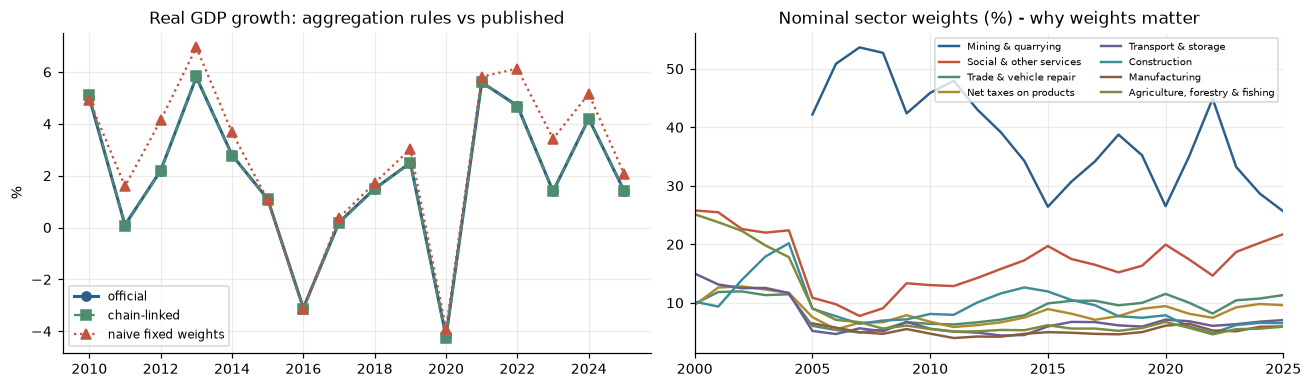

mining weight: 45.9% (2010) -> 25.6% (2025)


In [9]:
NOM = pd.DataFrame({c: (A_RAW.nettax_n if c=='nettax' else A_RAW[f'va_{c}_n']) for c in COMP})
GIX = pd.DataFrame({c: (A_RAW.nettax_rgi if c=='nettax' else A_RAW[f'va_{c}_rgi']) for c in COMP})

def pyp_growth(nom, gix, comps=None):
    '''Previous-year-price (chain-linked) aggregate growth in %, the official aggregator.'''
    comps = comps or list(nom.columns)
    n, g = nom[comps], gix[comps]
    w = n.div(n.sum(axis=1, min_count=len(comps)), axis=0)
    return ((w.shift(1) * (g/100 - 1)).sum(axis=1, min_count=len(comps))) * 100

chain = pyp_growth(NOM, GIX)
fixedbase = pd.DataFrame({c: D[f'rva_{c}'] for c in COMP}).sum(axis=1, min_count=len(COMP)).pct_change()*100
val = pd.DataFrame({'official': A_RAW.gdp_rgi - 100, 'chain-linked (PYP)': chain,
                    'naive fixed-2015-weight sum': fixedbase})
val['error: chain'] = val['chain-linked (PYP)'] - val.official
val['error: naive'] = val['naive fixed-2015-weight sum'] - val.official
display(val.loc[2010:LAST_ACT].round(2))
m = val.loc[2010:LAST_ACT]
print(f"chain-linked : MAE {m['error: chain'].abs().mean():.3f} pp   max {m['error: chain'].abs().max():.3f} pp")
print(f"naive        : MAE {m['error: naive'].abs().mean():.3f} pp   max {m['error: naive'].abs().max():.3f} pp")
assert m['error: chain'].abs().max() < 0.25, "chain-linked aggregator failed to reproduce official growth"
print("\n=> the chain-linked aggregator reproduces official real GDP growth; it is used for all forecast aggregation.")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].plot(m.index, m.official, 'o-', lw=2, label='official', color=PAL[0])
ax[0].plot(m.index, m['chain-linked (PYP)'], 's--', label='chain-linked', color=PAL[2])
ax[0].plot(m.index, m['naive fixed-2015-weight sum'], '^:', label='naive fixed weights', color=PAL[1])
ax[0].set_title('Real GDP growth: aggregation rules vs published'); ax[0].set_ylabel('%'); ax[0].legend(fontsize=8)
sh = NOM.div(NOM.sum(axis=1), axis=0)*100
for i, c in enumerate(['min','oth','trd','nettax','tra','con','man','agr']):
    ax[1].plot(sh.index, sh[c], label=SECT_LABEL[c], color=PAL[i], lw=1.6)
ax[1].set_xlim(2000, LAST_ACT); ax[1].set_title('Nominal sector weights (%) - why weights matter')
ax[1].legend(fontsize=6.5, ncol=2)
plt.tight_layout(); plt.show()
print("mining weight: %.1f%% (2010) -> %.1f%% (2025)" % (sh.loc[2010,'min'], sh.loc[LAST_ACT,'min']))

### 3.5 Non-additivity of chained volumes, and the exact oil/non-oil split

Two facts govern how aggregates are handled in the solver.

**Chained volumes are not additive.** `real oil GDP + real non-oil GDP ≠ real GDP` in the chained series; the gap drifts from
−5.3% (2010) to +4.9% (2025). This is a well-known property of chain-linking, not an error. The consequence for the model is
concrete: **non-oil real GDP must be built from its own chain-linked growth rate, never by subtracting real oil GDP from real GDP.**

**The nominal split, by contrast, is exact.** Oil-and-gas GDP exceeds mining value added because it also contains oil
refining (inside manufacturing) and oil services. The identity

> non-oil GDP = Σ(non-mining VA) + net taxes − (oil GDP − mining VA)

holds to 0.000% in every year. That wedge — oil activity outside mining — is what the solver must track.

In [10]:
addv = pd.DataFrame({'real GDP': D.rgdp, 'real oil GDP': D.rgdpoil, 'real non-oil GDP': D.rgdpnon})
addv['oil + non-oil'] = addv['real oil GDP'] + addv['real non-oil GDP']
addv['non-additivity %'] = (addv['oil + non-oil']/addv['real GDP'] - 1)*100
display(addv.loc[[2010,2013,BASE_YEAR,2018,2021,2023,LAST_ACT]].round(2))
print("=> chained volumes are NOT additive: never build non-oil GDP by subtraction.\n")

oilx = A_RAW.gdp_oil_n - A_RAW.va_min_n          # oil activity outside mining: refining + oil services
nonmining = A_RAW[[f'va_{s}_n' for s in SECT if s!='min']].sum(axis=1, min_count=10) + A_RAW.nettax_n
ident = pd.DataFrame({'computed non-oil GDP': nonmining - oilx, 'official': A_RAW.gdp_nonoil_n})
ident['error %'] = (ident['computed non-oil GDP']/ident.official - 1)*100
ident['oil activity outside mining'] = oilx
display(ident.loc[2018:LAST_ACT].round(3))
print("=> the NOMINAL oil/non-oil split is exact. Wedge = refining + oil services, ~3-4 bn AZN.\n")

# how well does chain-linking the non-mining components track official non-oil growth?
chain_non = pyp_growth(NOM, GIX, comps=[c for c in COMP if c!='min'])
cmpn = pd.DataFrame({'official non-oil': A_RAW.gdp_nonoil_rgi - 100, 'chain-linked non-mining': chain_non})
cmpn['error pp'] = cmpn['chain-linked non-mining'] - cmpn['official non-oil']
def nonoil_bias(cut):
    '''Mean chain-link wedge between non-mining and official non-oil growth, 2010..cut.'''
    return float(cmpn.loc[2010:cut, 'error pp'].mean())
NONOIL_BIAS = nonoil_bias(LAST_ACT)
print(f"chain-linked non-mining vs official non-oil growth: MAE "
      f"{cmpn.loc[2010:LAST_ACT,'error pp'].abs().mean():.3f} pp, max "
      f"{cmpn.loc[2010:LAST_ACT,'error pp'].abs().max():.3f} pp, mean bias {NONOIL_BIAS:+.3f} pp")
print("The residual wedge is refining + oil services, which sit inside manufacturing.")
print(f"The solver applies the mean bias ({NONOIL_BIAS:+.3f} pp) as a calibrated correction and reports it.")
display(cmpn.loc[2015:LAST_ACT].round(2))

,real GDP,real oil GDP,real non-oil GDP,oil + non-oil,non-additivity %
year,,,,,
2010,"48,341.960","19,247.190","26,553.470","45,800.660",-5.260
2013,"52,323.280","16,750.180","35,054.030","51,804.210",-0.990
2015,"54,380.000","16,459.600","37,920.400","54,380.000",0.000
2018,"53,591.600","15,730.440","37,972.530","53,702.970",0.210
2021,"55,571.230","15,094.350","41,068.760","56,163.110",1.070
2023,"58,997.640","14,437.440","46,822.290","61,259.730",3.830
2025,"62,336.200","14,206.440","51,212.110","65,418.560",4.940


=> chained volumes are NOT additive: never build non-oil GDP by subtraction.



,computed non-oil GDP,official,error %,oil activity outside mining
year,,,,
2018,"46,702.600","46,702.600",0.000,"2,348.000"
2019,"50,650.200","50,650.200",0.000,"2,399.200"
2020,"51,131.500","51,131.500",0.000,"2,198.400"
2021,"57,432.400","57,432.400",-0.000,"3,120.900"
2022,"69,764.100","69,764.100",0.000,"4,065.500"
2023,"78,990.300","78,990.300",-0.000,"3,240.900"
2024,"86,197.100","86,240.800",-0.051,"4,004.900"
2025,"92,307.100","92,307.100",0.000,"3,678.500"


=> the NOMINAL oil/non-oil split is exact. Wedge = refining + oil services, ~3-4 bn AZN.

chain-linked non-mining vs official non-oil growth: MAE 0.365 pp, max 0.809 pp, mean bias -0.198 pp
The residual wedge is refining + oil services, which sit inside manufacturing.
The solver applies the mean bias (-0.198 pp) as a calibrated correction and reports it.


,official non-oil,chain-linked non-mining,error pp
year,,,
2015,1.100,1.200,0.100
2016,-4.500,-4.510,-0.010
2017,2.800,2.290,-0.510
2018,2.000,2.030,0.030
2019,4.000,3.690,-0.310
2020,-2.900,-2.930,-0.030
2021,7.100,7.450,0.350
2022,9.100,8.470,-0.630
2023,4.500,5.090,0.590


## Part 4 — Structural diagnosis of the economy

Specification should follow from the economy's actual structure, so the facts that drive the model design are established
first. Four of them dictate the architecture.

In [11]:
Y = LAST_ACT
sh = NOM.div(NOM.sum(axis=1), axis=0)*100
# Built on the sector codes and relabelled afterwards: building it directly on the labels
# mis-aligned the share Series (indexed by code) and produced NaN columns.
struct = pd.DataFrame({
 'nominal VA share 2010 (%)': sh.loc[2010, COMP].values,
 f'nominal VA share {Y} (%)': sh.loc[Y, COMP].values,
 'real growth 2015-25 (%)': (D[[f'rva_{c}' for c in COMP]].loc[Y].values /
                             D[[f'rva_{c}' for c in COMP]].loc[BASE_YEAR].values - 1)*100,
 'deflator 2025 (2015=1)': [D[f'p_{c}'].loc[Y]/D[f'p_{c}'].loc[BASE_YEAR] for c in COMP],
}, index=[SECT_LABEL[c] for c in COMP])
assert struct.notna().all().all(), 'structural table has missing cells'
struct['share change (pp)'] = struct[f'nominal VA share {Y} (%)'] - struct['nominal VA share 2010 (%)']
display(struct.sort_values(f'nominal VA share {Y} (%)', ascending=False).round(2))

print("FACT 1 - hydrocarbon dependence is the binding structural feature")
for lbl, v in [('oil & gas share of GDP', A_RAW.gdp_oil_n[Y]/A_RAW.gdp_n[Y]*100),
               ('oil & gas share of goods exports', A_RAW.x_g_oil_usd[Y]/A_RAW.x_g_usd[Y]*100),
               ('oil & gas share of budget revenue', A_RAW.rev_oil_n[Y]/A_RAW.rev_tot_n[Y]*100)]:
    print(f"   {lbl:<38} {v:5.1f}%")

print("\nFACT 2 - hydrocarbon volumes are in structural transition (exogenous, not extrapolable)")
hc = pd.DataFrame({'oil output (mt)': D.oil_prod, 'gas output (bcm)': D.gas_prod,
                   'Brent (USD/bbl)': D.brent, 'gas export price (USD/kcm)': D.gas_exp_price})
display(hc.loc[2018:Y].round(2))
print(f"   oil: {((D.oil_prod[Y]/D.oil_prod[2019])**(1/6)-1)*100:+.2f}% p.a. since 2019 (managed decline)")
print(f"   gas: {((D.gas_prod[Y]/D.gas_prod[2019])**(1/6)-1)*100:+.2f}% p.a. since 2019, but only "
      f"{(D.gas_prod[Y]/D.gas_prod[Y-1]-1)*100:+.2f}% in {Y} -> plateau reached")

print("\nFACT 3 - the non-oil economy is growing and rebalancing toward services")
print(f"   non-oil real GDP 2015-25: {(D.rgdpnon[Y]/D.rgdpnon[BASE_YEAR]-1)*100:+.1f}%")
print(f"   fastest sectors 2015-25 : " + ", ".join(
    f"{SECT_LABEL[c]} {(D[f'rva_{c}'][Y]/D[f'rva_{c}'][BASE_YEAR]-1)*100:+.0f}%"
    for c in ['ict','tra','man','tou']))
print(f"   contracting sectors     : " + ", ".join(
    f"{SECT_LABEL[c]} {(D[f'rva_{c}'][Y]/D[f'rva_{c}'][BASE_YEAR]-1)*100:+.0f}%" for c in ['min','con']))

print("\nFACT 4 - three structural breaks dominate the sample; any AR parameterisation would be unstable")
brk = pd.DataFrame({'FX (AZN/USD)': D.fx, 'CPI inflation (%)': D.infl,
                    'real GDP growth (%)': A_RAW.gdp_rgi-100, 'Brent': D.brent})
display(brk.loc[[2014,2015,2016,2019,2020,2021,2022,2023,Y]].round(2))
BREAKS = {2015: 'devaluation (0.78 -> 1.77)', 2020: 'pandemic', 2022: 'energy price shock'}
print("   breaks carried as dummies / tested by Chow:", BREAKS)

,nominal VA share 2010 (%),nominal VA share 2025 (%),real growth 2015-25 (%),deflator 2025 (2015=1),share change (pp)
Mining & quarrying,45.880,25.650,-15.600,2.730,-20.230
Social & other services,13.030,21.740,19.600,2.190,8.710
Trade & vehicle repair,6.420,11.330,31.770,2.060,4.910
Net taxes on products,6.770,9.600,35.520,1.880,2.830
Transport & storage,5.580,7.050,96.900,1.430,1.480
Construction,8.100,6.530,-9.800,1.440,-1.570
Manufacturing,4.740,5.980,85.570,1.530,1.240
"Agriculture, forestry & fishing",5.520,5.930,37.630,1.650,0.400
Tourism & catering,1.040,2.770,55.310,1.750,1.730
Information & communication,1.860,2.070,154.800,0.960,0.200


FACT 1 - hydrocarbon dependence is the binding structural feature
   oil & gas share of GDP                  28.5%
   oil & gas share of goods exports        85.6%
   oil & gas share of budget revenue       48.1%

FACT 2 - hydrocarbon volumes are in structural transition (exogenous, not extrapolable)


,oil output (mt),gas output (bcm),Brent (USD/bbl),gas export price (USD/kcm)
year,,,,
2018,38.810,30.490,71.340,188.100
2019,37.500,35.610,64.300,188.780
2020,34.530,37.140,41.960,176.310
2021,34.580,43.870,70.860,276.080
2022,32.650,46.740,100.930,790.380
2023,30.150,48.500,82.490,513.770
2024,29.050,50.430,80.520,326.190
2025,27.680,50.920,69.140,350.200


   oil: -4.94% p.a. since 2019 (managed decline)
   gas: +6.14% p.a. since 2019, but only +0.96% in 2025 -> plateau reached

FACT 3 - the non-oil economy is growing and rebalancing toward services
   non-oil real GDP 2015-25: +35.1%
   fastest sectors 2015-25 : Information & communication +155%, Transport & storage +97%, Manufacturing +86%, Tourism & catering +55%
   contracting sectors     : Mining & quarrying -16%, Construction -10%

FACT 4 - three structural breaks dominate the sample; any AR parameterisation would be unstable


,FX (AZN/USD),CPI inflation (%),real GDP growth (%),Brent
year,,,,
2014,0.780,-0.100,2.800,98.970
2015,1.560,7.600,1.100,52.320
2016,1.770,15.700,-3.100,43.640
2019,1.700,2.400,2.500,64.300
2020,1.700,2.600,-4.200,41.960
2021,1.700,12.000,5.600,70.860
2022,1.700,14.400,4.700,100.930
2023,1.700,2.100,1.400,82.490
2025,1.700,5.200,1.400,69.140


   breaks carried as dummies / tested by Chow: {2015: 'devaluation (0.78 -> 1.77)', 2020: 'pandemic', 2022: 'energy price shock'}


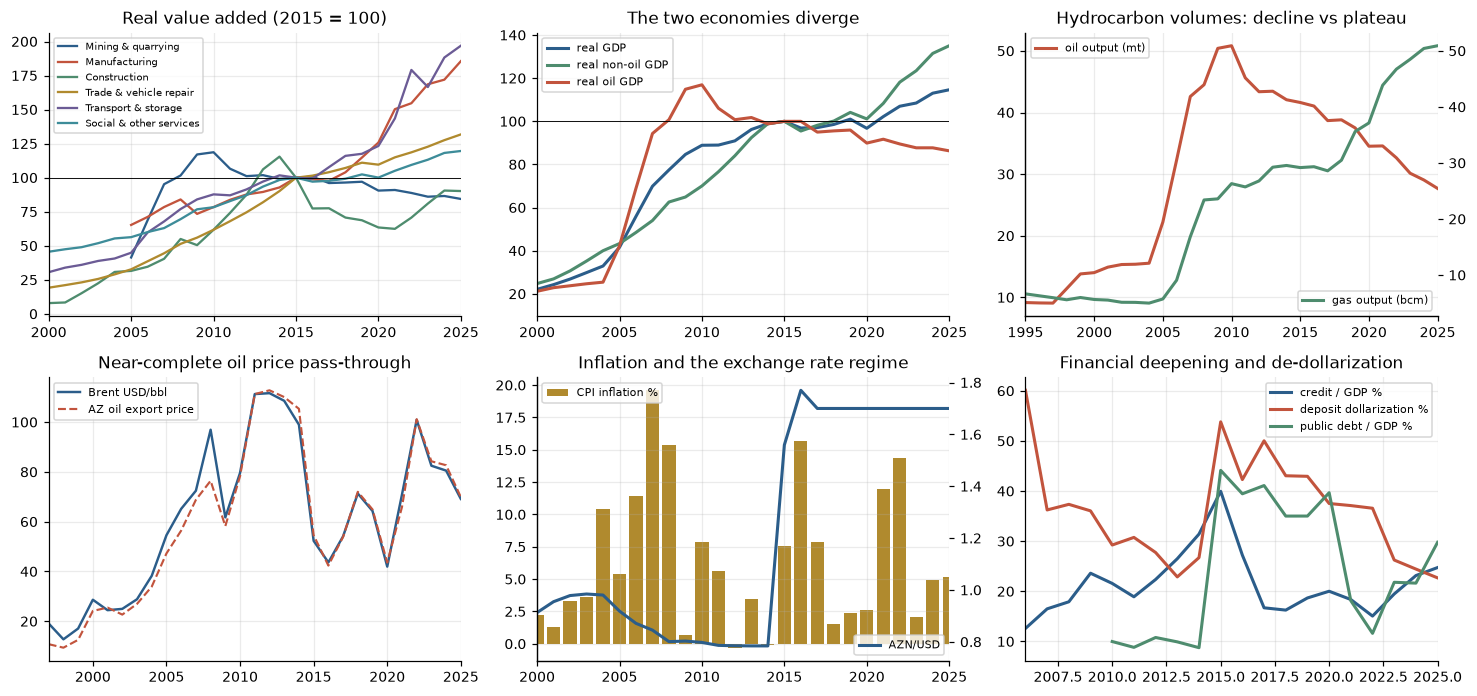

In [12]:
fig, ax = plt.subplots(2, 3, figsize=(13.5, 6.4))
a = ax[0,0]
for i,c in enumerate(['min','man','con','trd','tra','oth']):
    a.plot(D.index, D[f'rva_{c}']/D[f'rva_{c}'].loc[BASE_YEAR]*100, label=SECT_LABEL[c], color=PAL[i])
a.set_xlim(2000,Y); a.axhline(100, color='k', lw=.6); a.set_title('Real value added (2015 = 100)')
a.legend(fontsize=6.5)
a = ax[0,1]
a.plot(D.index, D.rgdp/D.rgdp.loc[BASE_YEAR]*100, lw=2, label='real GDP', color=PAL[0])
a.plot(D.index, D.rgdpnon/D.rgdpnon.loc[BASE_YEAR]*100, lw=2, label='real non-oil GDP', color=PAL[2])
a.plot(D.index, D.rgdpoil/D.rgdpoil.loc[BASE_YEAR]*100, lw=2, label='real oil GDP', color=PAL[1])
a.set_xlim(2000,Y); a.axhline(100,color='k',lw=.6); a.set_title('The two economies diverge'); a.legend(fontsize=7)
a = ax[0,2]
a.plot(D.index, D.oil_prod, color=PAL[1], lw=2, label='oil output (mt)')
a2 = a.twinx(); a2.plot(D.index, D.gas_prod, color=PAL[2], lw=2, label='gas output (bcm)')
a2.grid(False); a.set_xlim(1995,Y); a.set_title('Hydrocarbon volumes: decline vs plateau')
a.legend(fontsize=7, loc='upper left'); a2.legend(fontsize=7, loc='lower right')
a = ax[1,0]
a.plot(D.index, D.brent, color=PAL[0], lw=1.6, label='Brent USD/bbl')
a.plot(D.index, D.oil_exp_price, '--', color=PAL[1], lw=1.4, label='AZ oil export price')
a.set_xlim(1997,Y); a.set_title('Near-complete oil price pass-through'); a.legend(fontsize=7)
a = ax[1,1]
a.bar(D.index, D.infl, color=PAL[3], label='CPI inflation %')
a2 = a.twinx(); a2.plot(D.index, D.fx, color=PAL[0], lw=2, label='AZN/USD'); a2.grid(False)
a.set_xlim(2000,Y); a.set_title('Inflation and the exchange rate regime')
a.legend(fontsize=7, loc='upper left'); a2.legend(fontsize=7, loc='lower right')
a = ax[1,2]
a.plot(D.index, D.credit_gdp, lw=2, color=PAL[0], label='credit / GDP %')
a.plot(D.index, D.dollarization, lw=2, color=PAL[1], label='deposit dollarization %')
a.plot(D.index, D.debt_gdp, lw=2, color=PAL[2], label='public debt / GDP %')
a.set_xlim(2006,Y); a.set_title('Financial deepening and de-dollarization'); a.legend(fontsize=7)
plt.tight_layout(); plt.show()

## Part 5 — Estimation toolkit

`linearmodels` is not installed in this environment, so the structural estimators are implemented directly. This is
preferable for a methodology deliverable anyway: every estimator is visible and auditable rather than hidden behind an API.
Each one is then **validated against `statsmodels`** to machine precision, so correctness is demonstrated rather than assumed.

| Estimator | Purpose in this model |
|---|---|
| `ols` (HC1 / Newey–West HAC with n/(n−k) scaling, t(n−k) p-values) | single equations; rate equations |
| `tsls` | 2SLS for equations with endogenous regressors; reports first-stage F and Sargan J |
| `system_3sls` | efficient system estimation exploiting cross-equation error covariance |
| `sur` | share systems (sectoral credit allocation) with adding-up restrictions imposed |
| `dols`, `lr_fit` | Stock–Watson DOLS (±1 leads/lags of Δx if df ≥ 10, else contemporaneous Δx if df ≥ 8, else OLS) — the **long-run coefficients used in forecasting**; no lagged dependent variable |
| `eg_coint_p` | residual-based cointegration p-value (ADF without deterministics, maxlag 1, MacKinnon N = I(1) regressors + 1) |
| `dwh_test` | Durbin–Wu–Hausman exogeneity test (control function, HAC-F) |
| `diff_form` | the same equation in first differences, as a cross-check of each level coefficient |
| `panel_fe`, `wild_cluster_p` | two-way fixed effects with Driscoll–Kraay SE (⌊T^¼⌋ lags, t(T−1)); wild cluster bootstrap by year (Webb weights) |
| `wald_test` | HAC-F test F(m, n−k) of theory restrictions, reported with the s.e. of the tested combination (power proxy) |
| `gauss_seidel` | solving the simultaneous nonlinear system |

On the two constructs that touch lags: **HAC standard errors** correct inference only — they never alter a fitted value or a
forecast. **DOLS** augments a levels regression with leads and lags of the *differences of the regressors*; the dependent
variable's own lags never enter, which is precisely why it is the cointegrating estimator compatible with this model's
no-autoregression rule.

In [13]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.adfvalues import mackinnonp

class Fit:
    def __init__(self, **kw): self.__dict__.update(kw)
    def table(self, digits=4):
        t = pd.DataFrame({'coef': self.beta, 'se': self.se, 't': self.tstat, 'p': self.pval},
                         index=self.names)
        t['sig'] = ['***' if p<.01 else '**' if p<.05 else '*' if p<.10 else '' for p in self.pval]
        return t.round(digits)
    def summary(self, title=''):
        out = [f"{title or self.kind}   n={self.n}  R2={self.r2:.4f}  adj={self.r2a:.4f}"]
        if getattr(self, 'extra', None): out.append("  " + self.extra)
        out.append(self.table().to_string())
        return "\n".join(out)
    def __repr__(self): return self.summary()

def _prep(y, X, add_const=True):
    d = pd.concat([y.rename('__y__'), X], axis=1).dropna()
    yv = d['__y__'].to_numpy(float); Xv = d.drop(columns='__y__').to_numpy(float)
    names = [c for c in d.columns if c != '__y__']
    if add_const:
        Xv = np.column_stack([np.ones(len(Xv)), Xv]); names = ['const'] + names
    return yv, Xv, names, d.index

def hac_cov(X, u, XtXi, lags=None, small=True):
    '''Newey-West (Bartlett) HAC covariance with the finite-sample scaling n/(n-k).
    This corrects INFERENCE for residual dependence; it adds no autoregressive term to the
    model and never changes a fitted value.'''
    n, k = X.shape
    if lags is None: lags = max(1, int(np.floor(4*(n/100)**(2/9))))
    Xu = X * u[:, None]
    S = Xu.T @ Xu
    for L in range(1, lags+1):
        G = Xu[L:].T @ Xu[:-L]
        S += (1 - L/(lags+1)) * (G + G.T)
    V = XtXi @ S @ XtXi
    return V * (n/max(n-k, 1)) if small else V

def ols(y, X, cov='hac', lags=None, add_const=True):
    yv, Xv, names, idx = _prep(y, X, add_const)
    n, k = Xv.shape
    XtXi = np.linalg.pinv(Xv.T @ Xv)
    b = XtXi @ Xv.T @ yv
    u = yv - Xv @ b
    dof = max(n-k, 1)
    if   cov == 'hac': V = hac_cov(Xv, u, XtXi, lags)
    elif cov == 'hc1': V = XtXi @ ((Xv*u[:,None]).T @ (Xv*u[:,None])) @ XtXi * n/dof
    else:              V = XtXi * (u@u)/dof
    se = np.sqrt(np.maximum(np.diag(V), 0))
    with np.errstate(divide='ignore', invalid='ignore'): t = b/se
    tss = ((yv-yv.mean())**2).sum() if add_const else (yv**2).sum()
    r2 = 1 - (u@u)/tss if tss > 0 else np.nan
    return Fit(kind=f'OLS[{cov}]', beta=b, se=se, tstat=t, pval=2*(1-stats.t.cdf(np.abs(t), dof)),
               names=names, n=n, k=k, r2=r2, r2a=1-(1-r2)*(n-1)/dof, V=V, X=Xv, y=yv, index=idx,
               resid=pd.Series(u, index=idx), fitted=pd.Series(Xv@b, index=idx), sigma2=(u@u)/dof,
               dof=dof, estimator='OLS')

def tsls(y, X_endog, X_exog, Z, cov='hac', lags=None):
    '''2SLS for a structural equation. X_endog: jointly determined regressors;
    X_exog: included exogenous; Z: EXCLUDED instruments.
    Reports first-stage F (weak-instrument screen) and Sargan J (over-identification).'''
    En = list(X_endog.columns)
    Xn = [] if X_exog is None or X_exog.shape[1]==0 else list(X_exog.columns)
    Zn = list(Z.columns)
    parts = [p for p in (X_endog, X_exog, Z) if p is not None and p.shape[1] > 0]
    d = pd.concat([y.rename('__y__')] + parts, axis=1).dropna()
    yv = d['__y__'].to_numpy(float)
    E  = d[En].to_numpy(float)
    Xx = d[Xn].to_numpy(float) if Xn else np.empty((len(d), 0))
    Zz = d[Zn].to_numpy(float)
    one = np.ones((len(d), 1))
    W = np.column_stack([one, E, Xx])          # regressors
    I = np.column_stack([one, Xx, Zz])         # instrument set
    names = ['const'] + En + Xn
    n, k = W.shape
    if I.shape[1] < k:
        raise ValueError(f"under-identified: {I.shape[1]} instruments for {k} parameters")
    PiI = np.linalg.pinv(I.T @ I)
    Wh = I @ (PiI @ (I.T @ W))
    b = np.linalg.pinv(Wh.T @ W) @ (Wh.T @ yv)
    u = yv - W @ b
    dof = max(n-k, 1)
    XtXi = np.linalg.pinv(Wh.T @ Wh)
    if   cov == 'hac': V = hac_cov(Wh, u, XtXi, lags)
    elif cov == 'hc1': V = XtXi @ ((Wh*u[:,None]).T @ (Wh*u[:,None])) @ XtXi * n/dof
    else:              V = XtXi * (u@u)/dof
    se = np.sqrt(np.maximum(np.diag(V), 0))
    with np.errstate(divide='ignore', invalid='ignore'): t = b/se
    X0 = np.column_stack([one, Xx]); q = Zz.shape[1]
    fsF = {}
    for j, nm in enumerate(En):
        ru = E[:,j] - I @ (PiI @ (I.T @ E[:,j]))
        rr = E[:,j] - X0 @ (np.linalg.pinv(X0.T@X0) @ (X0.T @ E[:,j]))
        den = (ru@ru)/max(n-I.shape[1], 1)
        fsF[nm] = ((rr@rr - ru@ru)/q)/den if den > 0 else np.nan
    over = I.shape[1] - k
    if over > 0:
        uh = I @ (PiI @ (I.T @ u)); J = n*(uh@uh)/(u@u); Jp = 1-stats.chi2.cdf(J, over)
    else:
        J, Jp = np.nan, np.nan
    r2 = 1 - (u@u)/((yv-yv.mean())**2).sum()
    extra = ("first-stage F: " + ", ".join(f"{m}={v:.1f}" for m, v in fsF.items()) +
             (f" | Sargan J({over})={J:.2f} p={Jp:.3f}" if over > 0 else " | just-identified"))
    return Fit(kind=f'2SLS[{cov}]', beta=b, se=se, tstat=t, pval=2*(1-stats.t.cdf(np.abs(t), dof)),
               names=names, n=n, k=k, r2=r2, r2a=1-(1-r2)*(n-1)/dof, V=V, index=d.index,
               resid=pd.Series(u, index=d.index), fitted=pd.Series(W@b, index=d.index),
               first_stage_F=fsF, J=J, J_p=Jp, extra=extra, sigma2=(u@u)/dof, dof=dof,
               estimator='2SLS')

def dwh_test(y, X_endog, X_exog, Z):
    '''Durbin-Wu-Hausman test in control-function form: the first-stage residual of every
    endogenous regressor is added to the structural OLS regression and their joint
    significance is tested with a small-sample HAC-F. Rejection = the regressors are not exogenous.'''
    Xn = [] if X_exog is None or X_exog.shape[1] == 0 else list(X_exog.columns)
    d = pd.concat([y.rename('__y__'), X_endog] + ([X_exog] if Xn else []) + [Z], axis=1).dropna()
    V = {}
    for e in X_endog.columns:
        fs = ols(d[e], d[Xn + list(Z.columns)], cov='nonrobust')
        V['v_' + e] = fs.resid
    Xa = pd.concat([d[list(X_endog.columns) + Xn], pd.DataFrame(V)], axis=1)
    f = ols(d['__y__'], Xa, cov='hac')
    R = np.zeros((len(V), len(f.beta)))
    for i, c in enumerate(V): R[i, f.names.index(c)] = 1.0
    return wald_test(f, R, np.zeros(len(V)))

def wald_test(fit, R, q):
    '''HAC-F test of R*beta = q: F = W/m referred to F(m, n-k) (small-sample form).'''
    R = np.atleast_2d(np.asarray(R, float)); q = np.atleast_1d(np.asarray(q, float))
    d = R @ fit.beta - q
    Vr = R @ fit.V @ R.T
    m = R.shape[0]
    F = float(d @ np.linalg.pinv(Vr) @ d) / m
    return F, 1 - stats.f.cdf(F, m, fit.dof)

def comb_se(fit, R):
    '''Standard error of the tested linear combination R*beta: the power proxy reported
    with every non-rejected restriction.'''
    R = np.atleast_2d(np.asarray(R, float))
    return float(np.sqrt(np.maximum((R @ fit.V @ R.T)[0, 0], 0)))

def restrict_row(fit, name, value=1.0):
    R = np.zeros(len(fit.beta)); R[fit.names.index(name)] = 1.0
    return wald_test(fit, R, [value])

def eg_coint_p(resid, n_i1, trend=False):
    '''Residual-based (Engle-Granger) cointegration p-value: ADF statistic on the residuals with
    NO deterministic terms in the auxiliary regression and maxlag 1 fixed, mapped through the
    MacKinnon response surface for N = (number of I(1) regressors + 1) and 'c' or 'ct' as the
    cointegrating regression contains a constant or a constant and linear trend.'''
    u = np.asarray(pd.Series(resid).dropna(), float)
    if len(u) < 8: return np.nan, np.nan
    stat = adfuller(u, maxlag=1, regression='n', autolag=None)[0]
    N = int(min(max(n_i1 + 1, 1), 6))
    return float(stat), float(mackinnonp(stat, regression='ct' if trend else 'c', N=N))

DET = ('trend', 'trend_post2015')       # deterministic regressors: never augmented with leads/lags, not counted as I(1)

def dols(y, X, leads=1, lags_=1, cov='hac', det=DET):
    '''Stock-Watson Dynamic OLS of a cointegrating relation.
    The levels regression is augmented with the contemporaneous value and leads/lags of the
    DIFFERENCES OF THE REGRESSORS to purge endogeneity and residual serial correlation.
    The dependent variable's own lags NEVER enter: this is not an autoregression.'''
    aug = {}
    for c in [c for c in X.columns if c not in det]:
        dx = X[c].diff()
        for L in range(-leads, lags_+1):
            aug[f'd_{c}_{"F" if L<0 else "L" if L>0 else "0"}{abs(L)}'] = dx.shift(L)
    Xa = pd.concat([X, pd.DataFrame(aug, index=X.index)], axis=1)
    f = ols(y, Xa, cov=cov)
    f.kind = f'DOLS[leads={leads},lags={lags_}]'
    return f

def lr_fit(y, X, det=DET):
    '''Long-run (level) estimator used for every level relation (contract decision 2):
    DOLS with +/-1 lead/lag of the differenced regressors when the residual df stays >= 10,
    otherwise contemporaneous differences only (Saikkonen) when df >= 8, otherwise static OLS.
    The returned Fit carries ONLY the level (long-run) coefficients - these are what the solver
    uses - with their HAC covariance from the DOLS regression. The constant is re-centred so the
    static levels residual has mean zero over the levels sample, and that static residual (not
    the DOLS residual, which loses end-points) is what cointegration tests and add-factors use.'''
    X = X.copy()
    stoch = [c for c in X.columns if c not in det]
    base = ols(y, X, cov='hac')
    f, est = None, 'OLS (static; DOLS infeasible, df too small)'
    if stoch:
        for L, need in ((1, 10), (0, 8)):
            g = dols(y, X, leads=L, lags_=L)
            if g.dof >= need:
                f = g; est = f'DOLS(+/-{L})' if L else 'DOLS(0: contemporaneous dX only)'
                break
    else:
        est = 'OLS (no stochastic regressor)'
    if f is None: f = base
    core = list(X.columns)
    ix = [0] + [f.names.index(c) for c in core]
    b_lr = pd.Series(f.beta[ix[1:]], index=core)
    d = pd.concat([y.rename('__y__'), X], axis=1).dropna()
    lvl = d['__y__'] - (d[core] @ b_lr if core else 0.0)
    const = float(lvl.mean())
    beta = np.concatenate([[const], b_lr.values])
    V = f.V[np.ix_(ix, ix)]
    se = np.sqrt(np.maximum(np.diag(V), 0))
    with np.errstate(divide='ignore', invalid='ignore'): t = beta/se
    resid = lvl - const
    tss = ((d['__y__'] - d['__y__'].mean())**2).sum()
    r2 = 1 - (resid**2).sum()/tss if tss > 0 else np.nan
    out = Fit(kind=est, beta=beta, se=se, tstat=t, pval=2*(1-stats.t.cdf(np.abs(t), f.dof)),
              names=['const'] + core, n=f.n, k=f.k, r2=r2, r2a=1-(1-r2)*(len(d)-1)/max(len(d)-len(beta), 1),
              V=V, index=d.index, resid=resid, fitted=d['__y__'] - resid, dof=f.dof, estimator=est,
              X=np.column_stack([np.ones(len(d)), d[core].to_numpy(float)]) if core else np.ones((len(d), 1)),
              n_level=len(d), static=base, raw=f, stoch=stoch, has_trend=any(c in det for c in core))
    return out

def rate_fit(y, X):
    '''Regressions among stationary rates (inflation, deflator inflation): static OLS with HAC.'''
    f = ols(y, X, cov='hac'); f.estimator = 'OLS (rates; no cointegration test)'
    f.n_level = f.n; f.stoch = []; f.has_trend = False; f.static = f
    return f

def diff_form(y, X, det=DET):
    '''The same equation in first differences (deterministic trend absorbed by the constant).'''
    stoch = [c for c in X.columns if c not in det]
    if not stoch: return None
    try:
        return ols(y.diff(), X[stoch].diff(), cov='hac')
    except Exception:
        return None

def vif(X):
    Xd = X.dropna()
    out = {}
    for c in Xd.columns:
        rest = Xd.drop(columns=c)
        if rest.shape[1] == 0: out[c] = 1.0; continue
        r2 = ols(Xd[c], rest, cov='nonrobust').r2
        out[c] = np.inf if r2 >= 1 else 1/(1-r2)
    return pd.Series(out)

def cond_number(X):
    '''Condition number of the standardised regressor matrix (columns demeaned and scaled to unit
    variance, constant excluded), so it measures collinearity among the regressors themselves.'''
    Xd = X.dropna().to_numpy(float)
    if Xd.shape[1] < 2: return 1.0
    Z = (Xd - Xd.mean(axis=0))/Xd.std(axis=0)
    s = np.linalg.svd(Z, compute_uv=False)
    return float(s.max()/s.min())
print("estimators defined: ols, tsls, dwh_test, dols, lr_fit, rate_fit, diff_form, wald_test (HAC-F), "
      "eg_coint_p (MacKinnon), vif, cond_number")


estimators defined: ols, tsls, dwh_test, dols, lr_fit, rate_fit, diff_form, wald_test (HAC-F), eg_coint_p (MacKinnon), vif, cond_number


In [14]:
def sur(eqs, restrictions=None, iterate=3):
    '''Seemingly-unrelated regressions by feasible GLS.
    `restrictions` = (R, q) imposes R*beta = q exactly (used for adding-up in share systems).'''
    names = list(eqs); idx = None
    for nm in names:
        y, X = eqs[nm]
        d = pd.concat([y, X], axis=1).dropna()
        idx = d.index if idx is None else idx.intersection(d.index)
    Y = [eqs[nm][0].loc[idx].to_numpy(float) for nm in names]
    Xs = [np.column_stack([np.ones(len(idx)), eqs[nm][1].loc[idx].to_numpy(float)]) for nm in names]
    n, m = len(idx), len(names); ks = [x.shape[1] for x in Xs]
    yb = np.concatenate(Y); Xb = np.zeros((n*m, sum(ks))); c = 0
    for i, x in enumerate(Xs):
        Xb[i*n:(i+1)*n, c:c+ks[i]] = x; c += ks[i]
    b = np.linalg.pinv(Xb.T@Xb) @ Xb.T @ yb
    Om = np.eye(n*m)
    for _ in range(iterate):
        U = (yb - Xb@b).reshape(m, n); S = U@U.T/n
        Om = np.kron(np.linalg.pinv(S), np.eye(n))
        Amat = Xb.T @ Om @ Xb; rhs = Xb.T @ Om @ yb
        if restrictions is not None:
            Rm, qv = restrictions
            KKT = np.block([[Amat, Rm.T], [Rm, np.zeros((Rm.shape[0], Rm.shape[0]))]])
            b = (np.linalg.pinv(KKT) @ np.concatenate([rhs, qv]))[:Amat.shape[0]]
        else:
            b = np.linalg.pinv(Amat) @ rhs
    V = np.linalg.pinv(Xb.T @ Om @ Xb); se = np.sqrt(np.maximum(np.diag(V), 0))
    out, c = {}, 0
    for i, nm in enumerate(names):
        cols = ['const'] + list(eqs[nm][1].columns)
        t = pd.DataFrame({'coef': b[c:c+ks[i]], 'se': se[c:c+ks[i]]}, index=cols)
        t['t'] = t.coef/t.se; out[nm] = t; c += ks[i]
    U = (yb - Xb@b).reshape(m, n)
    return out, pd.DataFrame(U.T, index=idx, columns=names), U@U.T/n

def system_3sls(eqs, instruments, iterate=2):
    '''Three-stage least squares for a simultaneous structural system.
    Stage 1-2: project all regressors on the instrument set (2SLS).
    Stage 3: re-weight by the cross-equation error covariance for efficiency.'''
    names = list(eqs); idx = None
    for nm in names:
        y, X = eqs[nm]
        d = pd.concat([y, X, instruments], axis=1).dropna()
        idx = d.index if idx is None else idx.intersection(d.index)
    Z = np.column_stack([np.ones(len(idx)), instruments.loc[idx].to_numpy(float)])
    Pz = Z @ np.linalg.pinv(Z.T@Z) @ Z.T
    Y, Xs, Xh = [], [], []
    for nm in names:
        y, X = eqs[nm]
        Xv = np.column_stack([np.ones(len(idx)), X.loc[idx].to_numpy(float)])
        Y.append(y.loc[idx].to_numpy(float)); Xs.append(Xv); Xh.append(Pz @ Xv)
    n, m = len(idx), len(names); ks = [x.shape[1] for x in Xs]
    yb = np.concatenate(Y)
    Xb = np.zeros((n*m, sum(ks))); Hb = np.zeros((n*m, sum(ks))); c = 0
    for i in range(m):
        Xb[i*n:(i+1)*n, c:c+ks[i]] = Xs[i]; Hb[i*n:(i+1)*n, c:c+ks[i]] = Xh[i]; c += ks[i]
    b = np.linalg.pinv(Hb.T@Xb) @ (Hb.T@yb)
    Om = np.eye(n*m)
    for _ in range(iterate):
        U = (yb - Xb@b).reshape(m, n); S = U@U.T/n
        Om = np.kron(np.linalg.pinv(S), np.eye(n))
        b = np.linalg.pinv(Hb.T @ Om @ Hb) @ (Hb.T @ Om @ yb)
    V = np.linalg.pinv(Hb.T @ Om @ Hb); se = np.sqrt(np.maximum(np.diag(V), 0))
    out, res, c = {}, {}, 0
    for i, nm in enumerate(names):
        cols = ['const'] + list(eqs[nm][1].columns)
        t = pd.DataFrame({'coef': b[c:c+ks[i]], 'se': se[c:c+ks[i]]}, index=cols)
        t['t'] = t.coef/t.se; t['p'] = 2*(1-stats.norm.cdf(t.t.abs()))
        t['sig'] = ['***' if p<.01 else '**' if p<.05 else '*' if p<.10 else '' for p in t.p]
        out[nm] = t
        res[nm] = pd.Series(Y[i] - Xs[i]@b[c:c+ks[i]], index=idx); c += ks[i]
    U = (yb - Xb@b).reshape(m, n)
    return out, pd.DataFrame(res), U@U.T/n, idx

def _within(df, dep, regs, entity, time, twoway):
    d = df[[entity, time, dep] + regs].dropna().copy()
    for c in [dep] + regs:
        if twoway:
            d[c] = (d[c] - d.groupby(entity)[c].transform('mean')
                         - d.groupby(time)[c].transform('mean') + d[c].mean())
        else:
            d[c] = d[c] - d.groupby(entity)[c].transform('mean')
    return d

def panel_fe(df, dep, regs, entity='unit', time='year', twoway=True, dk_lags=None):
    '''Two-way (entity and time) fixed-effects within estimator with Driscoll-Kraay standard
    errors. The DK bandwidth is floor(T^(1/4)) and, because the DK variance is built from T
    time-period score sums, t-statistics are referred to t(T-1) - with T = 5 or 10 the
    effective number of observations for inference is the number of years, not N x T.'''
    d = _within(df, dep, regs, entity, time, twoway)
    yv = d[dep].to_numpy(float); Xv = d[regs].to_numpy(float)
    XtXi = np.linalg.pinv(Xv.T@Xv); b = XtXi @ Xv.T @ yv; u = yv - Xv@b
    nN, nT = d[entity].nunique(), d[time].nunique()
    if dk_lags is None: dk_lags = int(np.floor(nT**0.25))
    k = len(regs) + nN + (nT-1 if twoway else 0)
    ht = (pd.DataFrame(Xv*u[:,None], index=d[time].to_numpy())
            .groupby(level=0).sum().sort_index().to_numpy())
    S = ht.T @ ht
    for L in range(1, dk_lags+1):
        G = ht[L:].T @ ht[:-L]; S += (1 - L/(dk_lags+1))*(G + G.T)
    V = XtXi @ S @ XtXi * (len(d)/max(len(d)-k, 1))
    se = np.sqrt(np.maximum(np.diag(V), 0)); t = b/se; dof = max(nT-1, 1)
    r2 = 1 - (u@u)/(yv@yv)
    return Fit(kind='Panel 2-way FE [Driscoll-Kraay]' if twoway else 'Panel entity FE [DK]',
               beta=b, se=se, tstat=t, pval=2*(1-stats.t.cdf(np.abs(t), dof)), names=regs,
               n=len(d), k=k, r2=r2, r2a=1-(1-r2)*(len(d)-1)/max(len(d)-k, 1), V=V,
               resid=pd.Series(u, index=d.index), nN=nN, nT=nT, dof=dof, dk_lags=dk_lags,
               extra=f"units={nN}  periods={nT}  DK lags={dk_lags}  inference df=T-1={dof}")

WEBB6 = np.array([-np.sqrt(1.5), -1.0, -np.sqrt(0.5), np.sqrt(0.5), 1.0, np.sqrt(1.5)])

def wild_cluster_p(df, dep, regs, test, entity='unit', time='year', twoway=True, B=1999, seed=None):
    '''Wild cluster bootstrap-t p-value (WCR: null imposed), clusters = years.
    With 5-10 year clusters the Rademacher distribution has too few distinct draws (2^T), so the
    Webb six-point distribution is used. Cluster-robust (CR1, by year) t-statistics.'''
    d = _within(df, dep, regs, entity, time, twoway)
    yv = d[dep].to_numpy(float); Xv = d[regs].to_numpy(float)
    tt = d[time].to_numpy(); ug = np.unique(tt); G = len(ug)
    gi = np.searchsorted(ug, tt)
    j = regs.index(test)
    XtXi = np.linalg.pinv(Xv.T @ Xv)
    def tstat(y_):
        b = XtXi @ Xv.T @ y_; u = y_ - Xv @ b
        sc = np.zeros((G, Xv.shape[1]))
        np.add.at(sc, gi, Xv*u[:, None])
        V = XtXi @ (sc.T @ sc) @ XtXi * G/max(G-1, 1)
        return b[j]/np.sqrt(max(V[j, j], 1e-300))
    t0 = tstat(yv)
    Xr = np.delete(Xv, j, axis=1)
    br = np.linalg.pinv(Xr.T @ Xr) @ Xr.T @ yv if Xr.shape[1] else np.zeros(0)
    fr = Xr @ br if Xr.shape[1] else np.zeros_like(yv); ur = yv - fr
    rg = np.random.default_rng(SEED if seed is None else seed)
    W = rg.choice(WEBB6, size=(B, G))
    ts = np.array([tstat(fr + ur*W[b_, gi]) for b_ in range(B)])
    return float(np.mean(np.abs(ts) >= abs(t0))), float(t0)

def gauss_seidel(eq_funcs, order, state, exog, max_iter=800, tol=1e-9, damp=0.55):
    '''Solve one period of the simultaneous nonlinear system by damped Gauss-Seidel.
    eq_funcs: variable -> f(state, exog) returning that variable's new value.'''
    s = dict(state)
    err = np.inf
    for it in range(max_iter):
        err = 0.0
        for v in order:
            new = eq_funcs[v](s, exog)
            old = s.get(v, new)
            if old is None or not np.isfinite(old): old = new
            upd = damp*new + (1-damp)*old
            err = max(err, abs(upd-old)/max(abs(old), 1e-6))
            s[v] = upd
        if err < tol:
            return s, it+1, err
    return s, max_iter, err
print("estimators defined: sur, system_3sls, panel_fe (DK, df=T-1), wild_cluster_p, gauss_seidel")

estimators defined: sur, system_3sls, panel_fe (DK, df=T-1), wild_cluster_p, gauss_seidel


### 5.1 Validating the estimators

Hand-written estimators must be proved correct before they are trusted with policy conclusions. Each is checked against
`statsmodels` on simulated data where the answer is known. Agreement to ~1e-15 is exact agreement in floating point.

In [15]:
import statsmodels.api as sm
from statsmodels.sandbox.regression.gmm import IV2SLS

rng = np.random.default_rng(SEED); n = 80
Xt = pd.DataFrame(rng.standard_normal((n,3)), columns=['a','b','c'])
yt = pd.Series(1 + 2*Xt.a - 1.5*Xt.b + .5*Xt.c + rng.standard_normal(n)*.3, name='y')
rows = []
f0 = ols(yt, Xt, cov='nonrobust'); r0 = sm.OLS(yt, sm.add_constant(Xt)).fit()
rows.append(['OLS coefficients', np.abs(f0.beta-r0.params.values).max()])
rows.append(['OLS standard errors', np.abs(f0.se-r0.bse.values).max()])
f1 = ols(yt, Xt, cov='hc1'); r1 = sm.OLS(yt, sm.add_constant(Xt)).fit(cov_type='HC1')
rows.append(['HC1 robust SE', np.abs(f1.se-r1.bse.values).max()])
f2 = ols(yt, Xt, cov='hac', lags=3)
r2_ = sm.OLS(yt, sm.add_constant(Xt)).fit(cov_type='HAC',
        cov_kwds={'maxlags':3, 'use_correction':True})
rows.append(['Newey-West HAC SE, small-sample n/(n-k)', np.abs(f2.se-r2_.bse.values).max()])
Zt = pd.DataFrame(rng.standard_normal((n,2)), columns=['z1','z2'])
en = pd.Series(.8*Zt.z1 + .6*Zt.z2 + rng.standard_normal(n)*.5, name='en')
y2 = pd.Series(1 + 1.5*en + .7*Xt.a + rng.standard_normal(n)*.4, name='y2')
g = tsls(y2, en.to_frame(), Xt[['a']], Zt, cov='nonrobust')
r3 = IV2SLS(y2, sm.add_constant(pd.concat([en, Xt.a], axis=1)),
                sm.add_constant(pd.concat([Xt.a, Zt], axis=1))).fit()
rows.append(['2SLS coefficients', np.abs(g.beta-r3.params.values).max()])
rows.append(['2SLS standard errors', np.abs(g.se-r3.bse.values).max()])
# 3SLS on a just-identified single equation must reproduce 2SLS
o3, _, _, _ = system_3sls({'eq': (y2, pd.concat([en, Xt.a], axis=1))},
                          pd.concat([Xt.a, Zt], axis=1))
rows.append(['3SLS vs 2SLS (just-identified)', np.abs(o3['eq'].coef.values - g.beta).max()])
# panel FE within-transform must reproduce OLS on demeaned data
pdf = pd.DataFrame({'unit': np.repeat(np.arange(10), 8), 'year': np.tile(np.arange(8), 10)})
pdf['x'] = rng.standard_normal(80); pdf['fe'] = pdf.unit*0.3
pdf['y'] = 1 + 0.6*pdf.x + pdf.fe + rng.standard_normal(80)*.2
fp = panel_fe(pdf, 'y', ['x'], twoway=False)
dd = pdf.copy()
for c in ['y','x']: dd[c] = dd[c] - dd.groupby('unit')[c].transform('mean')
rows.append(['panel FE coefficient', abs(fp.beta[0] - ols(dd.y, dd[['x']], cov='nonrobust').beta[1])])
# residual-based cointegration p-value must reproduce statsmodels' Engle-Granger test
from statsmodels.tsa.stattools import coint as _coint
xw = np.cumsum(rng.standard_normal(40)); yw = 0.5 + 0.8*xw + rng.standard_normal(40)*.5
fe = ols(pd.Series(yw), pd.DataFrame({'x': xw}), cov='nonrobust')
rows.append(['Engle-Granger p (MacKinnon) vs statsmodels coint',
             abs(eg_coint_p(fe.resid, 1)[1] - _coint(yw, xw, trend='c', maxlag=1, autolag=None)[1])])
chk = pd.DataFrame(rows, columns=['check','max abs difference'])
chk['verdict'] = np.where(chk['max abs difference'] < 1e-8, 'exact', 'MISMATCH')
display(chk)
assert (chk.verdict == 'exact').all(), "estimator validation failed"
print("all estimators reproduce statsmodels to machine precision")
print(f"\nWald machinery sanity check: H0 slope on 'a' = 2 (true value) -> "
      f"p = {restrict_row(f0, 'a', 2.0)[1]:.3f}  (should not reject)")
print(f"                             H0 slope on 'a' = 0            -> "
      f"p = {restrict_row(f0, 'a', 0.0)[1]:.3f}  (should reject)")

,check,max abs difference,verdict
0,OLS coefficients,0.000,exact
1,OLS standard errors,0.000,exact
2,HC1 robust SE,0.000,exact
3,"Newey-West HAC SE, small-sample n/(n-k)",0.000,exact
4,2SLS coefficients,0.000,exact
5,2SLS standard errors,0.000,exact
6,3SLS vs 2SLS (just-identified),0.000,exact
7,panel FE coefficient,0.000,exact
8,Engle-Granger p (MacKinnon) vs statsmodels coint,0.000,exact


all estimators reproduce statsmodels to machine precision

Wald machinery sanity check: H0 slope on 'a' = 2 (true value) -> p = 0.660  (should not reject)
                             H0 slope on 'a' = 0            -> p = 0.000  (should reject)


## Part 6 — Specification pre-tests

These are **pre-tests, not models.** Their only job is to decide how each relationship should be estimated: variables that
are non-stationary in levels but move together can be estimated as a cointegrating relation with DOLS; otherwise the
relationship is specified in growth rates. In practice the sample is too short for the pre-tests to separate I(1) from
trend-stationary behaviour, so every level relation is estimated by DOLS and its residual is then tested for cointegration;
where cointegration is not established the level coefficients are reported as descriptive and set beside the same equation
estimated in first differences (Part 10). Nothing here forecasts anything, and deleting this section would not change a
single forecast number.

With 20–26 annual observations, unit-root tests have low power, so results are read as *indicative* and never applied
mechanically. Where the tests are ambiguous, the specification is decided by economics and both variants are reported.

In [16]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter('ignore', InterpolationWarning)

def pretest(s, name, regression='ct'):
    s = s.dropna()
    if len(s) < 12: return dict(variable=name, n=len(s), reading='too short to test')
    out = dict(variable=name, n=len(s))
    try:    out['ADF level p'] = adfuller(s.values, regression=regression, autolag='AIC')[1]
    except Exception: out['ADF level p'] = np.nan
    try:    out['ADF diff p'] = adfuller(s.diff().dropna().values, regression='c', autolag='AIC')[1]
    except Exception: out['ADF diff p'] = np.nan
    try:    out['KPSS level p'] = kpss(s.values, regression='ct', nlags='auto')[1]
    except Exception: out['KPSS level p'] = np.nan
    lp = out['ADF level p'] if np.isfinite(out['ADF level p']) else 1.0
    dp = out['ADF diff p']  if np.isfinite(out['ADF diff p'])  else 1.0
    out['reading'] = ('I(1): levels non-stationary, differences stationary' if lp > .10 and dp < .10
                      else 'I(0): stationary in levels' if lp < .10
                      else 'ambiguous (low power at this sample size)')
    return out

L = lambda s: np.log(s.replace(0, np.nan))
core = {f'ln real VA {SECT_LABEL[c]}': L(D[f'rva_{c}']) for c in COMP}
core.update({
 'ln real GDP': L(D.rgdp), 'ln real non-oil GDP': L(D.rgdpnon),
 'ln real consumption': L(D.rcons), 'ln real disposable income': L(D.rhhdisp),
 'ln real non-oil investment': L(D.rinv_non), 'ln real state investment': L(D.rinv_state),
 'ln real total credit': L(D.rcred_tot), 'ln real household credit': L(D.rcred_hh),
 'ln real non-oil exports': L(D.rx_non), 'ln real non-oil imports': L(D.rm_non),
 'ln employment': L(D.emp), 'ln real wage': L(D.rwage), 'ln Brent': L(D.brent),
 'ln oil output': L(D.oil_prod), 'ln gas output': L(D.gas_prod),
 'CPI inflation (%)': D.infl, 'real lending rate (%)': D.realrate,
})
PRE = pd.DataFrame([pretest(v, k) for k, v in core.items()]).set_index('variable')
display(PRE.round(3))
print(PRE.reading.value_counts().to_string())
print("\n=> Most real variables are I(1) in levels, as expected of macro aggregates.")
print("   Levels relationships are therefore estimated by DOLS, and each relation's static residual is")
print("   tested with the residual-based Engle-Granger cointegration test (MacKinnon p-values, N = I(1)")
print("   regressors + 1). Where that test does not reject, the equation's t-statistics are labelled")
print("   descriptive. Rate variables (inflation, interest rates) enter in levels.")

,n,ADF level p,ADF diff p,KPSS level p,reading
variable,,,,,
"ln real VA Agriculture, forestry & fishing",26,0.381,0.115,0.050,ambiguous (low power at this sample size)
ln real VA Mining & quarrying,21,0.000,0.721,0.027,I(0): stationary in levels
ln real VA Manufacturing,21,1.000,1.000,0.030,ambiguous (low power at this sample size)
"ln real VA Electricity, gas & steam",21,0.962,0.877,0.100,ambiguous (low power at this sample size)
ln real VA Water supply & waste,17,0.265,0.113,0.082,ambiguous (low power at this sample size)
ln real VA Construction,26,0.870,0.853,0.021,ambiguous (low power at this sample size)
ln real VA Trade & vehicle repair,26,0.009,0.042,0.017,I(0): stationary in levels
ln real VA Tourism & catering,26,0.864,0.000,0.023,"I(1): levels non-stationary, differences stati..."
ln real VA Transport & storage,26,0.002,0.242,0.075,I(0): stationary in levels


reading
ambiguous (low power at this sample size)              10
I(0): stationary in levels                             10
I(1): levels non-stationary, differences stationary     9

=> Most real variables are I(1) in levels, as expected of macro aggregates.
   Levels relationships are therefore estimated by DOLS, and each relation's static residual is
   tested with the residual-based Engle-Granger cointegration test (MacKinnon p-values, N = I(1)
   regressors + 1). Where that test does not reject, the equation's t-statistics are labelled
   descriptive. Rate variables (inflation, interest rates) enter in levels.


## Part 7 — Panel block I: industry sub-branches → technology parameters

### Why a panel is needed at all

This is the pivotal methodological step. The aggregate annual sample offers 16–26 observations, while a production function
must identify a capital *and* a labour elasticity per sector while competing against a trend. On annual data this cannot be
done credibly — an early attempt in development produced a **negative** capital elasticity for manufacturing, because the
capital stock is collinear with trend.

The workbook, however, contains a genuine micro panel: **29 industrial sub-branches observed 2016–2025** (290 branch-years),
with gross output, value added, investment, average wage and headcount. The value-added production function can use the
branch-years where value added, a capital stock and employment are all present (the count is printed below). Within-branch
variation identifies technology parameters the aggregate series cannot. Those parameters are then **tested** against the
aggregate manufacturing equation and imposed only where the restriction is not rejected.

Inference follows the panel's real information content: Driscoll–Kraay standard errors with bandwidth ⌊T^{1/4}⌋ and t-tests on
T−1 degrees of freedom (the DK variance is built from T year-level score sums), plus wild cluster bootstrap p-values
(clusters = years, Webb six-point weights) for the key elasticities.

In [17]:
def industry_panel(sheets=('Emal Sənayesi','Mədənçıxarma','Su təchizatı','Elektrik enerjisi ')):
    '''Sub-branch panel. In the workbook a branch's output ("buraxılış") row is followed by its
    value-added, investment, wage and headcount rows, so the branch name is carried forward.'''
    recs = []
    for sh in sheets:
        mat, h, per = sheet_parsed(sh)
        acols = [(j, p[0]) for j, p in per if p[2] == 'A']
        branch = None
        for i in range(h+1, len(mat)):
            row = mat[i]
            if row[0] is None or not clean(row[0]): continue
            lab = clean(row[0]); low = az_lower(lab)
            vals = {y: to_num(row[j]) for j, y in acols}
            if not any(np.isfinite(v) for v in vals.values()): continue
            var = None
            if 'buraxılış' in low:
                branch = re.sub(r'\s*(üzrə\s*)?(məhsul\s*)?buraxılış[ıi]?\s*$', '', lab, flags=re.I)
                branch = re.sub(r'\s*üzrə$', '', branch).strip(' ;,.')
                var = 'output'
            elif 'əlavə dəyər' in low:                            var = 'gva'
            elif low.startswith('üdm') or 'sahə üzrə üdm' in low:  var = 'gva'
            elif 'əsas kapitala' in low:                          var = 'inv'
            elif 'əmək haqları' in low:                           var = 'wage'
            elif 'orta siyahı sayı' in low:                       var = 'emp'
            if var is None or branch is None: continue
            for y, v in vals.items():
                if np.isfinite(v):
                    recs.append(dict(sheet=sh, branch=branch, year=y, var=var, value=v))
    P = (pd.DataFrame(recs).pivot_table(index=['sheet','branch','year'], columns='var',
                                        values='value', aggfunc='first').reset_index())
    P.columns.name = None
    return P

IP = industry_panel()
AGGREGATE_ROWS = {'Emal sənayesi', 'Mədənçıxarma sənayesi'}   # drop: would double-count the branches
IP = IP[~IP.branch.isin(AGGREGATE_ROWS)].sort_values(['branch','year']).reset_index(drop=True)

def pim_group(g, delta=0.07, g0=0.06):
    inv = g['inv'].to_numpy(float); K = np.full(len(inv), np.nan)
    ok = np.where(np.isfinite(inv))[0]
    if not len(ok): return pd.Series(K, index=g.index)
    i0 = ok[0]; K[i0] = inv[i0]/(delta+g0)
    for t in range(i0+1, len(inv)):
        if np.isfinite(K[t-1]):
            K[t] = (1-delta)*K[t-1] + (0 if not np.isfinite(inv[t]) else inv[t])
    return pd.Series(K, index=g.index)

IP['K'] = IP.groupby('branch', group_keys=False).apply(pim_group)
IP['unit']     = IP.branch
IP['wagebill'] = IP.wage*12*IP.emp/1e6           # mln AZN per year
IP['lshare']   = IP.wagebill/IP.gva              # labour share in value added (wages only)
HC_BRANCHES = {'Xam neft və təbii qaz hasilatı', 'Neft məhsullarının istehsalı'}   # crude oil & gas, refining
IP['hydrocarbon'] = IP.branch.isin(HC_BRANCHES)
IP['lshare_gross'] = IP.lshare*(1 + EMPLOYER_SSC)  # grossed up by the employer social-contribution rate
for c in ['output','gva','inv','emp','K','wage']:
    IP['ln_'+c] = np.log(IP[c].replace(0, np.nan))
print(f"industry panel: {IP.branch.nunique()} branches x {IP.year.nunique()} years = {len(IP)} branch-year rows "
      f"({int(IP.year.min())}-{int(IP.year.max())})")
display(IP.groupby('sheet').agg(branches=('branch','nunique'), observations=('branch','size')))
display(IP[IP.year==LAST_ACT].nlargest(8,'gva')[['branch','output','gva','inv','emp','wage','lshare']].round(2))

industry panel: 29 branches x 10 years = 290 branch-year rows (2016-2025)


,branches,observations
sheet,,
Elektrik enerjisi,1,10
Emal Sənayesi,24,240
Mədənçıxarma,3,30
Su təchizatı,1,10


,branch,output,gva,inv,emp,wage,lshare
259,Xam neft və təbii qaz hasilatı,"34,003.100","30,992.000",NaN,"18,387.000","3,788.400",0.030
169,Neft məhsullarının istehsalı,"5,532.300","2,240.200",NaN,"3,788.000","2,827.300",0.060
39,"Elektrik enerjisi, qaz və buxar istehsalı, böl...","3,484.800","1,455.700","1,711.200","29,922.000","1,132.800",0.280
189,Qida məhsullarının istehsalı,"4,991.500","1,413.000",NaN,"37,357.000",717.400,0.230
79,Kimya sənayesi,1.580,619.100,NaN,"8,696.000","1,616.200",0.270
229,Tikinti materiallarının istehsalı,"1,462.300",545.200,NaN,"11,976.000","1,081.500",0.290
109,Maşın və avadanlıqların quraşdırılması və təmiri,"1,082.700",465.800,NaN,"10,071.000","1,540.000",0.400
249,Tütün məmulatlarının istehsalı,"1,052.300",455.800,NaN,"1,322.000","1,342.600",0.050


In [18]:
print("=== Production function, two-way fixed effects (branch and year) ===")
pf1 = panel_fe(IP, 'ln_gva',    ['ln_K','ln_emp'])
pf2 = panel_fe(IP, 'ln_output', ['ln_K','ln_emp'])
print(pf1.summary('ln value added ~ ln K + ln L')); print()
print(pf2.summary('ln gross output ~ ln K + ln L')); print()
PF_WILD = {r: wild_cluster_p(IP, 'ln_gva', ['ln_K','ln_emp'], r)[0] for r in ['ln_K','ln_emp']}
print("wild cluster bootstrap p-values (clusters = years, Webb weights, B=1999), value-added function:",
      {k: round(v, 3) for k, v in PF_WILD.items()})
print(f"branch-years used in the value-added production function: {pf1.n} ({pf1.nN} branches); "
      f"{len(IP)} branch-year rows in the panel")

print("\n=== Independent evidence: the observed labour share in value added ===")
def labour_shares(P):
    ok = P[P.lshare.between(0.02, 1.5)]
    nh = ok[~ok.hydrocarbon]
    return pd.Series({
        'all branches, wages only (median)':                   ok.lshare.median(),
        'non-hydrocarbon branches, wages only (median)':       nh.lshare.median(),
        f'non-hydrocarbon, grossed up x{1+EMPLOYER_SSC:.2f} (median)': (nh.lshare_gross).median(),
        'non-hydrocarbon, grossed up (aggregate ratio)':
            (nh.wagebill.sum()*(1+EMPLOYER_SSC))/nh.gva.sum(),
        'branch-years (non-hydrocarbon)': len(nh)})
LSH = labour_shares(IP)
display(LSH.round(3).to_frame('labour share'))
print('''The first line is the share used before this revision. It is biased DOWN twice: it omits employer
social contributions (the wage bill is not total compensation) and it includes crude-oil extraction and
refining, whose value added is mostly resource rent (labour shares of 3% and 4%). The technology
parameter for non-oil manufacturing should come from non-hydrocarbon branches and total compensation.''')

def alpha_from_panel(maxyear=None):
    '''Long-run labour elasticity = median grossed-up labour share of non-hydrocarbon branches.'''
    P = IP if maxyear is None else IP[IP.year <= maxyear]
    ok = P[P.lshare.between(0.02, 1.5) & ~P.hydrocarbon]
    aL = float(round(ok.lshare_gross.median(), 2))
    return aL, round(1 - aL, 2)

ALPHA_L, ALPHA_K = alpha_from_panel()
print(f'''
DECISION: alpha_L = {ALPHA_L} (non-hydrocarbon branches, grossed up by the {EMPLOYER_SSC:.0%} employer contribution),
alpha_K = {ALPHA_K}. (Wages-only, all-branch share would give alpha_K = {1-round(LSH.iloc[0],2):.2f}.)

INTERPRETATION - the panel regression and the factor share disagree, and the disagreement is informative
   within-panel  : capital {pf1.beta[0]:+.2f}, labour {pf1.beta[1]:+.2f}   (sum {pf1.beta[0]+pf1.beta[1]:.2f})
   factor share  : capital {ALPHA_K:+.2f}, labour {ALPHA_L:+.2f}   (sum 1.00 by construction)
The within estimator has only 10 years of variation per branch; value added moves almost one-for-one
with employment (labour hoarding; the perpetual-inventory stock is still dominated by its initial
condition), so it identifies a SHORT-RUN response, not technology. The income share identifies LONG-RUN
technology under competitive factor pricing. alpha_K is therefore a CANDIDATE restriction for the
aggregate manufacturing equation: it is tested there (C3) and imposed only if not rejected.''')

print("\n=== Sub-branch accelerator: does investment follow value added? ===")
print(panel_fe(IP, 'ln_inv', ['ln_gva']).summary('ln investment ~ ln value added'))
print("\n=== Sub-branch wage equation: does pay follow productivity? ===")
IP['ln_prod'] = np.log((IP.gva*1e6/IP.emp).replace(0, np.nan))
print(panel_fe(IP, 'ln_wage', ['ln_prod']).summary('ln wage ~ ln labour productivity'))


=== Production function, two-way fixed effects (branch and year) ===
ln value added ~ ln K + ln L   n=259  R2=0.3763  adj=0.2718
  units=27  periods=10  DK lags=1  inference df=T-1=9
        coef    se     t     p  sig
ln_K   0.117 0.067 1.755 0.113     
ln_emp 1.034 0.146 7.093 0.000  ***

ln gross output ~ ln K + ln L   n=276  R2=0.1574  adj=0.0182
  units=29  periods=10  DK lags=1  inference df=T-1=9
        coef    se     t     p  sig
ln_K   0.065 0.062 1.054 0.319     
ln_emp 0.843 0.132 6.405 0.000  ***

wild cluster bootstrap p-values (clusters = years, Webb weights, B=1999), value-added function: {'ln_K': 0.161, 'ln_emp': 0.001}
branch-years used in the value-added production function: 259 (27 branches); 290 branch-year rows in the panel

=== Independent evidence: the observed labour share in value added ===


,labour share
"all branches, wages only (median)",0.339
"non-hydrocarbon branches, wages only (median)",0.361
"non-hydrocarbon, grossed up x1.22 (median)",0.441
"non-hydrocarbon, grossed up (aggregate ratio)",0.375
branch-years (non-hydrocarbon),236.000


The first line is the share used before this revision. It is biased DOWN twice: it omits employer
social contributions (the wage bill is not total compensation) and it includes crude-oil extraction and
refining, whose value added is mostly resource rent (labour shares of 3% and 4%). The technology
parameter for non-oil manufacturing should come from non-hydrocarbon branches and total compensation.

DECISION: alpha_L = 0.44 (non-hydrocarbon branches, grossed up by the 22% employer contribution),
alpha_K = 0.56. (Wages-only, all-branch share would give alpha_K = 0.66.)

INTERPRETATION - the panel regression and the factor share disagree, and the disagreement is informative
   within-panel  : capital +0.12, labour +1.03   (sum 1.15)
   factor share  : capital +0.56, labour +0.44   (sum 1.00 by construction)
The within estimator has only 10 years of variation per branch; value added moves almost one-for-one
with employment (labour hoarding; the perpetual-inventory stock is still dominated 

manufacturing TFP growth 2016-2025: +1.47% p.a. (descriptive; alpha_K=0.56, alpha_L=0.44 from the grossed-up non-hydrocarbon factor share)


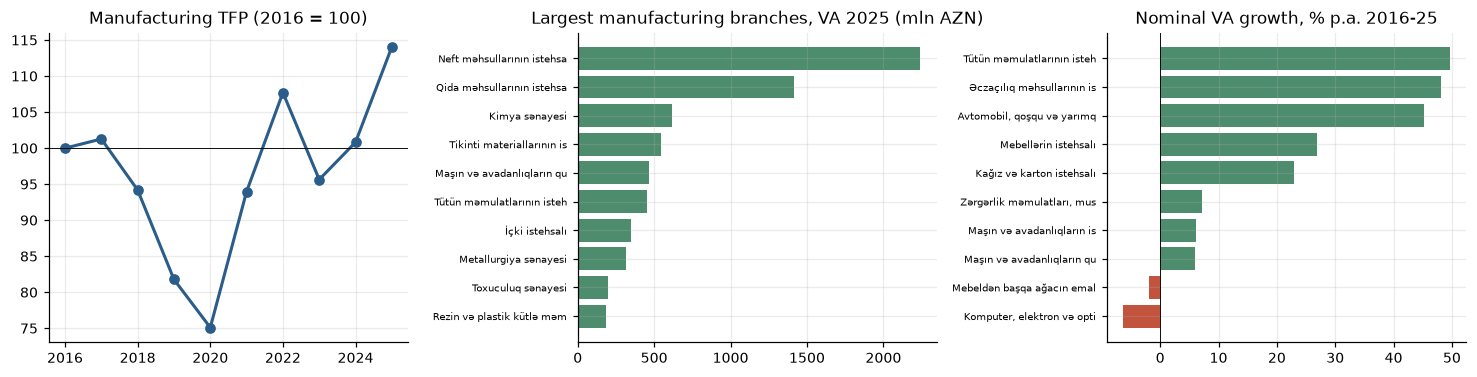

In [19]:
# Manufacturing TFP: value added per unit of the imposed Cobb-Douglas input bundle
MAN = IP[IP.sheet == 'Emal Sənayesi'].copy()
tfp_agg = MAN.groupby('year').apply(
    lambda g: g.gva.sum() / (g.K.sum()**ALPHA_K * (g.emp.sum()/1000)**ALPHA_L))
TFP_G_MAN = float((tfp_agg[LAST_ACT]/tfp_agg[2016])**(1/(LAST_ACT-2016)) - 1)
print(f"manufacturing TFP growth 2016-{LAST_ACT}: {TFP_G_MAN*100:+.2f}% p.a. "
      f"(descriptive; alpha_K={ALPHA_K}, alpha_L={ALPHA_L} from the grossed-up non-hydrocarbon factor share)")

fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.5))
ax[0].plot(tfp_agg.index, tfp_agg/tfp_agg.iloc[0]*100, 'o-', color=PAL[0], lw=2)
ax[0].axhline(100, color='k', lw=.6); ax[0].set_title('Manufacturing TFP (2016 = 100)')
top = MAN[MAN.year==LAST_ACT].nlargest(10, 'gva').sort_values('gva')
ax[1].barh(range(len(top)), top.gva, color=PAL[2])
ax[1].set_yticks(range(len(top))); ax[1].set_yticklabels([b[:26] for b in top.branch], fontsize=6.5)
ax[1].set_title(f'Largest manufacturing branches, VA {LAST_ACT} (mln AZN)')
gr = MAN.pivot_table(index='year', columns='branch', values='gva')
g10 = (((gr.loc[LAST_ACT]/gr.loc[2016])**(1/(LAST_ACT-2016))-1).dropna().sort_values())*100
g10 = pd.concat([g10.head(5), g10.tail(5)])
ax[2].barh(range(len(g10)), g10.values, color=[PAL[1] if v < 0 else PAL[2] for v in g10.values])
ax[2].set_yticks(range(len(g10))); ax[2].set_yticklabels([b[:26] for b in g10.index], fontsize=6.5)
ax[2].axvline(0, color='k', lw=.6); ax[2].set_title('Nominal VA growth, % p.a. 2016-25')
plt.tight_layout(); plt.show()

## Part 8 — Panel block II: economic regions → credit and investment elasticities

The workbook also holds **14 economic regions observed 2021–2025** (70 observations) with sector output, credit by maturity
and currency, regional lending rates, deposits, tax receipts, state investment, employment, wages, firm counts and regional CPI.

This panel exists to solve a specific identification failure. In the aggregate annual data the **user cost of capital carries
the wrong sign in every investment specification tested** (documented in Part 9). Azerbaijani non-oil investment is driven
largely by state and administrative decisions, and there is too little independent interest-rate variation in 20 annual
observations to identify a financial channel. Across regions, credit conditions *do* vary independently, so the channel can
be identified there instead.

In [20]:
REGION_SHEETS = ['Regionlar'] + [f'Regionlar {i}' for i in range(1, 14)]
REG_VARS = {
 'əhalinin sayı':'pop', 'pərakəndə ticarət dövriyyəsi həcmi':'retail',
 'əsas kapitala investisiyalar':'inv', 'tikinti quraşdırma işlərinə':'inv_cw',
 'iqtisadiyyatda muzdla çalışanların sayı':'emp',
 'muzdla çalışanların orta aylıq nominal əmək haqqı':'wage',
 'müəssisə və təşkilatların sayı':'firms', 'yeni açılmış iş yerləri':'newjobs',
 'cəmi kredit qoyuluşu':'credit', 'cəmi cəlb olunmuş əmanət':'deposits',
 'ümumi daxilolma':'tax', 'dövlət büdcəsindən investisiya':'pubinv',
 'cəmi mallar və xidmətlər üzrə':'cpi',
}
REG_SEC = {'sənaye':'ind', 'tikinti':'con', 'nəqliyyat və anbar təsərrüfatı':'tra',
           'informasiya və rabitə':'ict',
           'kənd təsərrüfatı, meşə təsərrüfatı və balıqçılıq':'agr',
           'kənd təsərrüfatı. meşə təsərrüfatı və balıqçılıq':'agr',
           'ticarət, nəqliyyat vasitələrinin təmiri xidmətləri':'trd',
           'ticarət. nəqliyyat vasitələrinin təmiri xidmətləri':'trd'}

def region_panel():
    recs = []
    for sh in REGION_SHEETS:
        if sh not in WB.sheetnames: continue
        mat = sheet_matrix(WB[sh])
        title  = clean(mat[0][0]) if mat[0][0] else sh
        region = re.sub(r'\s*iqtisadi rayonun.*$', '', title, flags=re.I).strip()
        if not region or len(region) > 40: region = sh
        hdr = None
        for i in range(4):
            ys = [(j, int(clean(mat[i][j])[:4])) for j in range(len(mat[i]))
                  if mat[i][j] is not None and re.fullmatch(r'(19|20)\d\d', clean(mat[i][j]))]
            if len(ys) >= 3: hdr = (i, ys); break
        if hdr is None: continue
        hrow, ycols = hdr; block = None
        for i in range(hrow+1, len(mat)):
            row = mat[i]
            if row[0] is None or not clean(row[0]): continue
            lab = clean(row[0]); low = az_lower(lab).rstrip(' *:')
            vals = {y: to_num(row[j]) for j, y in ycols}
            if 'fiziki həcm indeksi' in low: block = 'vol'; continue
            if 'milyon manat' in low and 'ümumi məhsul' in low: block = 'lvl'; continue
            if low == 'o cümlədən': continue
            if not any(np.isfinite(v) for v in vals.values()): continue
            name = None
            if   block and low in REG_SEC:                             name = f"{REG_SEC[low]}_{block}"
            elif block and low.startswith('ümumi məhsul buraxılışı'):  name = f"out_{block}"
            else:
                for k, v in REG_VARS.items():
                    if low.startswith(k): name = v; break
            if name is None: continue
            for y, v in vals.items():
                if np.isfinite(v): recs.append(dict(region=region, year=y, var=name, value=v))
    P = (pd.DataFrame(recs).pivot_table(index=['region','year'], columns='var',
                                        values='value', aggfunc='first').reset_index())
    P.columns.name = None
    return P

RP = region_panel().sort_values(['region','year']).reset_index(drop=True)
RP['unit'] = RP.region
for c in list(RP.columns):
    if c not in ('region','year','unit'): RP['ln_'+c] = np.log(RP[c].replace(0, np.nan))
print(f"regional panel: {RP.region.nunique()} regions x {RP.year.nunique()} years = {len(RP)} observations")
print("regions:", ", ".join(sorted(RP.region.unique())))
display(RP[RP.year==LAST_ACT][['region','pop','out_lvl','ind_lvl','credit','inv','pubinv','emp','wage','tax']]
        .set_index('region').round(1))

regional panel: 14 regions x 5 years = 70 observations
regions: Abşeron-Xızı, Bakı, Dağlıq Şirvan, Gəncə-Daşkəsən, Lənkəran-Astara, Mil-Muğan, Mərkəzi Aran, Naxçıvan, Qarabağ, Qazax-Tovuz, Quba-Xaçmaz, Şirvan-Salyan, Şəki-Zaqatala, Şərqi Zəngəzur


,pop,out_lvl,ind_lvl,credit,inv,pubinv,emp,wage,tax
region,,,,,,,,,
Abşeron-Xızı,880.200,"8,529.300","5,162.200","1,218.100","1,237.300",114.200,120.400,872.200,366.400
Bakı,"2,356.200","95,782.200","50,794.700","22,838.500","11,195.600",993.300,"1,007.900","1,381.000","14,760.900"
Dağlıq Şirvan,324.500,"1,259.700",126.500,208.800,310.400,65.100,27.800,697.500,65.300
Gəncə-Daşkəsən,600.400,"2,965.500","1,231.600",896.100,626.800,117.800,77.800,772.800,190.800
Lənkəran-Astara,949.300,"2,773.100",435.300,714.300,293.000,63.400,66.200,689.400,104.100
Mil-Muğan,530.500,"2,772.700",713.800,355.800,142.600,10.900,44.100,676.300,102.800
Mərkəzi Aran,727.600,"3,503.500",847.900,602.200,532.700,66.900,73.900,687.700,149.600
Naxçıvan,472.400,NaN,NaN,495.300,397.300,68.200,61.000,822.300,260.400
Qarabağ,751.100,"4,948.700",639.200,526.500,"2,275.600",79.100,66.200,718.800,123.700


In [21]:
print("=== Regional two-way FE: identifying the financial and fiscal channels ===")
spec = [('ln_out_lvl', ['ln_credit','ln_inv'],          'total output'),
        ('ln_out_lvl', ['ln_credit','ln_inv','ln_emp'], 'total output + labour'),
        ('ln_ind_lvl', ['ln_credit','ln_inv'],          'industry'),
        ('ln_agr_lvl', ['ln_credit','ln_pubinv'],       'agriculture'),
        ('ln_con_lvl', ['ln_inv','ln_pubinv'],          'construction'),
        ('ln_retail',  ['ln_wage','ln_emp'],            'retail turnover'),
        ('ln_trd_lvl', ['ln_retail'],                   'trade value added'),
        ('ln_tax',     ['ln_out_lvl'],                  'tax receipts')]
KEY_WILD = {('total output','credit'), ('industry','credit'), ('agriculture','credit'),
            ('construction','inv'), ('total output','inv')}
rows = []
for dep, regs, lbl in spec:
    if dep not in RP or any(r not in RP for r in regs): continue
    f = panel_fe(RP, dep, regs)
    for r in regs:
        i = f.names.index(r); rr = r.replace('ln_','')
        wp = wild_cluster_p(RP, dep, regs, r)[0] if (lbl, rr) in KEY_WILD else np.nan
        rows.append(dict(equation=lbl, regressor=rr, coef=f.beta[i], se=f.se[i],
                         p_DK_tT1=f.pval[i], p_wild=wp, n=f.n,
                         sig='***' if f.pval[i]<.01 else '**' if f.pval[i]<.05 else '*' if f.pval[i]<.10 else ''))
REGEL = pd.DataFrame(rows)
display(REGEL.round(3))
print("Inference: Driscoll-Kraay SE with bandwidth floor(T^1/4) = 1 and t(T-1) = t(4) reference distribution;")
print("p_wild = wild cluster bootstrap-t (clusters = the 5 years, Webb six-point weights, null imposed).")

def regel(eq, reg, default=np.nan):
    '''Look up one panel elasticity; returns a default if that pair was not estimated.'''
    m = REGEL[(REGEL.equation == eq) & (REGEL.regressor == reg)]
    return float(m.coef.iloc[0]) if len(m) else default

CRED_EL_OUT = regel('total output', 'credit')
CRED_EL_IND = regel('industry', 'credit')
CRED_EL_AGR = regel('agriculture', 'credit')
TRD_EL_REG  = regel('trade value added', 'retail')
TAX_EL_REG  = regel('tax receipts', 'out_lvl')
CON_EL_INV  = regel('construction', 'inv')
CRED_EL_OUT_WILDP = float(REGEL[(REGEL.equation=='total output') & (REGEL.regressor=='credit')].p_wild.iloc[0])
assert np.isfinite(CRED_EL_OUT), 'regional panel elasticities missing - check the panel build'

# The regional trade "elasticity" of ~1.0 is an artefact of how the regional trade value added is built:
# in most region-years it is an exact fixed multiple of retail turnover (an imputation), so the
# regression recovers the imputation rule, not behaviour.
ratio = (RP.trd_lvl/RP.retail).dropna()
TRD_IMPUTED_SHARE = float(ratio.round(3).value_counts().iloc[0])
TRD_IMPUTED_RATIO = float(ratio.round(3).value_counts().index[0])
print(f'''
Credit elasticity of output, identified from CROSS-REGION variation (T = 5 years):
   total output {CRED_EL_OUT:+.3f} (DK p on t(4) = {REGEL.loc[(REGEL.equation=="total output")&(REGEL.regressor=="credit"),"p_DK_tT1"].iloc[0]:.3f}, wild p = {CRED_EL_OUT_WILDP:.3f})
   industry {CRED_EL_IND:+.3f}    agriculture {CRED_EL_AGR:+.3f}

NOT EVIDENCE - the regional trade value-added equation is an imputation artefact:
   regional trade value added / retail turnover = {TRD_IMPUTED_RATIO:.3f} exactly in {int(TRD_IMPUTED_SHARE)} of {len(ratio)} region-years,
   so the estimated elasticity of {TRD_EL_REG:.3f} reproduces the statistical office's imputation rule. It is
   reported for completeness and is NOT used to corroborate the aggregate trade equation.

TRANSFER CAVEAT, stated because it governs what may legitimately be borrowed:
   Two-way fixed effects identify RELATIVE (cross-sectional) elasticities, purged of aggregate effects.
   The regional tax elasticity is {TAX_EL_REG:.2f} against ~1 in the aggregate data - precisely because
   aggregate buoyancy is driven by the national covariation that fixed effects remove.
   The credit elasticity of OUTPUT is a candidate for the investment equation only as a fallback
   (see D2); the tax elasticity is NOT transferred. The panel starts in 2021, after the hold-out cut,
   so no regional-panel parameter can be used in the 2021-2025 hold-out.''')

print("\nOne-way (region FE only), for comparison - the 5-year panel is not robust to this choice:")
for dep, regs, lbl in [('ln_out_lvl',['ln_credit','ln_inv'],'total output'),
                       ('ln_con_lvl',['ln_inv','ln_pubinv'],'construction')]:
    f = panel_fe(RP, dep, regs, twoway=False)
    print(f"  {lbl:<16} " + "   ".join(f"{r.replace('ln_','')}={f.beta[i]:+.3f}"
          for i, r in enumerate(f.names)))
print("  => reported rather than hidden: with T=5 the two-way estimates have limited power (see Part 17).")


=== Regional two-way FE: identifying the financial and fiscal channels ===


,equation,regressor,coef,se,p_DK_tT1,p_wild,n,sig
0,total output,credit,0.134,0.010,0.000,0.022,61,***
1,total output,inv,0.050,0.010,0.006,0.019,61,***
2,total output + labour,credit,0.237,0.067,0.024,NaN,61,**
3,total output + labour,inv,0.041,0.011,0.020,NaN,61,**
4,total output + labour,emp,-0.311,0.163,0.129,NaN,61,
5,industry,credit,0.682,0.035,0.000,0.016,61,***
6,industry,inv,-0.044,0.008,0.006,NaN,61,***
7,agriculture,credit,0.430,0.055,0.001,0.027,61,***
8,agriculture,pubinv,0.011,0.007,0.212,NaN,61,
9,construction,inv,0.518,0.112,0.010,0.021,62,***


Inference: Driscoll-Kraay SE with bandwidth floor(T^1/4) = 1 and t(T-1) = t(4) reference distribution;
p_wild = wild cluster bootstrap-t (clusters = the 5 years, Webb six-point weights, null imposed).

Credit elasticity of output, identified from CROSS-REGION variation (T = 5 years):
   total output +0.134 (DK p on t(4) = 0.000, wild p = 0.022)
   industry +0.682    agriculture +0.430

NOT EVIDENCE - the regional trade value-added equation is an imputation artefact:
   regional trade value added / retail turnover = 0.320 exactly in 58 of 63 region-years,
   so the estimated elasticity of 1.009 reproduces the statistical office's imputation rule. It is
   reported for completeness and is NOT used to corroborate the aggregate trade equation.

TRANSFER CAVEAT, stated because it governs what may legitimately be borrowed:
   Two-way fixed effects identify RELATIVE (cross-sectional) elasticities, purged of aggregate effects.
   The regional tax elasticity is 0.30 against ~1 in the aggregate 

## Part 9 — Structural estimation, block by block

Each equation below is presented the same way: the **economics** first (what mechanism is being asserted and why), then the
specification, then the estimate with diagnostics. Equations that fail are reported as failures.

The estimation registry records, for every equation, its sample, coefficients, standard errors, residual diagnostics and any
imposed restriction, so the whole model can be audited from one table (Part 10).

### The four devices that make a ~30-level-equation model estimable on ~20 annual observations

| Device | What it does |
|---|---|
| 1. Tested restrictions | Theory restrictions are **tested**, then imposed only where not rejected. Each one buys back a degree of freedom. |
| 2. Panel information | A factor-share α_K from the industry panel (29 branches, 2016–2025) is *tested* on manufacturing; the regional panel (14 regions, 2021–2025) supplies a credit elasticity only as a fallback (Parts 7–8). |
| 3. Parsimony | 1–3 theory-selected regressors per equation, with VIF and condition-number screening. |
| 4. DOLS | Long-run levels estimation with **no lagged dependent variable**; every relation is checked with a residual-based cointegration test and a first-difference estimate. |

In [22]:
REG = {}   # equation registry: name -> everything needed to audit and to solve
EQB = {}   # equation BUILDERS: name -> f(data frame, context) -> estimated equation.
           # The same builder is run on the full sample (forecast model) and on data <= CUT
           # (hold-out), so every coefficient, restriction decision and specification switch is
           # re-made on pre-cut data in the hold-out.
CTX_FULL = {'cut': LAST_ACT}

def builder(name):
    def deco(fn):
        EQB[name] = fn
        return fn
    return deco

def equation(name, block, dep, spec, y, X, kind='level', to_cf=None, restriction=None,
             imposed=None, note='', diff=None, endog=None, ctx=None):
    '''Estimate one equation in its FINAL form (restrictions already substituted in).
    kind='level' -> long-run estimator lr_fit (DOLS rule of Part 5); kind='rate' -> static OLS.
    to_cf maps the estimated-form coefficients into the coefficients the solver uses.
    diff = (y, X) of the unrestricted level specification, re-estimated in first differences.'''
    fit = lr_fit(y, X) if kind == 'level' else rate_fit(y, X)
    if ctx is not None and ctx.get('cut', LAST_ACT) < LAST_ACT and fit.dof < 5:
        raise ValueError(f"{name}: only {fit.dof} residual df on data <= {ctx['cut']} - "
                         "hold-out re-estimation infeasible, respecify")
    b = pd.Series(fit.beta, index=fit.names)
    cf = to_cf(b) if to_cf else b.copy()
    return dict(name=name, block=block, dep=dep, spec=spec, fit=fit, cf=cf, y=y, X=X,
                to_cf=to_cf, kind=kind, restriction=restriction, imposed=imposed or {},
                note=note, diff=diff, endog=endog or [])

def register(res):
    '''Store an estimated equation with its diagnostics so the whole model is auditable.'''
    fit = res['fit']; u = fit.resid.dropna()
    dw = float(((np.diff(u.values)**2).sum()/(u.values**2).sum())) if len(u) > 2 else np.nan
    if res['kind'] == 'level':
        eg_stat, eg_p = eg_coint_p(u, len(fit.stoch), fit.has_trend)
    else:
        eg_stat, eg_p = np.nan, np.nan          # rates / growth rates: EG test not applicable
    try:    jb = stats.jarque_bera(u.values)[1]
    except Exception: jb = np.nan
    try:
        aux = ols(pd.Series(u.values**2, index=u.index),
                  pd.DataFrame({'fit': fit.fitted.reindex(u.index)}), cov='nonrobust')
        bp = aux.pval[1]
    except Exception: bp = np.nan
    rho = float(np.clip(np.corrcoef(u.values[1:], u.values[:-1])[0, 1], 0, 1)) if len(u) > 3 else 0.0
    # the same equation in first differences, beside the level coefficients
    dtab = []
    if res['kind'] == 'level' and res.get('diff') is not None:
        yd, Xd = res['diff']
        fd = diff_form(yd, Xd)
        if fd is not None:
            tq = stats.t.ppf(.975, fd.dof)
            for c in fd.names[1:]:
                i = fd.names.index(c); lv = float(res['cf'].get(c, np.nan))
                lo, hi = fd.beta[i]-tq*fd.se[i], fd.beta[i]+tq*fd.se[i]
                dtab.append(dict(regressor=c, level=lv, diff=fd.beta[i], diff_lo=lo, diff_hi=hi,
                                 outside=bool(np.isfinite(lv) and not (lo <= lv <= hi))))
    name = res['name']
    REG[name] = dict(res, coef=pd.Series(fit.beta, index=fit.names),
                     se=pd.Series(fit.se, index=fit.names), p=pd.Series(fit.pval, index=fit.names),
                     n=fit.n_level, n_est=fit.n, df=fit.dof, estimator=fit.estimator, r2=fit.r2, dw=dw,
                     eg_stat=eg_stat, eg_p=eg_p, jb_p=jb, bp_p=bp, rho=rho, difftab=dtab,
                     sample=(int(u.index.min()), int(u.index.max())),
                     core=[c for c in fit.names if c != 'const'])
    return fit

def show(name, title=None):
    e = REG[name]
    print(e['fit'].summary(title or f"[{name}] {e['dep']} ~ {' + '.join(e['core']) or 'constant'}"))
    lab = ('' if e['kind'] != 'level' else
           '  -> t-statistics DESCRIPTIVE (cointegration not established)' if not (e['eg_p'] <= .10) else '')
    print(f"  estimator: {e['estimator']}  levels n={e['n']}  residual df={e['df']}  DW={e['dw']:.2f}"
          + (f"  EG coint p={e['eg_p']:.3f}" if np.isfinite(e['eg_p']) else "  EG: n/a (rate equation)")
          + f"  JB p={e['jb_p']:.3f}  BP p={e['bp_p']:.3f}" + lab)
    for r in e['difftab']:
        print(f"  first-difference form: {r['regressor']} = {r['diff']:+.3f} "
              f"[{r['diff_lo']:+.3f}, {r['diff_hi']:+.3f}] vs level {r['level']:+.3f}"
              + ("  <-- level OUTSIDE difference-form 95% CI" if r['outside'] else ""))
    if e['imposed']:     print(f"  IMPOSED: {e['imposed']}")
    if e['restriction']: print(f"  RESTRICTION TEST: {e['restriction']}")
    if e['note']:        print(f"  NOTE: {e['note']}")
    print()

def build_and_show(name, title=None):
    register(EQB[name](D, CTX_FULL)); show(name, title)

def test_text(F, p, se, label):
    '''Phrase a restriction test honestly: a non-rejection is never a confirmation.'''
    verdict = 'REJECTED' if p <= .05 else 'not rejected (low power)'
    return f"H0 {label}: HAC-F={F:.2f} p={p:.3f}, s.e. of tested combination {se:.3f} -> {verdict}"

Lg = lambda s: np.log(s.replace(0, np.nan)) if isinstance(s, pd.Series) else np.log(s)
POP  = D['pop']
pc   = lambda s: D[s]/POP
lpc  = lambda s: np.log((D[s]/POP).replace(0, np.nan))
def lpcD(Dd, col): return np.log((Dd[col]/Dd['pop']).replace(0, np.nan))
def drop_wrong_signed(y, X, expected):
    '''Drop regressors whose long-run coefficient has the wrong sign AND is insignificant (p > 0.10).
    expected: {column: +1 or -1}. Runs inside the builders, so the hold-out re-makes the decision on
    pre-cut data. Returns (X, text).'''
    f = lr_fit(y, X); dropped = []
    for c, sg in expected.items():
        i = f.names.index(c)
        if np.sign(f.beta[i]) != sg and f.pval[i] > .10: dropped.append(f"{c} ({f.beta[i]:+.3f}, p={f.pval[i]:.2f})")
    keep = [c for c in X.columns if not any(d.startswith(c + ' ') for d in dropped)]
    return X[keep], ('dropped as wrong-signed and insignificant: ' + ', '.join(dropped)) if dropped else ''
print("registry and equation-builder framework initialised")


registry and equation-builder framework initialised


### 9.1 Block B — hydrocarbons: exogenous income, not endogenous output

**Economics.** Azerbaijan is a price-taker on world oil markets and its output is set by field maturity and production-sharing
agreements, not by domestic demand, the exchange rate or the interest rate. The block therefore runs one way: volumes and
world prices in, export revenue and mining value added out. This is what makes the whole forecast scenario-conditional.

Three relationships are estimated and one is deliberately *not*.

In [23]:
# ---- B1 oil export price: pass-through from Brent -----------------------------
@builder('B1_oil_price')
def _b1(Dd, ctx):
    y, X = Lg(Dd.oil_exp_price), pd.DataFrame({'ln_brent': Lg(Dd.brent)})
    f = lr_fit(y, X); F, p = restrict_row(f, 'ln_brent', 1.0)
    se = comb_se(f, [0, 1])
    return equation('B1_oil_price', 'B hydrocarbon', 'ln oil export price', 'ln Brent', y, X,
                    restriction=test_text(F, p, se, 'unit pass-through (not imposed)'),
                    diff=(y, X), ctx=ctx)
build_and_show('B1_oil_price', 'B1  Azerbaijani oil export price ~ Brent')

# ---- B2 mining real value added: volume-determined, CRS tested ---------------
def _hc_volume_eq(name, ydep, Dd, ctx, label, note=''):
    y, X = Lg(ydep), pd.DataFrame({'ln_oil': Lg(Dd.oil_prod), 'ln_gas': Lg(Dd.gas_prod)})
    f = lr_fit(y, X)
    R = np.zeros(len(f.beta)); R[f.names.index('ln_oil')] = 1; R[f.names.index('ln_gas')] = 1
    F, p = wald_test(f, R, [1.0]); se = comb_se(f, R)
    txt = (f"elasticities sum to 1 (sum={R@f.beta:.3f})")
    if p > .05:
        yr = y - X.ln_gas; Xr = pd.DataFrame({'ln_oil_rel': X.ln_oil - X.ln_gas})
        tc = lambda b: pd.Series({'const': b['const'], 'ln_oil': b['ln_oil_rel'], 'ln_gas': 1-b['ln_oil_rel']})
        return equation(name, 'B hydrocarbon', label, 'ln oil output + ln gas output (CRS imposed)', yr, Xr,
                        to_cf=tc, restriction=test_text(F, p, se, txt) + ' -> IMPOSED',
                        imposed={'constant returns': 'oil + gas elasticities = 1'}, diff=(y, X), note=note, ctx=ctx)
    return equation(name, 'B hydrocarbon', label, 'ln oil output + ln gas output', y, X,
                    restriction=test_text(F, p, se, txt) + ' -> not imposed', diff=(y, X), note=note, ctx=ctx)

@builder('B2_mining')
def _b2(Dd, ctx): return _hc_volume_eq('B2_mining', Dd.rva_min, Dd, ctx, 'ln real mining VA')
build_and_show('B2_mining', 'B2  Real mining value added ~ hydrocarbon volumes')
CRS_MIN_OK = 'IMPOSED' in REG['B2_mining']['restriction']

# ---- B3 real oil-gas GDP (mining + refining + oil services) -------------------
@builder('B3_oilgdp')
def _b3(Dd, ctx): return _hc_volume_eq('B3_oilgdp', Dd.rgdpoil, Dd, ctx, 'ln real oil-gas GDP',
                                       note='wider than mining: includes oil refining and oil services')
build_and_show('B3_oilgdp', 'B3  Real oil-and-gas GDP ~ hydrocarbon volumes')

# ---- B4 hydrocarbon export value: an IDENTITY, not a regression -------------
# Estimating this as a regression gave an elasticity of 1.285 on oil revenue, which is
# economically impossible: export value IS volume times price, so the elasticity must be one.
# The excess was a UNIT ERROR hiding in the data. Oil export volume is in million TONNES while
# the export price is per BARREL, so the product needs a barrels-per-tonne conversion. Recovering
# that factor from the published oil export VALUE gives 7.40, and with it the identity is exact.
def bbl_per_tonne(cut):
    return float((A_RAW.oil_exp_val/(D.oil_exp_vol*D.oil_exp_price)).loc[2015:cut].mean())
BBL_PER_TONNE = bbl_per_tonne(LAST_ACT)
oil_val_id = D.oil_exp_vol*BBL_PER_TONNE*D.oil_exp_price       # mln USD
gas_val_id = D.gas_exp_vol*D.gas_exp_price                     # bcm x USD/thousand m3 = mln USD
print(f"barrels per tonne recovered from the data: {BBL_PER_TONNE:.3f}")
chk = pd.DataFrame({'oil identity': oil_val_id, 'oil published': A_RAW.oil_exp_val,
                    'gas identity': gas_val_id, 'gas published': A_RAW.gas_exp_val})
chk['oil error %'] = (chk['oil identity']/chk['oil published']-1)*100
chk['gas error %'] = (chk['gas identity']/chk['gas published']-1)*100
display(chk.loc[2018:LAST_ACT].round(3))
print(f"identity accuracy: oil max |error| {chk['oil error %'].abs().max():.3f}%, "
      f"gas max |error| {chk['gas error %'].abs().max():.3f}%\n")

# The balance-of-payments measure of hydrocarbon exports has broader coverage than the customs
# volume x price product in the early years, but the two have converged: the ratio was 1.35 in
# 2012 and about 1.00 on average over 2021-25 (printed below). A calibrated ratio on recent years closes the gap.
def bop_oil_ratio(cut):
    ov = D.oil_exp_vol*bbl_per_tonne(cut)*D.oil_exp_price; gv = D.gas_exp_vol*D.gas_exp_price
    return float((D.x_g_oil_usd/(ov + gv)).loc[cut-4:cut].mean())
BOP_OIL_RATIO = bop_oil_ratio(LAST_ACT)
print(f"BOP hydrocarbon exports / (volume x price), 5-year average: {BOP_OIL_RATIO:.4f}")
rat = (D.x_g_oil_usd/(oil_val_id + gas_val_id))
display(rat.loc[[2012, BASE_YEAR, 2020, 2022, 2024, LAST_ACT]].round(3)
           .to_frame('BOP / identity ratio'))
print(f"=> B4 is an IDENTITY: hydrocarbon exports = ratio x ({BBL_PER_TONNE:.2f} x oil volume x oil price")
print("   + gas volume x gas price). No elasticity is estimated, so a given volume decline")
print("   produces a proportional export decline rather than an amplified one.")
resid_b4 = np.log(D.x_g_oil_usd) - np.log(BOP_OIL_RATIO*(oil_val_id + gas_val_id))
print(f"   residual standard deviation of the identity, 2021-{LAST_ACT}: "
      f"{resid_b4.loc[2021:LAST_ACT].std():.4f} log points")

# ---- what is deliberately NOT estimated -------------------------------------
fg = ols(np.log(D.gas_exp_price), pd.DataFrame({'ln_brent': np.log(D.brent),
        'ln_brent_lag': np.log(D.brent).shift(1)}), cov='hac')
print("NOT USED - gas export price on Brent (the oil-indexation hypothesis):")
print(fg.table(3).to_string())
print(f"  R2 = {fg.r2:.3f}, n = {fg.n}, neither coefficient significant.")
print('''  The 2022 European gas shock decoupled Azerbaijani gas contract prices from oil
  (price rose from 276 to 790 USD/kcm while Brent rose far less). Forcing a Brent
  relationship here would fabricate a transmission channel that no longer exists.
  DECISION: the gas export price is an EXOGENOUS SCENARIO VARIABLE, set by the user.''')

B1  Azerbaijani oil export price ~ Brent   n=28  R2=0.9747  adj=0.9738
           coef    se      t     p  sig
const    -0.763 0.287 -2.659 0.014   **
ln_brent  1.174 0.068 17.307 0.000  ***
  estimator: DOLS(+/-1)  levels n=29  residual df=23  DW=1.20  EG coint p=0.237  JB p=0.016  BP p=0.120  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_brent = +0.901 [+0.766, +1.036] vs level +1.174  <-- level OUTSIDE difference-form 95% CI
  RESTRICTION TEST: H0 unit pass-through (not imposed): HAC-F=6.57 p=0.017, s.e. of tested combination 0.068 -> REJECTED

B2  Real mining value added ~ hydrocarbon volumes   n=20  R2=0.9577  adj=0.9530
        coef    se      t     p  sig
const  5.488 0.193 28.378 0.000  ***
ln_oil 0.861 0.040 21.420 0.000  ***
ln_gas 0.265 0.032  8.169 0.000  ***
  estimator: DOLS(+/-1)  levels n=21  residual df=11  DW=0.52  EG coint p=0.004  JB p=0.005  BP p=0.006
  first-difference form: ln_oil = +1.172 [+0.924, +1.421] vs level +0.86

,oil identity,oil published,gas identity,gas published,oil error %,gas error %
year,,,,,,
2018,"15,710.576","15,710.529","1,512.291","1,512.291",0.000,-0.000
2019,"14,814.177","14,814.133","2,366.834","2,366.834",0.000,-0.000
2020,"9,363.599","9,363.571","2,190.522","2,190.522",0.000,0.000
2021,"13,218.961","13,218.922","5,534.398","5,534.398",0.000,0.000
2022,"19,483.682","19,483.624","14,989.676","14,989.676",0.000,-0.000
2023,"16,240.878","16,240.830","13,678.344","13,678.344",0.000,0.000
2024,"14,437.399","14,437.356","8,406.729","8,406.729",0.000,0.000
2025,"12,090.779","12,091.140","8,820.582","8,821.250",-0.003,-0.008


identity accuracy: oil max |error| 0.003%, gas max |error| 0.008%

BOP hydrocarbon exports / (volume x price), 5-year average: 1.0016


,BOP / identity ratio
year,
2012,1.470
2015,1.358
2020,0.936
2022,1.139
2024,0.996
2025,0.985


=> B4 is an IDENTITY: hydrocarbon exports = ratio x (7.40 x oil volume x oil price
   + gas volume x gas price). No elasticity is estimated, so a given volume decline
   produces a proportional export decline rather than an amplified one.
   residual standard deviation of the identity, 2021-2025: 0.0975 log points
NOT USED - gas export price on Brent (the oil-indexation hypothesis):
              coef    se     t     p sig
const        1.465 1.905 0.769 0.452    
ln_brent     0.571 0.402 1.422 0.173    
ln_brent_lag 0.327 0.452 0.723 0.480    
  R2 = 0.169, n = 20, neither coefficient significant.
  The 2022 European gas shock decoupled Azerbaijani gas contract prices from oil
  (price rose from 276 to 790 USD/kcm while Brent rose far less). Forcing a Brent
  relationship here would fabricate a transmission channel that no longer exists.
  DECISION: the gas export price is an EXOGENOUS SCENARIO VARIABLE, set by the user.


### 9.2 Block C — the sector block and inter-sector transmission

This is the core of FR1. Each of the eleven DSK sectors gets its own structural equation of the general form

$$\ln \text{real VA}_i=\alpha_i+\beta_i\ln(\text{capacity}_i)+\underbrace{\textstyle\sum_j\delta_{ij}\ln \text{real VA}_j}_{\text{inter-sector linkages}}+\gamma_i\ln(\text{demand}_i)+\lambda_i\,\text{trend}$$

The $\delta_{ij}$ terms are what answer *"how is each sector affected by related sectors"*. They are selected from
input–output logic **a priori**, never by searching for fit: manufacturing draws inputs from agriculture and sells building
materials to construction; transport carries trade and transit; trade distributes household consumption.

**A trend-discipline lesson worth recording.** An early specification used `ln(population)` as the scale variable and produced
elasticities of 2–4 across several sectors. Population is a near-deterministic trend over 2000–2025, so it was absorbing
total factor productivity growth. Two corrections are applied throughout: household-driven sectors are modelled **per capita**
(imposing a unit population elasticity rather than estimating it), and technical progress is carried by an **explicit trend**
instead of being smuggled in through a trending regressor.

In [24]:
# ---- C1 Agriculture ---------------------------------------------------------
# Economics: land-constrained, so output grows through capital deepening (irrigation,
# machinery, greenhouses) and productivity, not through labour. Weather is unobservable
# and enters the residual - which is why agriculture's residual variance is the largest.
@builder('C1_agr')
def _c1(Dd, ctx):
    y, X0 = Lg(Dd.rva_agr), pd.DataFrame({'ln_K_agr': Lg(Dd.K_agr), 'trend': Dd.trend})
    X, txt = drop_wrong_signed(y, X0, {'ln_K_agr': +1})
    if AGR_BREAK: X = X.assign(trend_post2015=np.maximum(Dd.trend - 15, 0))
    return equation('C1_agr', 'C sector', 'ln real agriculture VA', ' + '.join(X.columns),
                    y, X, diff=(y, X0), ctx=ctx, restriction=txt or None,
                    note="weather is in the residual" + ("; trend break at 2015 chosen on pre-cut data" if AGR_BREAK else ""))
# Trend break: tested on data through CUT only (the specification rule). A break at 2015 (the model's
# devaluation break) is added if its coefficient is significant at 5% on pre-cut data.
_ab = lr_fit(Lg(D.rva_agr.loc[:CUT]), pd.DataFrame({'trend': D.trend.loc[:CUT],
                                                      'trend_post2015': np.maximum(D.trend.loc[:CUT] - 15, 0)}))
AGR_BREAK = bool(_ab.pval[2] < .05)
print(f"agriculture trend break at 2015, pre-cut test: post-2015 slope change {_ab.beta[2]:+.4f} (p={_ab.pval[2]:.3f}) -> "
      f"{'ADOPTED' if AGR_BREAK else 'not adopted'}")
build_and_show('C1_agr', 'C1  Agriculture, forestry & fishing')

# ---- C2 Mining = B2 --------------------------------------------------------
print("C2  Mining & quarrying: already estimated as B2 (volume-determined).\n")

# ---- C3 Manufacturing ------------------------------------------------------
# Economics: capacity (capital) plus demand pulls - construction (building materials),
# agriculture (food processing inputs, the largest manufacturing branch) and export demand.
# The candidate comparison and the choice use ONLY data through CUT, so the hold-out window
# plays no part in the specification choice.
def c3_candidates(Dd):
    return {
     'K + construction + exports':    {'ln_K_man': Lg(Dd.K_man), 'ln_va_con': Lg(Dd.rva_con), 'ln_x_non': Lg(Dd.rx_non)},
     'K + construction + agriculture':{'ln_K_man': Lg(Dd.K_man), 'ln_va_con': Lg(Dd.rva_con), 'ln_va_agr': Lg(Dd.rva_agr)},
     'K + trend':                     {'ln_K_man': Lg(Dd.K_man), 'trend': Dd.trend},
     'K + non-oil GDP + trend':       {'ln_K_man': Lg(Dd.K_man), 'ln_gdpnon': Lg(Dd.rgdpnon), 'trend': Dd.trend}}
print(f"Manufacturing candidate specifications, estimated on data through {CUT} only (selection sample)")
rows = []
for lbl, xd in c3_candidates(D.loc[:CUT]).items():
    X = pd.DataFrame(xd); ff = lr_fit(Lg(D.rva_man.loc[:CUT]), X)
    _, egp = eg_coint_p(ff.resid, len(ff.stoch), ff.has_trend)
    linkage_ok = all(v > 0 for k, v in zip(ff.names[1:], ff.beta[1:]) if k != 'trend')
    rows.append(dict(specification=lbl, n=ff.n_level, estimator=ff.estimator, R2=round(ff.r2,3),
                     eg_coint_p=round(egp,3), maxVIF=round(vif(X).max(),1), all_signs_ok=linkage_ok,
                     coefs=", ".join(f"{k.replace('ln_','')}={v:+.2f}" for k, v in zip(ff.names[1:], ff.beta[1:]))))
C3CAND = pd.DataFrame(rows)
display(C3CAND)
_ok = [r.specification for r in C3CAND.itertuples() if r.all_signs_ok and r.specification != 'K + trend']
C3_CHOICE = _ok[0] if _ok else 'K + construction + exports'
print(f"choice rule (pre-cut data): first theory-ranked specification with every capacity and linkage coefficient "
      f"positive; " + (f"-> '{C3_CHOICE}'" if _ok else
      f"NO candidate satisfies it on pre-cut data, so the theory-preferred linkage specification '{C3_CHOICE}' "
      "is kept, and its weakness is recorded here rather than resolved by searching further"))

@builder('C3_man')
def _c3(Dd, ctx):
    y, X = Lg(Dd.rva_man), pd.DataFrame(c3_candidates(Dd)[C3_CHOICE])
    f = lr_fit(y, X)
    aK = ctx['alpha'][1]
    F, p = restrict_row(f, 'ln_K_man', aK); se = comb_se(f, [0, 1] + [0]*(len(f.beta)-2))
    txt = f"capital elasticity = factor-share alpha_K {aK:.2f} (estimate {f.beta[1]:.3f})"
    if p > .05:
        yr = y - aK*X.ln_K_man; Xr = X.drop(columns='ln_K_man')
        tc = lambda b, aK=aK: pd.concat([pd.Series({'const': b['const'], 'ln_K_man': aK}), b.drop('const')])
        return equation('C3_man', 'C sector', 'ln real manufacturing VA',
                        f'alpha_K ln K (imposed) + {" + ".join(Xr.columns)}', yr, Xr, to_cf=tc,
                        restriction=test_text(F, p, se, txt) + ' -> IMPOSED',
                        imposed={'alpha_K (grossed-up non-hydrocarbon factor share)': aK},
                        diff=(y, X), endog=[c for c in Xr.columns if c != 'ln_K_man'], ctx=ctx)
    return equation('C3_man', 'C sector', 'ln real manufacturing VA', ' + '.join(X.columns), y, X,
                    restriction=test_text(F, p, se, txt) + ' -> not imposed; capital elasticity freely estimated',
                    diff=(y, X), endog=[c for c in X.columns if c != 'ln_K_man'], ctx=ctx)
CTX_FULL['alpha'] = (ALPHA_L, ALPHA_K)
build_and_show('C3_man', 'C3  Manufacturing')


agriculture trend break at 2015, pre-cut test: post-2015 slope change -0.0045 (p=0.517) -> not adopted
C1  Agriculture, forestry & fishing   n=26  R2=0.9863  adj=0.9857
       coef    se       t     p  sig
const 7.557 0.024 309.915 0.000  ***
trend 0.037 0.002  24.874 0.000  ***
  estimator: OLS (no stochastic regressor)  levels n=26  residual df=24  DW=0.72  EG coint p=0.286  JB p=0.010  BP p=0.101  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_K_agr = +0.009 [-0.028, +0.045] vs level +nan
  RESTRICTION TEST: dropped as wrong-signed and insignificant: ln_K_agr (-0.004, p=0.65)
  NOTE: weather is in the residual

C2  Mining & quarrying: already estimated as B2 (volume-determined).

Manufacturing candidate specifications, estimated on data through 2020 only (selection sample)


,specification,n,estimator,R2,eg_coint_p,maxVIF,all_signs_ok,coefs
0,K + construction + exports,11,"OLS (static; DOLS infeasible, df too small)",0.983,0.015,2.700,False,"K_man=+0.30, va_con=-0.12, x_non=+0.06"
1,K + construction + agriculture,16,DOLS(0: contemporaneous dX only),0.909,0.163,13.900,False,"K_man=-0.13, va_con=+0.12, va_agr=+1.50"
2,K + trend,16,DOLS(0: contemporaneous dX only),0.913,0.131,22.900,False,"K_man=-0.04, trend=+0.04"
3,K + non-oil GDP + trend,16,DOLS(0: contemporaneous dX only),0.906,0.373,27.400,False,"K_man=-0.07, gdpnon=+0.07, trend=+0.05"


choice rule (pre-cut data): first theory-ranked specification with every capacity and linkage coefficient positive; NO candidate satisfies it on pre-cut data, so the theory-preferred linkage specification 'K + construction + exports' is kept, and its weakness is recorded here rather than resolved by searching further
C3  Manufacturing   n=15  R2=0.8058  adj=0.7572
            coef    se      t     p  sig
const     -1.057 2.601 -0.406 0.695     
ln_K_man   0.241 0.120  2.009 0.079    *
ln_va_con  0.195 0.186  1.048 0.325     
ln_x_non   0.711 0.204  3.485 0.008  ***
  estimator: DOLS(0: contemporaneous dX only)  levels n=16  residual df=8  DW=1.15  EG coint p=0.732  JB p=0.760  BP p=0.316  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_K_man = +0.123 [-0.065, +0.312] vs level +0.241
  first-difference form: ln_va_con = -0.023 [-0.196, +0.150] vs level +0.195  <-- level OUTSIDE difference-form 95% CI
  first-difference form: ln_x_non = +0.103 [+0.

In [25]:
# ---- C4 Electricity, gas & steam -------------------------------------------
# Economics: derived demand. Electricity is an input to everything else, so output tracks
# non-oil activity; the trend carries network extension and efficiency.
@builder('C4_elc')
def _c4(Dd, ctx):
    y, X = Lg(Dd.rva_elc), pd.DataFrame({'ln_gdpnon': Lg(Dd.rgdpnon), 'trend': Dd.trend})
    return equation('C4_elc', 'C sector', 'ln real electricity VA', 'ln non-oil GDP + trend', y, X,
                    diff=(y, X), endog=['ln_gdpnon'], ctx=ctx)
build_and_show('C4_elc', 'C4  Electricity, gas & steam')

# ---- C5 Water supply & waste (per capita) ----------------------------------
# Economics: a household and municipal utility. Per-capita form imposes unit population
# elasticity instead of estimating a spurious one.
@builder('C5_wat')
def _c5(Dd, ctx):
    y, X = lpcD(Dd, 'rva_wat'), pd.DataFrame({'ln_gdpnon_pc': lpcD(Dd, 'rgdpnon'), 'trend': Dd.trend})
    return equation('C5_wat', 'C sector', 'ln real water VA per capita', 'ln non-oil GDP per capita + trend',
                    y, X, imposed={'population elasticity': 1.0}, diff=(y, X), endog=['ln_gdpnon_pc'], ctx=ctx)
build_and_show('C5_wat', 'C5  Water supply & waste (per capita)')

# ---- C6 Construction -------------------------------------------------------
# Economics: construction output IS investment demand realised. Public capital spending and
# private investment are the two drivers; they are separated because their multipliers differ
# and because public investment is the policy lever the model needs.
@builder('C6_con')
def _c6(Dd, ctx):
    y, X = Lg(Dd.rva_con), pd.DataFrame({'ln_inv_state': Lg(Dd.rinv_state), 'ln_inv_priv': Lg(Dd.rinv_priv)})
    return equation('C6_con', 'C sector', 'ln real construction VA',
                    'ln real state investment + ln real private investment', y, X, diff=(y, X),
                    endog=['ln_inv_state', 'ln_inv_priv'], ctx=ctx,
                    note=f'regional panel: construction responds to total investment with elasticity {CON_EL_INV:+.3f}')
build_and_show('C6_con', 'C6  Construction')

# ---- C7 Trade & vehicle repair, with unit elasticity tested ------------------
# Economics: the trade margin is a broadly stable share of the turnover it distributes,
# so value added should move one-for-one with real consumption.
@builder('C7_trd')
def _c7(Dd, ctx):
    y, X = Lg(Dd.rva_trd), pd.DataFrame({'ln_cons': Lg(Dd.rcons)})
    f = lr_fit(y, X); F, p = restrict_row(f, 'ln_cons', 1.0); se = comb_se(f, [0, 1])
    txt = f"unit elasticity (estimate {f.beta[1]:.3f})"
    if p > .05:
        return equation('C7_trd', 'C sector', 'ln real trade VA - ln real consumption', 'constant (unit elasticity imposed)',
                        y - X.ln_cons, pd.DataFrame(index=X.index),
                        to_cf=lambda b: pd.Series({'const': b['const'], 'ln_cons': 1.0}),
                        restriction=test_text(F, p, se, txt) + ' -> IMPOSED', imposed={'ln_cons': 1.0},
                        diff=(y, X), ctx=ctx)
    return equation('C7_trd', 'C sector', 'ln real trade VA', 'ln real consumption', y, X,
                    restriction=test_text(F, p, se, txt) + ' -> not imposed', diff=(y, X), endog=['ln_cons'], ctx=ctx)
build_and_show('C7_trd', 'C7  Trade & vehicle repair')
TRD_UNIT_OK = 'IMPOSED' in REG['C7_trd']['restriction']

# ---- C8 Tourism & catering (per capita) ------------------------------------
# Economics: a superior good in household budgets, plus inbound tourism receipts. Income
# elasticity above one is expected and is what the data show.
@builder('C8_tou')
def _c8(Dd, ctx):
    y, X = lpcD(Dd, 'rva_tou'), pd.DataFrame({'ln_hhdisp_pc': lpcD(Dd, 'rhhdisp'), 'trend': Dd.trend})
    return equation('C8_tou', 'C sector', 'ln real tourism VA per capita',
                    'ln real disposable income per capita + trend', y, X,
                    imposed={'population elasticity': 1.0}, diff=(y, X), endog=['ln_hhdisp_pc'], ctx=ctx)
build_and_show('C8_tou', 'C8  Tourism & catering (per capita)')


C4  Electricity, gas & steam   n=20  R2=0.9137  adj=0.9042
           coef    se     t     p sig
const     5.731 1.954 2.933 0.011  **
ln_gdpnon 0.038 0.200 0.191 0.851    
trend     0.028 0.009 2.934 0.011  **
  estimator: DOLS(+/-1)  levels n=21  residual df=14  DW=1.02  EG coint p=0.429  JB p=0.495  BP p=0.102  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_gdpnon = +0.439 [+0.048, +0.830] vs level +0.038  <-- level OUTSIDE difference-form 95% CI

C5  Water supply & waste (per capita)   n=16  R2=0.9228  adj=0.9117
               coef    se       t     p  sig
const        -5.710 0.268 -21.286 0.000  ***
ln_gdpnon_pc  0.565 0.289   1.959 0.079    *
trend         0.021 0.009   2.410 0.037   **
  estimator: DOLS(+/-1)  levels n=17  residual df=10  DW=0.77  EG coint p=0.963  JB p=0.850  BP p=0.968  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_gdpnon_pc = +0.785 [+0.337, +1.233] vs level +0.565
  IMPOSED: 

C8  Tourism & catering (per capita)   n=23  R2=0.9694  adj=0.9667
               coef    se       t     p  sig
const        -5.109 0.182 -28.111 0.000  ***
ln_hhdisp_pc  1.916 0.251   7.637 0.000  ***
trend         0.028 0.017   1.683 0.111     
  estimator: DOLS(+/-1)  levels n=26  residual df=17  DW=1.18  EG coint p=0.101  JB p=0.000  BP p=0.369  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_hhdisp_pc = +1.800 [+0.053, +3.548] vs level +1.916
  IMPOSED: {'population elasticity': 1.0}



In [26]:
# ---- C9 Transport & storage ------------------------------------------------
# Economics: derived demand for freight and passenger movement, driven by non-oil activity,
# plus hydrocarbon pipeline transit. Both are tested on pre-cut data, so the hold-out window
# does not influence the choice.
alt = ols(Lg(D.rva_tra.loc[:CUT]), pd.DataFrame({'ln_gdpnon': Lg(D.rgdpnon.loc[:CUT]),
          'ln_hc': Lg((D.oil_prod + 0.9*D.gas_prod).loc[:CUT])}), cov='hac')
print(f"Transport, with hydrocarbon transit volumes included (data through {CUT}):")
print(alt.table(3).to_string())
C9_TRANSIT = bool(alt.pval[2] < .05)
print(f"  -> on pre-cut data the hydrocarbon transit term is {'SIGNIFICANT' if C9_TRANSIT else 'insignificant'} "
      f"(t={alt.tstat[2]:.1f}, p={alt.pval[2]:.3f}); by the rule that specification choices use pre-cut evidence it is "
      f"{'KEPT' if C9_TRANSIT else 'dropped'}.\n")
@builder('C9_tra')
def _c9(Dd, ctx):
    X0 = pd.DataFrame({'ln_gdpnon': Lg(Dd.rgdpnon), 'trend': Dd.trend})
    if C9_TRANSIT: X0['ln_hc'] = Lg(Dd.oil_prod + 0.9*Dd.gas_prod)
    y = Lg(Dd.rva_tra)
    X, txt = drop_wrong_signed(y, X0, {'ln_gdpnon': +1})
    return equation('C9_tra', 'C sector', 'ln real transport VA', ' + '.join(X.columns), y, X,
                    diff=(y, X0), endog=[c for c in ['ln_gdpnon'] if c in X], ctx=ctx, restriction=txt or None,
                    note='hydrocarbon transit volume (oil + 0.9 x gas output) kept on pre-cut evidence' if C9_TRANSIT else
                         'hydrocarbon transit volumes insignificant on pre-cut data')
build_and_show('C9_tra', 'C9  Transport & storage')

# ---- C10 Information & communication (per capita) ---------------------------
# Economics: the clearest capital-deepening story in the economy - ICT value added follows
# the ICT capital stock, with rapid technical progress in the trend.
@builder('C10_ict')
def _c10(Dd, ctx):
    y, X = lpcD(Dd, 'rva_ict'), pd.DataFrame({'ln_K_ict_pc': lpcD(Dd, 'K_ict'), 'trend': Dd.trend})
    return equation('C10_ict', 'C sector', 'ln real ICT VA per capita', 'ln ICT capital per capita + trend',
                    y, X, imposed={'population elasticity': 1.0}, diff=(y, X), ctx=ctx)
build_and_show('C10_ict', 'C10  Information & communication (per capita)')

# ---- C11 Social & other services (per capita) -------------------------------
# Economics: part market services bought out of household income, part publicly provided
# (health, education, administration) and financed from the budget.
@builder('C11_oth')
def _c11(Dd, ctx):
    y, X = lpcD(Dd, 'rva_oth'), pd.DataFrame({'ln_hhdisp_pc': lpcD(Dd, 'rhhdisp'), 'trend': Dd.trend})
    return equation('C11_oth', 'C sector', 'ln real other-services VA per capita',
                    'ln real disposable income per capita + trend', y, X,
                    imposed={'population elasticity': 1.0}, diff=(y, X), endog=['ln_hhdisp_pc'], ctx=ctx)
build_and_show('C11_oth', 'C11  Social & other services (per capita)')

# ---- C12 Net taxes on products ---------------------------------------------
# Economics: indirect taxes (VAT, excise, customs duty) fall on consumption and imports.
# This equation is the hinge between the real block and the fiscal block.
@builder('C12_nettax')
def _c12(Dd, ctx):
    y, X = Lg(Dd.rva_nettax), pd.DataFrame({'ln_cons': Lg(Dd.rcons), 'ln_m_non': Lg(Dd.rm_non)})
    return equation('C12_nettax', 'C sector', 'ln real net taxes on products',
                    'ln real consumption + ln real non-oil imports', y, X, diff=(y, X),
                    endog=['ln_cons', 'ln_m_non'], ctx=ctx,
                    note='links the real block to the fiscal block and closes the GDP identity')
build_and_show('C12_nettax', 'C12  Net taxes on products')


Transport, with hydrocarbon transit volumes included (data through 2020):
           coef    se     t     p  sig
const     0.054 0.595 0.091 0.928     
ln_gdpnon 0.660 0.078 8.438 0.000  ***
ln_hc     0.270 0.052 5.246 0.000  ***
  -> on pre-cut data the hydrocarbon transit term is SIGNIFICANT (t=5.2, p=0.000); by the rule that specification choices use pre-cut evidence it is KEPT.

C9  Transport & storage   n=25  R2=0.9872  adj=0.9861
       coef    se      t     p  sig
const 5.952 0.173 34.330 0.000  ***
trend 0.051 0.006  9.035 0.000  ***
ln_hc 0.336 0.060  5.633 0.000  ***
  estimator: DOLS(+/-1)  levels n=26  residual df=19  DW=0.89  EG coint p=0.842  JB p=0.903  BP p=0.009  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_gdpnon = +0.355 [+0.049, +0.661] vs level +nan
  first-difference form: ln_hc = +0.330 [+0.195, +0.465] vs level +0.336
  RESTRICTION TEST: dropped as wrong-signed and insignificant: ln_gdpnon (-0.097, p=0.74)
  NOTE: hydro

### 9.3 Block D — demand

**Consumption.** A liquidity-constrained permanent-income specification: households consume out of real disposable income,
with consumer credit relaxing the constraint. (An ex-post real lending rate was tried and dropped — see below.)

**Investment.** A flexible accelerator. Here the model meets its clearest empirical failure, which is reported rather than
concealed: the **user cost of capital is wrongly signed in every variant tested** (four measures below), and a credit-quantity
term is wrongly signed too, so the aggregate investment equation has no financial channel.

In [27]:
# ---- D1 Consumption (per capita) -------------------------------------------
# The ex-post real lending rate (lending rate minus CURRENT inflation) was dropped in revision: its
# long-run DOLS coefficient (-0.019 per pp) was ~19 times its first-difference estimate (-0.001),
# and because current inflation enters it one-for-one, every inflation surprise became a consumption
# boom - a 1-s.d. inflation-equation shock raised real consumption by 14% in the solved model and
# fed back into wages and prices. That is an artefact of measuring the real rate ex post, not an
# intertemporal-substitution effect. The comparison is shown here.
_d1_old = lr_fit(lpc('rcons'), pd.DataFrame({'ln_hhdisp_pc': lpc('rhhdisp'), 'ln_cred_hh_pc': lpc('rcred_hh'),
                                            'realrate': D.realrate}))
_d1_dif = diff_form(lpc('rcons'), pd.DataFrame({'ln_hhdisp_pc': lpc('rhhdisp'), 'ln_cred_hh_pc': lpc('rcred_hh'),
                                                'realrate': D.realrate}))
print(f"previous specification: real-rate long-run coefficient {_d1_old.beta[3]:+.4f} (DOLS) vs "
      f"{_d1_dif.beta[3]:+.4f} in first differences -> dropped\n")
@builder('D1_cons')
def _d1(Dd, ctx):
    y = lpcD(Dd, 'rcons')
    X0 = pd.DataFrame({'ln_hhdisp_pc': lpcD(Dd, 'rhhdisp'), 'ln_cred_hh_pc': lpcD(Dd, 'rcred_hh')})
    X, txt = drop_wrong_signed(y, X0, {'ln_cred_hh_pc': +1})
    return equation('D1_cons', 'D demand', 'ln real consumption per capita', ' + '.join(X.columns), y, X,
                    imposed={'population elasticity': 1.0}, diff=(y, X0), restriction=txt or None,
                    endog=[c for c in ['ln_hhdisp_pc', 'ln_cred_hh_pc'] if c in X], ctx=ctx)
build_and_show('D1_cons', 'D1  Household consumption (per capita)')

# ---- D1b The consumer market splits into three markets ----------------------
# The request covers MARKETS as well as sectors, and the workbook resolves the consumer market
# into retail trade, catering and paid services, with the identity
#     consumer market = retail + catering + paid services
# holding exactly in every year. Rather than model the three independently (which would break
# that identity), their NOMINAL SHARES are estimated as a system by SUR with adding-up imposed,
# so the three always sum to the consumer-market total by construction. Each market's real value
# then follows from its own deflator.
MKT = ['retail', 'cater', 'serv_hh']
MKT_LABEL = {'retail': 'Retail trade', 'cater': 'Catering (food service)',
             'serv_hh': 'Paid services to households'}
MKT_NOM = {'retail': A_RAW.retail_n, 'cater': A_RAW.cater_n, 'serv_hh': A_RAW.services_n}
mkt_share = pd.DataFrame({k: v/A_RAW.cons_mkt_n for k, v in MKT_NOM.items()})
print("identity check - do the three market shares sum to one?")
display(pd.DataFrame({'sum of shares': mkt_share.sum(axis=1)}).loc[[2000, 2010, BASE_YEAR, 2020, LAST_ACT]].round(6))
print("nominal shares of the consumer market (%):")
display((mkt_share.loc[[2000, 2010, BASE_YEAR, 2020, LAST_ACT]]*100).round(2))

# SUR on the two largest shares with the third as the residual, so adding-up is exact
share_eqs = {k: (mkt_share[k], pd.DataFrame({'ln_hhdisp_pc': lpc('rhhdisp'), 'trend': D.trend}))
             for k in ['retail', 'serv_hh']}
mkt_out, mkt_res, mkt_S = sur(share_eqs)
for k, v in mkt_out.items():
    print(f"--- share of {MKT_LABEL[k]} ---"); print(v.round(5).to_string()); print()
MKT_SHARE_COEF = {k: pd.Series(mkt_out[k].coef.values, index=mkt_out[k].index) for k in mkt_out}
print("The catering share is the residual, which keeps the adding-up identity exact.")

# The estimated share equations fit well in sample (R2 ~ 0.84) but must NOT be extrapolated,
# and the reason is visible in the data. The shares moved sharply in 2020 and have been
# REVERTING ever since: paid services fell from 19.0% (2019) to 14.6% (2020) and has recovered
# to 17.5% by 2025, while retail went 77.8% -> 83.8% -> 79.2%. A specification with a trend
# extrapolates the PRE-2020 direction (retail to 85.5% and services to 11.5% by 2030), i.e. the
# opposite of what the last five years actually did.
proj = {}
for k in ['retail','serv_hh']:
    cc = MKT_SHARE_COEF[k]
    yd30 = float(np.log(D.rhhdisp[LAST_ACT]/POP[LAST_ACT]) + np.log(1.02)*len(range(NOWCAST_Y, H_END+1)))
    proj[k] = float(cc['const'] + cc['ln_hhdisp_pc']*yd30 + cc['trend']*(H_END-2000))
print(f'''
   extrapolating the trend specification to {H_END}: retail {proj["retail"]*100:.1f}%, '''
      f'''paid services {proj["serv_hh"]*100:.1f}%
   actual {LAST_ACT}                            : retail {mkt_share["retail"][LAST_ACT]*100:.1f}%, '''
      f'''paid services {mkt_share["serv_hh"][LAST_ACT]*100:.1f}%
   direction since 2020                    : retail FALLING, paid services RISING''')
def mkt_share_fix(cut):
    m = mkt_share.loc[cut-2:cut].mean()
    return m/m.sum()
MKT_SHARE_FIX = mkt_share_fix(LAST_ACT)
print("\nDECISION: the composition is held at its 3-year average and renormalised - the same")
print("treatment given to the sectoral credit shares, and for the same reason. The estimated")
print("equations are reported as evidence on composition, not used to extrapolate it.")
display((MKT_SHARE_FIX*100).round(2).to_frame('share used in the forecast (%)'))

# ---- G5b deflators for the three consumer markets ---------------------------
def _mkt_defl_builder(k):
    def fn(Dd, ctx):
        y, X = np.log(Dd[f'p_{k}']).diff()*100, pd.DataFrame({'infl': Dd.infl})
        return equation(f'G5_defl_{k}', 'G money/prices', f'deflator inflation {MKT_LABEL[k]}',
                        'CPI inflation', y, X, kind='rate', ctx=ctx)
    return fn
for k in MKT:
    EQB[f'G5_defl_{k}'] = _mkt_defl_builder(k)
    register(EQB[f'G5_defl_{k}'](D, CTX_FULL))
def mkt_defl_from(res):
    return {k: (float(res[f'G5_defl_{k}']['cf']['const']), float(res[f'G5_defl_{k}']['cf']['infl'])) for k in MKT}
MKT_DEFL = mkt_defl_from(REG)
print("market deflator equations (deflator inflation on CPI inflation):")
display(pd.DataFrame({MKT_LABEL[k]: {'const': MKT_DEFL[k][0], 'CPI inflation': MKT_DEFL[k][1],
                                     'R2': REG[f'G5_defl_{k}']['r2'], 'n': REG[f'G5_defl_{k}']['n']}
                      for k in MKT}).T.round(3))

# ---- D2 Non-oil investment: the user-cost problem, documented ---------------
D['ucc_nom'] = D.lendrate
D['ucc_gdpdef'] = D.lendrate - (D.p_gdp.pct_change()*100)
D['ucc_smooth'] = D.lendrate - D.infl.rolling(3, min_periods=2).mean()
print("The user cost of capital is wrongly signed in EVERY measure tried:")
rows = []
for uc in ['realrate','ucc_nom','ucc_gdpdef','ucc_smooth']:
    ff = ols(np.log(D.rinv_non), pd.DataFrame({'ln_gdpnon': np.log(D.rgdpnon), uc: D[uc],
             'ln_inv_state': np.log(D.rinv_state)}), cov='hac')
    i = ff.names.index(uc)
    rows.append(dict(user_cost_measure=uc, coef=round(ff.beta[i],4), p=round(ff.pval[i],3),
                     expected_sign='negative',
                     verdict='WRONG SIGN' if ff.beta[i] > 0 else 'ok', n=ff.n, R2=round(ff.r2,3)))
display(pd.DataFrame(rows))
print(f'''INTERPRETATION - this is a finding about the economy, not a coding error.
  Azerbaijani non-oil investment is dominated by state and administratively-directed decisions:
  state investment is {D.rinv_state[LAST_ACT]/D.rinv_tot[LAST_ACT]*100:.0f}% of the total in {LAST_ACT}. With 20 annual
  observations and a de facto pegged exchange rate, there is too little independent interest-rate
  variation to identify a cost-of-capital channel, and inflation swings (2021-22) dominate any
  real-rate measure.

  DECISION: the user cost is excluded from the aggregate equation. The financial channel enters as a
  credit QUANTITY term, ln real credit, estimated jointly with the accelerator (below).''')

# The credit term is now part of the ESTIMATED equation, so there is no double counting and no
# base-year device: its contribution is in the constant and the add-factor like every other regressor.
# Rule: if the freely estimated credit elasticity is positive with p < 0.10 it is used; otherwise the
# credit term is omitted. The regional-panel value (an OUTPUT elasticity) is not borrowed: it is tested
# against the aggregate data below and rejected. Credit easing is available only as a clearly labelled
# judgemental overlay in the multiplier experiments (Part 14).
@builder('D2_inv')
def _d2(Dd, ctx):
    Dv = Dd.loc[INV_START:]
    y = Lg(Dv.rinv_non)
    base = pd.DataFrame({'ln_gdpnon': Lg(Dv.rgdpnon), 'ln_inv_state': Lg(Dv.rinv_state)})
    Xf = base.assign(ln_cred=Lg(Dv.rcred_tot))
    ff = lr_fit(y, Xf); i = ff.names.index('ln_cred'); bc, pcr = ff.beta[i], ff.pval[i]
    free_txt = f"free credit elasticity {bc:+.3f} (p={pcr:.3f})"
    if bc > 0 and pcr < .10:
        return equation('D2_inv', 'D demand', 'ln real non-oil investment',
                        'ln non-oil GDP + ln real state investment + ln real credit (all estimated)', y, Xf,
                        restriction=free_txt + ' -> estimated freely', diff=(y, Xf),
                        endog=['ln_gdpnon', 'ln_inv_state', 'ln_cred'], ctx=ctx)
    el = None          # no borrowed elasticity in the model (review decision; see the test below)
    if el is not None and np.isfinite(el):
        tc = lambda b, el=el: pd.concat([b, pd.Series({'ln_cred': el})])
        return equation('D2_inv', 'D demand', 'ln real non-oil investment - e x ln real credit',
                        'ln non-oil GDP + ln real state investment; credit elasticity fixed', y - el*Xf.ln_cred, base,
                        to_cf=tc, restriction=free_txt + f' -> not usable; fixed at the regional-panel value {el:.3f}',
                        imposed={'credit elasticity (regional panel, output elasticity used as proxy)': round(el, 3)},
                        diff=(y, Xf), endog=['ln_gdpnon', 'ln_inv_state'], ctx=ctx,
                        note='user cost excluded: wrongly signed in all four measures tested above')
    tc = lambda b: pd.concat([b, pd.Series({'ln_cred': 0.0})])
    return equation('D2_inv', 'D demand', 'ln real non-oil investment', 'ln non-oil GDP + ln real state investment',
                    y, base, to_cf=tc, restriction=free_txt + ' -> not usable; credit term omitted' +
                    (f'; H0 elasticity = regional-panel {CRED_EL_OUT:.3f}: HAC-F={restrict_row(ff, "ln_cred", CRED_EL_OUT)[0]:.2f} '
                     f'p={restrict_row(ff, "ln_cred", CRED_EL_OUT)[1]:.3f}'),
                    diff=(y, Xf), endog=['ln_gdpnon', 'ln_inv_state'], ctx=ctx)
CTX_FULL['cred_el'] = CRED_EL_OUT
build_and_show('D2_inv', 'D2  Non-oil fixed investment')

# ---- D3 Non-oil goods exports ----------------------------------------------
# Economics: supply-side capacity in the two tradable non-oil sectors. There is NO partner-demand
# variable in the workbook, so external demand enters as a scenario variable (see limitations).
@builder('D3_xnon')
def _d3(Dd, ctx):
    y, X = Lg(Dd.rx_non), pd.DataFrame({'ln_va_man': Lg(Dd.rva_man), 'ln_va_agr': Lg(Dd.rva_agr)})
    return equation('D3_xnon', 'D demand', 'ln real non-oil goods exports', 'ln manufacturing VA + ln agriculture VA',
                    y, X, diff=(y, X), endog=['ln_va_man', 'ln_va_agr'], ctx=ctx,
                    note='no partner-demand series exists in this workbook; external demand is a scenario variable')
build_and_show('D3_xnon', 'D3  Non-oil goods exports')

# ---- D4 Non-oil imports ----------------------------------------------------
# Economics: imports serve consumption and investment, separated because their import content
# differs sharply (capital goods are almost entirely imported), plus relative price.
# Without the relative-price term the INVESTMENT coefficient comes out negative, which would
# say that investing more reduces imports - impossible in an economy that imports nearly all its
# capital goods. The cause is the 2015-16 devaluation, which compressed imports at the same time
# as investment moved; adding a real-exchange-rate proxy (domestic prices relative to the manat
# rate) restores the sign in static OLS; in the long-run DOLS fit the investment term is wrongly signed
# and insignificant again, and is then dropped by the wrong-sign rule.
f_noprice = ols(np.log(D.rm_non), pd.DataFrame({'ln_cons': np.log(D.rcons),
                                                'ln_inv_non': np.log(D.rinv_non)}), cov='hac')
print("Without a relative-price term (rejected - investment wrongly signed):")
print(f_noprice.table(3).to_string())
D['relprice'] = D.p_gdp/(D.fx*100)              # crude real exchange rate
@builder('D4_mnon')
def _d4(Dd, ctx):
    y = Lg(Dd.rm_non)
    X0 = pd.DataFrame({'ln_cons': Lg(Dd.rcons), 'ln_inv_non': Lg(Dd.rinv_non),
                       'ln_relprice': Lg(Dd.p_gdp/(Dd.fx*100))})
    X, txt = drop_wrong_signed(y, X0, {'ln_inv_non': +1})
    return equation('D4_mnon', 'D demand', 'ln real non-oil imports', ' + '.join(X.columns), y, X,
                    diff=(y, X0), endog=[c for c in ['ln_cons', 'ln_inv_non'] if c in X], ctx=ctx, restriction=txt or None,
                    note='the relative-price term restores the investment sign only in static OLS, not in the long-run DOLS fit')
build_and_show('D4_mnon', 'D4  Non-oil goods imports')


previous specification: real-rate long-run coefficient -0.0189 (DOLS) vs -0.0010 in first differences -> dropped

D1  Household consumption (per capita)   n=19  R2=0.8571  adj=0.8403
               coef    se     t     p sig
const         0.075 0.577 0.131 0.898    
ln_hhdisp_pc  0.929 0.379 2.450 0.028  **
ln_cred_hh_pc 0.125 0.169 0.738 0.473    
  estimator: DOLS(0: contemporaneous dX only)  levels n=20  residual df=14  DW=0.20  EG coint p=0.903  JB p=0.302  BP p=0.183  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_hhdisp_pc = +0.671 [+0.374, +0.967] vs level +0.929
  first-difference form: ln_cred_hh_pc = +0.007 [-0.054, +0.067] vs level +0.125  <-- level OUTSIDE difference-form 95% CI
  IMPOSED: {'population elasticity': 1.0}

identity check - do the three market shares sum to one?


,sum of shares
year,
2000,1.000
2010,1.000
2015,1.000
2020,1.000
2025,1.000


nominal shares of the consumer market (%):


,retail,cater,serv_hh
year,,,
2000,80.920,0.710,18.370
2010,72.060,2.270,25.670
2015,75.000,3.240,21.760
2020,83.810,1.580,14.600
2025,79.200,3.290,17.510


--- share of Retail trade ---
               coef    se       t
const         0.846 0.008 104.532
ln_hhdisp_pc -0.173 0.014 -11.972
trend         0.009 0.001  10.575

--- share of Paid services to households ---
               coef    se       t
const         0.151 0.008  20.096
ln_hhdisp_pc  0.153 0.013  11.347
trend        -0.009 0.001 -11.223

The catering share is the residual, which keeps the adding-up identity exact.

   extrapolating the trend specification to 2030: retail 85.5%, paid services 11.5%
   actual 2025                            : retail 79.2%, paid services 17.5%
   direction since 2020                    : retail FALLING, paid services RISING

DECISION: the composition is held at its 3-year average and renormalised - the same
treatment given to the sectoral credit shares, and for the same reason. The estimated
equations are reported as evidence on composition, not used to extrapolate it.


...

market deflator equations (deflator inflation on CPI inflation):


,const,CPI inflation,R2,n
Retail trade,1.164,0.807,0.699,26.000
Catering (food service),1.054,0.851,0.576,26.000
Paid services to households,0.648,0.616,0.442,26.000


The user cost of capital is wrongly signed in EVERY measure tried:


,user_cost_measure,coef,p,expected_sign,verdict,n,R2
0,realrate,0.007,0.005,negative,WRONG SIGN,21,0.989
1,ucc_nom,0.027,0.157,negative,WRONG SIGN,21,0.984
2,ucc_gdpdef,0.001,0.207,negative,WRONG SIGN,21,0.983
3,ucc_smooth,0.012,0.002,negative,WRONG SIGN,21,0.989


INTERPRETATION - this is a finding about the economy, not a coding error.
  Azerbaijani non-oil investment is dominated by state and administratively-directed decisions:
  state investment is 53% of the total in 2025. With 20 annual
  observations and a de facto pegged exchange rate, there is too little independent interest-rate
  variation to identify a cost-of-capital channel, and inflation swings (2021-22) dominate any
  real-rate measure.

  DECISION: the user cost is excluded from the aggregate equation. The financial channel enters as a
  credit QUANTITY term, ln real credit, estimated jointly with the accelerator (below).
D2  Non-oil fixed investment   n=19  R2=0.9624  adj=0.9579
               coef    se      t     p  sig
const        -0.803 0.767 -1.048 0.312     
ln_gdpnon     0.196 0.067  2.925 0.011   **
ln_inv_state  0.887 0.035 25.311 0.000  ***
  estimator: DOLS(0: contemporaneous dX only)  levels n=20  residual df=14  DW=2.13  EG coint p=0.341  JB p=0.751  BP p=0.043  -

### 9.4 Block E — income and labour

The circular flow has to close: sector output generates employment and wages, which generate household income, which
finances consumption, which drives the trade, tourism and other-services sectors. Without this block the sector equations
would have no endogenous demand and the model would not be simultaneous.

In [28]:
# ---- E1 Employment: an Okun-type employment-rate relation --------------------
# Economics: measured Azerbaijani unemployment is strikingly stable - 4.9-5.6% every year from
# 2010 except the 2020 shock - so employment tracks the labour force closely and activity moves
# the EMPLOYMENT RATE only slowly. A conventional labour-demand curve in levels was tried first
# and rejected: it carried a VIF above 20 and, extrapolated, moved unemployment by more than a
# percentage point in the first forecast year, which the data give no support for.
f_ld = ols(np.log(D.emp), pd.DataFrame({'ln_gdpnon': np.log(D.rgdpnon),
                                        'ln_rwage': np.log(D.rwage)}), cov='hac')
print("Labour-demand specification in levels (rejected):")
print(f_ld.table(4).to_string())
print(f"  max VIF {vif(pd.DataFrame({'a': np.log(D.rgdpnon), 'b': np.log(D.rwage)})).max():.1f}")
print("\nemployment rate (employment / labour force) and unemployment, %:")
display(pd.DataFrame({'employment rate': D.emp/D.lf*100, 'unemployment': D.unemp})
        .loc[[2010, BASE_YEAR, 2019, 2020, 2022, LAST_ACT]].round(2))
@builder('E1_emp')
def _e1(Dd, ctx):
    y, X = Lg(Dd.emp/Dd.lf), pd.DataFrame({'ln_gdpnon_pc': Lg(Dd.rgdpnon/Dd['pop'])})
    return equation('E1_emp', 'E income/labour', 'ln employment rate (employment / labour force)',
                    'ln non-oil GDP per capita', y, X, diff=(y, X), endog=['ln_gdpnon_pc'], ctx=ctx,
                    note='Okun-type relation; the levels labour-demand form was rejected above')
build_and_show('E1_emp', 'E1  Employment rate (Okun-type relation)')
_b = REG['E1_emp']['cf']['ln_gdpnon_pc']
print(f"  +10% non-oil GDP per capita raises the employment rate by {_b*10:.2f}%, i.e. lowers unemployment "
      f"by roughly {_b*10*0.95:.2f} pp from a 5% base. Industry-panel short-run labour elasticity of VA: {pf1.beta[1]:.2f}.\n")

# ---- E2 Wage equation ------------------------------------------------------
# Economics: wages follow labour productivity and consumer prices, with the statutory minimum
# wage as the administrative floor - a genuine policy lever in Azerbaijan, raised repeatedly.
@builder('E2_wage')
def _e2(Dd, ctx):
    y = Lg(Dd.wage)
    X = pd.DataFrame({'ln_prod_non': Lg(Dd.prod_non), 'ln_cpi': Lg(Dd.cpi), 'ln_minwage': Lg(Dd.minwage)})
    return equation('E2_wage', 'E income/labour', 'ln average nominal wage',
                    'ln non-oil labour productivity + ln CPI + ln minimum wage', y, X, diff=(y, X),
                    endog=['ln_prod_non', 'ln_cpi'], ctx=ctx,
                    note='minimum wage is an administrative policy instrument, not a market outcome')
build_and_show('E2_wage', 'E2  Average nominal wage')

# ---- E3 Household disposable income ----------------------------------------
# Economics: compensation of employees plus entrepreneurial and property income plus net
# transfers. The previous specification used budget social spending, which exists only from
# 2019 (n = 7, four parameters), carried a WRONG (negative) sign, and left the hold-out with
# n = 2 - an exact fit. It is replaced by a specification with a 26-year sample in which the
# fiscal channel runs through PENSIONS, the largest transfer and a policy instrument:
#    ln real disposable income = a + b ln real wage bill + c ln real pension bill,
# where the pension bill is proxied by the average pension x population (the number of
# pensioners is not in the workbook). Non-oil GDP was also dropped: conditional on the wage bill
# it was insignificant and changed sign between samples.
D['pensbill'] = D.pension*D['pop']/1000.0        # mln AZN per month-equivalent proxy
cmp_rows = []
for cut_ in (CUT, LAST_ACT):
    Dc = D.loc[:cut_]
    for lbl, X in [('wage bill + social spending (old)', pd.DataFrame({'wb': Lg(Dc.wagebill/Dc.p_cons), 'soc': Lg(Dc.rexp_soc)})),
                   ('wage bill + non-oil GDP', pd.DataFrame({'wb': Lg(Dc.wagebill/Dc.p_cons), 'g': Lg(Dc.rgdpnon)})),
                   ('wage bill + pension bill (first revision)', pd.DataFrame({'wb': Lg(Dc.wagebill/Dc.p_cons), 'pen': Lg(Dc.pensbill/Dc.p_cons)}))]:
        ff = ols(Lg(Dc.rhhdisp), X, cov='hac')
        cmp_rows.append(dict(sample=f'to {cut_}', specification=lbl, n=ff.n, df=ff.dof,
                             coefs=", ".join(f"{k}={v:+.3f} (p={p:.2f})" for k, v, p in zip(ff.names[1:], ff.beta[1:], ff.pval[1:]))))
display(pd.DataFrame(cmp_rows))
# Specification choice (pre-cut evidence, table above plus the homogeneity tests printed here): on data
# through 2020 the wage-bill + pension-bill form has elasticities summing to 0.75 and homogeneity is REJECTED;
# the non-oil GDP + pension-bill form has the smallest residual s.d. and homogeneity is not rejected
# (sum 0.98). Non-oil GDP stands for all market income (wages, entrepreneurial and property income), which
# the wage bill alone misses. Homogeneity is re-tested on each estimation sample and imposed if not rejected,
# which makes the equation a SHARE relation: ln(income / pension bill) on ln(non-oil GDP / pension bill).
for cut_ in (CUT, LAST_ACT):
    Dc = D.loc[:cut_]
    for lbl, X in [('wage bill + pension bill', pd.DataFrame({'wb': Lg(Dc.wagebill/Dc.p_cons), 'pb': Lg(Dc.pensbill/Dc.p_cons)})),
                   ('non-oil GDP + pension bill', pd.DataFrame({'g': Lg(Dc.rgdpnon), 'pb': Lg(Dc.pensbill/Dc.p_cons)}))]:
        ff = lr_fit(Lg(Dc.rhhdisp), X); F_, p_ = wald_test(ff, [0, 1, 1], [1.0])
        print(f"  to {cut_}: {lbl:<28} sum of elasticities {ff.beta[1]+ff.beta[2]:.3f}, homogeneity p={p_:.3f}, "
              f"residual s.d. {ff.resid.std():.3f}")
@builder('E3_hhdisp')
def _e3(Dd, ctx):
    y = Lg(Dd.rhhdisp)
    X = pd.DataFrame({'ln_gdpnon': Lg(Dd.rgdpnon), 'ln_pens_r': Lg(Dd.pension*Dd['pop']/1000.0/Dd.p_cons)})
    f = lr_fit(y, X); R = [0, 1, 1]; F, p = wald_test(f, R, [1.0]); se = comb_se(f, R)
    txt = f"homogeneity: non-oil GDP + pension-bill elasticities = 1 (sum {f.beta[1]+f.beta[2]:.3f})"
    note = ('fiscal channel via pensions; PROXY: average pension x total population (the workbook has no '
            'count of pensioners)')
    if p > .05:
        yr = y - X.ln_pens_r; Xr = pd.DataFrame({'ln_g_rel': X.ln_gdpnon - X.ln_pens_r})
        tc = lambda b: pd.Series({'const': b['const'], 'ln_gdpnon': b['ln_g_rel'], 'ln_pens_r': 1 - b['ln_g_rel']})
        return equation('E3_hhdisp', 'E income/labour', 'ln real disposable income - ln real pension bill',
                        'ln (non-oil GDP / pension bill), homogeneity imposed', yr, Xr, to_cf=tc,
                        restriction=test_text(F, p, se, txt) + ' -> IMPOSED', imposed={'elasticities sum to 1': True},
                        diff=(y, X), endog=['ln_g_rel'], ctx=ctx, note=note)
    return equation('E3_hhdisp', 'E income/labour', 'ln real disposable income', 'ln non-oil GDP + ln real pension bill',
                    y, X, diff=(y, X), endog=['ln_gdpnon'], ctx=ctx,
                    restriction=test_text(F, p, se, txt) + ' -> not imposed', note=note)
build_and_show('E3_hhdisp', 'E3  Household real disposable income')

# ---- E4 Labour force: participation, with unit population elasticity imposed --
# A freely estimated ln(lf) ~ ln(pop) + trend gives a population elasticity of 0.05 and a
# 1.1%-a-year trend, because population and trend are collinear (VIF above 100). Extrapolated,
# that implied the labour force outgrowing employment indefinitely and unemployment drifting up
# by 3 pp over the horizon - an artefact, not a finding. The participation rate is in fact flat:
# 51.35% in 2010 and 52.56% in 2025. So unit population elasticity is imposed and only the
# participation drift is estimated.
f_free = ols(np.log(D.lf), pd.DataFrame({'ln_pop': np.log(POP), 'trend': D.trend}), cov='hac')
print("Freely estimated (rejected - population elasticity collapses onto the trend):")
print(f_free.table(4).to_string())
print(f"  VIF: {dict(vif(pd.DataFrame({'ln_pop': np.log(POP), 'trend': D.trend})).round(1))}\n")
print("participation rate, labour force / population (%):")
print((D.lf/POP*100).loc[[2000, 2010, BASE_YEAR, 2020, LAST_ACT]].round(2).to_string(), "\n")
@builder('E4_lf')
def _e4(Dd, ctx):
    y, X = Lg(Dd.lf/Dd['pop']), pd.DataFrame({'trend': Dd.trend})
    return equation('E4_lf', 'E income/labour', 'ln participation rate (labour force / population)', 'trend',
                    y, X, imposed={'population elasticity': 1.0}, ctx=ctx,
                    note='free specification rejected above; the participation drift is the only estimated term')
build_and_show('E4_lf', 'E4  Labour force participation (unit population elasticity imposed)')
print("E5  Unemployment rate = 100*(labour force - employment)/labour force  -- IDENTITY, not estimated.")
print(f"    check {LAST_ACT}: identity {100*(D.lf[LAST_ACT]-D.emp[LAST_ACT])/D.lf[LAST_ACT]:.2f}%"
      f"  vs published {D.unemp[LAST_ACT]:.2f}%")


Labour-demand specification in levels (rejected):
            coef    se      t     p  sig
const      5.985 0.080 74.471 0.000  ***
ln_gdpnon  0.352 0.019 18.219 0.000  ***
ln_rwage  -0.201 0.021 -9.618 0.000  ***
  max VIF 23.8

employment rate (employment / labour force) and unemployment, %:


,employment rate,unemployment
year,,
2010,94.370,5.600
2015,95.040,5.000
2019,95.000,5.000
2020,92.760,7.200
2022,94.350,5.600
2025,94.820,5.200


E1  Employment rate (Okun-type relation)   n=23  R2=0.7556  adj=0.7454
               coef    se      t     p  sig
const        -0.103 0.016 -6.545 0.000  ***
ln_gdpnon_pc  0.034 0.011  2.955 0.009  ***
  estimator: DOLS(+/-1)  levels n=26  residual df=18  DW=0.32  EG coint p=0.263  JB p=0.068  BP p=0.001  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_gdpnon_pc = +0.099 [+0.021, +0.178] vs level +0.034
  NOTE: Okun-type relation; the levels labour-demand form was rejected above

  +10% non-oil GDP per capita raises the employment rate by 0.34%, i.e. lowers unemployment by roughly 0.32 pp from a 5% base. Industry-panel short-run labour elasticity of VA: 1.03.

E2  Average nominal wage   n=23  R2=0.9896  adj=0.9881
             coef    se     t     p  sig
const       0.668 0.546 1.223 0.249     
ln_prod_non 0.817 0.129 6.339 0.000  ***
ln_cpi      0.617 0.187 3.305 0.008  ***
ln_minwage  0.186 0.115 1.611 0.138     
  estimator: DOLS(+/-1)  level

,sample,specification,n,df,coefs
0,to 2020,wage bill + social spending (old),2,1,"wb=+1.294 (p=0.00), soc=-0.381 (p=0.00)"
1,to 2020,wage bill + non-oil GDP,21,18,"wb=-0.069 (p=0.75), g=+1.180 (p=0.00)"
2,to 2020,wage bill + pension bill (first revision),21,18,"wb=+0.334 (p=0.00), pen=+0.485 (p=0.00)"
3,to 2025,wage bill + social spending (old),7,4,"wb=+0.552 (p=0.03), soc=-0.099 (p=0.44)"
4,to 2025,wage bill + non-oil GDP,26,23,"wb=+0.344 (p=0.22), g=+0.631 (p=0.07)"
5,to 2025,wage bill + pension bill (first revision),26,23,"wb=+0.441 (p=0.00), pen=+0.354 (p=0.00)"


  to 2020: wage bill + pension bill     sum of elasticities 0.752, homogeneity p=0.000, residual s.d. 0.064
  to 2020: non-oil GDP + pension bill   sum of elasticities 0.981, homogeneity p=0.726, residual s.d. 0.057
  to 2025: wage bill + pension bill     sum of elasticities 0.622, homogeneity p=0.000, residual s.d. 0.134
  to 2025: non-oil GDP + pension bill   sum of elasticities 0.631, homogeneity p=0.118, residual s.d. 0.108
E3  Household real disposable income   n=23  R2=0.8736  adj=0.8684
          coef    se     t     p  sig
const    0.274 0.410 0.669 0.512     
ln_g_rel 0.895 0.117 7.665 0.000  ***
  estimator: DOLS(+/-1)  levels n=26  residual df=18  DW=0.21  EG coint p=0.883  JB p=0.239  BP p=0.008  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_gdpnon = +0.917 [+0.586, +1.248] vs level +0.895
  first-difference form: ln_pens_r = +0.105 [-0.079, +0.289] vs level +0.105
  IMPOSED: {'elasticities sum to 1': True}
  RESTRICTION TEST: H0 ho

### 9.5 Block F — fiscal

The fiscal block matters for FR1 because public investment is the single largest lever the government holds over the
non-oil sectors, and because the oil price reaches the domestic economy mainly *through* the budget.

In [29]:
# ---- F1 Oil revenue --------------------------------------------------------
# Economics: profit taxes on producers plus the SOFAZ transfer, both driven by the manat value
# of hydrocarbon exports.
@builder('F1_revoil')
def _f1(Dd, ctx):
    y, X = Lg(Dd.rev_oil_n), pd.DataFrame({'ln_xoil_azn': Lg(Dd.x_g_oil_azn)})
    return equation('F1_revoil', 'F fiscal', 'ln oil-gas budget revenue', 'ln hydrocarbon exports in AZN',
                    y, X, diff=(y, X), ctx=ctx, note='the main channel from the world oil price to the domestic economy')
build_and_show('F1_revoil', 'F1  Oil & gas budget revenue')

# ---- F2 Non-oil revenue, with unit buoyancy tested ---------------------------
@builder('F2_revnon')
def _f2(Dd, ctx):
    y, X = Lg(Dd.rrev_nonoil), pd.DataFrame({'ln_gdpnon': Lg(Dd.rgdpnon), 'ln_m_non': Lg(Dd.rm_non)})
    f = lr_fit(y, X); F, p = restrict_row(f, 'ln_gdpnon', 1.0); se = comb_se(f, [0, 1, 0])
    txt = f"unit buoyancy w.r.t. non-oil GDP (estimate {f.beta[1]:.3f})"
    if p > .05:
        return equation('F2_revnon', 'F fiscal', 'ln real non-oil revenue - ln real non-oil GDP',
                        'ln real non-oil imports (unit GDP buoyancy imposed)', y - X.ln_gdpnon, X[['ln_m_non']],
                        to_cf=lambda b: pd.Series({'const': b['const'], 'ln_gdpnon': 1.0, 'ln_m_non': b['ln_m_non']}),
                        restriction=test_text(F, p, se, txt) + ' -> IMPOSED', imposed={'ln_gdpnon': 1.0},
                        diff=(y, X), endog=['ln_m_non'], ctx=ctx)
    return equation('F2_revnon', 'F fiscal', 'ln real non-oil revenue', 'ln real non-oil GDP + ln real non-oil imports',
                    y, X, restriction=test_text(F, p, se, txt) + ' -> not imposed', diff=(y, X),
                    endog=['ln_gdpnon', 'ln_m_non'], ctx=ctx)
build_and_show('F2_revnon', 'F2  Non-oil budget revenue')
REV_UNIT_OK = 'IMPOSED' in REG['F2_revnon']['restriction']

# ---- F3 Current expenditure ------------------------------------------------
# Economics: a fiscal reaction function. Current spending tracks the resource envelope
# and nominal activity; it is not an independent process.
@builder('F3_expcur')
def _f3(Dd, ctx):
    y, X = Lg(Dd.rexp_cur), pd.DataFrame({'ln_rev_r': Lg(Dd.rrev_tot), 'ln_gdpnon': Lg(Dd.rgdpnon)})
    return equation('F3_expcur', 'F fiscal', 'ln real current expenditure', 'ln real total revenue + ln real non-oil GDP',
                    y, X, diff=(y, X), endog=['ln_rev_r', 'ln_gdpnon'], ctx=ctx)
build_and_show('F3_expcur', 'F3  Current budget expenditure')

# ---- F4 Public investment reaction function --------------------------------
# Economics: this is THE channel through which the oil price reaches the non-oil economy.
# Azerbaijani public investment is financed out of the hydrocarbon resource envelope, so real
# state investment tracks real oil revenue. Without this equation an oil price shock would change
# budget revenue and nothing else - which an earlier version of this model did.
@builder('F4_pubinv')
def _f4(Dd, ctx):
    y, X = Lg(Dd.rinv_state), pd.DataFrame({'ln_rev_oil': Lg(Dd.rrev_oil)})
    f = lr_fit(y, X); F, p = restrict_row(f, 'ln_rev_oil', 1.0); se = comb_se(f, [0, 1])
    txt = f"unit elasticity to real oil revenue (estimate {f.beta[1]:.3f})"
    if p > .05:
        return equation('F4_pubinv', 'F fiscal', 'ln real state investment - ln real oil revenue',
                        'constant (unit elasticity imposed)', y - X.ln_rev_oil, pd.DataFrame(index=X.index),
                        to_cf=lambda b: pd.Series({'const': b['const'], 'ln_rev_oil': 1.0}),
                        restriction=test_text(F, p, se, txt) + ' -> IMPOSED', imposed={'ln_rev_oil': 1.0},
                        diff=(y, X), ctx=ctx,
                        note='the transmission channel from the oil price to the non-oil economy; in the forecast a '
                             'policy LEVEL is set and deviations of oil revenue move it with this elasticity')
    return equation('F4_pubinv', 'F fiscal', 'ln real state investment', 'ln real oil revenue', y, X,
                    restriction=test_text(F, p, se, txt) + ' -> not imposed', diff=(y, X), endog=['ln_rev_oil'], ctx=ctx)
build_and_show('F4_pubinv', 'F4  Real state investment (public investment reaction function)')
ISTATE_UNIT_OK = 'IMPOSED' in REG['F4_pubinv']['restriction']

print('''F5  Capital expenditure scaled from state investment  -- calibrated ratio
F6  Budget balance  = revenue - expenditure                         -- IDENTITY
F7  Total expenditure = current + capital + debt service            -- IDENTITY (the three-way form
    established in Part 2; the two-way version would misstate spending by up to 10%)
F8  Public debt_t = debt_(t-1) - balance_t                          -- stock-flow accounting identity''')
bal_chk = (D.rev_tot_n - D.exp_tot_n - D.balance_n).abs().loc[2010:LAST_ACT].max()
exp_chk = (D.exp_cur_n + D.exp_cap_n + D.debt_serv_n - D.exp_tot_n).abs().loc[2010:LAST_ACT].max()
print(f"\n    identity checks (max absolute residual, mln AZN): balance {bal_chk:.2f}, expenditure {exp_chk:.2f}")

F1  Oil & gas budget revenue   n=15  R2=0.3987  adj=0.3557
             coef    se     t     p  sig
const       3.187 1.689 1.887 0.084    *
ln_xoil_azn 0.611 0.162 3.778 0.003  ***
  estimator: DOLS(0: contemporaneous dX only)  levels n=16  residual df=12  DW=1.32  EG coint p=0.084  JB p=0.794  BP p=0.934
  first-difference form: ln_xoil_azn = +0.146 [-0.189, +0.482] vs level +0.611  <-- level OUTSIDE difference-form 95% CI
  NOTE: the main channel from the world oil price to the domestic economy

F2  Non-oil budget revenue   n=15  R2=0.5643  adj=0.5332
           coef    se      t     p  sig
const    -6.880 0.779 -8.834 0.000  ***
ln_m_non  0.560 0.085  6.599 0.000  ***
  estimator: DOLS(0: contemporaneous dX only)  levels n=16  residual df=12  DW=1.74  EG coint p=0.045  JB p=0.411  BP p=0.007
  first-difference form: ln_gdpnon = -0.015 [-1.325, +1.295] vs level +1.000
  first-difference form: ln_m_non = +0.242 [-0.002, +0.487] vs level +0.560  <-- level OUTSIDE difference-form 95% C

F3  Current budget expenditure   n=15  R2=0.5137  adj=0.4389
            coef    se      t     p  sig
const     -2.753 1.624 -1.696 0.121     
ln_rev_r   0.992 0.212  4.683 0.001  ***
ln_gdpnon  0.215 0.096  2.234 0.050   **
  estimator: DOLS(0: contemporaneous dX only)  levels n=16  residual df=10  DW=1.69  EG coint p=0.322  JB p=0.688  BP p=0.320  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_rev_r = +0.762 [+0.302, +1.222] vs level +0.992
  first-difference form: ln_gdpnon = -1.317 [-2.767, +0.133] vs level +0.215  <-- level OUTSIDE difference-form 95% CI

F4  Real state investment (public investment reaction function)   n=16  R2=0.0000  adj=0.0000
        coef    se      t     p  sig
const -0.299 0.057 -5.265 0.000  ***
  estimator: OLS (no stochastic regressor)  levels n=16  residual df=15  DW=1.22  EG coint p=0.148  JB p=0.673  BP p=0.004  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_rev_oil = +0

### 9.6 Block G — money, credit and prices

Under a de facto pegged exchange rate, credit supply and imported prices do the work that the exchange rate would otherwise
do. The inflation equation is a structural markup/Phillips relation, not a reduced-form time-series process.

In [30]:
# ---- G1 Credit supply ------------------------------------------------------
# Economics: banks lend out of the deposit base; the policy rate shifts the supply schedule.
# Non-oil GDP was dropped from this equation: conditional on deposits it entered with a WRONG
# (negative) sign (-0.67, p = 0.06), i.e. it was absorbing the deposit-GDP collinearity rather than
# measuring loan demand. Scale enters through deposits (G7), which are driven by non-oil GDP.
_g1_old = ols(Lg(D.rcred_tot), pd.DataFrame({'ln_dep_r': Lg(D.rdep_tot), 'ln_gdpnon': Lg(D.rgdpnon),
                                             'polrate': D.polrate}), cov='hac')
print("Previous specification (dropped - non-oil GDP wrongly signed):")
print(_g1_old.table(3).to_string()); print()
@builder('G1_credit')
def _g1(Dd, ctx):
    y, X = Lg(Dd.rcred_tot), pd.DataFrame({'ln_dep_r': Lg(Dd.rdep_tot), 'polrate': Dd.polrate})
    return equation('G1_credit', 'G money/prices', 'ln real total credit', 'ln real deposits + policy rate',
                    y, X, diff=(y, X), endog=['ln_dep_r'], ctx=ctx,
                    note='non-oil GDP removed (wrong sign); scale enters through deposits')
build_and_show('G1_credit', 'G1  Total credit to the economy')

# ---- G2 Household credit ---------------------------------------------------
@builder('G2_credhh')
def _g2(Dd, ctx):
    y, X = Lg(Dd.rcred_hh), pd.DataFrame({'ln_cred_tot_r': Lg(Dd.rcred_tot), 'ln_hhdisp': Lg(Dd.rhhdisp)})
    return equation('G2_credhh', 'G money/prices', 'ln real household credit',
                    'ln real total credit + ln real disposable income', y, X, diff=(y, X),
                    endog=['ln_cred_tot_r', 'ln_hhdisp'], ctx=ctx)
build_and_show('G2_credhh', 'G2  Household credit')

# ---- G3 Lending rate: pass-through comes from the DEPOSIT rate, not the policy rate ----
# The natural specification (pass-through from the policy rate) fails, and the reason is visible
# in the data rather than statistical: during the 2016-17 devaluation crisis the policy rate was
# raised to 15% as a defensive measure while market lending rates were FALLING (20.7% in 2010 to
# 16.4% in 2016). Over this sample the policy rate is therefore a crisis instrument, not a
# steering rate, and its correlation with market rates is negative.
f_pol = ols(D.lendrate, pd.DataFrame({'polrate': D.polrate, 'npl_ratio': D.npl_ratio,
                                      'dollarization': D.dollarization}), cov='hac')
print("Policy-rate pass-through specification (rejected - wrongly signed):")
print(f_pol.table(4).to_string())
print("\nWhy: the policy rate and market rates move in opposite directions in this sample.")
display(pd.DataFrame({'policy rate': D.polrate, 'deposit rate': D.deprate,
                      'lending rate': D.lendrate, 'spread': D.lendrate-D.deprate})
        .loc[2010:LAST_ACT].round(2))
@builder('G3_lendrate')
def _g3(Dd, ctx):
    y, X = Dd.lendrate, pd.DataFrame({'deprate': Dd.deprate, 'npl_ratio': Dd.npl_ratio})
    return equation('G3_lendrate', 'G money/prices', 'lending rate (%)', 'deposit rate + NPL ratio', y, X,
                    diff=(y, X), ctx=ctx,
                    note=('policy-rate pass-through rejected (see above); the lending rate follows the '
                          'funding cost plus a credit-risk premium. The deposit rate is a scenario variable, '
                          'and the policy rate acts on QUANTITIES through the credit equation G1.'))
build_and_show('G3_lendrate', 'G3  Average lending rate (funding cost + risk premium)')

# ---- G4 Inflation: structural markup relation ------------------------------
# Economics: two structural cost sources - imported costs via the exchange rate, and domestic
# unit labour costs via wages. NO lagged inflation term, so no autoregression: persistence
# arises from the persistence of the DRIVERS.
D['dln_fx']   = np.log(D.fx).diff()*100
D['dln_wage'] = np.log(D.wage).diff()*100
D['dln_m3']   = np.log(D.m3_n).diff()*100

# A demand-pressure (output gap) term SHOULD belong here on theory. Four ways of building one
# were tried, and all four failed. This is reported rather than buried, because it changes what
# the model can and cannot say about demand-driven inflation.
D['tr2'] = D.trend**2
d15 = (D.index >= 2015).astype(float); d20 = (D.index >= 2020).astype(float)
gap_tries = {}
pf_free = ols(np.log(D.rgdpnon), pd.DataFrame({'ln_K': np.log(D.K_non), 'ln_lf': np.log(D.lf),
                                               'trend': D.trend}), cov='hac')
gap_tries['production function, freely estimated'] = (
    (np.log(D.rgdpnon) - pf_free.fitted.reindex(D.index))*100,
    f"labour elasticity is {pf_free.beta[2]:+.2f} - wrongly signed")
bundle = ALPHA_K*np.log(D.K_non) + ALPHA_L*np.log(D.lf)
pf_imp = ols(np.log(D.rgdpnon) - bundle, pd.DataFrame({'trend': D.trend}), cov='hac')
gap_tries['production function, panel factor shares imposed'] = (
    (np.log(D.rgdpnon) - bundle - pf_imp.fitted.reindex(D.index))*100,
    f"implies TFP growth of {pf_imp.beta[1]*100:+.2f}% p.a. and a steadily drifting 'gap'")
tr_lin = ols(np.log(D.rgdpnon), pd.DataFrame({'trend': D.trend}), cov='hac')
gap_tries['deterministic linear trend'] = (
    (np.log(D.rgdpnon) - tr_lin.fitted.reindex(D.index))*100, "gap term insignificant")
tr_seg = ols(np.log(D.rgdpnon), pd.DataFrame({'trend': D.trend, 'seg2015': D.trend*d15,
                                              'seg2020': D.trend*d20}), cov='hac')
gap_tries['segmented deterministic trend (2015, 2020)'] = (
    (np.log(D.rgdpnon) - tr_seg.fitted.reindex(D.index))*100,
    "breaks coincide with the devaluation, so the gap absorbs the exchange-rate effect")
rows = []
Xb = pd.DataFrame({'dln_fx': D.dln_fx, 'dln_wage': D.dln_wage})
for nm, (gp, why) in gap_tries.items():
    XX = Xb.copy(); XX['gap'] = gp
    ff = ols(D.infl, XX, cov='hac')
    rows.append(dict(gap_measure=nm, n=ff.n, R2=round(ff.r2,3),
                     fx=round(ff.beta[1],3), fx_p=round(ff.pval[1],3),
                     wage=round(ff.beta[2],3), wage_p=round(ff.pval[2],3),
                     gap=round(ff.beta[3],3), gap_p=round(ff.pval[3],3), problem=why))
XX = Xb.copy(); XX['dln_credit'] = np.log(D.rcred_tot).diff()*100
ffc = ols(D.infl, XX, cov='hac')
rows.append(dict(gap_measure='real credit growth as demand proxy', n=ffc.n, R2=round(ffc.r2,3),
                 fx=round(ffc.beta[1],3), fx_p=round(ffc.pval[1],3),
                 wage=round(ffc.beta[2],3), wage_p=round(ffc.pval[2],3),
                 gap=round(ffc.beta[3],3), gap_p=round(ffc.pval[3],3),
                 problem='credit enters NEGATIVELY - not interpretable'))
print("Attempts to build a demand-pressure term for the inflation equation:")
display(pd.DataFrame(rows).set_index('gap_measure'))
print(f'''
DECISION: no demand-pressure term is used. The capital stock in this workbook is a synthetic
perpetual-inventory construct with no benchmark level, so a production-function potential is not
identifiable; and every deterministic-trend gap is either insignificant or contaminates the
exchange-rate coefficient. Inflation is therefore a pure cost-markup relation.

This is NOT a loss of the demand channel: wages are endogenous (equation E2 depends on
productivity, the price level and the minimum wage) and employment responds to activity (E1),
so activity still reaches inflation through unit labour costs. What the model cannot do is
identify a separate, independent output-gap effect - and it says so rather than inventing one.''')

@builder('G4_infl')
def _g4(Dd, ctx):
    y, X = Dd.infl, pd.DataFrame({'dln_fx': Dd.dln_fx, 'dln_wage': Dd.dln_wage})
    return equation('G4_infl', 'G money/prices', 'CPI inflation (%)', 'exchange-rate change + wage growth',
                    y, X, kind='rate', ctx=ctx, note='no lagged inflation and no output gap: see the comparison above')
build_and_show('G4_infl', 'G4  CPI inflation (structural cost markup)')

# A descriptive output gap is still reported (linear deterministic trend), but it does NOT
# enter any equation - it is diagnostic output only.
GAP_TREND = pd.Series(tr_lin.beta, index=tr_lin.names)
D['gap'] = (np.log(D.rgdpnon) - tr_lin.fitted.reindex(D.index))*100
def pot_fit(Dd):
    f = ols(Lg(Dd.rgdpnon), pd.DataFrame({'trend': Dd.trend}), cov='hac')
    return pd.Series(f.beta, index=f.names)

# ---- G5 Sector deflators ---------------------------------------------------
# Economics: sector prices follow the general price level, except mining, which is set on
# world markets and therefore loads on the manat oil price.
D['dln_oil_azn'] = np.log(D.brent*D.fx).diff()*100
def _defl_builder(s_):
    def fn(Dd, ctx):
        y = np.log(Dd[f'p_{s_}']).diff()*100
        X = pd.DataFrame({'infl': Dd.infl})
        if s_ == 'oth':
            # social & other services: test full CPI pass-through with no extra drift (const 0, slope 1)
            f = rate_fit(y, X); R = np.eye(2); F, p = wald_test(f, R, [0.0, 1.0])
            F1, p1 = restrict_row(f, 'infl', 1.0)
            txt = (f"H0 const=0 & CPI pass-through=1: HAC-F={F:.2f} p={p:.3f}; H0 pass-through=1 alone: p={p1:.3f} "
                   f"(estimate const {f.beta[0]:.2f}, slope {f.beta[1]:.2f})")
            if p > .05:
                return equation(f'G5_defl_{s_}', 'G money/prices', f'deflator inflation {SECT_LABEL[s_]} - CPI inflation',
                                'none (const 0, pass-through 1 imposed)', y - X.infl, pd.DataFrame(index=X.index), kind='rate',
                                to_cf=lambda b: pd.Series({'const': 0.0, 'infl': 1.0}), restriction=txt + ' -> IMPOSED', ctx=ctx)
            if p1 > .05:
                return equation(f'G5_defl_{s_}', 'G money/prices', f'deflator inflation {SECT_LABEL[s_]} - CPI inflation',
                                'drift (pass-through 1 imposed)', y - X.infl, pd.DataFrame(index=X.index), kind='rate',
                                to_cf=lambda b: pd.Series({'const': b['const'], 'infl': 1.0}),
                                restriction=txt + ' -> unit pass-through imposed, drift kept (joint H0 rejected)', ctx=ctx)
            return equation(f'G5_defl_{s_}', 'G money/prices', f'deflator inflation {SECT_LABEL[s_]}', 'infl', y, X,
                            kind='rate', restriction=txt + ' -> both rejected; free estimate kept', ctx=ctx)
        if s_ == 'min': X['dln_oil_azn'] = Dd.dln_oil_azn
        return equation(f'G5_defl_{s_}', 'G money/prices', f'deflator inflation {SECT_LABEL[s_]}',
                        ' + '.join(X.columns), y, X, kind='rate', ctx=ctx)
    return fn
for s_ in COMP:
    EQB[f'G5_defl_{s_}'] = _defl_builder(s_)
    register(EQB[f'G5_defl_{s_}'](D, CTX_FULL))
def defl_from(res):
    return {s_: (float(res[f'G5_defl_{s_}']['cf']['const']), float(res[f'G5_defl_{s_}']['cf']['infl']),
                 float(res[f'G5_defl_{s_}']['cf'].get('dln_oil_azn', 0.0))) for s_ in COMP}
DEFL = {s_: REG[f'G5_defl_{s_}']['fit'] for s_ in COMP}
disp = pd.DataFrame({s_: {'const': REG[f'G5_defl_{s_}']['cf']['const'], 'CPI inflation': REG[f'G5_defl_{s_}']['cf']['infl'],
                          'oil price (AZN)': REG[f'G5_defl_{s_}']['cf'].get('dln_oil_azn', np.nan),
                          'n': DEFL[s_].n, 'R2': DEFL[s_].r2} for s_ in COMP}).T
display(disp.round(3))
print("social & other services deflator:", REG['G5_defl_oth']['restriction'])
@builder('G6_defl_gdp')
def _g6(Dd, ctx):
    return equation('G6_defl_gdp', 'G money/prices', 'GDP deflator inflation (%)', 'CPI inflation + manat oil price change',
                    np.log(Dd.p_gdp).diff()*100, pd.DataFrame({'infl': Dd.infl, 'dln_oil_azn': Dd.dln_oil_azn}),
                    kind='rate', ctx=ctx, note='reported for the nominal side; the solver builds the GDP deflator from sector deflators')
build_and_show('G6_defl_gdp', 'G6  GDP deflator')


Previous specification (dropped - non-oil GDP wrongly signed):
            coef    se      t     p  sig
const      7.641 1.961  3.897 0.001  ***
ln_dep_r   0.943 0.224  4.216 0.001  ***
ln_gdpnon -0.667 0.372 -1.791 0.092    *
polrate   -0.041 0.009 -4.383 0.000  ***

G1  Total credit to the economy   n=19  R2=0.7557  adj=0.7270
           coef    se      t     p  sig
const     4.715 0.578  8.154 0.000  ***
ln_dep_r  0.517 0.066  7.878 0.000  ***
polrate  -0.043 0.010 -4.194 0.001  ***
  estimator: DOLS(0: contemporaneous dX only)  levels n=20  residual df=14  DW=0.78  EG coint p=0.811  JB p=0.767  BP p=0.820  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_dep_r = +1.067 [+0.583, +1.551] vs level +0.517  <-- level OUTSIDE difference-form 95% CI
  first-difference form: polrate = -0.016 [-0.024, -0.007] vs level -0.043  <-- level OUTSIDE difference-form 95% CI
  NOTE: non-oil GDP removed (wrong sign); scale enters through deposits

G2  Household 

,policy rate,deposit rate,lending rate,spread
year,,,,
2010,3.000,11.640,20.700,9.060
2011,5.250,10.870,18.990,8.110
2012,5.000,10.220,18.350,8.130
2013,4.750,9.890,18.210,8.320
2014,3.500,9.170,17.860,8.690
2015,3.000,9.000,17.530,8.540
2016,15.000,7.730,16.380,8.640
2017,15.000,8.430,16.540,8.110
2018,9.750,10.280,17.450,7.170


G3  Average lending rate (funding cost + risk premium)   n=19  R2=0.7643  adj=0.7366
           coef    se      t     p  sig
const     2.630 1.668  1.576 0.137     
deprate   1.402 0.134 10.450 0.000  ***
npl_ratio 0.186 0.058  3.200 0.006  ***


  estimator: DOLS(0: contemporaneous dX only)  levels n=20  residual df=14  DW=1.15  EG coint p=0.065  JB p=0.761  BP p=0.352
  first-difference form: deprate = +0.625 [+0.272, +0.979] vs level +1.402  <-- level OUTSIDE difference-form 95% CI
  first-difference form: npl_ratio = +0.006 [-0.137, +0.149] vs level +0.186  <-- level OUTSIDE difference-form 95% CI
  NOTE: policy-rate pass-through rejected (see above); the lending rate follows the funding cost plus a credit-risk premium. The deposit rate is a scenario variable, and the policy rate acts on QUANTITIES through the credit equation G1.

Attempts to build a demand-pressure term for the inflation equation:


,n,R2,fx,fx_p,wage,wage_p,gap,gap_p,problem
gap_measure,,,,,,,,,
"production function, freely estimated",21,0.348,0.079,0.005,0.434,0.003,-0.039,0.887,labour elasticity is -1.34 - wrongly signed
"production function, panel factor shares imposed",21,0.348,0.075,0.010,0.446,0.007,-0.028,0.872,implies TFP growth of -1.31% p.a. and a steadi...
deterministic linear trend,26,0.236,0.047,0.165,0.332,0.050,0.071,0.417,gap term insignificant
"segmented deterministic trend (2015, 2020)",26,0.521,-0.135,0.014,0.171,0.217,0.762,0.000,"breaks coincide with the devaluation, so the g..."
real credit growth as demand proxy,19,0.681,0.121,0.000,0.684,0.000,-0.150,0.000,credit enters NEGATIVELY - not interpretable



DECISION: no demand-pressure term is used. The capital stock in this workbook is a synthetic
perpetual-inventory construct with no benchmark level, so a production-function potential is not
identifiable; and every deterministic-trend gap is either insignificant or contaminates the
exchange-rate coefficient. Inflation is therefore a pure cost-markup relation.

This is NOT a loss of the demand channel: wages are endogenous (equation E2 depends on
productivity, the price level and the minimum wage) and employment responds to activity (E1),
so activity still reaches inflation through unit labour costs. What the model cannot do is
identify a separate, independent output-gap effect - and it says so rather than inventing one.
G4  CPI inflation (structural cost markup)   n=26  R2=0.2018  adj=0.1324
          coef    se     t     p sig
const    2.163 2.222 0.973 0.341    
dln_fx   0.057 0.028 2.054 0.052   *
dln_wage 0.313 0.169 1.853 0.077   *
  estimator: OLS (rates; no cointegration test)  

,const,CPI inflation,oil price (AZN),n,R2
agr,-0.539,0.889,NaN,25.000,0.396
min,-5.702,1.044,0.942,20.000,0.802
man,0.126,0.844,NaN,20.000,0.209
elc,-5.485,2.501,NaN,20.000,0.273
wat,0.604,0.720,NaN,16.000,0.053
con,-0.453,0.603,NaN,25.000,0.245
trd,2.488,0.824,NaN,25.000,0.390
tou,0.804,0.927,NaN,25.000,0.274
tra,-5.355,1.511,NaN,25.000,0.446
ict,-3.734,0.196,NaN,25.000,0.031


social & other services deflator: H0 const=0 & CPI pass-through=1: HAC-F=9.73 p=0.001; H0 pass-through=1 alone: p=0.222 (estimate const 6.58, slope 0.59) -> unit pass-through imposed, drift kept (joint H0 rejected)
G6  GDP deflator   n=26  R2=0.7822  adj=0.7632
              coef    se      t     p  sig
const       -1.471 1.436 -1.024 0.316     
infl         0.932 0.161  5.781 0.000  ***
dln_oil_azn  0.298 0.049  6.078 0.000  ***
  estimator: OLS (rates; no cointegration test)  levels n=26  residual df=23  DW=2.51  EG: n/a (rate equation)  JB p=0.068  BP p=0.603
  NOTE: reported for the nominal side; the solver builds the GDP deflator from sector deflators



### 9.7 Two remaining equations needed to close the system

Deposits (the funding side of credit) and the sectoral credit allocation. The allocation is estimated as a **share system by
SUR with an adding-up restriction imposed**, so the shares sum to one by construction rather than by luck — the proper way to
handle a system of shares.

In [31]:
# ---- G7 deposits: the funding constraint on credit --------------------------
@builder('G7_dep')
def _g7(Dd, ctx):
    y, X = Lg(Dd.rdep_tot), pd.DataFrame({'ln_gdpnon': Lg(Dd.rgdpnon), 'ln_hhdisp': Lg(Dd.rhhdisp)})
    return equation('G7_dep', 'G money/prices', 'ln real deposits', 'ln real non-oil GDP + ln real disposable income',
                    y, X, diff=(y, X), endog=['ln_gdpnon', 'ln_hhdisp'], ctx=ctx)
build_and_show('G7_dep', 'G7  Real deposit base')

# ---- G8 sectoral credit allocation: SUR with adding-up imposed -------------
CRED_SEC = ['cred_trd_n','cred_ene_n','cred_agr_n','cred_con_n','cred_ind_n','cred_tra_n','cred_hh_n']
shares = D[CRED_SEC].div(D.cred_tot_n, axis=0)
print("sectoral credit shares of total credit (%)")
display((shares.loc[[2010, 2015, 2020, LAST_ACT]]*100).round(2))
print(f"shares sum to {shares.sum(axis=1).loc[LAST_ACT]:.3f} in {LAST_ACT} "
      "(remainder is public bodies and 'other', excluded here)\n")

eqs = {c: (shares[c], pd.DataFrame({'ln_gdpnon': np.log(D.rgdpnon), 'lendrate': D.lendrate}))
       for c in CRED_SEC}
sur_out, sur_res, sur_S = sur(eqs)
tab = pd.concat({c.replace('cred_','').replace('_n',''): sur_out[c] for c in CRED_SEC})
display(tab.round(4))
print("Cross-equation residual correlation (why SUR beats equation-by-equation OLS here):")
sd = np.sqrt(np.diag(sur_S))
display(pd.DataFrame(sur_S/np.outer(sd, sd),
                     index=[c.replace('cred_','').replace('_n','') for c in CRED_SEC],
                     columns=[c.replace('cred_','').replace('_n','') for c in CRED_SEC]).round(2))
CRED_SHARE_FIX = shares.loc[LAST_ACT-2:LAST_ACT].mean()
print("\nFor the forecast, allocation shares are held at their 3-year average and renormalised,")
print("because the SUR trends would eventually push individual shares outside [0,1]:")
display((CRED_SHARE_FIX*100).round(2))

G7  Real deposit base   n=19  R2=0.8237  adj=0.8030
            coef    se      t     p  sig
const     -3.373 3.013 -1.120 0.289     
ln_gdpnon  0.934 0.178  5.250 0.000  ***
ln_hhdisp  0.293 0.336  0.872 0.404     
  estimator: DOLS(+/-1)  levels n=20  residual df=10  DW=0.63  EG coint p=0.536  JB p=0.723  BP p=0.151  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_gdpnon = -0.624 [-2.361, +1.112] vs level +0.934
  first-difference form: ln_hhdisp = +1.625 [+0.405, +2.846] vs level +0.293  <-- level OUTSIDE difference-form 95% CI

sectoral credit shares of total credit (%)


,cred_trd_n,cred_ene_n,cred_agr_n,cred_con_n,cred_ind_n,cred_tra_n,cred_hh_n
year,,,,,,,
2010,24.080,10.740,4.820,7.210,7.450,4.960,29.470
2015,14.530,1.460,2.340,14.100,8.970,6.740,38.580
2020,17.940,3.610,3.900,3.390,8.600,5.840,46.170
2025,13.810,2.140,1.860,5.840,5.300,6.880,59.640


shares sum to 0.955 in 2025 (remainder is public bodies and 'other', excluded here)



coef    se      t
trd const      1.703 0.390  4.368
    ln_gdpnon -0.146 0.031 -4.748
    lendrate   0.001 0.005  0.108
ene const      0.147 0.533  0.275
    ln_gdpnon -0.027 0.042 -0.644
    lendrate   0.011 0.006  1.609
agr const      0.196 0.107  1.835
    ln_gdpnon -0.019 0.008 -2.205
    lendrate   0.002 0.001  1.520
con const     -0.473 0.574 -0.824
    ln_gdpnon  0.037 0.045  0.815
    lendrate   0.009 0.007  1.334
ind const     -0.140 0.286 -0.489
    ln_gdpnon  0.011 0.022  0.511
    lendrate   0.005 0.004  1.473
tra const      0.777 0.339  2.293
    ln_gdpnon -0.058 0.027 -2.158
    lendrate  -0.006 0.004 -1.533
hh  const     -0.217 0.630 -0.344
    ln_gdpnon  0.117 0.050  2.364
    lendrate  -0.034 0.008 -4.392

Cross-equation residual correlation (why SUR beats equation-by-equation OLS here):


,trd,ene,agr,con,ind,tra,hh
trd,1.000,0.050,0.010,-0.530,-0.520,-0.080,0.270
ene,0.050,1.000,-0.360,-0.450,-0.560,0.090,0.150
agr,0.010,-0.360,1.000,0.060,0.380,-0.520,-0.020
con,-0.530,-0.450,0.060,1.000,0.720,-0.450,-0.350
ind,-0.520,-0.560,0.380,0.720,1.000,-0.460,-0.230
tra,-0.080,0.090,-0.520,-0.450,-0.460,1.000,-0.120
hh,0.270,0.150,-0.020,-0.350,-0.230,-0.120,1.000



For the forecast, allocation shares are held at their 3-year average and renormalised,
because the SUR trends would eventually push individual shares outside [0,1]:


cred_trd_n   14.250
cred_ene_n    2.640
cred_agr_n    2.030
cred_con_n    5.640
cred_ind_n    5.270
cred_tra_n    6.390
cred_hh_n    58.730
dtype: float64

## Part 10 — System estimation and full-model diagnostics

### 10.1 Why single-equation estimates are not the end of the story

The sector equations are **simultaneous**. Construction depends on private investment, which depends on non-oil GDP, which
contains construction. Consumption depends on disposable income, which depends on employment, which depends on non-oil GDP,
which contains the consumption-driven sectors. Regressors that are jointly determined inside the model may be correlated with
the equations' own errors, in which case OLS/DOLS is inconsistent.

**Instruments.** Only variables that are exogenous *in this model* are used as excluded instruments: Brent (current and
lagged), oil and gas output, population, the policy rate and the minimum wage. Two variables used as instruments before this
revision are removed: the **linear trend** (a deterministic regressor, not an excluded instrument) and **state investment**,
which is endogenous in the model through the public-investment reaction function F4 and is therefore itself instrumented in the
construction and investment equations. Lagged exogenous variables as instruments introduce no autoregressive mechanism.

**Decision rule, applied equation by equation and re-applied on pre-cut data in the hold-out.** A Durbin–Wu–Hausman test
(control-function form, small-sample HAC-F) checks whether the model-endogenous regressors are exogenous. The 2SLS estimate
replaces the DOLS/OLS estimate in the forecasting model only if **DWH rejects at 5% and every first-stage F ≥ 10** (instruments
not weak). Otherwise the long-run DOLS/OLS estimate is kept: with n ≈ 16–20 a 2SLS estimate built on weak or unnecessary
instruments adds variance without removing a demonstrated bias.


In [32]:
INSTR = pd.DataFrame({
 'ln_brent':      np.log(D.brent),
 'ln_oil_prod':   np.log(D.oil_prod),
 'ln_gas_prod':   np.log(D.gas_prod),
 'ln_pop':        np.log(POP),
 'polrate':       D.polrate,
 'ln_minwage':    np.log(D.minwage),
 'ln_brent_lag':  np.log(D.brent).shift(1),
})
print("excluded instruments (exogenous in the model):", ", ".join(INSTR.columns))
print("removed relative to the previous version: trend (deterministic regressor), ln state investment (endogenous via F4)")
print("\nRelevance of the instruments for each endogenous regressor (first-stage R2, instruments only):")
for nm, v in [('ln real non-oil GDP', np.log(D.rgdpnon)), ('ln real consumption', np.log(D.rcons)),
              ('ln real construction VA', np.log(D.rva_con)), ('ln real disposable income', np.log(D.rhhdisp)),
              ('ln real non-oil investment', np.log(D.rinv_non)), ('ln real private investment', np.log(D.rinv_priv)),
              ('ln real state investment', np.log(D.rinv_state))]:
    print(f"   {nm:<30} R2 = {ols(v, INSTR, cov='nonrobust').r2:.3f}")


excluded instruments (exogenous in the model): ln_brent, ln_oil_prod, ln_gas_prod, ln_pop, polrate, ln_minwage, ln_brent_lag
removed relative to the previous version: trend (deterministic regressor), ln state investment (endogenous via F4)

Relevance of the instruments for each endogenous regressor (first-stage R2, instruments only):
   ln real non-oil GDP            R2 = 0.991
   ln real consumption            R2 = 0.990
   ln real construction VA        R2 = 0.925
   ln real disposable income      R2 = 0.979
   ln real non-oil investment     R2 = 0.928
   ln real private investment     R2 = 0.925
   ln real state investment       R2 = 0.904


In [33]:
# 2SLS versus DOLS/OLS, with a Durbin-Wu-Hausman test, for every equation that has a
# model-endogenous regressor in its final (restricted) form.
def iv_check(res, Z=None):
    '''2SLS, first-stage F, Sargan and DWH for one estimated equation; applies the decision rule.'''
    Z = INSTR if Z is None else Z
    y, X = res['y'], res['X']
    en = [c for c in res.get('endog', []) if c in X.columns]
    if not en: return None
    ex = [c for c in X.columns if c not in en]
    d = pd.concat([y, X, Z], axis=1).dropna()
    if len(d) - (1 + len(ex) + Z.shape[1]) < 5:
        return dict(feasible=False, use_iv=False, n=len(d))
    try:
        fi = tsls(y, X[en], X[ex] if ex else None, Z, cov='hac')
        Fd, pd_ = dwh_test(y, X[en], X[ex] if ex else None, Z)
    except Exception as err:
        return dict(feasible=False, use_iv=False, n=len(d), error=str(err))
    minF = float(np.nanmin(list(fi.first_stage_F.values())))
    return dict(feasible=True, fit=fi, dwh_F=Fd, dwh_p=pd_, minF=minF, sargan_p=fi.J_p, n=fi.n,
                use_iv=bool(pd_ < .05 and minF >= 10 and not (np.isfinite(fi.J_p) and fi.J_p < .05)))

print("=== Simultaneity: 2SLS, first-stage strength, over-identification and DWH exogeneity tests ===\n")
IVRES, rows = {}, []
for nm, e in REG.items():
    if e['kind'] != 'level' or not e.get('endog'): continue
    iv = iv_check(e); IVRES[nm] = iv
    if iv is None: continue
    if not iv['feasible']:
        rows.append(dict(equation=nm, endogenous=', '.join(e['endog']), n=iv['n'], decision='2SLS infeasible (too few obs)'))
        continue
    fi = iv['fit']
    for c in e['endog']:
        if c not in fi.names: continue
        rows.append(dict(equation=nm, endogenous=c, DOLS_OLS=round(float(e['coef'][c]), 3),
                         TSLS=round(float(fi.beta[fi.names.index(c)]), 3),
                         first_stage_F=round(fi.first_stage_F[c], 1),
                         sargan_p=round(fi.J_p, 3) if np.isfinite(fi.J_p) else np.nan,
                         DWH_p=round(iv['dwh_p'], 3), n=fi.n,
                         decision='2SLS USED' if iv['use_iv'] else 'DOLS/OLS kept'))
SIMTAB = pd.DataFrame(rows)
display(SIMTAB)
IV_SWITCH = [nm for nm, iv in IVRES.items() if iv and iv.get('use_iv')]
nsarg = SIMTAB.drop_duplicates('equation').sargan_p.dropna()
print(f'''READING
  * DWH p < 0.05 and every first-stage F >= 10 (and Sargan not rejecting, where over-identified) -> the 2SLS
    estimate replaces DOLS/OLS in the forecasting model.
  * equations switched to 2SLS: {IV_SWITCH if IV_SWITCH else 'none'}
  * DWH rejects exogeneity (p<0.05) in {int((SIMTAB.drop_duplicates('equation').DWH_p < .05).sum())} of {SIMTAB.equation.nunique()} equations;
    weak instruments (some first-stage F < 10) in {int(SIMTAB.groupby('equation').first_stage_F.min().lt(10).sum())} equations.
  * Sargan over-identification test rejects at 5% in {int((nsarg < .05).sum())} of {len(nsarg)} over-identified equations - where it
    rejects, at least one instrument is not excludable and the 2SLS estimate is not used regardless of DWH.''')
print(f"FINAL: equations estimated by 2SLS in the forecasting model: {IV_SWITCH if IV_SWITCH else 'none'}")


=== Simultaneity: 2SLS, first-stage strength, over-identification and DWH exogeneity tests ===



,equation,endogenous,DOLS_OLS,TSLS,first_stage_F,sargan_p,DWH_p,n,decision
0,C3_man,ln_va_con,0.195,0.047,7.300,0.012,0.782,16,DOLS/OLS kept
1,C3_man,ln_x_non,0.711,0.397,1.400,0.012,0.782,16,DOLS/OLS kept
2,C4_elc,ln_gdpnon,0.038,0.184,30.500,0.007,0.626,20,DOLS/OLS kept
3,C5_wat,ln_gdpnon_pc,0.565,0.750,19.200,0.035,0.677,17,DOLS/OLS kept
4,C6_con,ln_inv_state,0.226,0.543,16.100,0.580,0.186,20,DOLS/OLS kept
5,C6_con,ln_inv_priv,0.624,0.665,21.100,0.580,0.186,20,DOLS/OLS kept
6,C7_trd,ln_cons,0.961,1.051,162.400,0.034,0.037,20,DOLS/OLS kept
7,C8_tou,ln_hhdisp_pc,1.916,1.761,24.700,0.066,0.835,20,DOLS/OLS kept
8,C11_oth,ln_hhdisp_pc,0.319,0.386,24.700,0.039,0.151,20,DOLS/OLS kept
9,C12_nettax,ln_cons,1.064,1.064,34.000,0.019,0.079,16,DOLS/OLS kept


READING
  * DWH p < 0.05 and every first-stage F >= 10 (and Sargan not rejecting, where over-identified) -> the 2SLS
    estimate replaces DOLS/OLS in the forecasting model.
  * equations switched to 2SLS: none
  * DWH rejects exogeneity (p<0.05) in 2 of 20 equations;
    weak instruments (some first-stage F < 10) in 5 equations.
  * Sargan over-identification test rejects at 5% in 14 of 20 over-identified equations - where it
    rejects, at least one instrument is not excludable and the 2SLS estimate is not used regardless of DWH.
FINAL: equations estimated by 2SLS in the forecasting model: none


In [34]:
# 3SLS on the simultaneous core: five equations that jointly determine the demand side
print("=== 3SLS: the simultaneous core estimated as one system ===\n")
core_eqs = {
 'construction': (np.log(D.rva_con), pd.DataFrame({'ln_inv_state': np.log(D.rinv_state),
                                                   'ln_inv_priv':  np.log(D.rinv_priv)})),
 'trade':        (np.log(D.rva_trd), pd.DataFrame({'ln_cons': np.log(D.rcons)})),
 'transport':    (np.log(D.rva_tra), pd.DataFrame({'ln_gdpnon': np.log(D.rgdpnon),
                                                   'trend': D.trend})),
 'consumption':  (np.log(D.rcons/POP), pd.DataFrame({'ln_hhdisp_pc': np.log(D.rhhdisp/POP),
                                                     'ln_cred_hh_pc': np.log(D.rcred_hh/POP)})),
 'imports':      (np.log(D.rm_non), pd.DataFrame({'ln_cons': np.log(D.rcons),
                                                  'ln_inv_non': np.log(D.rinv_non),
                                                  'ln_relprice': np.log(D.p_gdp/(D.fx*100))})),
}
# 3SLS needs every INCLUDED exogenous regressor in the instrument matrix; the trend and
# the relative price enter Z for that reason only - none of them is an excluded instrument.
Z3 = pd.concat([INSTR, pd.DataFrame({'trend': D.trend,
                                      'ln_relprice': np.log(D.p_gdp/(D.fx*100))})], axis=1)
s3, s3res, s3S, s3idx = system_3sls(core_eqs, Z3)
for k, v in s3.items():
    print(f"--- {k} ---"); print(v.round(4).to_string()); print()
print(f"common estimation sample: {s3idx.min()}-{s3idx.max()} ({len(s3idx)} observations)")
sd = np.sqrt(np.diag(s3S))
print("\nCross-equation residual correlation (the gain 3SLS exploits over 2SLS):")
display(pd.DataFrame(s3S/np.outer(sd, sd), index=list(core_eqs), columns=list(core_eqs)).round(2))
SIGMA_CORE = pd.DataFrame(s3S, index=list(core_eqs), columns=list(core_eqs))
print('''
Use of the 3SLS results: the 3SLS coefficients are a robustness comparison for the five core equations.
Which estimate enters the forecasting model is decided by the DWH rule of 10.1 (2SLS/3SLS only where
exogeneity is rejected with strong, valid instruments). The 3SLS covariance matrix SIGMA_CORE is NOT used
to generate the fan charts: those resample the full vector of all behavioural-equation residuals
(Part 13.4), which carries the same contemporaneous co-movement for every equation, not only these five.
Part 13.4 prints the correlation of the resampled core shocks next to SIGMA_CORE as a consistency check.''')


=== 3SLS: the simultaneous core estimated as one system ===

--- construction ---
               coef    se      t     p  sig
const        -2.473 1.026 -2.411 0.016   **
ln_inv_state  0.470 0.058  8.144 0.000  ***
ln_inv_priv   0.784 0.075 10.385 0.000  ***

--- trade ---
          coef    se      t     p  sig
const   -2.720 0.332 -8.193 0.000  ***
ln_cons  1.085 0.032 34.060 0.000  ***

--- transport ---
           coef    se     t     p  sig
const     2.930 3.086 0.950 0.342     
ln_gdpnon 0.446 0.311 1.432 0.152     
trend     0.037 0.012 3.121 0.002  ***

--- consumption ---
                coef    se      t     p  sig
const         -1.588 0.665 -2.389 0.017   **
ln_hhdisp_pc   2.119 0.479  4.425 0.000  ***
ln_cred_hh_pc -0.064 0.091 -0.701 0.483     

--- imports ---
              coef    se      t     p  sig
const       -6.631 2.583 -2.567 0.010   **
ln_cons      0.980 0.133  7.387 0.000  ***
ln_inv_non   0.318 0.188  1.688 0.091    *
ln_relprice -0.576 0.149 -3.870 0.000  ***

c

,construction,trade,transport,consumption,imports
construction,1.000,-0.100,0.710,0.210,0.420
trade,-0.100,1.000,0.380,0.680,0.120
transport,0.710,0.380,1.000,0.320,0.360
consumption,0.210,0.680,0.320,1.000,0.320
imports,0.420,0.120,0.360,0.320,1.000



Use of the 3SLS results: the 3SLS coefficients are a robustness comparison for the five core equations.
Which estimate enters the forecasting model is decided by the DWH rule of 10.1 (2SLS/3SLS only where
exogeneity is rejected with strong, valid instruments). The 3SLS covariance matrix SIGMA_CORE is NOT used
to generate the fan charts: those resample the full vector of all behavioural-equation residuals
(Part 13.4), which carries the same contemporaneous co-movement for every equation, not only these five.
Part 13.4 prints the correlation of the resampled core shocks next to SIGMA_CORE as a consistency check.


### 10.2 Full-equation audit

Every estimated equation in one table: estimator actually used (DOLS ±1, DOLS with contemporaneous differences, or OLS) and
its residual degrees of freedom, fit, the residual-based cointegration p-value `eg_coint_p` (MacKinnon), the first-difference
estimate of each level coefficient with a flag when the level coefficient lies outside the difference-form 95% interval, and
residual diagnostics. Where `eg_coint_p > 0.10` the equation's t-statistics are labelled **descriptive (cointegration not
established)**: the level coefficients are then best read as long-run averages whose standard errors are not reliable, and the
difference-form column shows what the short-run data say. Equations with weak diagnostics are flagged rather than removed.


In [35]:
rows = []
for nm, e in REG.items():
    dt = e['difftab']
    rows.append(dict(equation=nm, block=e['block'], dependent=e['dep'], kind=e['kind'],
                     sample=f"{e['sample'][0]}-{e['sample'][1]}", n=e['n'], estimator=e['estimator'], df=e['df'],
                     R2=round(e['r2'],3), DW=round(e['dw'],2),
                     eg_coint_p=round(e['eg_p'],3) if np.isfinite(e['eg_p']) else np.nan,
                     inference=('n/a (rate equation)' if e['kind'] != 'level' else
                                'descriptive (cointegration not established)' if not (e['eg_p'] <= .10) else
                                'cointegration at 10%' if e['eg_p'] > .05 else 'cointegration at 5%'),
                     diff_form=('; '.join(f"{r['regressor']}: lvl {r['level']:+.2f} / diff {r['diff']:+.2f}" for r in dt) if dt else ''),
                     level_outside_diff_CI=(', '.join(r['regressor'] for r in dt if r['outside']) if dt else ''),
                     resid_rho=round(e['rho'], 2),
                     norm_p=round(e['jb_p'],3) if np.isfinite(e['jb_p']) else np.nan,
                     het_p=round(e['bp_p'],3) if np.isfinite(e['bp_p']) else np.nan,
                     imposed='yes' if e['imposed'] else '', restriction=e['restriction'] or ''))
AUD2 = pd.DataFrame(rows).sort_values(['block','equation'])
display(AUD2.drop(columns=['restriction']).set_index('equation'))
lev = AUD2[AUD2.kind == 'level']
N_EG05, N_EG10 = int((lev.eg_coint_p < .05).sum()), int((lev.eg_coint_p < .10).sum())
print(f"{len(REG)} equations estimated and registered ({len(lev)} level relations, {len(AUD2)-len(lev)} rate equations)")
print(f"estimators used: {lev.estimator.value_counts().to_dict()}")
print(f"\nresidual-based cointegration (MacKinnon): p<0.05 in {N_EG05} of {len(lev)} level equations, "
      f"p<0.10 in {N_EG10} of {len(lev)}")
print(f"level coefficient outside the difference-form 95% CI in {int((lev.level_outside_diff_CI != '').sum())} equations: "
      f"{', '.join(lev[lev.level_outside_diff_CI != ''].equation)}")
print('''
These results are reported, not hidden. The previous version computed an ADF p-value on the residuals with
standard Dickey-Fuller critical values, which overstates cointegration because the residuals come from an
estimated relation; the MacKinnon residual-based p-values above are the correct ones and are much less
favourable. With n = 16-26 the test also has very low power, so a non-rejection is weak evidence either way.
The consequences drawn: (a) t-statistics of non-cointegrated equations are descriptive only; (b) the base
add-factors are held constant rather than assumed to die out (Part 11.4), with a decay sensitivity reported;
(c) the dynamic hold-out in Part 11 remains the binding verdict on forecast usefulness.''')

# Coefficients whose sign contradicts theory (all log-level drivers expected positive, rates and the
# relative price negative; net-tax imports ambiguous and skipped)
NEG_EXPECTED = {'realrate', 'polrate', 'ln_relprice'}
wrong = []
for nm, e in REG.items():
    if e['kind'] != 'level': continue
    for k, v in MODEL[nm]['cf'].items() if 'MODEL' in globals() else e['cf'].items():
        if k in ('const', 'trend') or (nm == 'C12_nettax' and k == 'ln_m_non'): continue
        if (k in NEG_EXPECTED and v > 0) or (k not in NEG_EXPECTED and v < 0):
            wrong.append(dict(equation=nm, coefficient=k, value=round(float(v), 3),
                              p=round(float(e['p'].get(k, np.nan)), 3)))
WRONG_SIGN = pd.DataFrame(wrong)
print("\nLong-run coefficients with a sign that contradicts theory (kept in the model, flagged):")
display(WRONG_SIGN if len(WRONG_SIGN) else "none")


,block,dependent,kind,sample,n,estimator,df,R2,DW,eg_coint_p,inference,diff_form,level_outside_diff_CI,resid_rho,norm_p,het_p,imposed
equation,,,,,,,,,,,,,,,,,
B1_oil_price,B hydrocarbon,ln oil export price,level,1997-2025,29,DOLS(+/-1),23,0.975,1.200,0.237,descriptive (cointegration not established),ln_brent: lvl +1.17 / diff +0.90,ln_brent,0.300,0.016,0.120,
B2_mining,B hydrocarbon,ln real mining VA,level,2005-2025,21,DOLS(+/-1),11,0.958,0.520,0.004,cointegration at 5%,ln_oil: lvl +0.86 / diff +1.17; ln_gas: lvl +0...,"ln_oil, ln_gas",0.730,0.005,0.006,
B3_oilgdp,B hydrocarbon,ln real oil-gas GDP,level,2000-2025,26,DOLS(+/-1),16,0.986,0.460,0.332,descriptive (cointegration not established),ln_oil: lvl +0.94 / diff +1.22; ln_gas: lvl +0...,"ln_oil, ln_gas",0.770,0.000,0.213,
C10_ict,C sector,ln real ICT VA per capita,level,2000-2025,26,DOLS(+/-1),17,0.994,0.860,0.171,descriptive (cointegration not established),ln_K_ict_pc: lvl +0.80 / diff +0.44,ln_K_ict_pc,0.560,0.172,0.026,yes
C11_oth,C sector,ln real other-services VA per capita,level,2000-2025,26,DOLS(+/-1),17,0.989,1.050,0.315,descriptive (cointegration not established),ln_hhdisp_pc: lvl +0.32 / diff +0.26,,0.470,0.663,0.398,yes
C12_nettax,C sector,ln real net taxes on products,level,2010-2025,16,DOLS(0: contemporaneous dX only),10,0.873,0.390,0.932,descriptive (cointegration not established),ln_cons: lvl +1.06 / diff +0.65; ln_m_non: lvl...,"ln_cons, ln_m_non",0.790,0.453,0.990,
C1_agr,C sector,ln real agriculture VA,level,2000-2025,26,OLS (no stochastic regressor),24,0.986,0.720,0.286,descriptive (cointegration not established),ln_K_agr: lvl +nan / diff +0.01,,0.520,0.010,0.101,
C3_man,C sector,ln real manufacturing VA,level,2010-2025,16,DOLS(0: contemporaneous dX only),8,0.806,1.150,0.732,descriptive (cointegration not established),ln_K_man: lvl +0.24 / diff +0.12; ln_va_con: l...,"ln_va_con, ln_x_non",0.370,0.760,0.316,
C4_elc,C sector,ln real electricity VA,level,2005-2025,21,DOLS(+/-1),14,0.914,1.020,0.429,descriptive (cointegration not established),ln_gdpnon: lvl +0.04 / diff +0.44,ln_gdpnon,0.470,0.495,0.102,


47 equations estimated and registered (30 level relations, 17 rate equations)
estimators used: {'DOLS(+/-1)': 15, 'DOLS(0: contemporaneous dX only)': 12, 'OLS (no stochastic regressor)': 3}

residual-based cointegration (MacKinnon): p<0.05 in 2 of 30 level equations, p<0.10 in 4 of 30
level coefficient outside the difference-form 95% CI in 21 equations: B1_oil_price, B2_mining, B3_oilgdp, C10_ict, C12_nettax, C3_man, C4_elc, C7_trd, D1_cons, D2_inv, D3_xnon, D4_mnon, E2_wage, F1_revoil, F2_revnon, F3_expcur, F4_pubinv, G1_credit, G2_credhh, G3_lendrate, G7_dep

These results are reported, not hidden. The previous version computed an ADF p-value on the residuals with
standard Dickey-Fuller critical values, which overstates cointegration because the residuals come from an
estimated relation; the MacKinnon residual-based p-values above are the correct ones and are much less
favourable. With n = 16-26 the test also has very low power, so a non-rejection is weak evidence either way.
The con

'none'

In [36]:
# Multicollinearity screen
print("=== Multicollinearity: variance inflation factors ===")
vifrows = []
for nm, e in REG.items():
    X = e['X'].dropna(axis=1, how='all')
    X = pd.concat([e['y'].rename('__y'), X], axis=1).dropna().drop(columns='__y')
    if X.shape[1] < 1: continue
    v = vif(X) if X.shape[1] >= 2 else pd.Series({X.columns[0]: 1.0})
    cn = cond_number(X)
    vifrows.append(dict(equation=nm, n_regressors=X.shape[1], max_VIF=round(v.max(), 2), worst=v.idxmax(),
                        condition_number=round(cn, 1),
                        verdict='high' if (v.max() > 10 or cn > 30) else 'moderate' if (v.max() > 5 or cn > 15) else 'ok'))
VIFTAB = pd.DataFrame(vifrows).sort_values('max_VIF', ascending=False)
display(VIFTAB.head(15))
print("Screening thresholds: VIF > 10 or scaled condition number > 30 = high; VIF > 5 or condition number > 15 = moderate.")
print(f"high: {', '.join(VIFTAB[VIFTAB.verdict=='high'].equation)}")
print("These are the equations where tested restrictions and panel information matter most.\n")

# Parameter stability at the three known breaks
print("=== Chow tests at the three structural breaks ===")
def chow(fit_y, fit_X, brk):
    d = pd.concat([fit_y.rename('__y__'), fit_X], axis=1).dropna()
    if d.index.min() >= brk-2 or d.index.max() <= brk+2: return np.nan, 0, 0
    y, X = d['__y__'], d.drop(columns='__y__')
    f_all = ols(y, X, cov='nonrobust')
    d1, d2 = d[d.index < brk], d[d.index >= brk]
    k = X.shape[1] + 1
    if len(d1) < k+2 or len(d2) < k+2: return np.nan, len(d1), len(d2)
    f1 = ols(d1['__y__'], d1.drop(columns='__y__'), cov='nonrobust')
    f2 = ols(d2['__y__'], d2.drop(columns='__y__'), cov='nonrobust')
    s_all = (f_all.resid**2).sum(); s_sub = (f1.resid**2).sum() + (f2.resid**2).sum()
    dof2 = len(d) - 2*k
    if dof2 <= 0 or s_sub <= 0: return np.nan, len(d1), len(d2)
    F = ((s_all - s_sub)/k) / (s_sub/dof2)
    return 1 - stats.f.cdf(F, k, dof2), len(d1), len(d2)

BREAKS = {2015: 'devaluation', 2020: 'pandemic', 2022: 'energy shock'}
# Chow tests on the FINAL specifications (unrestricted level form of each equation)
SPECS_FOR_CHOW = {nm: REG[nm]['diff'] for nm in ['C1_agr','C3_man','C6_con','C7_trd','C9_tra','C10_ict','D1_cons','D2_inv','E2_wage']}
SPECS_FOR_CHOW['G4_infl'] = (REG['G4_infl']['y'], REG['G4_infl']['X'])
rows = []
for nm, (y, X) in SPECS_FOR_CHOW.items():
    r = {'equation': nm}
    for b, lbl in BREAKS.items():
        p, n1, n2 = chow(y, X, b)
        r[f'{b} {lbl}'] = round(p, 3) if np.isfinite(p) else np.nan
    rows.append(r)
CHOW = pd.DataFrame(rows).set_index('equation')
display(CHOW)
print("p below 0.05 = the coefficients differ across that break.")
nb_unstable = int((CHOW < 0.05).sum().sum()); N_CHOW = int(CHOW.notna().sum().sum())
print(f"{nb_unstable} of {N_CHOW} tested coefficient sets show instability.")
print('''
Two responses, both structural rather than statistical:
  * The devaluation and energy-shock effects enter through variables the model already contains
    (the exchange rate in the inflation equation, the oil price in the mining and fiscal blocks),
    so a structural model absorbs them as causes rather than as parameter shifts.
  * Where instability survives, forecast performance is judged by the dynamic hold-out in Part 11,
    which covers 2021-2025 and therefore spans both the pandemic and the energy shock.''')

=== Multicollinearity: variance inflation factors ===


,equation,n_regressors,max_VIF,worst,condition_number,verdict
22,E2_wage,3,19.420,ln_prod_non,9.600,high
19,D3_xnon,2,12.050,ln_va_man,6.800,high
5,C4_elc,2,11.020,ln_gdpnon,6.500,high
44,G7_dep,2,8.070,ln_gdpnon,5.500,moderate
6,C5_wat,2,6.690,trend,5.000,moderate
11,C10_ict,2,5.560,ln_K_ict_pc,4.500,moderate
4,C3_man,3,4.270,ln_x_non,3.900,ok
9,C8_tou,2,4.180,ln_hhdisp_pc,3.800,ok
12,C11_oth,2,4.180,ln_hhdisp_pc,3.800,ok
13,C12_nettax,2,3.840,ln_m_non,3.600,ok


Screening thresholds: VIF > 10 or scaled condition number > 30 = high; VIF > 5 or condition number > 15 = moderate.
high: E2_wage, D3_xnon, C4_elc
These are the equations where tested restrictions and panel information matter most.

=== Chow tests at the three structural breaks ===


,2015 devaluation,2020 pandemic,2022 energy shock
equation,,,
C1_agr,0.101,0.586,NaN
C3_man,NaN,0.000,NaN
C6_con,0.297,0.204,NaN
C7_trd,0.000,0.000,0.026
C9_tra,0.000,0.000,NaN
C10_ict,0.052,0.444,NaN
D1_cons,0.000,0.012,NaN
D2_inv,0.191,0.332,NaN
E2_wage,0.047,0.363,NaN


p below 0.05 = the coefficients differ across that break.
10 of 20 tested coefficient sets show instability.

Two responses, both structural rather than statistical:
  * The devaluation and energy-shock effects enter through variables the model already contains
    (the exchange rate in the inflation equation, the oil price in the mining and fiscal blocks),
    so a structural model absorbs them as causes rather than as parameter shifts.
  * Where instability survives, forecast performance is judged by the dynamic hold-out in Part 11,
    which covers 2021-2025 and therefore spans both the pandemic and the energy shock.


## Part 11 — Model solution and validation

### 11.1 The coefficient store the solver uses

Restrictions that were **tested and not rejected** have already been substituted into each equation's estimated form in Part 9
(so each buys back a degree of freedom), and rejected ones were left free. This cell assembles what the solver uses: for every
level relation the **long-run DOLS coefficients** (or the static OLS estimate where DOLS is infeasible, or the 2SLS estimate
where the DWH rule of Part 10 switched), mapped into the solver's coefficient names. The same assembly is repeated on pre-cut
data for the hold-out, so nothing estimated after 2020 enters the hold-out model.


In [37]:
def form_resid(y, X, b):
    '''Static residual of an equation's estimated form: the add-factor units of the solver.'''
    d = pd.concat([y.rename('__y'), X], axis=1).dropna()
    fit = b['const'] + sum(b[c]*d[c] for c in X.columns) if X.shape[1] else b['const']
    return d['__y'] - fit

def model_form(res, iv=None):
    '''The version of one estimated equation that enters the solver.'''
    use_iv = bool(iv and iv.get('use_iv'))
    f = iv['fit'] if use_iv else res['fit']
    cols = ['const'] + list(res['X'].columns)
    b = pd.Series(f.beta, index=f.names)[cols]
    V = pd.DataFrame(f.V, index=f.names, columns=f.names).loc[cols, cols]
    cf = res['to_cf'](b) if res['to_cf'] else b.copy()
    resid = form_resid(res['y'], res['X'], b) if res['kind'] == 'level' else f.resid
    return dict(name=res['name'], beta=b, V=V, cf=cf, resid=resid, y=res['y'], X=res['X'],
                to_cf=res['to_cf'], kind=res['kind'], estimator='2SLS (DWH rule)' if use_iv else f.estimator)

MODEL = {nm: model_form(REG[nm], IVRES.get(nm)) for nm in REG}
CF = {nm: m['cf'] for nm, m in MODEL.items()}
CF['POT'] = pot_fit(D)
RESID_OF = {nm: m['resid'] for nm, m in MODEL.items()}

imp = pd.DataFrame([dict(equation=nm, estimator=MODEL[nm]['estimator'],
                         restriction=REG[nm]['restriction'] or '', imposed=str(REG[nm]['imposed']) if REG[nm]['imposed'] else '')
                    for nm in REG if REG[nm]['kind'] == 'level'])
print("Estimator and restriction status of every level equation in the forecasting model:")
display(imp.set_index('equation'))
print("\nsolver coefficients (long-run), selected equations:")
for nm in ['C3_man', 'C7_trd', 'B2_mining', 'F2_revnon', 'F4_pubinv', 'D2_inv', 'E3_hhdisp', 'G1_credit']:
    print(f"  {nm:<11}", dict(CF[nm].round(4)))
print("\ndescriptive trend for the reported output gap:", dict(CF['POT'].round(4)))


Estimator and restriction status of every level equation in the forecasting model:


,estimator,restriction,imposed
equation,,,
B1_oil_price,DOLS(+/-1),H0 unit pass-through (not imposed): HAC-F=6.57...,
B2_mining,DOLS(+/-1),H0 elasticities sum to 1 (sum=1.126): HAC-F=5....,
B3_oilgdp,DOLS(+/-1),H0 elasticities sum to 1 (sum=1.246): HAC-F=89...,
C1_agr,OLS (no stochastic regressor),dropped as wrong-signed and insignificant: ln_...,
C3_man,DOLS(0: contemporaneous dX only),H0 capital elasticity = factor-share alpha_K 0...,
C4_elc,DOLS(+/-1),,
C5_wat,DOLS(+/-1),,{'population elasticity': 1.0}
C6_con,DOLS(+/-1),,
C7_trd,DOLS(+/-1),H0 unit elasticity (estimate 0.961): HAC-F=11....,



solver coefficients (long-run), selected equations:
  C3_man      {'const': np.float64(-1.0574), 'ln_K_man': np.float64(0.2409), 'ln_va_con': np.float64(0.1946), 'ln_x_non': np.float64(0.7114)}
  C7_trd      {'const': np.float64(-1.4393), 'ln_cons': np.float64(0.9615)}
  B2_mining   {'const': np.float64(5.4878), 'ln_oil': np.float64(0.8614), 'ln_gas': np.float64(0.2649)}
  F2_revnon   {'const': np.float64(-6.8805), 'ln_gdpnon': np.float64(1.0), 'ln_m_non': np.float64(0.5601)}
  F4_pubinv   {'const': np.float64(-0.2988), 'ln_rev_oil': np.float64(1.0)}
  D2_inv      {'const': np.float64(-0.8032), 'ln_gdpnon': np.float64(0.1961), 'ln_inv_state': np.float64(0.887), 'ln_cred': np.float64(0.0)}
  E3_hhdisp   {'const': np.float64(0.2743), 'ln_gdpnon': np.float64(0.8949), 'ln_pens_r': np.float64(0.1051)}
  G1_credit   {'const': np.float64(4.715), 'ln_dep_r': np.float64(0.5166), 'polrate': np.float64(-0.0432)}

descriptive trend for the reported output gap: {'const': np.float64(9.4061), 'trend

### 11.2 Calibrated ratios

A few quantities are neither behavioural nor exogenous: they are stable institutional shares and conversion ratios. Each is
calibrated on the last three (or five) actual years **ending at the estimation cut-off** and held fixed, and each is printed.
The same function is called with the cut-off 2020 in the hold-out, so no ratio there uses post-2020 data.


In [38]:
# Sectors for which the workbook supports an investment series and hence a capital stock.
KSECT = [s for s in SECT if f'K_{s}' in D.columns and D[f'K_{s}'].notna().sum() > 10]
print("sectors with a capital stock:", ", ".join(KSECT))
print("sectors without one (modelled by demand alone):",
      ", ".join(s for s in SECT if s not in KSECT) or "none")

def calibrate(cut, model):
    '''Every calibrated share, ratio and constant, computed on data <= cut only.'''
    def avg3(s): return float(s.loc[cut-2:cut].mean())
    C = {}
    C['inv_share']      = {s: avg3(D[f'rinv_{s}']/D.rinv_tot) for s in KSECT}
    C['oil_exp_ratio']  = avg3(D.oil_exp_vol/D.oil_prod)
    C['gas_exp_ratio']  = avg3(D.gas_exp_vol/D.gas_prod)
    C['soc_share']      = avg3(D.rexp_soc/D.rexp_cur)
    C['capexp_ratio']   = avg3(D.exp_cap_n/(D.rinv_state*D.p_inv))
    C['debtserv_ratio'] = avg3(D.debt_serv_n/D.debt_azn)
    C['nonoil_bias']    = nonoil_bias(cut)
    C['bbl']            = bbl_per_tonne(cut)
    C['bop_oil_ratio']  = bop_oil_ratio(cut)
    C['mkt_share']      = mkt_share_fix(cut)
    C['defl']           = defl_from(model)
    C['mkt_defl']       = mkt_defl_from(model)
    return C

CAL = calibrate(LAST_ACT, MODEL)
print("calibrated ratios (averages ending 2025, fixed through the forecast):")
for k in ['oil_exp_ratio','gas_exp_ratio','soc_share','capexp_ratio','debtserv_ratio','nonoil_bias','bbl','bop_oil_ratio']:
    print(f"   {k:<16} {CAL[k]: .4f}")
print("\n   sector shares of total real investment (these drive the capital stocks):")
for s, v in sorted(CAL['inv_share'].items(), key=lambda kv: -kv[1]):
    print(f"      {SECT_LABEL[s]:<34} {v:.4f}")
print(f"\n   chain-link wedge applied to non-oil GDP growth: {CAL['nonoil_bias']:+.3f} pp per year")


sectors with a capital stock: agr, min, man, elc, wat, con, trd, tou, tra, ict, oth
sectors without one (modelled by demand alone): none
calibrated ratios (averages ending 2025, fixed through the forecast):
   oil_exp_ratio     0.8403
   gas_exp_ratio     0.5182
   soc_share         0.2041
   capexp_ratio      1.2225
   debtserv_ratio    0.0487
   nonoil_bias      -0.1983
   bbl               7.4000
   bop_oil_ratio     1.0016

   sector shares of total real investment (these drive the capital stocks):
      Mining & quarrying                 0.2501
      Transport & storage                0.2465
      Construction                       0.2446
      Electricity, gas & steam           0.0622
      Manufacturing                      0.0447
      Social & other services            0.0339
      Information & communication        0.0215
      Agriculture, forestry & fishing    0.0197
      Tourism & catering                 0.0156
      Water supply & waste               0.0131
      Trade 

### 11.3 The solver

The system is nonlinear (logs, ratios, identities) and simultaneous, so each year is solved by **damped Gauss–Seidel**
iteration to a fixed point. Identities are imposed exactly at every iteration, so the solution satisfies national accounting by
construction rather than approximately. Convergence and iteration counts are reported for every year rather than assumed.

Lags appear in exactly four places, and none of them is an autoregression:

| Where | Form | Why it is not an AR term |
|---|---|---|
| Capital stocks | `K_t = (1-δ)K_{t-1} + I_t` | δ is imposed; nothing is estimated |
| Price levels | `cpi_t = cpi_{t-1}(1+π_t)` | a *level* cumulating an estimated *rate* |
| Public debt | `debt_t = debt_{t-1} - balance_t` | stock-flow accounting |
| Chain aggregation | last year's nominal weights | the official aggregator requires them |

In every case the lagged term carries a coefficient fixed by accounting, never one fitted to the variable's own past.

In [39]:
ENDO = (['rva_'+s for s in SECT] + ['rva_nettax','rgdp','rgdpnon','rgdpoil','rcons','rinv_non',
        'rinv_tot','rinv_priv','rx_non','rm_non','emp','wage','rwage','rhhdisp','lf','unemp',
        'rdep_tot','rcred_tot','rcred_hh','lendrate','infl','gap','realrate','gdp_n','p_gdp',
        'x_g_oil_usd','rev_oil_n','rrev_nonoil','rev_tot_n','rexp_cur','rexp_soc','exp_cap_n',
        'exp_tot_n','balance_n','debt_azn','rinv_state',
        'rretail','rcater','rserv_hh','pension'])
# Sectors whose equations carry a technology (TFP / trend) term. A scenario's `tfp_boost` is an
# additional TFP growth rate, in log points per year, added to the log level of each of these
# sectors' value added from the first fully forecast year onwards: boost_t = tfp_boost x (t - 2026).
TFP_SECT = ['agr', 'man', 'elc', 'wat', 'tra', 'ict']      # supply-side sectors only (tourism and other
                                                           # services are demand-driven equations)

def Lin(cf, **vals):
    '''const + sum of coefficient x value over every coefficient of an equation. Raises if the
    solver does not supply a value for an estimated coefficient, so a respecified equation cannot
    silently lose a term.'''
    return cf['const'] + sum(cf[k]*vals[k] for k in cf.index if k != 'const')

def solve_year(prev, ex, maxit=800, tol=1e-10, damp=0.5, addf=None,
               init=None, freeze_capital=False):
    '''Solve one year of the simultaneous structural system to a fixed point.
    prev : last year's levels, stocks and price indices
    ex   : this year's exogenous / scenario values
    addf : log-additive add-factors (rates: additive, in pp) for this year
    init : starting values; with maxit=1 and damp=1 this evaluates every equation
           at the supplied right-hand sides
    freeze_capital : hold capital stocks at their supplied values (used with init)'''
    A_ = addf or {}
    c  = CF
    s  = {k: prev.get(k, np.nan) for k in ENDO}
    for k in ['K_'+x for x in KSECT] + ['K_non']: s[k] = prev[k]
    if init is not None:
        for k, v in init.items():
            if np.isfinite(v): s[k] = v
    tfp = ex.get('tfp_boost', 0.0)*ex.get('tfp_years', 0.0)
    pop = ex['pop']; lpop = np.log(pop)
    err = np.inf
    for it in range(maxit):
        old = dict(s)
        # ===== Block B: hydrocarbons (one-way - volumes and world prices in) =====
        oil_p = np.exp(Lin(c['B1_oil_price'], ln_brent=np.log(ex['brent'])))
        s['oil_exp_price'] = oil_p
        s['x_g_oil_usd'] = CAL['bop_oil_ratio']*(ex['oil_exp_vol']*CAL['bbl']*oil_p
                                                 + ex['gas_exp_vol']*ex['gas_exp_price'])
        s['rva_min'] = np.exp(Lin(c['B2_mining'], ln_oil=np.log(ex['oil_prod']), ln_gas=np.log(ex['gas_prod']))
                              + A_.get('rva_min', 0))
        s['rgdpoil'] = np.exp(Lin(c['B3_oilgdp'], ln_oil=np.log(ex['oil_prod']), ln_gas=np.log(ex['gas_prod']))
                              + A_.get('rgdpoil', 0))
        # ===== Block G: prices and rates =====
        s['gap']  = 100*(np.log(s['rgdpnon']) - Lin(c['POT'], trend=ex['trend']))   # descriptive only
        dln_wage  = (np.log(s['wage']) - np.log(prev['wage']))*100
        s['infl'] = Lin(c['G4_infl'], dln_fx=ex['dln_fx'], dln_wage=dln_wage) + A_.get('infl', 0)
        s['cpi']    = prev['cpi']*(1 + s['infl']/100)
        s['p_cons'] = prev['p_cons']*(1 + s['infl']/100)
        s['p_inv']  = prev['p_inv'] *(1 + s['infl']/100)
        for sec in COMP:
            a0, b1, b2 = CAL['defl'][sec]
            # deflator equations are estimated in LOG differences x 100, so they are applied with exp();
            # the earlier (1 + x/100) form was a units bug that breaks down for large oil-price moves
            s['p_'+sec] = prev['p_'+sec]*np.exp((a0 + b1*s['infl'] + b2*ex['dln_oil_azn'])/100)
        s['lendrate'] = Lin(c['G3_lendrate'], deprate=ex['deprate'], npl_ratio=ex['npl_ratio']) + A_.get('lendrate', 0)
        s['realrate'] = s['lendrate'] - s['infl']
        # pensions: a policy variable. Fed as data when supplied (hold-out), otherwise indexed to CPI
        # (the statutory indexation rule) plus any scenario real increase. Not an estimated relation.
        s['pension'] = ex['pension'] if ex.get('pension') is not None else \
                       prev['pension']*(1 + s['infl']/100)*(1 + ex.get('pension_real_g', 0.0))
        # ===== Block E: income and labour =====
        s['lf']  = pop*np.exp(Lin(c['E4_lf'], trend=ex['trend']) + A_.get('lf', 0))
        s['emp'] = s['lf']*np.exp(Lin(c['E1_emp'], ln_gdpnon_pc=np.log(s['rgdpnon'])-lpop) + A_.get('emp', 0))
        s['unemp'] = 100*(s['lf'] - s['emp'])/s['lf']
        prod_non = s['rgdpnon']/s['emp']
        s['wage'] = np.exp(Lin(c['E2_wage'], ln_prod_non=np.log(prod_non), ln_cpi=np.log(s['cpi']),
                               ln_minwage=np.log(ex['minwage'])) + A_.get('wage', 0))
        s['rwage'] = s['wage']/s['cpi']*100
        wagebill_r = s['wage']*s['emp']*12/1000.0/s['p_cons']
        pens_r = s['pension']*pop/1000.0/s['p_cons']
        s['rhhdisp'] = np.exp(Lin(c['E3_hhdisp'], ln_wagebill_r=np.log(wagebill_r), ln_pens_r=np.log(pens_r),
                                  ln_gdpnon=np.log(s['rgdpnon']))
                              + A_.get('rhhdisp', 0))
        # ===== Block G: credit =====
        s['rdep_tot'] = np.exp(Lin(c['G7_dep'], ln_gdpnon=np.log(s['rgdpnon']), ln_hhdisp=np.log(s['rhhdisp']))
                               + A_.get('rdep_tot', 0))
        s['rcred_tot'] = np.exp(Lin(c['G1_credit'], ln_dep_r=np.log(s['rdep_tot']), polrate=ex['polrate'],
                                    ln_gdpnon=np.log(s['rgdpnon'])) + A_.get('rcred_tot', 0))
        s['rcred_hh'] = np.exp(Lin(c['G2_credhh'], ln_cred_tot_r=np.log(s['rcred_tot']), ln_hhdisp=np.log(s['rhhdisp']))
                               + A_.get('rcred_hh', 0))
        # ===== Block D: demand =====
        s['rcons'] = pop*np.exp(Lin(c['D1_cons'], ln_hhdisp_pc=np.log(s['rhhdisp'])-lpop,
                                    ln_cred_hh_pc=np.log(s['rcred_hh'])-lpop, realrate=s['realrate'])
                                + A_.get('rcons', 0))
        # Public investment. Forecast mode ('policy'): a POLICY LEVEL plus the ESTIMATED response to
        # deviations of real oil revenue from the scenario's own reference path (F4 elasticity).
        # Hold-out mode ('F4'): state investment is endogenous and follows the estimated F4 equation.
        rev_oil_r = max(s['rev_oil_n']/s['p_gdp'], 1e-6)
        if ex.get('istate_mode', 'policy') == 'F4':
            s['rinv_state'] = np.exp(Lin(c['F4_pubinv'], ln_rev_oil=np.log(rev_oil_r)) + A_.get('rinv_state', 0))
        elif ex.get('oilrev_ref') is None:
            s['rinv_state'] = max(ex['istate_level'] + ex['istate_add'], 1e-6)
        else:
            resp = (rev_oil_r/max(ex['oilrev_ref'], 1e-6))**c['F4_pubinv']['ln_rev_oil']
            s['rinv_state'] = max(ex['istate_level']*resp + ex['istate_add'], 1e-6)
        # non-oil investment: accelerator + state investment + credit, all inside ONE estimated equation
        s['rinv_non'] = np.exp(Lin(c['D2_inv'], ln_gdpnon=np.log(s['rgdpnon']), ln_inv_state=np.log(s['rinv_state']),
                                   ln_cred=np.log(s['rcred_tot'])) + A_.get('rinv_non', 0)
                               # JUDGEMENTAL OVERLAY (off unless an experiment switches it on): the regional-panel
                               # credit elasticity applied to deviations of credit from a reference path
                               + ex.get('credit_overlay', 0.0)*(np.log(s['rcred_tot']) - ex.get('cred_ref', np.log(s['rcred_tot']))))
        s['rinv_tot']  = ex['rinv_oil'] + s['rinv_non']
        s['rinv_priv'] = max(s['rinv_tot'] - s['rinv_state'], 1e-6)
        if not freeze_capital:
            for sec in KSECT:                                # capital identity, delta imposed
                s['K_'+sec] = (1-DELTA[sec])*prev['K_'+sec] + CAL['inv_share'][sec]*s['rinv_tot']
            s['K_non'] = (1-DELTA['tot'])*prev['K_non'] + s['rinv_non']
        s['rx_non'] = np.exp(Lin(c['D3_xnon'], ln_va_man=np.log(s['rva_man']), ln_va_agr=np.log(s['rva_agr']))
                             + np.log(ex['extdem']) + A_.get('rx_non', 0))
        s['rm_non'] = np.exp(Lin(c['D4_mnon'], ln_cons=np.log(s['rcons']), ln_inv_non=np.log(s['rinv_non']),
                                 ln_relprice=np.log(s['p_gdp']/(ex['fx']*100))) + A_.get('rm_non', 0))
        # ===== Block C: the eleven sectors plus the tax wedge =====
        tb = {sec: (tfp if sec in TFP_SECT else 0.0) for sec in SECT}
        s['rva_agr'] = np.exp(Lin(c['C1_agr'], ln_K_agr=np.log(s['K_agr']), trend=ex['trend'],
                                  trend_post2015=max(ex['trend'] - 15, 0.0))
                              + tb['agr'] + A_.get('rva_agr', 0))
        s['rva_man'] = np.exp(Lin(c['C3_man'], ln_K_man=np.log(s['K_man']), ln_va_con=np.log(s['rva_con']),
                                  ln_x_non=np.log(s['rx_non']), ln_va_agr=np.log(s['rva_agr']),
                                  ln_gdpnon=np.log(s['rgdpnon']), trend=ex['trend'])
                              + tb['man'] + A_.get('rva_man', 0))
        s['rva_elc'] = np.exp(Lin(c['C4_elc'], ln_gdpnon=np.log(s['rgdpnon']), trend=ex['trend'])
                              + tb['elc'] + A_.get('rva_elc', 0))
        s['rva_wat'] = pop*np.exp(Lin(c['C5_wat'], ln_gdpnon_pc=np.log(s['rgdpnon'])-lpop, trend=ex['trend'])
                                  + tb['wat'] + A_.get('rva_wat', 0))
        s['rva_con'] = np.exp(Lin(c['C6_con'], ln_inv_state=np.log(s['rinv_state']), ln_inv_priv=np.log(s['rinv_priv']))
                              + A_.get('rva_con', 0))
        s['rva_trd'] = np.exp(Lin(c['C7_trd'], ln_cons=np.log(s['rcons'])) + A_.get('rva_trd', 0))
        s['rva_tou'] = pop*np.exp(Lin(c['C8_tou'], ln_hhdisp_pc=np.log(s['rhhdisp'])-lpop, trend=ex['trend'])
                                  + tb['tou'] + A_.get('rva_tou', 0))
        s['rva_tra'] = np.exp(Lin(c['C9_tra'], ln_gdpnon=np.log(s['rgdpnon']), trend=ex['trend'],
                                  ln_hc=np.log(ex['oil_prod'] + 0.9*ex['gas_prod']))
                              + tb['tra'] + A_.get('rva_tra', 0))
        s['rva_ict'] = pop*np.exp(Lin(c['C10_ict'], ln_K_ict_pc=np.log(s['K_ict'])-lpop, trend=ex['trend'])
                                  + tb['ict'] + A_.get('rva_ict', 0))
        s['rva_oth'] = pop*np.exp(Lin(c['C11_oth'], ln_hhdisp_pc=np.log(s['rhhdisp'])-lpop, trend=ex['trend'])
                                  + tb['oth'] + A_.get('rva_oth', 0))
        # ---- the three consumer markets: nominal shares (adding-up exact), then real values
        cm_nom = s['p_cons']*s['rcons']
        for k in MKT:
            a0, b1 = CAL['mkt_defl'][k]
            s['p_'+k] = prev['p_'+k]*np.exp((a0 + b1*s['infl'])/100)
            s['nom_'+k] = float(CAL['mkt_share'][k])*cm_nom
            s['r'+k if k != 'serv_hh' else 'rserv_hh'] = s['nom_'+k]/s['p_'+k]
            s['share_'+k] = float(CAL['mkt_share'][k])
        s['rva_nettax'] = np.exp(Lin(c['C12_nettax'], ln_cons=np.log(s['rcons']), ln_m_non=np.log(s['rm_non']))
                                 + A_.get('rva_nettax', 0))
        # ===== chain-linked aggregation: the aggregator validated in Part 3.4 =====
        wN = {k: prev['p_'+k]*prev['rva_'+k] for k in COMP}
        tot_all = sum(wN.values())
        g_all = sum((wN[k]/tot_all)*(s['rva_'+k]/prev['rva_'+k] - 1) for k in COMP)
        s['rgdp'] = prev['rgdp']*(1 + g_all)
        nm = [k for k in COMP if k != 'min']
        tot_non = sum(wN[k] for k in nm)
        g_non = sum((wN[k]/tot_non)*(s['rva_'+k]/prev['rva_'+k] - 1) for k in nm)
        s['rgdpnon'] = prev['rgdpnon']*(1 + g_non - CAL['nonoil_bias']/100)
        s['gdp_n'] = sum(s['p_'+k]*s['rva_'+k] for k in COMP)
        s['p_gdp'] = s['gdp_n']/s['rgdp']
        # ===== Block F: fiscal =====
        s['rev_oil_n'] = np.exp(Lin(c['F1_revoil'], ln_xoil_azn=np.log(s['x_g_oil_usd']*ex['fx'])) + A_.get('rev_oil_n', 0))
        s['rrev_nonoil'] = np.exp(Lin(c['F2_revnon'], ln_gdpnon=np.log(s['rgdpnon']), ln_m_non=np.log(s['rm_non']))
                                  + A_.get('rrev_nonoil', 0))
        s['rev_tot_n'] = s['rev_oil_n'] + s['rrev_nonoil']*s['p_gdp']
        s['rexp_cur'] = np.exp(Lin(c['F3_expcur'], ln_rev_r=np.log(s['rev_tot_n']/s['p_gdp']), ln_gdpnon=np.log(s['rgdpnon']))
                               + A_.get('rexp_cur', 0))
        s['rexp_soc']  = CAL['soc_share']*s['rexp_cur']
        s['exp_cap_n'] = CAL['capexp_ratio']*s['rinv_state']*s['p_inv']
        debt_serv      = CAL['debtserv_ratio']*prev['debt_azn']
        s['exp_tot_n'] = s['rexp_cur']*s['p_gdp'] + s['exp_cap_n'] + debt_serv
        s['balance_n'] = s['rev_tot_n'] - s['exp_tot_n']
        s['debt_azn']  = prev['debt_azn'] - s['balance_n']
        s['debt_serv_n'] = debt_serv
        # ---- damped update and convergence test
        err = 0.0
        for k in ENDO:
            if not np.isfinite(s[k]): s[k] = old[k]
            o = old[k]
            if o is None or not np.isfinite(o): continue
            s[k] = damp*s[k] + (1-damp)*o
            err = max(err, abs(s[k]-o)/max(abs(o), 1e-6))
        if err < tol:
            s['pop'] = pop
            return s, it+1, err
    s['pop'] = pop
    return s, maxit, err

print(f"solver defined: {len(ENDO)} endogenous variables solved simultaneously each year")


solver defined: 51 endogenous variables solved simultaneously each year


### 11.4 Static solution check

The weakest test first: fed *actual* exogenous variables **and** actual lagged values, does the solver reproduce history? This
verifies only that the code implements the estimated equations correctly. It is a unit test, not evidence of forecasting ability.

In [40]:
def state_from_actual(y):
    '''Pack actual data for year y into the solver's state dictionary.'''
    st = {k: (float(D[k].get(y, np.nan)) if k in D.columns else np.nan) for k in ENDO}
    for sec in KSECT: st['K_'+sec] = float(D['K_'+sec].get(y, np.nan))
    for sec in COMP:  st['p_'+sec] = float(D['p_'+sec].get(y, np.nan))
    for k in MKT:     st['p_'+k]   = float(D['p_'+k].get(y, np.nan))
    for k, col in [('rretail','rretail'), ('rcater','rcater'), ('rserv_hh','rserv_hh')]:
        st[k] = float(D[col].get(y, np.nan))
    for k in ['K_non','cpi','p_cons','p_inv','p_gdp','wage','rwage','debt_azn',
              'rexp_soc','rgdp','rgdpnon','rcred_tot','lf','emp']:
        st[k] = float(D[k].get(y, np.nan))
    return st

def exog_from_actual(y, istate_mode='policy'):
    '''Actual EXOGENOUS values for year y. State investment is supplied as a policy level only in
    'policy' mode; in 'F4' mode (the hold-out) it is endogenous and follows equation F4.'''
    return dict(brent=float(D.brent[y]), oil_prod=float(D.oil_prod[y]), gas_prod=float(D.gas_prod[y]),
                oil_exp_vol=float(D.oil_exp_vol[y]), gas_exp_vol=float(D.gas_exp_vol[y]),
                gas_exp_price=float(D.gas_exp_price[y]), pop=float(POP[y]), fx=float(D.fx[y]),
                polrate=float(D.polrate[y]), deprate=float(D.deprate[y]),
                istate_level=float(D.rinv_state[y]), istate_add=0.0, oilrev_ref=None, istate_mode=istate_mode,
                rinv_oil=float(D.rinv_oil[y]), npl_ratio=float(D.npl_ratio[y]),
                dollarization=float(D.dollarization[y]), minwage=float(D.minwage[y]), pension=None,
                # pensions are a policy set in REAL terms: the model indexes them to its own CPI and adds
                # the actual real increase, so a mis-predicted price level cannot inflate real pensions
                pension_real_g=float((D.pension[y]/D.cpi[y])/(D.pension[y-1]/D.cpi[y-1]) - 1),
                dln_fx=float(D.dln_fx[y]), dln_oil_azn=float(D.dln_oil_azn[y]),
                trend=float(D.trend[y]), extdem=1.0, tfp_boost=0.0, tfp_years=0.0)

# Variables carrying a constant adjustment. A levels model does not reproduce the last actual
# year exactly (each equation has a residual there), so without this the first solved year would
# JUMP from the actual level to the model's fitted level. Standard practice in structural
# macro forecasting is therefore to set each equation's constant adjustment to its own residual in
# the last actual year and hold it fixed. Holding it fixed is the consistent choice here because
# the residuals are generally NOT shown to be stationary (Part 10.2: residual-based cointegration
# tests mostly fail to reject), so there is no evidence that they die out; a sensitivity in which
# they decay at each equation's residual autocorrelation is reported in Part 13. Nothing is estimated here.
ADJ_LOG  = (['rva_'+s for s in SECT] + ['rva_nettax','rcons','rinv_non','rx_non','rm_non','emp',
            'lf','wage','rhhdisp','rcred_tot','rdep_tot','rcred_hh','rgdpoil','rev_oil_n',
            'rrev_nonoil','rexp_cur','rinv_state'])
ADJ_ADD  = ['infl', 'lendrate']

# Self-check: every variable that receives a constant adjustment must actually apply it inside
# the solver. Three equations were once missing their term, which pushed household credit down
# 20% in the first forecast year. This check makes that class of bug impossible to miss again.
import inspect as _inspect
_src = _inspect.getsource(solve_year)
_missing_adj = [v for v in (ADJ_LOG + ADJ_ADD) if f"A_.get('{v}'" not in _src]
assert not _missing_adj, f"solver does not apply the constant adjustment for: {_missing_adj}"
print(f"add-factor self-check passed: all {len(ADJ_LOG)+len(ADJ_ADD)} adjusted variables "
      f"apply their term inside the solver")

EQ_OF_VAR = {
 'rva_agr':'C1_agr', 'rva_min':'B2_mining', 'rva_man':'C3_man', 'rva_elc':'C4_elc',
 'rva_wat':'C5_wat', 'rva_con':'C6_con', 'rva_trd':'C7_trd', 'rva_tou':'C8_tou',
 'rva_tra':'C9_tra', 'rva_ict':'C10_ict', 'rva_oth':'C11_oth', 'rva_nettax':'C12_nettax',
 'rcons':'D1_cons', 'rinv_non':'D2_inv', 'rx_non':'D3_xnon', 'rm_non':'D4_mnon',
 'emp':'E1_emp', 'lf':'E4_lf', 'wage':'E2_wage', 'rhhdisp':'E3_hhdisp',
 'rcred_tot':'G1_credit', 'rcred_hh':'G2_credhh', 'rdep_tot':'G7_dep',
 'lendrate':'G3_lendrate', 'infl':'G4_infl', 'rgdpoil':'B3_oilgdp',
 'rev_oil_n':'F1_revoil', 'rrev_nonoil':'F2_revnon', 'rexp_cur':'F3_expcur', 'rinv_state':'F4_pubinv'}

def calibrate_addfactors(y0, resid_of=None):
    '''Constant adjustment per equation = that equation's OWN residual at y0.
    Each residual is evaluated at the actual right-hand sides of year y0 (it is just the
    regression residual), so it is well defined, non-iterative and does not chain.

    Two earlier attempts failed and are worth recording. Solving for adjustments that made the
    whole simultaneous system reproduce y0 exactly DIVERGED, because the feedback amplifies each
    step. Reading residuals off a single forward pass of the solver DOUBLE-COUNTED, because a
    variable defined on another endogenous variable (employment on the labour force) absorbed
    that variable's error as well as its own. Using each equation's own residual avoids both.

    The residual is already in the units of its equation's left-hand side (log, log per capita,
    or a rate), which is exactly where the solver adds it.'''
    R = resid_of if resid_of is not None else RESID_OF
    a = {}
    for v, eq in EQ_OF_VAR.items():
        if eq in R and y0 in R[eq].index and np.isfinite(R[eq][y0]):
            a[v] = float(R[eq][y0])
    return a

print(f"constant adjustments = each equation's own residual at {LAST_ACT}")
BASE_ADDF = calibrate_addfactors(LAST_ACT)
print(f"  {len(BASE_ADDF)} adjustments; largest in absolute value (log points, rates in pp):")
display(pd.Series(BASE_ADDF).sort_values(key=np.abs, ascending=False).head(10).round(4)
          .to_frame('adjustment'))
chk, it_, er_ = solve_year(state_from_actual(LAST_ACT-1), exog_from_actual(LAST_ACT), addf=BASE_ADDF)
keys = ['rgdp','rgdpnon','rcons','rva_man','rva_con','emp','lf','unemp','infl']
rep = pd.DataFrame({'actual': {v: D[v][LAST_ACT] for v in keys},
                    'solved': {v: chk[v] for v in keys}})
rep['error %'] = (rep.solved/rep.actual-1)*100
print(f"\nsolved {LAST_ACT} with those adjustments:")
display(rep.round(3))
print('Each equation carries its own residual, so any remaining gap is pure cross-equation')
print('feedback, not a coding error. Unemployment is the check that matters most here: it')
print('starts from its actual value instead of jumping, which earlier versions did.')

rows = []
for y in range(2012, LAST_ACT+1):
    prev = state_from_actual(y-1)
    if not np.isfinite(prev['rgdpnon']) or not np.isfinite(prev['K_man']): continue
    sol, it, err = solve_year(prev, exog_from_actual(y))
    rows.append(dict(year=y, iters=it, convergence=err,
                     rgdp_err=(sol['rgdp']/D.rgdp[y]-1)*100,
                     rgdpnon_err=(sol['rgdpnon']/D.rgdpnon[y]-1)*100,
                     cons_err=(sol['rcons']/D.rcons[y]-1)*100,
                     man_err=(sol['rva_man']/D.rva_man[y]-1)*100,
                     infl_err=sol['infl']-D.infl[y]))
ST = pd.DataFrame(rows).set_index('year')
display(ST.round(3))
print(f"all years converged: {(ST.convergence < 1e-8).all()}    median iterations: {ST.iters.median():.0f}")
print(f"mean |error| in the real GDP level: {ST.rgdp_err.abs().mean():.2f}%")
print("Code-correctness check only. The decisive test follows.")

add-factor self-check passed: all 30 adjusted variables apply their term inside the solver
constant adjustments = each equation's own residual at 2025
  30 adjustments; largest in absolute value (log points, rates in pp):


,adjustment
lendrate,-0.721
infl,0.268
rcred_hh,0.262
rev_oil_n,0.259
rhhdisp,-0.187
rva_tou,0.135
rva_con,0.131
rcons,0.102
rcred_tot,0.101
wage,0.097



solved 2025 with those adjustments:


,actual,solved,error %
rgdp,"62,336.203","62,584.812",0.399
rgdpnon,"51,212.114","51,727.661",1.007
rcons,"43,630.557","44,068.269",1.003
rva_man,"5,036.162","5,073.094",0.733
rva_con,"5,862.444","5,873.954",0.196
emp,"5,105.200","5,106.921",0.034
lf,"5,384.300","5,384.300",-0.000
unemp,5.200,5.152,-0.930
infl,5.200,5.503,5.818


Each equation carries its own residual, so any remaining gap is pure cross-equation
feedback, not a coding error. Unemployment is the check that matters most here: it
starts from its actual value instead of jumping, which earlier versions did.


,iters,convergence,rgdp_err,rgdpnon_err,cons_err,man_err,infl_err
year,,,,,,,
2012,70,0.000,-0.723,-3.557,0.670,-9.142,2.567
2013,71,0.000,0.335,-2.348,2.533,3.474,-1.889
2014,70,0.000,-0.366,-3.503,0.969,9.110,1.328
2015,54,0.000,-1.610,-3.208,-7.203,5.047,-3.287
2016,88,0.000,-0.585,-0.658,-13.996,7.400,-15.699
2017,69,0.000,-0.154,-0.151,-12.741,12.681,-6.722
2018,70,0.000,0.130,0.067,-11.807,8.201,4.671
2019,71,0.000,0.949,0.622,-9.958,5.680,3.970
2020,73,0.000,7.101,9.888,6.181,6.879,-0.011


all years converged: True    median iterations: 72
mean |error| in the real GDP level: 1.74%
Code-correctness check only. The decisive test follows.


### 11.5 Dynamic ex-post hold-out, 2021–2025 — the test that decides whether the model is usable

This is the honest test, and it is deliberately harsh:

1. **Re-estimate everything on data through 2020 only**: every coefficient (by the same builders and the same DOLS rule),
   every restriction decision, the DWH estimator switch, the manufacturing α_K test with the factor share from 2016–2020 panel
   years, every calibrated share and ratio (investment shares, social-spending, capital-spending and debt-service ratios,
   barrels per tonne, the BOP/identity ratio, the non-oil chain-link wedge, the consumer-market shares) and the market and
   sector deflator equations. The regional panel starts in 2021, so **no regional-panel parameter can be used**: the
   investment equation's credit term is estimated freely if the pre-cut data support it and is otherwise omitted.
2. Solve the full system **dynamically** for 2021–2025: each year's solution becomes the next year's lagged state. No actual
   endogenous value is fed back — in particular **state investment is endogenous and follows F4** (a separate "policy-level"
   variant feeds actual state investment, the way the forecast treats it).
3. Supply only the **actual exogenous** paths — oil price, hydrocarbon volumes, population, exchange rate, policy and deposit
   rates, the minimum wage and the real increase in pensions (pensions are CPI-indexed inside the model, as in the forecast) — which is what a forecaster conditioning on a known scenario would have had.

The window spans the pandemic rebound, the 2022 energy price shock and the 2023–25 normalisation. Performance is measured
against four naive benchmarks: random walks from 2020 (the pandemic trough) and from 2019, and constant growth estimated over
2010–2019 (pre-pandemic) and 2010–2020, each applied from the 2020 actual level. Theil's U below 1 means the structural model
beats that benchmark; a Harvey–Leybourne–Newbold-corrected Diebold–Mariano p-value is reported for the two headline benchmarks.


In [41]:
CTX_CUT = {'cut': CUT, 'alpha': alpha_from_panel(CUT), 'cred_el': None}
print(f"hold-out context: alpha (L, K) from panel years <= {CUT}: {CTX_CUT['alpha']}; regional credit elasticity: "
      "not available before 2021 -> no transfer")

def reestimate_through(cut, ctx):
    '''Re-estimate every equation, re-make every restriction / estimator decision and recompute
    every calibrated ratio on data <= cut.'''
    res = {nm: fn(D.loc[:cut], ctx) for nm, fn in EQB.items()}
    ivr = {nm: iv_check(r) for nm, r in res.items() if r['kind'] == 'level' and r.get('endog')}
    mdl = {nm: model_form(r, ivr.get(nm)) for nm, r in res.items()}
    cf = {nm: m['cf'] for nm, m in mdl.items()}; cf['POT'] = pot_fit(D.loc[:cut])
    return res, ivr, mdl, cf, calibrate(cut, mdl)

RES_CUT, IV_CUT, MODEL_CUT, CF_CUT, CAL_CUT = reestimate_through(CUT, CTX_CUT)
print(f"re-estimated {len(RES_CUT)} equations on data through {CUT}; smallest residual df = "
      f"{min(r['fit'].dof for r in RES_CUT.values())}")

rows = []
for nm in REG:
    if REG[nm]['kind'] != 'level': continue
    full, cut_ = MODEL[nm]['cf'], MODEL_CUT[nm]['cf']
    common = [k for k in full.index if k != 'const' and k in cut_.index]
    rows.append(dict(equation=nm, estimator_full=MODEL[nm]['estimator'], estimator_cut=MODEL_CUT[nm]['estimator'],
                     df_cut=RES_CUT[nm]['fit'].dof,
                     restriction_full=('IMPOSED' if 'IMPOSED' in (REG[nm]['restriction'] or '') else
                                       'rejected/free' if REG[nm]['restriction'] else ''),
                     restriction_cut=('IMPOSED' if 'IMPOSED' in (RES_CUT[nm]['restriction'] or '') else
                                      'rejected/free' if RES_CUT[nm]['restriction'] else ''),
                     signs_agree=all(np.sign(full[k]) == np.sign(cut_[k]) for k in common),
                     coefs_full=', '.join(f"{k}={full[k]:+.3f}" for k in common),
                     coefs_cut=', '.join(f"{k}={cut_[k]:+.3f}" for k in common)))
HOCOEF = pd.DataFrame(rows).set_index('equation')
display(HOCOEF)
print(f"coefficient signs agree between the full and the pre-{CUT+1} sample in "
      f"{int(HOCOEF.signs_agree.sum())} of {len(HOCOEF)} equations; sign flips in: "
      f"{', '.join(HOCOEF.index[~HOCOEF.signs_agree]) or 'none'}")
print("\nD2 investment in the hold-out model:", RES_CUT['D2_inv']['restriction'])
print("C3 manufacturing in the hold-out model:", RES_CUT['C3_man']['restriction'])
print("\nhold-out calibrated ratios vs forecast ratios:")
display(pd.DataFrame({f'through {CUT}': {k: CAL_CUT[k] for k in ['oil_exp_ratio','gas_exp_ratio','soc_share','capexp_ratio','debtserv_ratio','nonoil_bias','bbl','bop_oil_ratio']},
                      f'through {LAST_ACT}': {k: CAL[k] for k in ['oil_exp_ratio','gas_exp_ratio','soc_share','capexp_ratio','debtserv_ratio','nonoil_bias','bbl','bop_oil_ratio']}}).round(4))


hold-out context: alpha (L, K) from panel years <= 2020: (0.45, 0.55); regional credit elasticity: not available before 2021 -> no transfer


re-estimated 47 equations on data through 2020; smallest residual df = 7


,estimator_full,estimator_cut,df_cut,restriction_full,restriction_cut,signs_agree,coefs_full,coefs_cut
equation,,,,,,,,
B1_oil_price,DOLS(+/-1),DOLS(+/-1),18,rejected/free,rejected/free,True,ln_brent=+1.174,ln_brent=+1.170
B2_mining,DOLS(+/-1),DOLS(0: contemporaneous dX only),11,rejected/free,rejected/free,True,"ln_oil=+0.861, ln_gas=+0.265","ln_oil=+0.879, ln_gas=+0.232"
B3_oilgdp,DOLS(+/-1),DOLS(+/-1),11,rejected/free,rejected/free,True,"ln_oil=+0.937, ln_gas=+0.309","ln_oil=+1.024, ln_gas=+0.240"
C1_agr,OLS (no stochastic regressor),OLS (no stochastic regressor),19,rejected/free,rejected/free,True,trend=+0.038,trend=+0.039
C3_man,DOLS(0: contemporaneous dX only),"OLS (static; DOLS infeasible, df too small)",7,rejected/free,rejected/free,False,"ln_K_man=+0.241, ln_va_con=+0.195, ln_x_non=+0...","ln_K_man=+0.302, ln_va_con=-0.118, ln_x_non=+0..."
C4_elc,DOLS(+/-1),DOLS(0: contemporaneous dX only),12,,,True,"ln_gdpnon=+0.038, trend=+0.028","ln_gdpnon=+0.069, trend=+0.030"
C5_wat,DOLS(+/-1),DOLS(0: contemporaneous dX only),8,,,True,"ln_gdpnon_pc=+0.565, trend=+0.021","ln_gdpnon_pc=+0.666, trend=+0.002"
C6_con,DOLS(+/-1),DOLS(0: contemporaneous dX only),15,,,True,"ln_inv_state=+0.226, ln_inv_priv=+0.624","ln_inv_state=+0.189, ln_inv_priv=+0.636"
C7_trd,DOLS(+/-1),DOLS(+/-1),15,rejected/free,rejected/free,True,ln_cons=+0.961,ln_cons=+0.945


coefficient signs agree between the full and the pre-2021 sample in 28 of 30 equations; sign flips in: C3_man, G3_lendrate

D2 investment in the hold-out model: free credit elasticity +0.021 (p=0.706) -> not usable; credit term omitted; H0 elasticity = regional-panel 0.134: HAC-F=4.42 p=0.059
C3 manufacturing in the hold-out model: H0 capital elasticity = factor-share alpha_K 0.55 (estimate 0.302): HAC-F=122.19 p=0.000, s.e. of tested combination 0.022 -> REJECTED -> not imposed; capital elasticity freely estimated

hold-out calibrated ratios vs forecast ratios:


,through 2020,through 2025
oil_exp_ratio,0.807,0.840
gas_exp_ratio,0.317,0.518
soc_share,0.178,0.204
capexp_ratio,1.027,1.222
debtserv_ratio,0.064,0.049
nonoil_bias,-0.293,-0.198
bbl,7.400,7.400
bop_oil_ratio,1.028,1.002


In [42]:
# Dynamic simulation 2021-2025 with the pre-cut model and actual exogenous paths
def simulate_holdout(istate_mode):
    global CF, CAL
    keep = (CF, CAL)
    CF, CAL = CF_CUT, CAL_CUT
    try:
        # constant adjustments = each pre-cut equation's own residual in CUT (inside the pre-cut sample)
        addf = calibrate_addfactors(CUT, resid_of={nm: m['resid'] for nm, m in MODEL_CUT.items()})
        prev, path, iters = state_from_actual(CUT), {}, {}
        for y in range(CUT+1, LAST_ACT+1):
            sol, it, err = solve_year(prev, exog_from_actual(y, istate_mode), addf=addf)
            path[y] = dict(sol); iters[y] = (it, err)
            prev = dict(sol)                    # DYNAMIC: model output becomes next year's state
    finally:
        CF, CAL = keep                          # restore the full-sample model
    return pd.DataFrame(path).T, iters, addf

HO, HO_ITERS, HO_ADDF = simulate_holdout('F4')          # state investment endogenous (F4)
HO_POL, _, _         = simulate_holdout('policy')      # variant: actual state investment fed as a policy level
print("convergence by year (F4 run):", {y: (v[0], f"{v[1]:.1e}") for y, v in HO_ITERS.items()})

DM_H = 3
def hln_dm(e1, e2, h=DM_H):
    '''Diebold-Mariano test of equal squared-error loss with the Harvey-Leybourne-Newbold small-sample
    correction; p-value from t(n-1). The hold-out errors are 1- to 5-step-ahead errors of one dynamic
    path, so they are serially dependent: the long-run variance includes autocovariances up to lag h-1.
    With n = 5 the HLN correction is defined only for h <= 3, so h = 3 is used (indicative only).'''
    d = np.asarray(e1)**2 - np.asarray(e2)**2; n = len(d); dc = d - d.mean()
    v = (dc@dc)/n + 2*sum((dc[k:]@dc[:-k])/n for k in range(1, h))
    if v <= 0: v = (dc@dc)/n
    if n < 3 or v <= 0: return np.nan, np.nan
    dm = d.mean()/np.sqrt(v/n) * np.sqrt((n + 1 - 2*h + h*(h-1)/n)/n)
    return float(dm), float(2*(1 - stats.t.cdf(abs(dm), n-1)))

TARGETS = {'rgdp':'real GDP','rgdpnon':'real non-oil GDP','rcons':'real consumption',
           'rva_man':'manufacturing VA','rva_con':'construction VA','rva_trd':'trade VA',
           'rva_tra':'transport VA','rva_agr':'agriculture VA','rva_ict':'ICT VA',
           'rinv_non':'non-oil investment','rinv_state':'state investment','emp':'employment',
           'gdp_n':'nominal GDP','rev_tot_n':'budget revenue'}
YH = list(range(CUT+1, LAST_ACT+1))
rows = []
for k, lbl in TARGETS.items():
    act = D[k].loc[YH]; mod = HO[k].loc[YH]; modp = HO_POL[k].loc[YH]
    h = np.arange(1, len(YH)+1)
    bench = {
     'rw2020': pd.Series(D[k][CUT], index=YH),
     'rw2019': pd.Series(D[k][CUT-1], index=YH),
     'cg1019': pd.Series(D[k][CUT]*(1 + (D[k][2019]/D[k][2010])**(1/9) - 1)**h, index=YH),
     'cg1020': pd.Series(D[k][CUT]*(1 + (D[k][2020]/D[k][2010])**(1/10) - 1)**h, index=YH)}
    e_m, e_p = (mod/act-1)*100, (modp/act-1)*100
    r = dict(variable=lbl, model_RMSE=np.sqrt((e_m**2).mean()), model_MAE=e_m.abs().mean(), err_2025=e_m.iloc[-1])
    for b, s in bench.items():
        e_b = (s/act-1)*100
        r[f'{b}_RMSE'] = np.sqrt((e_b**2).mean())
        r[f'U_{b}'] = r['model_RMSE']/r[f'{b}_RMSE']
        if b in ('rw2020', 'cg1019'):
            r[f'DM_p_{b}'] = hln_dm(e_m, e_b)[1]
    r['policy_variant_RMSE'] = np.sqrt((e_p**2).mean())
    r['U_rw2020_policy'] = r['policy_variant_RMSE']/r['rw2020_RMSE']
    r['U_cg1019_policy'] = r['policy_variant_RMSE']/r['cg1019_RMSE']
    rows.append(r)
HOT = pd.DataFrame(rows).set_index('variable')
display(HOT.round(2))
cnt = {b: int((HOT[f'U_{b}'] < 1).sum()) for b in ['rw2020','rw2019','cg1019','cg1020']}
med = {b: float(HOT[f'U_{b}'].median()) for b in ['rw2020','rw2019','cg1019','cg1020']}
nsig = {b: int(((HOT[f'U_{b}'] < 1) & (HOT[f'DM_p_{b}'] < .10)).sum()) for b in ['rw2020','cg1019']}
print(f'''
VERDICT  (Theil U below 1 means the structural model beats that benchmark; {len(HOT)} variables)
   beats random walk from 2020 (pandemic trough) : {cnt["rw2020"]:>2}   median U {med["rw2020"]:.2f}
   beats random walk from 2019                    : {cnt["rw2019"]:>2}   median U {med["rw2019"]:.2f}
   beats constant growth 2010-2019 (pre-pandemic) : {cnt["cg1019"]:>2}   median U {med["cg1019"]:.2f}
   beats constant growth 2010-2020                : {cnt["cg1020"]:>2}   median U {med["cg1020"]:.2f}
   ...of which significantly (HLN-DM p<0.10): vs RW2020 {nsig["rw2020"]}, vs CG2010-19 {nsig["cg1019"]}
     (with 5 hold-out years the DM test has almost no power; no "win" is claimed where p > 0.10)
   real GDP level error 5 years out ({LAST_ACT}): {HOT.loc["real GDP","err_2025"]:+.2f}%
   real non-oil GDP level error 5 years out    : {HOT.loc["real non-oil GDP","err_2025"]:+.2f}%
   policy-level variant (actual state investment fed): median U vs RW2020 {HOT.U_rw2020_policy.median():.2f},
     vs CG2010-19 {HOT.U_cg1019_policy.median():.2f}''')
HO_SUMMARY = dict(cnt=cnt, med=med, nsig=nsig)
good = HOT[HOT.model_RMSE < 8].index.tolist()
poor = HOT[HOT.model_RMSE > 15].index.tolist()
print(f'''
WHAT THE ERROR PATTERN MEANS
  tracked well (RMSE under 8%): {', '.join(good) or 'none'}
  tracked poorly (RMSE over 15%): {', '.join(poor) or 'none'}
  2025 level errors - manufacturing {HOT.loc['manufacturing VA','err_2025']:+.1f}%, construction {HOT.loc['construction VA','err_2025']:+.1f}%,
  transport {HOT.loc['transport VA','err_2025']:+.1f}%, state investment {HOT.loc['state investment','err_2025']:+.1f}%.
  Manufacturing, construction and transport went through a supply-side transformation after 2020 (new
  manufacturing capacity, the Karabakh and East Zangezur reconstruction programme, the Middle Corridor
  build-out) that pre-2021 coefficients cannot anticipate.''')
if med['cg1019'] >= 1:
    print('''  Against constant growth estimated on the pre-pandemic decade the model is, on the median variable, NOT
  better (median U >= 1). The random-walk-from-2020 comparison flatters the model because 2020 is the pandemic
  trough. The honest reading: the model's value lies in policy transmission and scenario conditioning, not
  in beating trend extrapolation at a 5-year horizon.''')
else:
    print('''  The model beats constant growth estimated on the pre-pandemic decade on the median variable (median U < 1),
  but with five hold-out years the margin is not statistically significant (see the DM p-values).''')


convergence by year (F4 run): {2021: (59, '7.9e-11'), 2022: (63, '6.6e-11'), 2023: (63, '8.0e-11'), 2024: (58, '8.0e-11'), 2025: (55, '6.6e-11')}


,model_RMSE,model_MAE,err_2025,rw2020_RMSE,U_rw2020,DM_p_rw2020,rw2019_RMSE,U_rw2019,cg1019_RMSE,U_cg1019,DM_p_cg1019,cg1020_RMSE,U_cg1020,policy_variant_RMSE,U_rw2020_policy,U_cg1019_policy
variable,,,,,,,,,,,,,,,,
real GDP,6.970,6.430,-9.130,11.710,0.600,0.190,8.180,0.850,7.590,0.920,0.050,9.270,0.750,7.230,0.620,0.950
real non-oil GDP,8.330,7.890,-9.600,18.680,0.450,0.260,16.480,0.510,6.380,1.310,0.110,8.540,0.970,8.620,0.460,1.350
real consumption,1.800,1.570,1.550,13.540,0.130,0.350,7.890,0.230,5.870,0.310,0.290,1.030,1.760,2.180,0.160,0.370
manufacturing VA,16.630,16.340,-21.090,24.570,0.680,0.180,31.000,0.540,13.920,1.190,0.290,12.610,1.320,17.200,0.700,1.240
construction VA,19.370,16.410,-29.240,21.690,0.890,0.360,17.230,1.120,18.840,1.030,0.730,21.060,0.920,18.990,0.880,1.010
trade VA,3.000,2.470,4.710,11.650,0.260,0.280,10.590,0.280,9.650,0.310,0.380,6.790,0.440,3.290,0.280,0.340
transport VA,17.630,16.710,-20.640,29.770,0.590,0.150,32.900,0.540,22.400,0.790,0.050,22.030,0.800,17.640,0.590,0.790
agriculture VA,4.340,3.380,8.010,8.550,0.510,0.080,10.160,0.430,5.720,0.760,0.420,4.880,0.890,4.340,0.510,0.760
ICT VA,8.570,7.330,-12.780,30.420,0.280,0.300,30.890,0.280,4.700,1.820,0.460,7.220,1.190,9.890,0.330,2.110



VERDICT  (Theil U below 1 means the structural model beats that benchmark; 14 variables)
   beats random walk from 2020 (pandemic trough) : 13   median U 0.58
   beats random walk from 2019                    : 11   median U 0.54
   beats constant growth 2010-2019 (pre-pandemic) :  6   median U 1.02
   beats constant growth 2010-2020                :  9   median U 0.96
   ...of which significantly (HLN-DM p<0.10): vs RW2020 2, vs CG2010-19 2
     (with 5 hold-out years the DM test has almost no power; no "win" is claimed where p > 0.10)
   real GDP level error 5 years out (2025): -9.13%
   real non-oil GDP level error 5 years out    : -9.60%
   policy-level variant (actual state investment fed): median U vs RW2020 0.51,
     vs CG2010-19 0.95

WHAT THE ERROR PATTERN MEANS
  tracked well (RMSE under 8%): real GDP, real consumption, trade VA, agriculture VA, employment
  tracked poorly (RMSE over 15%): manufacturing VA, construction VA, transport VA, state investment, nominal GDP, budge

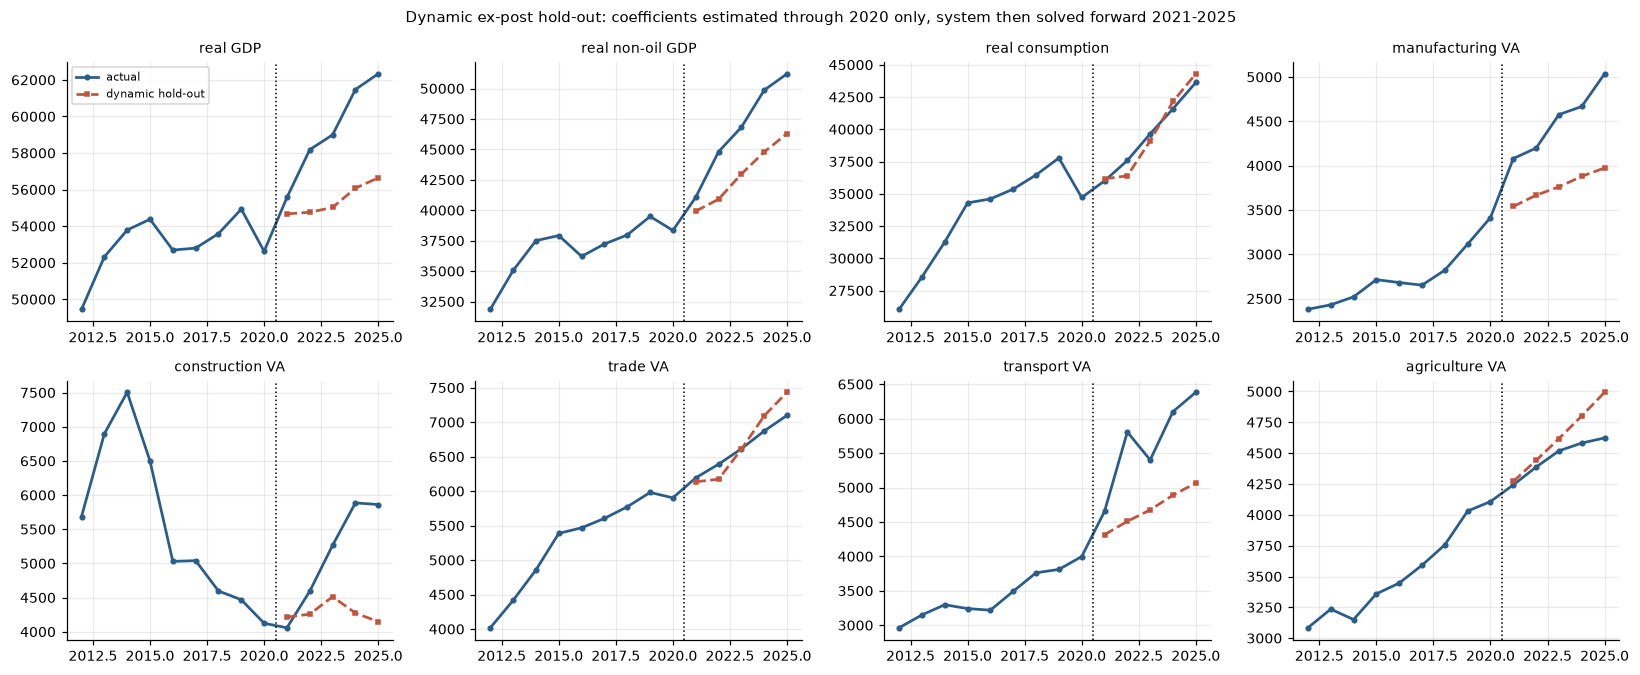

In [43]:
fig, ax = plt.subplots(2, 4, figsize=(15, 6.2))
for i, (k, lbl) in enumerate(list(TARGETS.items())[:8]):
    a = ax[i//4, i%4]
    hist = D[k].loc[2012:LAST_ACT]
    a.plot(hist.index, hist.values, 'o-', color=PAL[0], lw=1.8, ms=3, label='actual')
    a.plot(HO.index, HO[k].values, 's--', color=PAL[1], lw=1.8, ms=3, label='dynamic hold-out')
    a.axvline(CUT+.5, color='k', ls=':', lw=1); a.set_title(lbl, fontsize=9)
    if i == 0: a.legend(fontsize=7)
plt.suptitle(f'Dynamic ex-post hold-out: coefficients estimated through {CUT} only, '
             f'system then solved forward {CUT+1}-{LAST_ACT}', fontsize=10)
plt.tight_layout(); plt.show()

## Part 12 — Nowcasting 2026 from year-to-date actuals

2026 is already four months observed, and discarding that would be indefensible. The cumulative monthly columns give two
independent estimators of the 2026 annual figure:

* **seasonal-share method** — YTD divided by the historical average January–April share of the full year. The standard
  deviation of that share across recent years is reported as a reliability measure.
* **year-on-year method** — last year's annual figure scaled by the YTD growth rate against the same months of 2025.

The published **real growth indices** are the more useful object, because they are already expressed as
"this period vs the same period last year" and turn out to be very stable within the year. They anchor the first forecast year
through model add-factors, so 2026 respects what has actually happened rather than only what the equations predict.

**From January–April to the full year.** The workbook carries the monthly year-to-date indices for 2021–2025, so the relation
between January–April and full-year growth can be measured. 2021 is excluded (its January–April growth is dominated by the 2020
base effect, e.g. tourism −32.8% / +99.3%). A robust (Huber) proportional bridge is estimated on 2022–2025 and compared with the
1:1 mapping by leave-one-year-out cross-validation and an HLN-corrected Diebold–Mariano test; the bridge is used only if it wins
at p < 0.10, otherwise the 1:1 mapping is used. This relates two measurements of the *same year*, not any variable's own past.

**How long the anchor lasts.** The increment to each add-factor that the anchoring requires is partial-year information. It applies
fully in 2026 and then decays geometrically with a one-year half-life (factor 0.5 a year), so by 2030 only 1/16 of it remains; the
equations' own base add-factors are unaffected.

In [44]:
def ytd_frame(var):
    y = YTD.get(var)
    if y is None or not len(y): return None
    df = pd.DataFrame({'v': y})
    df['year']  = [i[0] for i in df.index]
    df['month'] = [i[1] for i in df.index]
    return df.pivot_table(index='year', columns='month', values='v')

def nowcast(var, month):
    piv = ytd_frame(var)
    if piv is None or month not in piv.columns or NOWCAST_Y not in piv.index: return None
    cur = piv.loc[NOWCAST_Y, month]
    if not np.isfinite(cur): return None
    full  = A_RAW[var]
    share = (piv[month]/full).dropna(); share = share[share.index < NOWCAST_Y]
    if not len(share): return None
    s3 = share.tail(3).mean()
    prev = piv.loc[LAST_ACT, month] if LAST_ACT in piv.index else np.nan
    return dict(variable=var, month=month, ytd_2026=cur, ytd_2025=prev,
                yoy_pct=(cur/prev-1)*100 if np.isfinite(prev) else np.nan,
                share_method=cur/s3, yoy_method=full[LAST_ACT]*(cur/prev) if np.isfinite(prev) else np.nan,
                actual_2025=full[LAST_ACT], share_3y=s3, share_sd=share.tail(5).std())

NC = pd.DataFrame([r for r in (
    [nowcast(v, 4) for v in ['gdp_n','gdp_nonoil_n','va_ind_n','va_man_n','va_con_n','va_agr_n',
                             'va_trd_n','va_tra_n','inv_tot_n','retail_n','oil_prod','gas_prod','brent']] +
    [nowcast(v, 3) for v in ['rev_tot_n','exp_tot_n','cred_tot_n','tx_tot_usd','tm_tot_usd']]
) if r]).set_index('variable')
display(NC.round(2))

# The real growth indices: already same-period-on-same-period, and very stable within the year
RGI = {'gdp_rgi':'real GDP','gdp_nonoil_rgi':'real non-oil GDP','va_ind_rgi':'industry',
       'va_min_rgi':'mining','gdp_oil_rgi':'oil-gas GDP','va_oth_rgi':'other services',
       'va_wat_rgi':'water','nettax_rgi':'net taxes','va_serv_rgi':'services total',
       'va_goods_rgi':'goods total',
       'va_man_rgi':'manufacturing','va_con_rgi':'construction','va_agr_rgi':'agriculture',
       'va_trd_rgi':'trade','va_tra_rgi':'transport','va_ict_rgi':'ICT','va_tou_rgi':'tourism',
       'va_elc_rgi':'electricity','inv_tot_rgi':'investment','retail_rgi':'retail','cons_mkt_rgi':'consumer market'}
rows = []
for v, lbl in RGI.items():
    piv = ytd_frame(v)
    if piv is None or NOWCAST_Y not in piv.index: continue
    obs = piv.loc[NOWCAST_Y].dropna()
    rows.append(dict(sector=lbl, **{f'M{int(m)}': round(obs[m]-100, 1) for m in obs.index},
                     latest_ytd=round(obs.iloc[-1]-100, 2),
                     full_2025=round(A_RAW[v][LAST_ACT]-100, 2)))
NCG = pd.DataFrame(rows).set_index('sector')
print(f"\n{NOWCAST_Y} year-to-date REAL growth, % on the same period of {LAST_ACT}:")
display(NCG)
NOW_G = NCG.latest_ytd.to_dict()
print(f'''
What the data already say about {NOWCAST_Y}:
   growth is slowing at the aggregate level (GDP {NOW_G.get("real GDP")}% vs {NCG.full_2025.get("real GDP")}% for {LAST_ACT} as a whole),
   but the composition is sharply uneven:
     manufacturing {NOW_G.get("manufacturing"):+.1f}%   ICT {NOW_G.get("ICT"):+.1f}%   transport {NOW_G.get("transport"):+.1f}%   trade {NOW_G.get("trade"):+.1f}%
     construction {NOW_G.get("construction"):+.1f}%  while total investment is {NOW_G.get("investment"):+.1f}%

Two tensions are flagged for the user rather than smoothed away:
  1. Construction contracting sharply while investment rises implies a composition shift out of
     construction works and into equipment - which is largely imported, so it adds less to domestic
     value added per manat spent.
  2. Q1 goods exports and imports are both down heavily in USD, which the trade block will carry through
     to the current account.''')

# ---- the January-April -> full-year bridge, measured on 2021-2025 ------------------------------
br = []
for v in RGI:
    piv = ytd_frame(v)
    if piv is None or 4 not in piv.columns: continue
    for y in piv.index:
        if y < NOWCAST_Y and np.isfinite(piv.loc[y, 4]) and np.isfinite(A_RAW[v].get(y, np.nan)):
            br.append(dict(series=v, year=int(y), g_apr=piv.loc[y, 4]-100, g_full=A_RAW[v][y]-100))
BR = pd.DataFrame(br)
# Bridge estimated on the non-pandemic years only (2021 Jan-Apr growth is dominated by the 2020 base
# effect: tourism -32.8% / +99.3%) and ROBUSTLY (Huber M-estimator through the origin), then compared with
# the 1:1 mapping by leave-one-year-out cross-validation and an HLN-corrected Diebold-Mariano test on the
# pooled out-of-sample errors. It is adopted only if it wins with p < 0.10; otherwise 1:1 is used.
import statsmodels.api as _sm
BRX = BR[BR.year != 2021].reset_index(drop=True)
def _huber_slope(df):
    return float(_sm.RLM(df.g_full.values, df[['g_apr']].values, M=_sm.robust.norms.HuberT()).fit().params[0])
e_b, e_1 = [], []
for y in sorted(BRX.year.unique()):
    tr, te = BRX[BRX.year != y], BRX[BRX.year == y]
    b_ = _huber_slope(tr)
    e_b += list(te.g_full - b_*te.g_apr); e_1 += list(te.g_full - te.g_apr)
e_b, e_1 = np.array(e_b), np.array(e_1)
_d = e_b**2 - e_1**2; _n = len(_d)
BRIDGE_DM = float(_d.mean()/np.sqrt(_d.var()/_n) * np.sqrt((_n - 1)/_n))       # HLN, h = 1
BRIDGE_DM_P = float(stats.t.cdf(BRIDGE_DM, _n - 1))                              # one-sided: bridge better
BRIDGE_SLOPE = _huber_slope(BRX)
BRIDGE_CV = {'1:1 mapping': float(np.sqrt((e_1**2).mean())), 'robust bridge': float(np.sqrt((e_b**2).mean()))}
USE_BRIDGE = bool(BRIDGE_DM < 0 and BRIDGE_DM_P < .10)
BRIDGE_CHOICE = 'robust bridge' if USE_BRIDGE else '1:1 mapping'
print(f"\nJan-Apr -> full-year mapping, {BRX.series.nunique()} series x {BRX.year.nunique()} years 2022-2025 ({len(BRX)} pairs; "
      f"2021 excluded as a base-effect year)")
print(f"   robust (Huber) slope {BRIDGE_SLOPE:.3f}; leave-one-year-out RMSE: bridge {BRIDGE_CV['robust bridge']:.2f} pp, "
      f"1:1 {BRIDGE_CV['1:1 mapping']:.2f} pp; HLN-DM (bridge vs 1:1) = {BRIDGE_DM:+.2f}, one-sided p = {BRIDGE_DM_P:.3f}")
print(f"   -> {BRIDGE_CHOICE} used" + ("" if USE_BRIDGE else " (the bridge does not beat 1:1 at p < 0.10)"))
def full_year_growth(g_ytd):
    return float(BRIDGE_SLOPE*g_ytd) if USE_BRIDGE else float(g_ytd)

# Remaining uncertainty about the full year once January-April is observed: out-of-sample error of the
# chosen mapping relative to the dispersion of full-year growth (2022-25). Scales the 2026 shocks in the fans.
_e = e_b if USE_BRIDGE else e_1
NOWCAST_SCALE = float(min(1.0, np.sqrt((_e**2).mean())/BRX.g_full.std()))
print(f"   remaining full-year uncertainty: RMSE {np.sqrt((_e**2).mean()):.2f} pp vs s.d. of full-year growth "
      f"{BRX.g_full.std():.2f} pp -> 2026 shock scale {NOWCAST_SCALE:.2f}")


,month,ytd_2026,ytd_2025,yoy_pct,share_method,yoy_method,actual_2025,share_3y,share_sd
variable,,,,,,,,,
gdp_n,4,"39,875.100","39,305.800",1.450,"129,357.910","130,963.780","129,094.000",0.310,0.020
gdp_nonoil_n,4,"27,740.100","26,449.500",4.880,"98,029.110","96,811.210","92,307.100",0.280,0.000
va_ind_n,4,"14,224.300","14,646.700",-2.880,"40,224.180","41,357.170","42,585.300",0.350,0.040
va_man_n,4,"2,540.000","2,232.100",13.790,"8,196.070","8,784.340","7,719.500",0.310,0.030
va_con_n,4,"1,937.800","2,322.900",-16.580,"7,338.440","7,029.190","8,426.100",0.260,0.020
va_agr_n,4,"1,407.300","1,302.500",8.050,"8,453.600","8,264.550","7,649.100",0.170,0.010
va_trd_n,4,"4,242.000","3,887.200",9.130,"15,730.200","15,960.100","14,625.200",0.270,0.000
va_tra_n,4,"2,893.200","2,738.200",5.660,"9,765.740","9,621.670","9,106.200",0.300,0.010
inv_tot_n,4,"5,275.000","5,069.300",4.060,"22,923.450","22,087.400","21,226.100",0.230,0.010



2026 year-to-date REAL growth, % on the same period of 2025:


,M1,M2,M3,M4,latest_ytd,full_2025
sector,,,,,,
real GDP,1.700,0.300,-0.300,0.200,0.200,1.400
real non-oil GDP,2.300,1.400,0.200,0.700,0.700,2.700
industry,2.600,0.400,0.200,0.600,0.600,-0.800
mining,2.600,0.300,-0.700,-0.400,-0.400,-2.500
oil-gas GDP,0.600,-1.700,-1.200,-0.900,-0.900,-1.600
other services,1.000,0.800,0.300,0.500,0.500,1.200
water,-5.700,-6.600,-3.100,-0.800,-0.800,2.500
net taxes,0.100,-0.500,-0.500,0.300,0.300,3.300
services total,3.100,2.100,1.800,2.400,2.400,3.100



What the data already say about 2026:
   growth is slowing at the aggregate level (GDP 0.2% vs 1.4% for 2025 as a whole),
   but the composition is sharply uneven:
     manufacturing +6.2%   ICT +9.0%   transport +4.5%   trade +3.7%
     construction -19.0%  while total investment is +14.9%

Two tensions are flagged for the user rather than smoothed away:
  1. Construction contracting sharply while investment rises implies a composition shift out of
     construction works and into equipment - which is largely imported, so it adds less to domestic
     value added per manat spent.
  2. Q1 goods exports and imports are both down heavily in USD, which the trade block will carry through
     to the current account.

Jan-Apr -> full-year mapping, 21 series x 4 years 2022-2025 (84 pairs; 2021 excluded as a base-effect year)
   robust (Huber) slope 0.683; leave-one-year-out RMSE: bridge 3.94 pp, 1:1 6.39 pp; HLN-DM (bridge vs 1:1) = -1.16, one-sided p = 0.126
   -> 1:1 mapping used (the bri

In [45]:
# 2026 add-factors: reconcile the model's first forecast year with the observed YTD real growth.
# An add-factor is a transparent log-additive adjustment, reported here rather than hidden.
ANCHOR = {'rva_man':'manufacturing','rva_con':'construction','rva_agr':'agriculture',
          'rva_trd':'trade','rva_tra':'transport','rva_ict':'ICT','rva_tou':'tourism',
          'rva_elc':'electricity','rcons':'consumer market',
          'rva_min':'mining','rgdpoil':'oil-gas GDP','rva_oth':'other services',
          'rva_wat':'water','rva_nettax':'net taxes'}
# With all twelve GDP components anchored, the model's own chain-linked aggregate for the
# partly-observed year can be checked against the PUBLISHED aggregate index - a genuine
# consistency test of both the anchoring and the aggregator.
NOWCAST_TARGET = {}
for k, lbl in ANCHOR.items():
    if lbl in NOW_G and np.isfinite(NOW_G[lbl]):
        NOWCAST_TARGET[k] = float(D[k][LAST_ACT]*(1 + full_year_growth(NOW_G[lbl])/100))
# Hydrocarbon VOLUMES for the partly-observed year come from the outturn, not from the
# scenario's assumed decline rate: for 2026 the data are better information than an assumption.
# The scenario's decline rates then apply from the following year.
HC_NOWCAST = {}
for v in ['oil_prod','gas_prod']:
    r = nowcast(v, 3)
    if r: HC_NOWCAST[v] = float(r['share_method'])
print(f"{NOWCAST_Y} hydrocarbon volumes implied by year-to-date outturn:")
for v, val in HC_NOWCAST.items():
    print(f"   {v:<10} {val:8.3f}   ({LAST_ACT} actual {D[v][LAST_ACT]:8.3f}, "
          f"implied change {(val/D[v][LAST_ACT]-1)*100:+.2f}%)")
print("   -> these replace the assumed first-year decline; assumptions resume from "
      f"{NOWCAST_Y+1}.\n")

print(f"{NOWCAST_Y} targets implied by year-to-date actuals (2015-price levels, mln AZN):")
display(pd.DataFrame({'2025 actual': {k: D[k][LAST_ACT] for k in NOWCAST_TARGET},
                      'Jan-Apr growth %': {k: NOW_G[ANCHOR[k]] for k in NOWCAST_TARGET},
                      f'{NOWCAST_Y} target': NOWCAST_TARGET,
                      'implied full-year growth %': {k: (NOWCAST_TARGET[k]/D[k][LAST_ACT]-1)*100
                                           for k in NOWCAST_TARGET}}).round(2))

2026 hydrocarbon volumes implied by year-to-date outturn:
   oil_prod     26.374   (2025 actual   27.680, implied change -4.72%)
   gas_prod     50.381   (2025 actual   50.916, implied change -1.05%)
   -> these replace the assumed first-year decline; assumptions resume from 2027.

2026 targets implied by year-to-date actuals (2015-price levels, mln AZN):


,2025 actual,Jan-Apr growth %,2026 target,implied full-year growth %
rva_man,"5,036.160",6.200,"5,348.400",6.200
rva_con,"5,862.440",-19.000,"4,748.580",-19.000
rva_agr,"4,623.350",2.000,"4,715.820",2.000
rva_trd,"7,099.490",3.700,"7,362.170",3.700
rva_tra,"6,383.220",4.500,"6,670.470",4.500
rva_ict,"2,771.430",9.000,"3,020.860",9.000
rva_tou,"2,038.880",2.500,"2,089.850",2.500
rva_elc,877.370,-2.900,851.930,-2.900
rcons,"43,630.560",4.600,"45,637.560",4.600
rva_min,"12,128.200",-0.400,"12,079.680",-0.400


## Part 13 — Scenarios and the 2026–2030 forecast

### 13.1 Why the forecast is scenario-conditional by construction

Because hydrocarbons are exogenous, there is no such thing as an unconditional forecast for this economy. That is a feature of
the structural approach, not a limitation of it: it forces the assumptions into the open, where they can be argued with.

Each scenario is a complete set of exogenous paths, calibrated on the observed 2025 starting point. Population grows at its
2021–2025 average rate (computed in the code), oil-sector investment moves with the oil-output path, and pensions are indexed
to CPI:
Brent 69.1 USD/bbl, oil output 27.68 mt (−4.9% p.a. since 2019), gas output 50.92 bcm (already down to +1.0% growth in 2025,
i.e. plateau), exchange rate 1.70, policy rate 6.75%.

| Driver | Baseline | Adverse | Reform |
|---|---|---|---|
| Brent by 2030 | ~66 USD/bbl | ~48 USD/bbl | ~80 USD/bbl |
| Oil output | −4.5% p.a., decelerating | −6.5% p.a. | −3.0% p.a. |
| Gas output | +1.0% p.a. (plateau) | flat | +4.0% p.a. (Absheron, new capacity) |
| Gas export price | drifts to 300 USD/kcm | 230 | 380 |
| State investment (real), policy level | +1.5% p.a. | −4% p.a. | +5% p.a. |
| Policy rate | eases to 6.0% | tightens to 8.5% | 6.0% |
| Exchange rate | 1.70 (peg held) | 1.70 (peg held, stress noted) | 1.70 |
| External demand | +3% p.a. | +0.5% p.a. | +5% p.a. |
| Non-oil TFP | historical trend | historical trend | +0.4 log points a year from 2027 on the supply-side sectors (agr, man, elc, wat, tra, ict); tourism and other services are demand-driven equations and receive none |

**On public investment.** It is set here as a **policy level** (the row above), while oil-revenue *deviations* from each
scenario's own reference path move it with the elasticity estimated in equation F4. This separation is deliberate. Applying the
estimated resource rule mechanically over a declining-oil horizon cuts real public investment by roughly 30% by 2030 and
generates a surplus near 3% of GDP — that is a projection of pro-cyclical austerity, not a neutral baseline, and not what a
country holding a sovereign wealth fund would be expected to do. Stating the level as policy keeps the assumption visible and
arguable, while preserving the oil-price transmission channel in full for the multiplier experiments in Part 14.

In [46]:
FY = list(range(NOWCAST_Y, H_END+1))
# Population: the 2021-2025 average growth rate, computed from the data (not assumed). The same
# rate is used by FR4 and FR5, which read the `pop` column (thousand persons) of FR1_forecast_full.csv.
POP_G = float((POP[LAST_ACT]/POP[LAST_ACT-5])**(1/5) - 1)
print(f"population growth assumption: {POP_G*100:.3f}% p.a. (2021-2025 average, from GDP / GDP per capita)")

def build_scenario(name, brent_path, oil_g, gas_g, gasprice_path, istate_g, polrate_path,
                   extdem_g, fx_path, tfp_boost=0.0, minwage_g=0.05, deprate_path=None):
    '''Assemble a full set of exogenous paths for the forecast years.'''
    ex = {}
    last = {k: float(D[k][LAST_ACT]) for k in
            ['oil_prod','gas_prod','rinv_state','rinv_oil','minwage','fx','npl_ratio',
             'dollarization','oil_exp_vol','gas_exp_vol']}
    oil, gas, mw = last['oil_prod'], last['gas_prod'], last['minwage']
    istate = last['rinv_state']              # policy LEVEL for real public investment
    deprate_path = deprate_path or [float(D.deprate[LAST_ACT])]*len(FY)
    pop = float(POP[LAST_ACT]); fx_prev = float(D.fx[LAST_ACT])
    brent_prev = float(D.brent[LAST_ACT])
    for i, y in enumerate(FY):
        if i == 0 and HC_NOWCAST:                 # first year: use the observed outturn
            oil = HC_NOWCAST.get('oil_prod', oil*(1 + oil_g[0]))
            gas = HC_NOWCAST.get('gas_prod', gas*(1 + gas_g[0]))
        else:
            oil *= (1 + oil_g[i]); gas *= (1 + gas_g[i])
        istate *= (1 + istate_g[i]); mw *= (1 + minwage_g)
        pop    *= (1 + POP_G)                            # 2021-25 average growth, computed above
        fx     = fx_path[i]; br = brent_path[i]
        ex[y] = dict(brent=br, oil_prod=oil, gas_prod=gas,
                     oil_exp_vol=oil*CAL['oil_exp_ratio'], gas_exp_vol=gas*CAL['gas_exp_ratio'],
                     gas_exp_price=gasprice_path[i], pop=pop, fx=fx, polrate=polrate_path[i],
                     deprate=deprate_path[i], istate_level=istate, istate_add=0.0,
                     oilrev_ref=None, istate_mode='policy',
                     # oil-sector investment moves with the oil-output path, compounded year on year
                     rinv_oil=last['rinv_oil']*oil/last['oil_prod'],
                     npl_ratio=last['npl_ratio'], dollarization=last['dollarization'],
                     minwage=mw, dln_fx=(np.log(fx)-np.log(fx_prev))*100,
                     dln_oil_azn=(np.log(br*fx)-np.log(brent_prev*fx_prev))*100,
                     trend=float(y-2000), extdem=(1+extdem_g)**(i+1), tfp_boost=tfp_boost,
                     tfp_years=float(y-NOWCAST_Y), pension=None, pension_real_g=0.0)
        fx_prev, brent_prev = fx, br
    return ex

n = len(FY)
SCEN = {
 'Baseline': build_scenario('Baseline',
    brent_path=[68., 66., 65., 65., 66.][:n], oil_g=[-.045,-.042,-.038,-.035,-.030][:n],
    gas_g=[.010]*n, gasprice_path=[340., 325., 312., 305., 300.][:n],
    istate_g=[.015]*n, polrate_path=[6.5, 6.25, 6.0, 6.0, 6.0][:n],
    deprate_path=[9.2, 9.0, 8.8, 8.8, 8.8][:n], extdem_g=.03, fx_path=[1.70]*n),
 'Adverse': build_scenario('Adverse',
    brent_path=[60., 52., 48., 48., 48.][:n], oil_g=[-.065]*n, gas_g=[.0]*n,
    gasprice_path=[300., 260., 235., 230., 230.][:n], istate_g=[-.04]*n,
    polrate_path=[7.5, 8.5, 8.5, 8.0, 7.5][:n],
    deprate_path=[10.0, 11.0, 11.0, 10.5, 10.0][:n], extdem_g=.005, fx_path=[1.70]*n),
 'Reform': build_scenario('Reform',
    brent_path=[70., 74., 77., 79., 80.][:n], oil_g=[-.030]*n, gas_g=[.040]*n,
    gasprice_path=[350., 360., 370., 375., 380.][:n], istate_g=[.05]*n,
    polrate_path=[6.25, 6.0, 6.0, 6.0, 6.0][:n], extdem_g=.05, fx_path=[1.70]*n,
    tfp_boost=.004),
}
rows = []
for nm, ex in SCEN.items():
    for y in FY:
        rows.append(dict(scenario=nm, year=y, brent=ex[y]['brent'], oil_mt=ex[y]['oil_prod'],
                         gas_bcm=ex[y]['gas_prod'], gas_price=ex[y]['gas_exp_price'],
                         state_inv_policy=ex[y]['istate_level'], polrate=ex[y]['polrate'],
                         deprate=ex[y]['deprate'],
                         pop_thou=ex[y]['pop'], extdem=ex[y]['extdem'], rinv_oil=ex[y]['rinv_oil'],
                         tfp_boost_cum=ex[y]['tfp_boost']*ex[y]['tfp_years']))
SCT = pd.DataFrame(rows).set_index(['scenario','year'])
display(SCT.round(2))
print(f"starting point {LAST_ACT}: Brent {D.brent[LAST_ACT]:.1f}, oil {D.oil_prod[LAST_ACT]:.2f} mt, "
      f"gas {D.gas_prod[LAST_ACT]:.2f} bcm, gas price {D.gas_exp_price[LAST_ACT]:.0f} USD/kcm")

population growth assumption: 0.483% p.a. (2021-2025 average, from GDP / GDP per capita)


brent  oil_mt  gas_bcm  gas_price  state_inv_policy  polrate  deprate   pop_thou  extdem  rinv_oil  tfp_boost_cum
scenario year                                                                                                                   
Baseline 2026 68.000  26.370   50.380    340.000         7,133.890    6.500    9.200 10,293.230   1.030 3,165.460          0.000
         2027 66.000  25.270   50.890    325.000         7,240.900    6.250    9.000 10,342.920   1.060 3,032.510          0.000
         2028 65.000  24.310   51.390    312.000         7,349.510    6.000    8.800 10,392.860   1.090 2,917.280          0.000
         2029 65.000  23.460   51.910    305.000         7,459.750    6.000    8.800 10,443.040   1.130 2,815.170          0.000
         2030 66.000  22.750   52.430    300.000         7,571.650    6.000    8.800 10,493.460   1.160 2,730.720          0.000
Adverse  2026 60.000  26.370   50.380    300.000         6,747.320    7.500   10.000 10,293.230   1.000 3,165.460          0.000
         2027 52.000  24.660   50.380    260.000         6,477.430    8.500   11.000 10,342.920   1.010 2,959.710          0.000
         2028 48.000  23.060   50.380    235.000         6,218.330    8.500   11.000 10,392.860   1.020 2,767.320          0.000
         2029 48.000  21.560   50.380    230.000         5,969.600    8.000   10.500 10,443.040   1.020 2,587.450          0.000
         2030 48.000  20.160   50.380    230.000         5,730.820    7.500   10.000 10,493.460   1.030 2,419.260          0.000
Reform   2026 70.000  26.370   50.380    350.000         7,379.880    6.250    9.360 10,293.230   1.050 3,165.460          0.000
         2027 74.000  25.580   52.400    360.000         7,748.880    6.000    9.360 10,342.920   1.100 3,070.500          0.000
         2028 77.000  24.820   54.490    370.000         8,136.320    6.000    9.360 10,392.860   1.160 2,978.380          0.010
         2029 79.000  24.070   56.670    375.000         8,543.140    6.000    9.360 10,443.040   1.220 2,889.030          0.010
         2030 80.000  23.350   58.940    380.000         8,970.300    6.000    9.360 10,493.460   1.280 2,802.360          0.020

starting point 2025: Brent 69.1, oil 27.68 mt, gas 50.92 bcm, gas price 350 USD/kcm


In [47]:
def run_forecast(ex_path, anchor=True, addf_extra=None, cf=None, cal=None, oilrev_ref=None,
                 addf_fixed=None, base_decay=None, base_addf=None):
    '''Solve the system forward over the scenario horizon; returns (forecast, convergence,
    per-year add-factor path, oil-revenue reference path).
    Add-factors: each equation's base add-factor (own residual in 2025) is held constant (or,
    in the sensitivity, decays at rate rho per year via `base_decay`); the INCREMENT required
    to hit the 2026 year-to-date anchors applies fully in 2026 and decays by ANCHOR_DECAY per year.
    `addf_fixed` (a per-year path) makes a shock run reuse the baseline's add-factors exactly.'''
    global CF, CAL
    keep_cf, keep_cal = CF, CAL
    if cf is not None:  CF = cf
    if cal is not None: CAL = cal
    try:
        prev = state_from_actual(LAST_ACT)
        if addf_fixed is not None:
            path = {y: dict(addf_fixed[y]) for y in FY}
        else:
            base = dict(BASE_ADDF if base_addf is None else base_addf)
            if addf_extra: base.update({k: base.get(k, 0.0)+v for k, v in addf_extra.items()})
            def base_y(y):
                if base_decay is None: return dict(base)
                return {k: v*base_decay.get(k, 1.0)**(y-LAST_ACT) for k, v in base.items()}
            inc = {}
            if anchor:
                # iterate the anchoring: the system is simultaneous, so one step does not hit the targets
                for _ in range(20):
                    a0 = base_y(NOWCAST_Y)
                    for k, v in inc.items(): a0[k] = a0.get(k, 0.0) + v
                    sol0, _, _ = solve_year(prev, ex_path[NOWCAST_Y], addf=a0)
                    worst = 0.0
                    for k, tgt in NOWCAST_TARGET.items():
                        if k in sol0 and sol0[k] > 0:
                            d = np.log(tgt/sol0[k]); inc[k] = inc.get(k, 0.0) + 0.7*d
                            worst = max(worst, abs(d))
                    if worst < 1e-8: break
            path = {}
            for y in FY:
                a = base_y(y)
                for k, v in inc.items(): a[k] = a.get(k, 0.0) + v*ANCHOR_DECAY**(y-NOWCAST_Y)
                path[y] = a
        # pass 1 (only when no reference is supplied): public investment follows the policy
        # level, and the resulting real oil revenue becomes this scenario's reference path
        if oilrev_ref is None:
            p2, out2 = dict(prev), {}
            for y in FY:
                s2, _, _ = solve_year(p2, ex_path[y], addf=path[y])
                out2[y] = s2; p2 = dict(s2)
            ref = {y: out2[y]['rev_oil_n']/out2[y]['p_gdp'] for y in FY}
        else:
            ref = oilrev_ref
        for y in FY: ex_path[y]['oilrev_ref'] = ref[y]
        out, conv = {}, {}
        for y in FY:
            sol, it, err = solve_year(prev, ex_path[y], addf=path[y])
            out[y] = dict(sol); conv[y] = (it, err); prev = dict(sol)
        return pd.DataFrame(out).T, conv, path, ref
    finally:
        CF, CAL = keep_cf, keep_cal

FC, CONV, ADDF, OILREF = {}, {}, {}, {}
for nm, ex in SCEN.items():
    FC[nm], CONV[nm], ADDF[nm], OILREF[nm] = run_forecast(ex)
    print(f"{nm:<9} solved; iterations by year: "
          f"{ {y: CONV[nm][y][0] for y in FY} }  max residual "
          f"{max(CONV[nm][y][1] for y in FY):.1e}")
print(f"\nDoes the anchored {NOWCAST_Y} match what the year-to-date data imply?")
anch = pd.DataFrame({'target from YTD': NOWCAST_TARGET,
                     'model (anchored)': {k: FC['Baseline'][k][NOWCAST_Y] for k in NOWCAST_TARGET}})
anch['error %'] = (anch['model (anchored)']/anch['target from YTD']-1)*100
anch['implied growth %'] = [(NOWCAST_TARGET[k]/D[k][LAST_ACT]-1)*100 for k in anch.index]
display(anch.round(3))
print(f"max |error| against the year-to-date targets: {anch['error %'].abs().max():.3f}%")

# Consistency check: does the model's chain-linked aggregate match the published index?
pub = {'real GDP': NOW_G.get('real GDP'), 'real non-oil GDP': NOW_G.get('real non-oil GDP')}
mod = {'real GDP': (FC['Baseline'].rgdp[NOWCAST_Y]/D.rgdp[LAST_ACT]-1)*100,
       'real non-oil GDP': (FC['Baseline'].rgdpnon[NOWCAST_Y]/D.rgdpnon[LAST_ACT]-1)*100}
cc = pd.DataFrame({'published YTD growth %': pub, 'model 2026 growth %': mod})
cc['difference pp'] = cc['model 2026 growth %'] - cc['published YTD growth %']
print(f"\nAggregate consistency check for {NOWCAST_Y} (all twelve components anchored):")
display(cc.round(3))
print('''The published aggregate is a year-to-date index while the model produces a full-year figure,
so a small difference is expected. A LARGE difference would mean the sector anchors and the
published aggregate disagree, which would be a data issue worth raising with the source.''')
ANCHOR_INC = {k: ADDF['Baseline'][NOWCAST_Y].get(k, 0.0) - BASE_ADDF.get(k, 0.0) for k in NOWCAST_TARGET}
print("\nanchor increments (log points), applied fully in 2026 and decaying x0.5 a year:")
display(pd.DataFrame({'increment 2026': ANCHOR_INC,
                      'remaining 2030': {k: v*ANCHOR_DECAY**(H_END-NOWCAST_Y) for k, v in ANCHOR_INC.items()}})
        .sort_values('increment 2026', key=np.abs, ascending=False).round(4))

# Sensitivity (decision 4): base add-factors decay at each equation's residual autocorrelation rho
RHO = {v: float(np.clip(pd.Series(RESID_OF[e]).dropna().autocorr(1), 0, 1)) for v, e in EQ_OF_VAR.items() if e in RESID_OF}
SENS = {}
for nm, ex in SCEN.items():
    fc_s, _, _, _ = run_forecast({y: dict(ex[y]) for y in FY}, base_decay=RHO)
    SENS[nm] = fc_s
SENS_TAB = pd.DataFrame({nm: {
    'real GDP, constant base add-factors': ((FC[nm].rgdp[H_END]/D.rgdp[LAST_ACT])**(1/len(FY))-1)*100,
    'real GDP, base add-factors decay at rho': ((SENS[nm].rgdp[H_END]/D.rgdp[LAST_ACT])**(1/len(FY))-1)*100,
    'non-oil GDP, constant base add-factors': ((FC[nm].rgdpnon[H_END]/D.rgdpnon[LAST_ACT])**(1/len(FY))-1)*100,
    'non-oil GDP, base add-factors decay at rho': ((SENS[nm].rgdpnon[H_END]/D.rgdpnon[LAST_ACT])**(1/len(FY))-1)*100}
    for nm in SCEN})
print("\nSensitivity: average growth 2026-2030 (% p.a.) with base add-factors held vs decaying at rho:")
display(SENS_TAB.round(2))
print("residual autocorrelations used:", {k: round(v, 2) for k, v in RHO.items()})

Baseline  solved; iterations by year: {2026: 63, 2027: 69, 2028: 70, 2029: 71, 2030: 72}  max residual 9.0e-11


Adverse   solved; iterations by year: {2026: 65, 2027: 67, 2028: 67, 2029: 66, 2030: 67}  max residual 9.2e-11


Reform    solved; iterations by year: {2026: 63, 2027: 70, 2028: 72, 2029: 76, 2030: 73}  max residual 9.2e-11

Does the anchored 2026 match what the year-to-date data imply?


,target from YTD,model (anchored),error %,implied growth %
rva_man,"5,348.404","5,348.868",0.009,6.200
rva_con,"4,748.580","4,749.331",0.016,-19.000
rva_agr,"4,715.816","4,715.816",0.000,2.000
rva_trd,"7,362.167","7,371.217",0.123,3.700
rva_tra,"6,670.466","6,670.466",-0.000,4.500
rva_ict,"3,020.860","3,020.900",0.001,9.000
rva_tou,"2,089.850","2,092.648",0.134,2.500
rva_elc,851.930,851.955,0.003,-2.900
rcons,"45,637.563","45,673.441",0.079,4.600
rva_min,"12,079.684","12,079.684",-0.000,-0.400


max |error| against the year-to-date targets: 0.134%

Aggregate consistency check for 2026 (all twelve components anchored):


...

The published aggregate is a year-to-date index while the model produces a full-year figure,
so a small difference is expected. A LARGE difference would mean the sector anchors and the
published aggregate disagree, which would be a data issue worth raising with the source.

anchor increments (log points), applied fully in 2026 and decaying x0.5 a year:


,increment 2026,remaining 2030
rva_con,-0.202,-0.013
rva_elc,-0.058,-0.004
rva_man,0.051,0.003
rva_min,0.040,0.003
rgdpoil,0.040,0.003
rva_nettax,-0.038,-0.002
rcons,0.038,0.002
rva_wat,-0.034,-0.002
rva_agr,-0.018,-0.001
rva_oth,-0.012,-0.001



Sensitivity: average growth 2026-2030 (% p.a.) with base add-factors held vs decaying at rho:


,Baseline,Adverse,Reform
"real GDP, constant base add-factors",2.560,1.510,3.500
"real GDP, base add-factors decay at rho",2.100,1.100,3.010
"non-oil GDP, constant base add-factors",4.180,3.070,5.260
"non-oil GDP, base add-factors decay at rho",3.670,2.620,4.700


residual autocorrelations used: {'rva_agr': 0.52, 'rva_min': 0.73, 'rva_man': 0.37, 'rva_elc': 0.47, 'rva_wat': 0.56, 'rva_con': 0.62, 'rva_trd': 0.9, 'rva_tou': 0.41, 'rva_tra': 0.54, 'rva_ict': 0.56, 'rva_oth': 0.47, 'rva_nettax': 0.79, 'rcons': 0.9, 'rinv_non': 0.0, 'rx_non': 0.0, 'rm_non': 0.0, 'emp': 0.83, 'lf': 0.67, 'wage': 0.77, 'rhhdisp': 0.89, 'rcred_tot': 0.59, 'rcred_hh': 0.78, 'rdep_tot': 0.65, 'lendrate': 0.41, 'infl': 0.31, 'rgdpoil': 0.77, 'rev_oil_n': 0.27, 'rrev_nonoil': 0.01, 'rexp_cur': 0.12, 'rinv_state': 0.39}


### 13.2 Forecast results — the headline aggregates

In [48]:
def growth_table(df, keys):
    g = {}
    for k in keys:
        s = pd.concat([D[k].loc[[LAST_ACT]], df[k]])
        g[k] = (s.pct_change()*100).loc[FY]
    return pd.DataFrame(g)

HEAD = {'rgdp':'real GDP','rgdpnon':'real non-oil GDP','rgdpoil':'real oil-gas GDP',
        'rcons':'real consumption','rinv_non':'real non-oil investment','emp':'employment'}
for nm in SCEN:
    print(f"===== {nm} =====")
    gt = growth_table(FC[nm], list(HEAD)).rename(columns=HEAD)
    gt['CPI inflation'] = FC[nm].infl
    gt['unemployment'] = FC[nm].unemp
    gt['budget balance % GDP'] = FC[nm].balance_n/FC[nm].gdp_n*100
    gt['public debt % GDP'] = FC[nm].debt_azn/FC[nm].gdp_n*100
    display(gt.round(2))
    a = (FC[nm].rgdp[H_END]/D.rgdp[LAST_ACT])**(1/len(FY))-1
    b = (FC[nm].rgdpnon[H_END]/D.rgdpnon[LAST_ACT])**(1/len(FY))-1
    print(f"   average annual growth {NOWCAST_Y}-{H_END}:  real GDP {a*100:+.2f}%   "
          f"real non-oil GDP {b*100:+.2f}%\n")

===== Baseline =====


,real GDP,real non-oil GDP,real oil-gas GDP,real consumption,real non-oil investment,employment,CPI inflation,unemployment,budget balance % GDP,public debt % GDP
2026,0.280,0.710,-0.900,4.680,1.470,0.540,3.400,5.180,0.720,28.300
2027,3.020,5.840,-5.530,4.020,2.460,0.700,4.910,5.010,0.430,26.000
2028,3.080,5.110,-4.220,4.280,2.320,0.680,4.700,4.870,0.260,23.920
2029,3.130,4.730,-3.460,4.300,2.250,0.670,4.590,4.730,0.220,21.940
2030,3.300,4.610,-2.750,4.420,2.230,0.660,4.550,4.600,0.260,19.970


   average annual growth 2026-2030:  real GDP +2.56%   real non-oil GDP +4.18%

===== Adverse =====


,real GDP,real non-oil GDP,real oil-gas GDP,real consumption,real non-oil investment,employment,CPI inflation,unemployment,budget balance % GDP,public debt % GDP
2026,0.260,0.690,-0.900,4.650,-3.430,0.540,3.400,5.180,0.680,29.140
2027,1.370,4.060,-7.930,1.710,-2.800,0.650,4.390,5.070,0.370,27.900
2028,1.780,3.680,-7.020,2.690,-2.870,0.630,4.290,4.970,0.450,26.090
2029,2.020,3.520,-6.560,3.210,-2.900,0.630,4.240,4.870,0.880,23.570
2030,2.130,3.420,-6.330,3.380,-2.920,0.630,4.210,4.780,1.360,20.670


   average annual growth 2026-2030:  real GDP +1.51%   real non-oil GDP +3.07%

===== Reform =====


,real GDP,real non-oil GDP,real oil-gas GDP,real consumption,real non-oil investment,employment,CPI inflation,unemployment,budget balance % GDP,public debt % GDP
2026,0.290,0.720,-0.900,4.710,4.570,0.540,3.410,5.180,0.500,28.320
2027,4.510,7.310,-3.550,5.520,5.880,0.750,5.330,4.970,0.360,25.170
2028,4.260,6.420,-2.590,5.530,5.710,0.720,5.070,4.780,0.190,22.670
2029,4.220,6.040,-2.110,5.630,5.630,0.710,4.960,4.610,-0.020,20.680
2030,4.310,5.910,-1.870,5.740,5.610,0.710,4.930,4.440,-0.240,19.090


   average annual growth 2026-2030:  real GDP +3.50%   real non-oil GDP +5.26%



In [49]:
# Sector-by-sector forecast: the core FR1 deliverable
SECG = {}
for nm in SCEN:
    gt = growth_table(FC[nm], [f'rva_{s}' for s in COMP])
    gt.columns = [SECT_LABEL[c] for c in COMP]
    SECG[nm] = gt
print("BASELINE - real value added growth by sector, % per year")
display(SECG['Baseline'].round(2).T)
print("\nCumulative real growth 2025 -> 2030 by sector and scenario (%)")
cum = pd.DataFrame({nm: {SECT_LABEL[c]: (FC[nm][f'rva_{c}'][H_END]/D[f'rva_{c}'][LAST_ACT]-1)*100
                         for c in COMP} for nm in SCEN})
cum['weight in GDP 2025 (%)'] = [NOM.div(NOM.sum(axis=1), axis=0).loc[LAST_ACT, c]*100 for c in COMP]
display(cum.sort_values('Baseline', ascending=False).round(1))

# Structural shift: how the economy's composition changes
sh25 = NOM.div(NOM.sum(axis=1), axis=0).loc[LAST_ACT]*100
sh30 = pd.Series({c: FC['Baseline'][f'p_{c}'][H_END]*FC['Baseline'][f'rva_{c}'][H_END] for c in COMP})
sh30 = sh30/sh30.sum()*100
struct30 = pd.DataFrame({'share 2025 (%)': sh25, 'share 2030 (%)': sh30,
                         'change (pp)': sh30-sh25}, index=COMP)
struct30.index = [SECT_LABEL[c] for c in COMP]
print("\nBASELINE - structural change in the economy, nominal value-added shares")
display(struct30.sort_values('change (pp)').round(2))
print(f'''
The single clearest structural result: the hydrocarbon share of the economy keeps falling
({sh25["min"]:.1f}% -> {sh30["min"]:.1f}% of value added in the baseline) not because non-oil growth is fast,
but because oil volumes decline while non-oil sectors grow modestly. Diversification here is
arithmetic as much as it is achievement - a point worth making explicitly to policy readers.''')

BASELINE - real value added growth by sector, % per year


,2026,2027,2028,2029,2030
"Agriculture, forestry & fishing",2.000,4.750,4.290,4.060,3.940
Mining & quarrying,-0.400,-5.310,-4.000,-3.260,-2.580
Manufacturing,6.210,6.850,6.860,6.900,6.970
"Electricity, gas & steam",-2.900,6.050,4.510,3.750,3.370
Water supply & waste,-0.760,7.440,6.110,5.440,5.150
Construction,-18.990,11.080,5.700,3.160,2.060
Trade & vehicle repair,3.830,4.200,4.280,4.220,4.290
Tourism & catering,2.640,13.630,11.980,11.130,10.830
Transport & storage,4.500,4.910,5.000,5.070,5.150
Information & communication,9.000,9.220,8.960,8.780,8.650



Cumulative real growth 2025 -> 2030 by sector and scenario (%)


,Baseline,Adverse,Reform,weight in GDP 2025 (%)
Tourism & catering,60.800,46.700,75.600,2.800
Information & communication,53.300,44.600,61.800,2.100
Manufacturing,38.700,16.900,62.700,6.000
Transport & storage,27.200,24.400,33.100,7.100
Water supply & waste,25.400,21.700,31.200,0.200
Trade & vehicle repair,22.600,15.900,28.900,11.300
Net taxes on products,21.900,15.300,28.000,9.600
"Agriculture, forestry & fishing",20.500,20.500,22.500,5.900
"Electricity, gas & steam",15.400,15.200,17.500,1.100
Social & other services,14.400,12.600,16.100,21.700



BASELINE - structural change in the economy, nominal value-added shares


,share 2025 (%),share 2030 (%),change (pp)
Mining & quarrying,25.650,14.340,-11.300
Construction,6.530,5.280,-1.250
Transport & storage,7.050,6.930,-0.120
Information & communication,2.070,1.980,-0.080
Water supply & waste,0.230,0.260,0.020
"Electricity, gas & steam",1.130,1.240,0.120
"Agriculture, forestry & fishing",5.930,6.120,0.190
Manufacturing,5.980,7.270,1.290
Tourism & catering,2.770,4.110,1.340
Net taxes on products,9.600,11.530,1.930



The single clearest structural result: the hydrocarbon share of the economy keeps falling
(25.6% -> 14.3% of value added in the baseline) not because non-oil growth is fast,
but because oil volumes decline while non-oil sectors grow modestly. Diversification here is
arithmetic as much as it is achievement - a point worth making explicitly to policy readers.


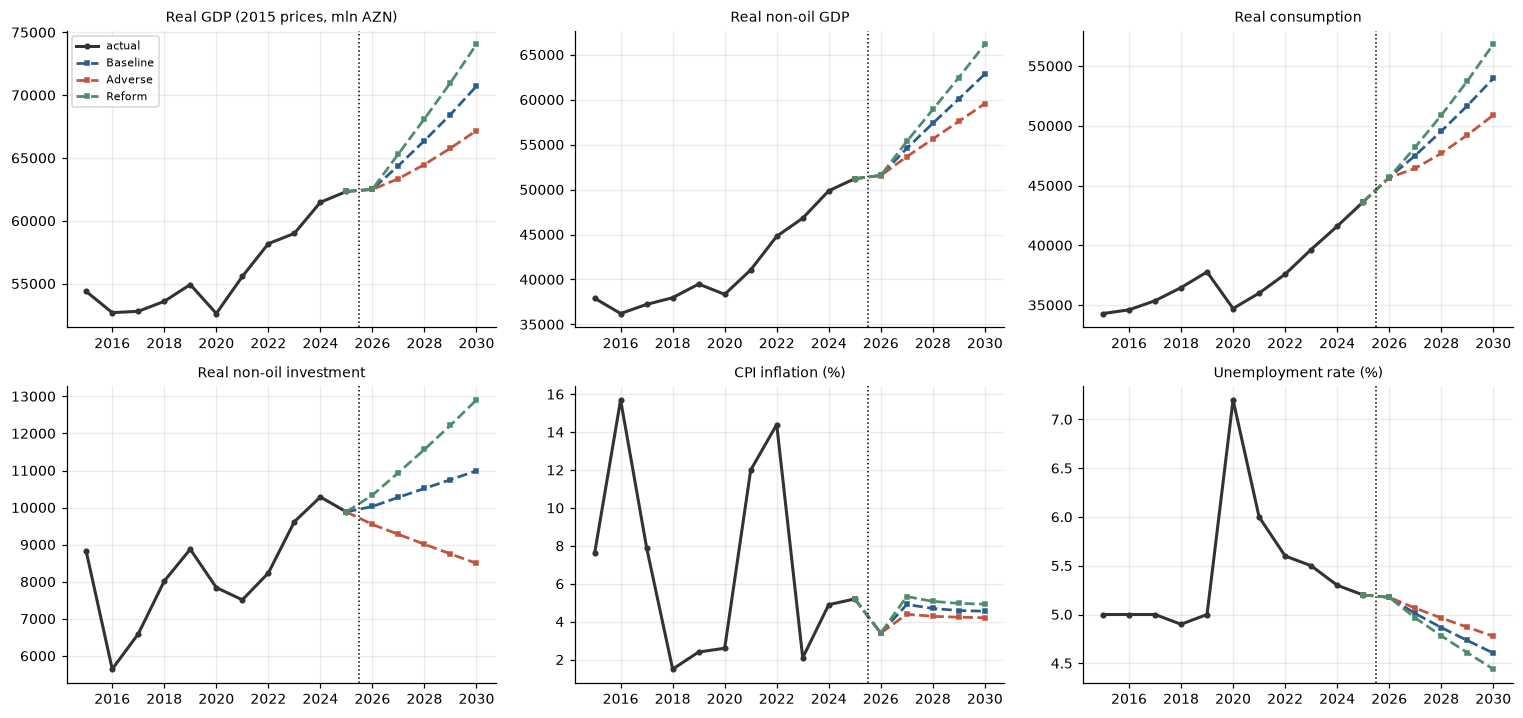

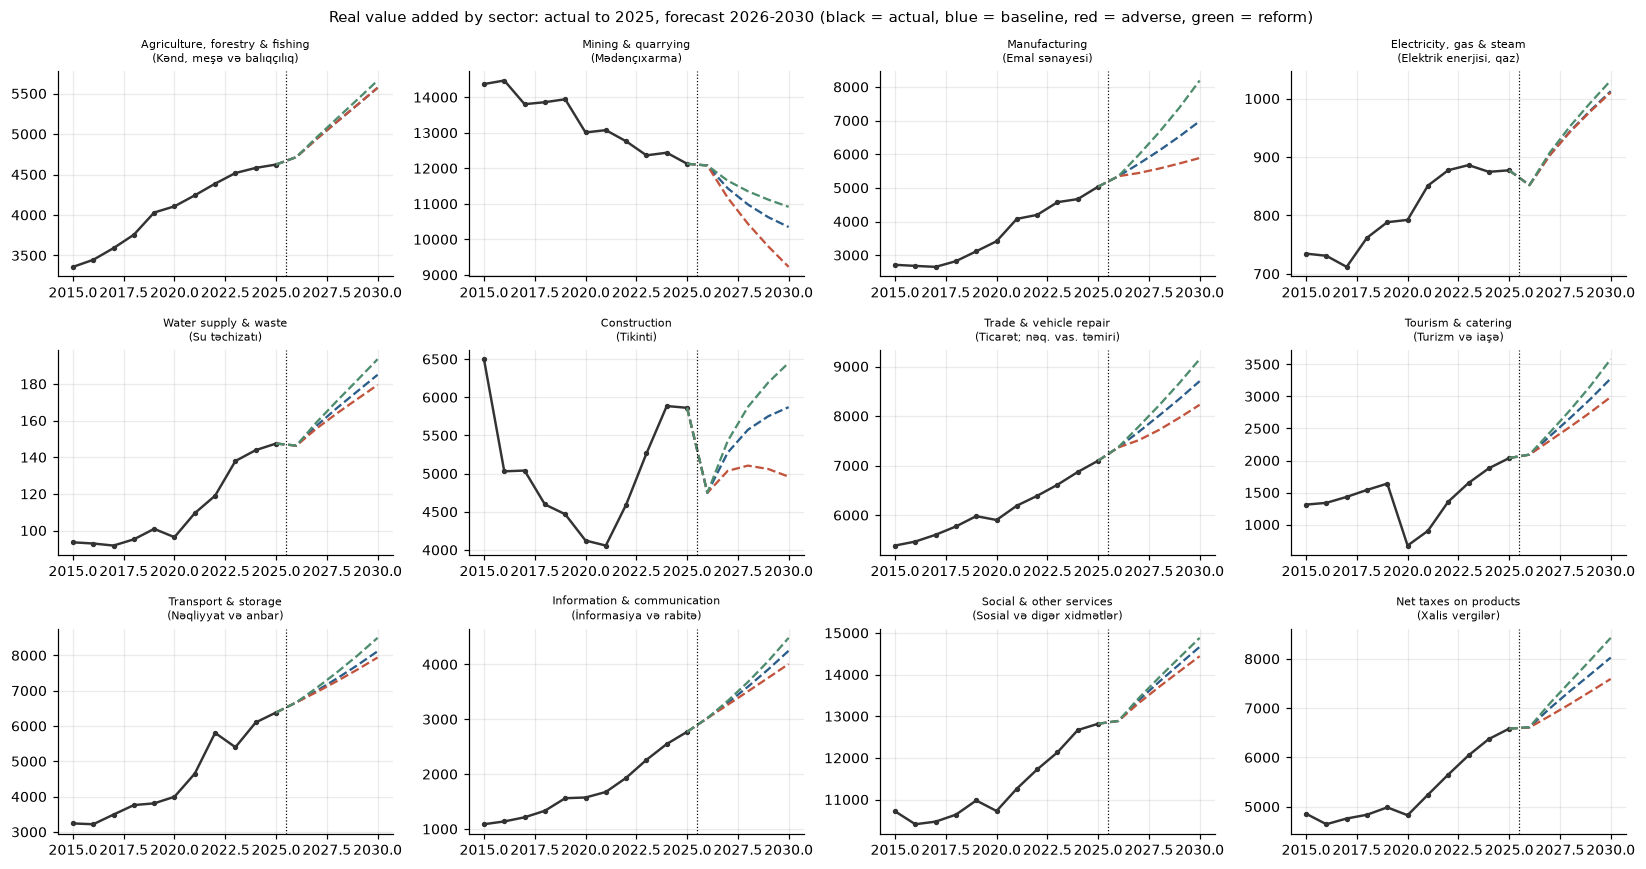

In [50]:
fig, ax = plt.subplots(2, 3, figsize=(14, 6.6))
COLS = {'Baseline': PAL[0], 'Adverse': PAL[1], 'Reform': PAL[2]}
def panel(a, key, title, pct=False):
    hist = D[key].loc[2015:LAST_ACT]
    a.plot(hist.index, hist.values, 'o-', color='#333', lw=2, ms=3, label='actual')
    for nm in SCEN:
        s = pd.concat([D[key].loc[[LAST_ACT]], FC[nm][key]])
        a.plot(s.index, s.values, 's--', color=COLS[nm], lw=1.8, ms=3, label=nm)
    a.axvline(LAST_ACT+.5, color='k', ls=':', lw=1); a.set_title(title, fontsize=9)
panel(ax[0,0], 'rgdp', 'Real GDP (2015 prices, mln AZN)'); ax[0,0].legend(fontsize=7)
panel(ax[0,1], 'rgdpnon', 'Real non-oil GDP')
panel(ax[0,2], 'rcons', 'Real consumption')
panel(ax[1,0], 'rinv_non', 'Real non-oil investment')
panel(ax[1,1], 'infl', 'CPI inflation (%)')
panel(ax[1,2], 'unemp', 'Unemployment rate (%)')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(3, 4, figsize=(15, 8))
for i, c in enumerate(COMP):
    a = ax[i//4, i%4]
    hist = D[f'rva_{c}'].loc[2015:LAST_ACT]
    a.plot(hist.index, hist.values, 'o-', color='#333', lw=1.6, ms=2.5)
    for nm in SCEN:
        s = pd.concat([D[f'rva_{c}'].loc[[LAST_ACT]], FC[nm][f'rva_{c}']])
        a.plot(s.index, s.values, '--', color=COLS[nm], lw=1.5)
    a.axvline(LAST_ACT+.5, color='k', ls=':', lw=.8)
    a.set_title(f"{SECT_LABEL[c]}\n({SECT_AZ[c]})", fontsize=7.5)
plt.suptitle('Real value added by sector: actual to 2025, forecast 2026-2030 '
             '(black = actual, blue = baseline, red = adverse, green = reform)', fontsize=10)
plt.tight_layout(); plt.show()

### 13.3 Growth decomposition — attributing every forecast number to its drivers

A forecast that cannot be explained is not usable for policy. Because each sector equation is linear in logs, the change in log
value added decomposes exactly into each driver's elasticity times that driver's change. Every number in the sector forecast can
therefore be traced to identifiable causes, including the part that is simply the estimated deterministic trend, the
scenario TFP boost and the decaying 2026 anchor.

In [51]:
# Map each solver coefficient to the forecast variable it multiplies (log changes x 100 = pp).
COEF_VAR = {'ln_K_agr':'K_agr', 'ln_K_man':'K_man', 'ln_va_con':'rva_con', 'ln_x_non':'rx_non',
            'ln_va_agr':'rva_agr', 'ln_gdpnon':'rgdpnon', 'ln_gdpnon_pc':'rgdpnon_pc',
            'ln_inv_state':'rinv_state', 'ln_inv_priv':'rinv_priv', 'ln_cons':'rcons',
            'ln_hhdisp_pc':'rhhdisp_pc', 'ln_K_ict_pc':'K_ict_pc', 'ln_m_non':'rm_non', 'trend':'trend',
            'trend_post2015':'trend_post2015', 'ln_hc':'hc', 'ln_cred':'rcred_tot'}
EQOF = {'rva_agr':'C1_agr','rva_man':'C3_man','rva_elc':'C4_elc','rva_wat':'C5_wat','rva_con':'C6_con',
        'rva_trd':'C7_trd','rva_tou':'C8_tou','rva_tra':'C9_tra','rva_ict':'C10_ict',
        'rva_oth':'C11_oth','rva_nettax':'C12_nettax'}
PERCAP = {'rva_wat', 'rva_tou', 'rva_ict', 'rva_oth'}

def decompose(nm):
    ex, f, ap = SCEN[nm], FC[nm], ADDF[nm]
    def val(y, v):
        src = f if y >= FY[0] else D
        pop_ = ex[y]['pop'] if y >= FY[0] else POP[LAST_ACT]
        if v == 'trend':      return float(y - 2000)
        if v == 'trend_post2015': return float(max(y - 2015, 0))
        if v == 'hc':         return float(ex[y]['oil_prod'] + 0.9*ex[y]['gas_prod']) if y >= FY[0] else float(D.oil_prod[LAST_ACT] + 0.9*D.gas_prod[LAST_ACT])
        if v == 'pop':        return float(pop_)
        if v.endswith('_pc'): return float(src[v[:-3]][y])/pop_
        return float(src[v][y])
    rows = []
    for var, eq in EQOF.items():
        for y in FY:
            tot = (np.log(val(y, var)) - np.log(val(y-1, var)))*100
            rec = dict(sector=SECT_LABEL[var.replace('rva_','')], year=y, total_growth=tot)
            expl = 0.0
            for cname, b in CF[eq].items():
                if cname == 'const': continue
                v = COEF_VAR[cname]
                d = (val(y, v) - val(y-1, v))*100 if v.startswith('trend') else (np.log(val(y, v)) - np.log(val(y-1, v)))*100
                key = 'trend (deterministic)' if v.startswith('trend') else v
                rec[key] = rec.get(key, 0.0) + b*d; expl += b*d
            if var in PERCAP:
                rec['population (unit elasticity)'] = (np.log(val(y, 'pop')) - np.log(val(y-1, 'pop')))*100
                expl += rec['population (unit elasticity)']
            if var.replace('rva_', '') in TFP_SECT:
                tf = lambda yy: ex[yy]['tfp_boost']*ex[yy]['tfp_years'] if yy >= FY[0] else 0.0
                rec['scenario TFP boost'] = (tf(y) - tf(y-1))*100; expl += rec['scenario TFP boost']
            a_prev = BASE_ADDF.get(var, 0.0) if y == FY[0] else ap[y-1].get(var, 0.0)
            rec['add-factor change (anchor)'] = (ap[y].get(var, 0.0) - a_prev)*100
            expl += rec['add-factor change (anchor)']
            rec['residual (interaction)'] = tot - expl
            rows.append(rec)
    return pd.DataFrame(rows)

nm = 'Baseline'
DEC = decompose(nm)
print(f"{nm} - contributions to sector real growth, percentage points per year")
for s in DEC.sector.unique():
    sub = DEC[DEC.sector == s].set_index('year').drop(columns='sector').dropna(axis=1, how='all')
    print(f"\n--- {s} ---")
    display(sub.round(2))
assert DEC['residual (interaction)'].abs().max() < 0.05, "decomposition does not add up"

# How much of each sector's 2027-2030 growth is the deterministic trend?
late = DEC[DEC.year > NOWCAST_Y].groupby('sector')[['total_growth', 'trend (deterministic)']].mean()
late['trend share of growth (%)'] = late['trend (deterministic)']/late['total_growth']*100
TREND_SHARE = late.sort_values('trend share of growth (%)', ascending=False)
display(TREND_SHARE.round(2))
TREND_DOMINATED = TREND_SHARE[TREND_SHARE['trend share of growth (%)'] > 50].index.tolist()
print(f'''HONEST READING: in {', '.join(TREND_DOMINATED)} more than half of forecast growth 2027-2030 is the
estimated deterministic trend - growth the model carries forward from the past, not growth explained by an
economic driver. (An earlier version of this table omitted the x100 on the trend contribution and so showed
it as ~0.03 pp, hiding exactly this.) Those sector paths are as good as the assumption that the historical
trend continues.''')


Baseline - contributions to sector real growth, percentage points per year

--- Agriculture, forestry & fishing ---


,total_growth,trend (deterministic),scenario TFP boost,add-factor change (anchor),residual (interaction)
year,,,,,
2026,1.980,3.750,0.000,-1.770,0.000
2027,4.640,3.750,0.000,0.890,-0.000
2028,4.200,3.750,0.000,0.440,0.000
2029,3.980,3.750,0.000,0.220,-0.000
2030,3.870,3.750,0.000,0.110,-0.000



--- Manufacturing ---


,total_growth,scenario TFP boost,add-factor change (anchor),residual (interaction),K_man,rva_con,rx_non
year,,,,,,,
2026,6.020,0.000,5.150,0.000,-0.120,-4.100,5.090
2027,6.630,0.000,-2.570,-0.000,-0.100,2.050,7.260
2028,6.640,0.000,-1.290,0.000,-0.080,1.080,6.920
2029,6.670,0.000,-0.640,0.000,-0.060,0.610,6.760
2030,6.740,0.000,-0.320,0.000,-0.030,0.400,6.700



--- Electricity, gas & steam ---


...

,total_growth,trend (deterministic),add-factor change (anchor),residual (interaction),population (unit elasticity),rhhdisp_pc
year,,,,,,
2026,0.520,1.190,-1.210,-0.000,0.480,0.060
2027,3.760,1.190,0.610,0.000,0.480,1.480
2028,3.260,1.190,0.300,0.000,0.480,1.290
2029,3.010,1.190,0.150,-0.000,0.480,1.180
2030,2.900,1.190,0.080,-0.000,0.480,1.150



--- Net taxes on products ---


,total_growth,add-factor change (anchor),residual (interaction),rcons,rm_non
year,,,,,
2026,0.420,-3.830,0.000,4.870,-0.620
2027,5.640,1.920,-0.000,4.200,-0.470
2028,4.920,0.960,0.000,4.450,-0.490
2029,4.470,0.480,-0.000,4.480,-0.490
2030,4.350,0.240,0.000,4.610,-0.490


,total_growth,trend (deterministic),trend share of growth (%)
sector,,,
Transport & storage,4.910,5.140,104.720
"Agriculture, forestry & fishing",4.170,3.750,90.030
Information & communication,8.530,6.640,77.860
"Electricity, gas & steam",4.320,2.790,64.440
Social & other services,3.230,1.190,36.830
Water supply & waste,5.860,2.050,35.010
Tourism & catering,11.230,2.840,25.270
Construction,5.300,NaN,NaN
Manufacturing,6.670,NaN,NaN


HONEST READING: in Transport & storage, Agriculture, forestry & fishing, Information & communication, Electricity, gas & steam more than half of forecast growth 2027-2030 is the
estimated deterministic trend - growth the model carries forward from the past, not growth explained by an
economic driver. (An earlier version of this table omitted the x100 on the trend contribution and so showed
it as ~0.03 pp, hiding exactly this.) Those sector paths are as good as the assumption that the historical
trend continues.


BASELINE - contribution of each sector to real GDP growth (percentage points)


,"Agriculture, forestry & fishing",Mining & quarrying,Manufacturing,"Electricity, gas & steam",Water supply & waste,Construction,Trade & vehicle repair,Tourism & catering,Transport & storage,Information & communication,Social & other services,Net taxes on products,TOTAL real GDP growth
year,,,,,,,,,,,,,
2026,0.120,-0.100,0.370,-0.030,-0.000,-1.240,0.430,0.070,0.320,0.190,0.110,0.040,0.280
2027,0.290,-1.270,0.440,0.070,0.020,0.580,0.510,0.390,0.350,0.200,0.880,0.570,3.020
2028,0.260,-0.820,0.460,0.050,0.010,0.320,0.540,0.390,0.360,0.190,0.800,0.530,3.080
2029,0.250,-0.580,0.470,0.050,0.010,0.180,0.550,0.390,0.360,0.180,0.780,0.500,3.130
2030,0.240,-0.410,0.490,0.040,0.010,0.110,0.570,0.410,0.360,0.180,0.780,0.500,3.300


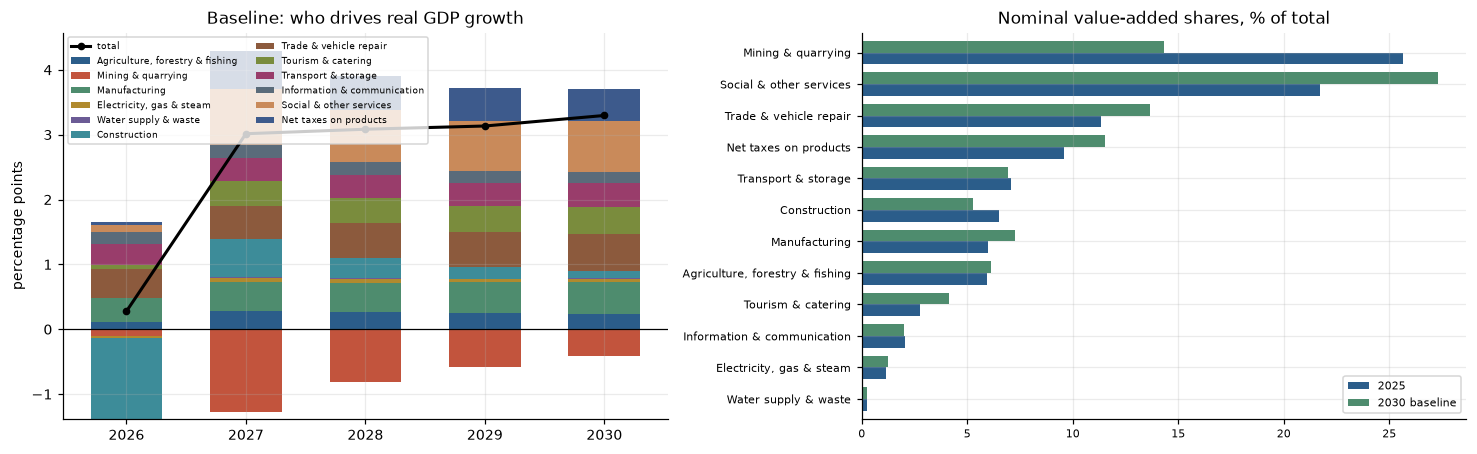

In [52]:
# Contribution of each sector to aggregate real GDP growth (chain-weighted)
nm = 'Baseline'
rows = []
for y in FY:
    prevy = y-1
    wN = {c: (D[f'p_{c}'][LAST_ACT]*D[f'rva_{c}'][LAST_ACT] if y == FY[0]
              else FC[nm][f'p_{c}'][prevy]*FC[nm][f'rva_{c}'][prevy]) for c in COMP}
    tot = sum(wN.values())
    r = {'year': y}
    for c in COMP:
        prev_v = D[f'rva_{c}'][LAST_ACT] if y == FY[0] else FC[nm][f'rva_{c}'][prevy]
        r[SECT_LABEL[c]] = (wN[c]/tot)*(FC[nm][f'rva_{c}'][y]/prev_v - 1)*100
    r['TOTAL real GDP growth'] = sum(v for k, v in r.items() if k != 'year')
    rows.append(r)
CONTRIB = pd.DataFrame(rows).set_index('year')
print("BASELINE - contribution of each sector to real GDP growth (percentage points)")
display(CONTRIB.round(2))

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.2))
cc = CONTRIB.drop(columns='TOTAL real GDP growth')
bot_pos = np.zeros(len(cc)); bot_neg = np.zeros(len(cc))
for i, c in enumerate(cc.columns):
    v = cc[c].values
    pos = np.where(v > 0, v, 0); neg = np.where(v < 0, v, 0)
    ax[0].bar(cc.index, pos, bottom=bot_pos, color=PAL[i % len(PAL)], label=c, width=.6)
    ax[0].bar(cc.index, neg, bottom=bot_neg, color=PAL[i % len(PAL)], width=.6)
    bot_pos += pos; bot_neg += neg
ax[0].plot(CONTRIB.index, CONTRIB['TOTAL real GDP growth'], 'ko-', lw=2, ms=4, label='total')
ax[0].axhline(0, color='k', lw=.8); ax[0].set_ylabel('percentage points')
ax[0].set_title('Baseline: who drives real GDP growth'); ax[0].legend(fontsize=6, ncol=2)
w = pd.DataFrame({'2025': sh25, '2030 baseline': sh30})
w.index = [SECT_LABEL[c] for c in COMP]
w.sort_values('2025').plot.barh(ax=ax[1], color=[PAL[0], PAL[2]], width=.75)
ax[1].set_title('Nominal value-added shares, % of total'); ax[1].tick_params(labelsize=7)
ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

### 13.4 Uncertainty — stochastic simulation, not a variance model

Fan charts combine three sources of uncertainty, each drawn per replication:

1. **Equation shocks — historical residual-path resampling.** A start year *s* is drawn from 2010–2020 and the joint vector of
   residual deviations e_h = u_{s+h} − u_s (h = 1…5) of all 29 shocked behavioural equations is added to the constant
   add-factors. This replays five-year stretches of history, so the empirical persistence and cross-equation correlation of the
   residuals are carried over **nonparametrically — nothing is estimated on the residual dynamics** (no ρ, no AR process). Paths
   are centred (the average path over start years is removed) and each is used with both signs (antithetic), so the shock
   distribution is symmetric around zero.
2. **Exogenous drivers**, done the same way on log levels of Brent, oil and gas output, **with the same start year** as the
   residual path, so the historical co-movement of the oil price with the fiscal residuals is preserved.
3. **Parameter uncertainty.** Each equation's coefficient vector is drawn from N(β̂, V̂_HAC) as an antithetic pair β̂ ± δ, truncated
   by rejection so that no slope changes sign in either member; base add-factors are recomputed so every drawn model reproduces
   2025.

2026 is partly observed: the first-year deviation is scaled by the remaining full-year uncertainty after January–April (Part 12;
2/3 for the exogenous drivers) and that reduction is carried through the later years. Replications that fail to converge,
produce a non-finite value, move real GDP more than 50% from the baseline, or move any variable's one-year log change more than
0.3 away from the baseline's (or 1.5× the largest one-year move the variable actually made in 2000–2025, where larger) are
counted by reason and replaced, keeping antithetic pairs whole; only converged, finite replications are exported (asserted).
The median of the replications is checked against the baseline for every variable and year. Growth-rate fans are quantiles of
per-replication growth rates. The baseline replications are exported (`FR1_fan_draws.csv`) for FR3–FR5.


residual matrix: 16 years (2010-2025) x 29 equations; 11 historical five-year residual paths (start years 2010-2020), used +/-

s.d. across paths of the 5-year residual deviation (log points; rates in pp):


,rva_agr,rva_min,rva_man,rva_elc,rva_wat,rva_con,rva_trd,rva_tou,rva_tra,rva_ict,rva_oth,rva_nettax,rcons,rinv_non,rx_non,rm_non,emp,lf,wage,rhhdisp,rcred_tot,rcred_hh,rdep_tot,lendrate,infl,rgdpoil,rev_oil_n,rrev_nonoil,rexp_cur
"sd, h=5",0.037,0.034,0.217,0.068,0.084,0.186,0.031,0.380,0.123,0.097,0.047,0.106,0.105,0.098,0.194,0.134,0.009,0.018,0.061,0.076,0.349,0.219,0.282,1.164,4.523,0.035,0.228,0.118,0.163


consistency check - correlation of the five core equations' residuals: resampling source (upper) vs 3SLS SIGMA_CORE (lower)


,rva_con,rva_trd,rva_tra,rcons,rm_non
rva_con,1.000,-0.280,0.730,-0.410,0.070
rva_trd,-0.280,1.000,0.140,0.780,-0.030
rva_tra,0.730,0.140,1.000,-0.050,-0.100
rcons,-0.410,0.780,-0.050,1.000,0.070
rm_non,0.070,-0.030,-0.100,0.070,1.000


,construction,trade,transport,consumption,imports
construction,1.000,-0.100,0.710,0.210,0.420
trade,-0.100,1.000,0.380,0.680,0.120
transport,0.710,0.380,1.000,0.320,0.360
consumption,0.210,0.680,0.320,1.000,0.320
imports,0.420,0.120,0.360,0.320,1.000


...


2030 band widths (levels):


,"5-95% width, % of median (2030)","25-75% width, % of median (2030)"
rgdp,18.200,6.600
rgdpnon,24.400,7.600
cpi,70.200,36.000
emp,8.900,4.000
rhhdisp,28.200,13.000
rcons,48.700,24.400
rexp_cur,72.000,27.600


median of the replications vs the deterministic baseline (real GDP, % difference): {2026: 0.0, 2027: 0.0, 2028: 0.0, 2029: 0.0, 2030: 0.0}
band width by year, real GDP 5-95% (% of median): {2026: 7.6, 2027: 13.0, 2028: 13.0, 2029: 13.7, 2030: 18.2}
sanity check vs the hold-out: 5-year-ahead real GDP level error in the 2021-25 hold-out was -9.1% (RMSE over the 5 years 7.0%); non-oil -9.6%. The 2030 90% band half-width is 9.1% (real GDP) and 12.2% (non-oil).


,hold-out 5-year level error 2025 (%),2030 90% band half-width (%)
rgdp,-9.100,9.100
rgdpnon,-9.600,12.200
cpi,-29.700,35.100
emp,-4.100,4.400
rhhdisp,11.300,14.100
rcons,1.500,24.300
rexp_cur,38.000,36.000


ratio of 2030 90% half-width to the hold-out 5-year error: {'rgdp': np.float64(1.0), 'rgdpnon': np.float64(1.3), 'cpi': np.float64(1.2), 'emp': np.float64(1.1), 'rhhdisp': np.float64(1.2), 'rcons': np.float64(15.7), 'rexp_cur': np.float64(0.9)}
READING: real GDP, non-oil GDP, CPI and disposable income bands are of the same order as the errors the model made
over 2021-2025. The employment band is NARROWER than the hold-out error and the consumption band much WIDER: the
former because the employment-rate equation fits history very closely, the latter because consumption amplifies
income and household-credit shocks through the simultaneous income loop. Both are reported, not tuned away.


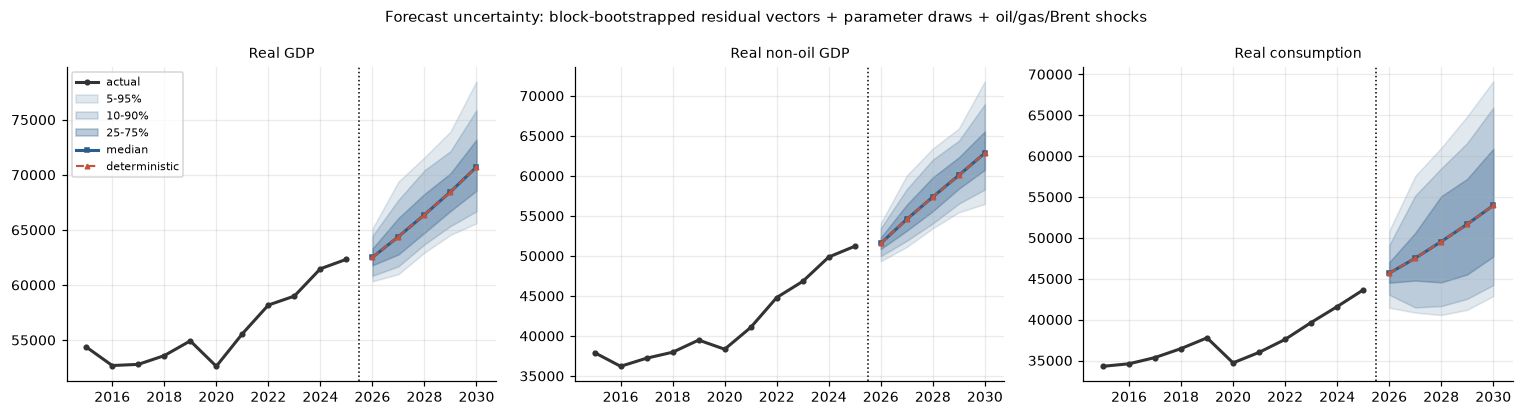

In [53]:
rng = np.random.default_rng(SEED)
FAN_EQ = {v: e for v, e in EQ_OF_VAR.items() if e in MODEL and v != 'rinv_state'}
RATE_VARS = {'infl', 'lendrate'}
RMAT = pd.DataFrame({v: RESID_OF[e] for v, e in FAN_EQ.items()}).dropna()
# HISTORICAL RESIDUAL-PATH RESAMPLING. Nothing is estimated on the residual dynamics (no rho, no AR
# process). For a replication a start year s is drawn and the joint vector of residual DEVIATIONS
#     e_h = u_{s+h} - u_s,  h = 1..5,
# of all shocked equations is added to the (constant) add-factors. This carries the empirical persistence
# and cross-equation correlation of the residuals over five-year stretches of history, nonparametrically.
# Paths are centred (the mean path over start years is subtracted, so no drift is added) and every path is
# also used with its sign reversed (antithetic), so the shock distribution is symmetric around zero.
H = len(FY)
STARTS = [s_ for s_ in RMAT.index if s_ + H in RMAT.index]
PATHS = np.stack([RMAT.loc[s_+1:s_+H].to_numpy() - RMAT.loc[s_].to_numpy() for s_ in STARTS])   # S x H x eq
PATHS = PATHS - PATHS.mean(axis=0)
cols = list(RMAT.columns)
def partial_year(p_, sc):
    '''2026 is partly observed: scale the first-year deviation by sc and carry that reduction forward.'''
    q = p_.copy(); q[0] = sc*p_[0]; q[1:] = p_[1:] - (1 - sc)*p_[0]
    return q
print(f"residual matrix: {RMAT.shape[0]} years ({RMAT.index.min()}-{RMAT.index.max()}) x {RMAT.shape[1]} equations; "
      f"{len(STARTS)} historical five-year residual paths (start years {STARTS[0]}-{STARTS[-1]}), used +/-")
print("\ns.d. across paths of the 5-year residual deviation (log points; rates in pp):")
display(pd.Series(PATHS[:, -1, :].std(axis=0), index=cols).round(3).to_frame('sd, h=5').T)
core_map = {'construction':'rva_con', 'trade':'rva_trd', 'transport':'rva_tra', 'consumption':'rcons', 'imports':'rm_non'}
sd_ = np.sqrt(np.diag(SIGMA_CORE.values))
print("consistency check - correlation of the five core equations' residuals: resampling source (upper) vs 3SLS SIGMA_CORE (lower)")
display(RMAT[[core_map[k] for k in core_map]].corr().round(2))
display(pd.DataFrame(SIGMA_CORE.values/np.outer(sd_, sd_), index=list(core_map), columns=list(core_map)).round(2))

# exogenous drivers: historical five-year paths of log Brent, oil and gas output, same construction
LX = pd.DataFrame({'brent': np.log(D.brent), 'oil': np.log(D.oil_prod), 'gas': np.log(D.gas_prod)})
XSTARTS = STARTS                       # the same start years as the residual paths
XPATHS = np.stack([LX.loc[s_+1:s_+H].to_numpy() - LX.loc[s_].to_numpy() for s_ in XSTARTS])
XPATHS = XPATHS - XPATHS.mean(axis=0)
print(f"exogenous paths: start years {XSTARTS[0]}-{XSTARTS[-1]}; s.d. of the 5-year log deviation:",
      dict(zip(LX.columns, XPATHS[:, -1, :].std(axis=0).round(3))))

PARAM_TRIES = {'draws': 0, 'rejected': 0}
def draw_coef_pair(m, max_tries=200):
    '''Antithetic coefficient pair beta +/- delta, delta ~ N(0, V_HAC), truncated by rejection so that
    in BOTH members every slope keeps the sign of its point estimate. The pair makes the parameter
    distribution exactly symmetric around the point estimate (no drift in the median path).'''
    V = m['V'].values; V = (V + V.T)/2
    w, Q = np.linalg.eigh(V); w = np.clip(w, 0, None)
    b0 = m['beta'].values; sl = np.array([k != 'const' for k in m['beta'].index])
    for _ in range(max_tries):
        PARAM_TRIES['draws'] += 1
        d = Q @ (np.sqrt(w)*rng.standard_normal(len(w)))
        if np.all(np.sign((b0+d)[sl]) == np.sign(b0[sl])) and np.all(np.sign((b0-d)[sl]) == np.sign(b0[sl])):
            return pd.Series(b0+d, index=m['beta'].index), pd.Series(b0-d, index=m['beta'].index)
        PARAM_TRIES['rejected'] += 1
    return m['beta'].copy(), m['beta'].copy()

def _model_from(coefs):
    cf2, res2 = dict(CF), {}
    for nm, m in MODEL.items():
        bs = coefs[nm]
        cf2[nm] = m['to_cf'](bs) if m['to_cf'] else bs
        if m['kind'] == 'level':
            res2[nm] = form_resid(m['y'], m['X'], bs)
        else:
            d = pd.concat([m['y'].rename('__y'), m['X']], axis=1).dropna()
            res2[nm] = d['__y'] - bs['const'] - sum(bs[c]*d[c] for c in m['X'].columns)
    cal2 = dict(CAL); cal2['defl'] = defl_from({k: {'cf': cf2[k]} for k in cf2 if k.startswith('G5_defl')})
    cal2['mkt_defl'] = mkt_defl_from({k: {'cf': cf2[k]} for k in cf2 if k.startswith('G5_defl')})
    return cf2, cal2, calibrate_addfactors(LAST_ACT, resid_of=res2)

def draw_model_pair():
    '''One antithetic pair of parameter draws for every behavioural equation; base add-factors are
    recomputed so each drawn model reproduces the last actual year.'''
    plus, minus = {}, {}
    for nm, m in MODEL.items(): plus[nm], minus[nm] = draw_coef_pair(m)
    return _model_from(plus), _model_from(minus)

NSIM = 500
H = len(FY)
DRAWS, FAIL = [], {}
JUMP_MAX = 0.3        # no shock may move a variable's one-year log change more than 0.3 away from the baseline's
RATE_COLS = {'infl', 'unemp', 'lendrate', 'realrate', 'gap', 'balance_n'}
STOCKS_NEAR_ZERO = {'debt_azn', 'debt_serv_n'}   # log changes of a stock that can approach zero are not meaningful
JUMP_VARS = [c for c in FC['Baseline'].columns if c not in RATE_COLS | STOCKS_NEAR_ZERO and not c.startswith('share_')
             and (FC['Baseline'][c] > 0).all()]
# Variable-specific ceiling on the shock-induced one-year move: 0.3 log points, or 1.5 x the largest
# year-on-year move the variable has actually made in 2000-2025 where that is larger. The residual paths
# replay 2015-16 and 2020-21, when several series moved by more than 0.3 in a year; a stricter ceiling
# would discard a large share of the draws and truncate the distribution.
def _histmax(k):
    if k not in D.columns: return 0.0
    v = D[k].loc[2000:LAST_ACT]
    v = v[v > 0]
    return float(np.log(v).diff().abs().max()) if len(v) > 3 else 0.0
JUMP_CAP = {k: max(JUMP_MAX, 1.5*_histmax(k)) for k in JUMP_VARS}
JUMP_REJ = {}
_st25 = state_from_actual(LAST_ACT)
_fb = FC['Baseline']
BASE_DL = {k: {y: float(np.log(_fb[k][y]/(_st25[k] if y == FY[0] else _fb[k][y-1])))
               for y in FY} for k in JUMP_VARS if k in _st25 and np.isfinite(_st25.get(k, np.nan)) and _st25[k] > 0}
attempts = 0
def run_rep(model, sh, xd):
    '''Solve one replication; returns (solution by year, None) or (None, reason).'''
    global CF, CAL
    cf2, cal2, base2 = model
    xcum = xd
    ex2 = {y: dict(SCEN['Baseline'][y]) for y in FY}
    prev_br, prev_fx = float(D.brent[LAST_ACT]), float(D.fx[LAST_ACT])
    for i, y in enumerate(FY):
        e = ex2[y]; fb, fo, fg = np.exp(xcum[i])
        e['brent'] *= fb; e['oil_prod'] *= fo; e['oil_exp_vol'] *= fo; e['rinv_oil'] *= fo
        e['gas_prod'] *= fg; e['gas_exp_vol'] *= fg
        e['dln_oil_azn'] = (np.log(e['brent']*e['fx']) - np.log(prev_br*prev_fx))*100
        prev_br, prev_fx = e['brent'], e['fx']
        e['oilrev_ref'] = OILREF['Baseline'][y]
    keep_ = (CF, CAL); CF, CAL = cf2, cal2
    out = {}
    try:
        prev = state_from_actual(LAST_ACT)
        for i, y in enumerate(FY):
            a = dict(base2)
            for k, v in ANCHOR_INC.items(): a[k] = a.get(k, 0.0) + v*ANCHOR_DECAY**(y-NOWCAST_Y)
            for j, v in enumerate(cols): a[v] = a.get(v, 0.0) + sh[i, j]
            sol, it, err = solve_year(prev, ex2[y], addf=a, maxit=600, tol=1e-9)
            if err > 1e-8: return None, 'non-convergence'
            if not all(np.isfinite(v) for v in sol.values() if isinstance(v, (int, float, np.floating))):
                return None, 'non-finite'
            if abs(np.log(sol['rgdp']/FC['Baseline'].rgdp[y])) > 0.5:
                return None, 'explosive (>50% from baseline)'
            jumps = [k for k in BASE_DL
                     if abs(np.log(max(sol[k], 1e-12)/prev[k]) - BASE_DL[k][y]) > JUMP_CAP[k]]
            if jumps:
                for k in jumps: JUMP_REJ[k] = JUMP_REJ.get(k, 0) + 1
                return None, 'year-on-year jump above ceiling'
            out[y] = sol; prev = dict(sol)
        return out, None
    except Exception:
        return None, 'non-convergence'
    finally:
        CF, CAL = keep_

pairs = 0
while len({r['draw'] for r in DRAWS}) < NSIM and pairs < 3*NSIM:
    pairs += 1
    mp, mm = draw_model_pair()
    _s = rng.integers(len(PATHS))      # ONE historical start year for residuals and exogenous drivers jointly,
                                       # so the co-movement of oil prices with the fiscal residuals is kept
    sh = partial_year(PATHS[_s], NOWCAST_SCALE)     # H x equations
    xd = partial_year(XPATHS[_s], 2/3)              # H x (Brent, oil, gas) log deviations
    o1, r1 = run_rep(mp, sh, xd)
    o2, r2 = run_rep(mm, -sh, -xd)                        # antithetic member: every shock mirrored
    for r in (r1, r2):
        if r: FAIL[r] = FAIL.get(r, 0) + 1
    if o1 is None or o2 is None: continue                 # keep pairs whole so symmetry is preserved
    for o in (o1, o2):
        b = len({r['draw'] for r in DRAWS})
        for y in FY:
            rr = dict(o[y]); rr['draw'] = b; rr['year'] = y; DRAWS.append(rr)
attempts = 2*pairs
DRAWDF = pd.DataFrame(DRAWS)
NVALID = DRAWDF.draw.nunique()
CONV_RATE = NVALID/attempts
PARAM_REJ = PARAM_TRIES['rejected']/max(PARAM_TRIES['draws'], 1)
print(f"\n{attempts} replications attempted in {pairs} antithetic pairs, {NVALID} valid ({CONV_RATE:.1%}); failures by reason: {FAIL}")
print(f"parameter draws: {PARAM_TRIES['draws']} coefficient vectors drawn, {PARAM_REJ:.1%} rejected for a slope sign flip")
num = DRAWDF.select_dtypes('number')
assert np.isfinite(num.to_numpy()).all(), "non-finite value in the exported replications"
assert NVALID == NSIM, "not enough valid replications"
print("replications rejected for a year-on-year jump above the ceiling, by variable:", JUMP_REJ or 'none')
print("ceilings above 0.3 (historical max move x 1.5):", {k: round(v, 2) for k, v in JUMP_CAP.items() if v > JUMP_MAX})

_chk = DRAWDF.sort_values(['draw', 'year'])
JUMP_MAXDEV = {}
for k in BASE_DL:
    w = _chk.pivot(index='draw', columns='year', values=k); w.insert(0, LAST_ACT, _st25[k])
    dev = np.log(w).diff(axis=1)[FY] - pd.Series(BASE_DL[k])
    JUMP_MAXDEV[k] = float(dev.abs().max().max())
    assert JUMP_MAXDEV[k] <= JUMP_CAP[k] + 1e-9, f"exported draw jumps above ceiling in {k}"
print("check passed: in every exported draw and year, |dlog(draw) - dlog(baseline)| <= 0.3 "
      "(or 1.5 x the variable's largest historical one-year move, where larger); largest deviations:",
      {k: round(v, 2) for k, v in sorted(JUMP_MAXDEV.items(), key=lambda t: -t[1])[:6]})
KEYJ = ['rgdp', 'rgdpnon', 'rcons', 'rhhdisp', 'emp', 'wage', 'cpi', 'rexp_cur', 'rinv_non', 'rva_man']
SHARE_GT03 = {}
for k in KEYJ:
    w = _chk.pivot(index='draw', columns='year', values=k); w.insert(0, LAST_ACT, _st25[k])
    SHARE_GT03[k] = float((np.log(w).diff(axis=1)[FY].abs() > 0.3).to_numpy().mean()*100)
print("share of exported draw-years with |dlog| > 0.3, key variables (%):", {k: round(v, 2) for k, v in SHARE_GT03.items()})

# ---- centring on the published baseline -------------------------------------------------------
# The shocks and the parameter deviations are symmetric (centred, antithetic). The model is log-linear
# equation by equation, but aggregates are ARITHMETIC sums of log-normally shocked components (sector
# value added in chain-linked GDP, oil + non-oil revenue, the income loop through non-oil GDP), and the
# median of such a sum lies above the sum of the medians. The raw gaps are reported below; the exported
# draws are then centred - multiplicatively for level variables, additively for rates - so that the
# median path equals the baseline in every year while the dispersion is unchanged.
_fb = FC['Baseline']
def _medgap(df):
    g = {}
    for k in [c for c in _fb.columns if c in df.columns]:
        med = df.groupby('year')[k].median()
        g[k] = ((med/_fb[k] - 1)*100) if (k not in RATE_COLS and (_fb[k] > 0).all()) else (med - _fb[k])
    return pd.DataFrame(g).T
MEDGAP_RAW = _medgap(DRAWDF)
KEYV = ['rgdp', 'rgdpnon', 'rcons', 'rhhdisp', 'emp', 'wage', 'cpi', 'rexp_cur', 'rinv_non', 'rev_tot_n', 'infl', 'unemp']
print("\nRAW median of the replications minus the deterministic baseline (% for levels, pp for rates):")
display(MEDGAP_RAW.loc[KEYV].round(2))
for k in [c for c in _fb.columns if c in DRAWDF.columns]:
    med = DRAWDF.groupby('year')[k].transform('median'); base = DRAWDF.year.map(_fb[k])
    DRAWDF[k] = DRAWDF[k]*base/med if (k not in RATE_COLS and (_fb[k] > 0).all()) else DRAWDF[k] - med + base
MEDGAP = _medgap(DRAWDF)
print(f"after centring: largest |median - baseline| over all variables and years = {MEDGAP.abs().max().max():.2e}")
assert MEDGAP.abs().max().max() < 1e-6, "draws not centred on the baseline"
_chk2 = DRAWDF.sort_values(['draw', 'year'])
_post = {}
for k in BASE_DL:
    w = _chk2.pivot(index='draw', columns='year', values=k); w.insert(0, LAST_ACT, _st25[k])
    _post[k] = float((np.log(w).diff(axis=1)[FY] - pd.Series(BASE_DL[k])).abs().max().max() - JUMP_CAP[k])
print(f"after centring, largest excess over a jump ceiling: {max(_post.values()):+.3f} log points "
      f"(centring shifts each year's level by the reported median gap)")

QS = [5, 10, 25, 50, 75, 90, 95]
FAN, FANG = {}, {}
for k in ['rgdp','rgdpnon','rcons','infl','rva_man','rva_con','unemp','rinv_non','emp','wage','rhhdisp','rev_tot_n','rcred_tot','rexp_cur']:
    wide_ = DRAWDF.pivot(index='draw', columns='year', values=k)[FY]
    FAN[k] = pd.DataFrame(np.nanpercentile(wide_.values, QS, axis=0).T, index=FY, columns=[f'p{q}' for q in QS])
    if k not in ('infl', 'unemp'):
        lv = pd.concat([pd.Series(float(D[k][LAST_ACT]), index=wide_.index, name=LAST_ACT), wide_], axis=1)
        gr = (lv.pct_change(axis=1)*100)[FY]
        FANG[k] = pd.DataFrame(np.nanpercentile(gr.values, QS, axis=0).T, index=FY, columns=[f'p{q}' for q in QS])
print("\nReal GDP growth fan (quantiles of per-replication growth rates), % per year:")
display(FANG['rgdp'].round(2))
print("Real non-oil GDP growth fan, % per year:"); display(FANG['rgdpnon'].round(2))
print("CPI inflation fan, %:"); display(FAN['infl'].round(2))
FAN['cpi'] = pd.DataFrame(np.nanpercentile(DRAWDF.pivot(index='draw', columns='year', values='cpi')[FY].values, QS, axis=0).T,
                          index=FY, columns=[f'p{q}' for q in QS])
BANDS = pd.DataFrame({k: {'5-95% width, % of median (2030)': float((FAN[k].p95[H_END]-FAN[k].p5[H_END])/FAN[k].p50[H_END]*100),
                          '25-75% width, % of median (2030)': float((FAN[k].p75[H_END]-FAN[k].p25[H_END])/FAN[k].p50[H_END]*100)}
                      for k in ['rgdp','rgdpnon','cpi','emp','rhhdisp','rcons','rexp_cur']}).T
print("\n2030 band widths (levels):"); display(BANDS.round(1))
print("median of the replications vs the deterministic baseline (real GDP, % difference):",
      ((FAN['rgdp'].p50/FC['Baseline'].rgdp - 1)*100).round(2).to_dict())
print("band width by year, real GDP 5-95% (% of median):",
      ((FAN['rgdp'].p95 - FAN['rgdp'].p5)/FAN['rgdp'].p50*100).round(1).to_dict())
print(f"sanity check vs the hold-out: 5-year-ahead real GDP level error in the 2021-25 hold-out was "
      f"{HOT.loc['real GDP','err_2025']:+.1f}% (RMSE over the 5 years {HOT.loc['real GDP','model_RMSE']:.1f}%); "
      f"non-oil {HOT.loc['real non-oil GDP','err_2025']:+.1f}%. The 2030 90% band half-width is "
      f"{BANDS.loc['rgdp'].iloc[0]/2:.1f}% (real GDP) and {BANDS.loc['rgdpnon'].iloc[0]/2:.1f}% (non-oil).")
HOERR = {k: float((HO[k][LAST_ACT]/D[k][LAST_ACT]-1)*100) for k in ['rgdp','rgdpnon','cpi','emp','rhhdisp','rcons','rexp_cur']}
display(pd.DataFrame({'hold-out 5-year level error 2025 (%)': HOERR,
                      '2030 90% band half-width (%)': (BANDS.iloc[:, 0]/2).to_dict()}).round(1))
_r = {k: (BANDS.iloc[:, 0][k]/2)/max(abs(HOERR[k]), 0.1) for k in HOERR}
print("ratio of 2030 90% half-width to the hold-out 5-year error:", {k: round(v, 1) for k, v in _r.items()})
print("READING: real GDP, non-oil GDP, CPI and disposable income bands are of the same order as the errors the model made")
print("over 2021-2025. The employment band is NARROWER than the hold-out error and the consumption band much WIDER: the")
print("former because the employment-rate equation fits history very closely, the latter because consumption amplifies")
print("income and household-credit shocks through the simultaneous income loop. Both are reported, not tuned away.")

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
for a, k, lbl in [(ax[0],'rgdp','Real GDP'), (ax[1],'rgdpnon','Real non-oil GDP'), (ax[2],'rcons','Real consumption')]:
    hist = D[k].loc[2015:LAST_ACT]
    a.plot(hist.index, hist.values, 'o-', color='#333', lw=2, ms=3, label='actual')
    a.fill_between(FY, FAN[k].p5, FAN[k].p95, color=PAL[0], alpha=.14, label='5-95%')
    a.fill_between(FY, FAN[k].p10, FAN[k].p90, color=PAL[0], alpha=.2, label='10-90%')
    a.fill_between(FY, FAN[k].p25, FAN[k].p75, color=PAL[0], alpha=.32, label='25-75%')
    a.plot(FY, FAN[k].p50, 's-', color=PAL[0], lw=2, ms=3, label='median')
    a.plot(FY, FC['Baseline'][k].values, '^--', color=PAL[1], lw=1.4, ms=3, label='deterministic')
    a.axvline(LAST_ACT+.5, color='k', ls=':', lw=1); a.set_title(lbl, fontsize=9)
ax[0].legend(fontsize=7)
plt.suptitle('Forecast uncertainty: block-bootstrapped residual vectors + parameter draws + oil/gas/Brent shocks', fontsize=10)
plt.tight_layout(); plt.show()


## Part 14 — Multipliers: how each sector transmits to every other

This is the part of the model that answers FR1's requirement to understand *how sectors are affected by related sectors*, and
the policy module's question of what a given intervention does. Each experiment shocks one exogenous variable in the **solved**
system and reports the full sector-by-sector response. The transmission is traced through the estimated linkage coefficients
rather than asserted.

Four experiments:

1. **+10 USD/bbl on Brent, permanently** — the terms-of-trade channel. It reaches the domestic economy through the budget: higher oil revenue raises public investment (equation F4), which raises construction, then manufacturing through building materials, then incomes and consumption.
2. **+1 bn AZN of real state investment, permanently** — the fiscal lever, reaching construction first.
3. **Credit easing** — the financial channel. Because the policy rate has no identifiable pass-through to market rates in this sample (Part 9.6), the experiment eases both the policy rate and the deposit rate, and works through credit quantities (household credit → consumption). The aggregate data reject a credit term in investment (Part 9.3), so a second, clearly labelled variant adds a **judgemental overlay** that applies the regional-panel credit elasticity to investment — a user lever, not an estimate.
4. **+10% external demand** — the export channel, reaching manufacturing and agriculture.

In [54]:
def shock_run(mod):
    '''Re-run the baseline with one exogenous variable perturbed.'''
    ex2 = {y: dict(SCEN['Baseline'][y]) for y in FY}
    mod(ex2)
    # shocks reuse the BASELINE reference path, so an oil-price change moves public
    # investment through the estimated elasticity rather than being offset by policy
    fc, _, _, _ = run_forecast(ex2, addf_fixed=ADDF['Baseline'], oilrev_ref=OILREF['Baseline'])
    return fc

def brent_shock(ex, d=10.0):
    prev_br, prev_fx = float(D.brent[LAST_ACT]), float(D.fx[LAST_ACT])
    for y in FY:
        ex[y]['brent'] += d
        ex[y]['dln_oil_azn'] = (np.log(ex[y]['brent']*ex[y]['fx']) - np.log(prev_br*prev_fx))*100
        prev_br, prev_fx = ex[y]['brent'], ex[y]['fx']

def istate_shock(ex, d=1000.0):
    for y in FY: ex[y]['istate_add'] += d      # +1 bn AZN of real state investment, permanently

def polrate_shock(ex, d=-2.0):
    # The policy rate acts on credit QUANTITIES (equation G1, correctly signed). It does NOT
    # pass through to market rates in this sample, so the deposit rate is moved alongside it
    # to represent a genuine easing of credit conditions rather than a rate signal alone.
    for y in FY:
        ex[y]['polrate'] += d
        ex[y]['deprate'] += d*0.5

def extdem_shock(ex, d=0.10):
    for y in FY: ex[y]['extdem'] *= (1+d)

def polrate_overlay_shock(ex, d=-2.0):
    # JUDGEMENTAL OVERLAY, not part of the estimated model: the aggregate data reject a credit term in the
    # investment equation (Part 9.3), so here the regional-panel credit elasticity of OUTPUT is applied to
    # investment as a user lever, on deviations of credit from its baseline path.
    polrate_shock(ex, d)
    for y in FY:
        ex[y]['credit_overlay'] = CRED_EL_OUT
        ex[y]['cred_ref'] = float(np.log(FC['Baseline'].rcred_tot[y]))

EXPS = {'Brent +10 USD/bbl': brent_shock, 'State investment +1 bn AZN (real)': istate_shock,
        'Credit easing (-200 bp policy, -100 bp deposit)': polrate_shock,
        'Credit easing + judgemental credit->investment overlay': polrate_overlay_shock,
        'External demand +10%': extdem_shock}
MULT, FCS = {}, {}
for lbl, fn in EXPS.items():
    fc = shock_run(fn); FCS[lbl] = fc
    keys = [f'rva_{c}' for c in COMP] + ['rgdp','rgdpnon','rcons','rinv_non','rinv_state','emp',
                                         'infl','rev_tot_n','balance_n','rm_non','rx_non']
    dif = {}
    for k in keys:
        if k == 'infl':
            dif[k] = (fc[k] - FC['Baseline'][k])                  # pp difference
        else:
            dif[k] = (fc[k]/FC['Baseline'][k] - 1)*100            # % difference
    MULT[lbl] = pd.DataFrame(dif)
    print(f"===== {lbl} =====  (deviation from baseline)")
    t = MULT[lbl][[f'rva_{c}' for c in COMP]].copy()
    t.columns = [SECT_LABEL[c] for c in COMP]
    t['REAL GDP'] = MULT[lbl]['rgdp']; t['non-oil GDP'] = MULT[lbl]['rgdpnon']
    t['inflation (pp)'] = MULT[lbl]['infl']
    display(t.round(3))

===== Brent +10 USD/bbl =====  (deviation from baseline)


,"Agriculture, forestry & fishing",Mining & quarrying,Manufacturing,"Electricity, gas & steam",Water supply & waste,Construction,Trade & vehicle repair,Tourism & catering,Transport & storage,Information & communication,Social & other services,Net taxes on products,REAL GDP,non-oil GDP,inflation (pp)
2026,0.000,0.000,0.287,0.008,0.112,0.983,0.192,0.340,0.000,0.183,0.057,0.301,0.148,0.198,0.060
2027,0.000,0.000,0.349,0.009,0.133,1.090,0.228,0.404,0.000,0.355,0.067,0.332,-0.079,0.236,0.011
2028,0.000,0.000,0.408,0.010,0.150,1.182,0.258,0.457,0.000,0.514,0.076,0.356,-0.245,0.266,0.009
2029,0.000,0.000,0.458,0.011,0.163,1.240,0.279,0.495,0.000,0.658,0.082,0.372,-0.380,0.288,0.007
2030,0.000,0.000,0.502,0.012,0.173,1.278,0.296,0.525,0.000,0.785,0.087,0.383,-0.490,0.306,0.005


===== State investment +1 bn AZN (real) =====  (deviation from baseline)

,"Agriculture, forestry & fishing",Mining & quarrying,Manufacturing,"Electricity, gas & steam",Water supply & waste,Construction,Trade & vehicle repair,Tourism & catering,Transport & storage,Information & communication,Social & other services,Net taxes on products,REAL GDP,non-oil GDP,inflation (pp)
2026,0.000,0.000,1.625,0.037,0.554,5.632,0.952,1.691,0.000,1.074,0.280,0.911,0.734,0.983,0.297
2027,0.000,0.000,1.834,0.042,0.627,5.725,1.077,1.915,0.000,1.979,0.316,1.031,0.853,1.112,0.039
2028,0.000,0.000,2.027,0.046,0.680,5.795,1.167,2.076,0.000,2.742,0.343,1.117,0.944,1.205,0.028
2029,0.000,0.000,2.206,0.049,0.721,5.851,1.238,2.203,0.000,3.389,0.364,1.185,1.017,1.279,0.022
2030,0.000,0.000,2.372,0.051,0.756,5.896,1.298,2.311,0.000,3.938,0.381,1.242,1.081,1.341,0.019


===== Credit easing (-200 bp policy, -100 bp deposit) =====  (deviation from baseline)


,"Agriculture, forestry & fishing",Mining & quarrying,Manufacturing,"Electricity, gas & steam",Water supply & waste,Construction,Trade & vehicle repair,Tourism & catering,Transport & storage,Information & communication,Social & other services,Net taxes on products,REAL GDP,non-oil GDP,inflation (pp)
2026,0.000,0.000,0.005,0.011,0.165,0.021,0.883,0.503,0.000,-0.002,0.084,0.839,0.219,0.293,0.089
2027,0.000,0.000,0.004,0.011,0.164,0.019,0.881,0.499,0.000,-0.005,0.083,0.837,0.223,0.291,-0.001
2028,0.000,0.000,0.003,0.011,0.164,0.017,0.881,0.499,0.000,-0.007,0.083,0.837,0.226,0.290,-0.000
2029,0.000,0.000,0.002,0.011,0.164,0.015,0.881,0.500,0.000,-0.010,0.083,0.838,0.230,0.291,0.000
2030,0.000,0.000,0.001,0.011,0.165,0.013,0.882,0.501,0.000,-0.012,0.083,0.839,0.234,0.292,0.000


===== Credit easing + judgemental credit->investment overlay =====  (deviation from baseline)


,"Agriculture, forestry & fishing",Mining & quarrying,Manufacturing,"Electricity, gas & steam",Water supply & waste,Construction,Trade & vehicle repair,Tourism & catering,Transport & storage,Information & communication,Social & other services,Net taxes on products,REAL GDP,non-oil GDP,inflation (pp)
2026,0.000,0.000,0.347,0.019,0.284,1.277,1.087,0.863,0.000,0.102,0.143,1.034,0.375,0.502,0.152
2027,0.000,0.000,0.373,0.020,0.295,1.307,1.106,0.897,0.000,0.189,0.149,1.053,0.400,0.522,0.006
2028,0.000,0.000,0.396,0.020,0.303,1.333,1.120,0.921,0.000,0.263,0.153,1.066,0.419,0.536,0.004
2029,0.000,0.000,0.419,0.021,0.309,1.358,1.131,0.941,0.000,0.328,0.156,1.077,0.434,0.548,0.003
2030,0.000,0.000,0.440,0.021,0.315,1.378,1.141,0.958,0.000,0.384,0.159,1.086,0.447,0.557,0.003


===== External demand +10% =====  (deviation from baseline)


,"Agriculture, forestry & fishing",Mining & quarrying,Manufacturing,"Electricity, gas & steam",Water supply & waste,Construction,Trade & vehicle repair,Tourism & catering,Transport & storage,Information & communication,Social & other services,Net taxes on products,REAL GDP,non-oil GDP,inflation (pp)
2026,0.000,0.000,9.456,0.053,0.789,0.106,1.356,2.414,0.000,-0.009,0.398,1.298,1.046,1.400,0.422
2027,0.000,0.000,9.453,0.054,0.799,0.102,1.373,2.444,0.000,-0.019,0.403,1.315,1.086,1.418,0.005
2028,0.000,0.000,9.450,0.055,0.816,0.102,1.403,2.497,0.000,-0.028,0.412,1.344,1.130,1.449,0.009
2029,0.000,0.000,9.449,0.056,0.838,0.103,1.440,2.564,0.000,-0.037,0.423,1.380,1.178,1.487,0.012
2030,0.000,0.000,9.447,0.058,0.863,0.106,1.483,2.640,0.000,-0.045,0.435,1.421,1.228,1.531,0.013


Effect by 2030, % deviation from baseline (inflation in pp)


,Brent +10 USD/bbl,State investment +1 bn AZN (real),"Credit easing (-200 bp policy, -100 bp deposit)",Credit easing + judgemental credit->investment overlay,External demand +10%
"Agriculture, forestry & fishing",0.000,0.000,0.000,0.000,0.000
Mining & quarrying,0.000,0.000,0.000,0.000,0.000
Manufacturing,0.502,2.372,0.001,0.440,9.447
"Electricity, gas & steam",0.012,0.051,0.011,0.021,0.058
Water supply & waste,0.173,0.756,0.165,0.315,0.863
Construction,1.278,5.896,0.013,1.378,0.106
Trade & vehicle repair,0.296,1.298,0.882,1.141,1.483
Tourism & catering,0.525,2.311,0.501,0.958,2.640
Transport & storage,0.000,0.000,0.000,0.000,0.000
Information & communication,0.785,3.938,-0.012,0.384,-0.045


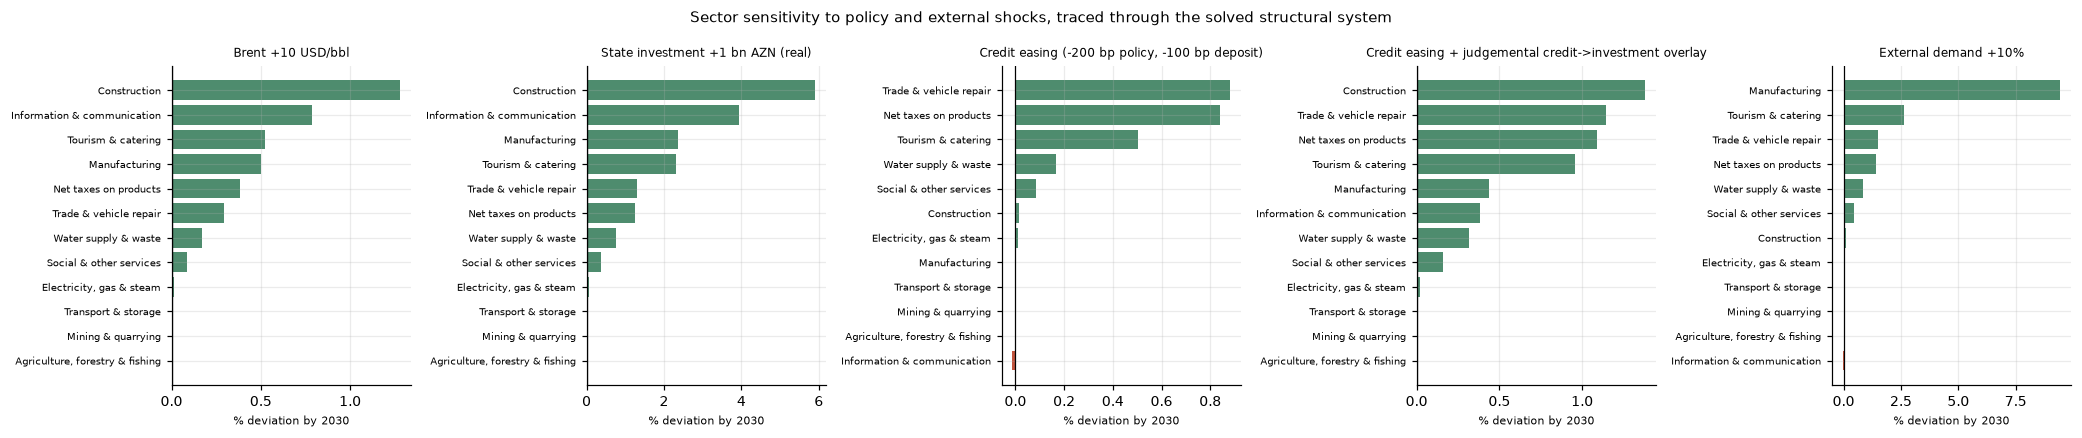

,"injection (real state investment, mln)",d real non-oil GDP (mln),d real GDP (mln),"impact multiplier, non-oil GDP"
2026,978.934,506.868,458.736,0.518
2027,975.604,606.994,549.362,0.622
2028,973.264,691.467,626.316,0.710
2029,971.588,768.223,696.386,0.791
2030,970.375,842.854,764.511,0.869


Why an oil price rise can LOWER chain-weighted real GDP while raising non-oil sectors
  Real GDP is chain-linked with previous-year NOMINAL weights (Part 3.4). A higher oil price raises the
  mining DEFLATOR and hence mining's weight, while mining's volume (exogenous) is falling, so the aggregate
  growth rate is tilted down: real GDP -0.49% by 2030, real non-oil GDP
  +0.31%, budget revenue +3.88%.

Fiscal multiplier reading (+1 bn AZN of real state investment per year, permanently)
  2030 level effect: real non-oil GDP +843 mln (2015 prices) for an injection of
  970 mln in 2030 -> multiplier 0.87 in 2030.
  Cumulative multiplier 2026-2030 (sum of d non-oil GDP / sum of injections): 0.70
  (on chain-weighted real GDP: 0.64).
  Construction absorbs the impulse first (+5.90% by 2030), then manufacturing and ICT.
  Non-oil imports move +1.32%: the long-run import equation's investment coefficient is wrongly
  signed (Part 10.2), so the import leakage of public investment is NOT captured

In [55]:
# Summary: cumulative 5-year impact, ranked by sector sensitivity
summ = pd.DataFrame({lbl: {SECT_LABEL[c]: MULT[lbl][f'rva_{c}'][H_END] for c in COMP}
                     for lbl in EXPS})
summ.loc['REAL GDP'] = {lbl: MULT[lbl]['rgdp'][H_END] for lbl in EXPS}
summ.loc['real non-oil GDP'] = {lbl: MULT[lbl]['rgdpnon'][H_END] for lbl in EXPS}
summ.loc['consumption'] = {lbl: MULT[lbl]['rcons'][H_END] for lbl in EXPS}
summ.loc['employment'] = {lbl: MULT[lbl]['emp'][H_END] for lbl in EXPS}
summ.loc['budget revenue'] = {lbl: MULT[lbl]['rev_tot_n'][H_END] for lbl in EXPS}
summ.loc['state investment'] = {lbl: MULT[lbl]['rinv_state'][H_END] for lbl in EXPS}
print(f"Effect by {H_END}, % deviation from baseline (inflation in pp)")
display(summ.round(3))

fig, ax = plt.subplots(1, len(EXPS), figsize=(19, 4))
for j, lbl in enumerate(EXPS):
    v = pd.Series({SECT_LABEL[c]: MULT[lbl][f'rva_{c}'][H_END] for c in COMP}).sort_values()
    ax[j].barh(range(len(v)), v.values, color=[PAL[1] if x < 0 else PAL[2] for x in v.values])
    ax[j].set_yticks(range(len(v))); ax[j].set_yticklabels(v.index, fontsize=6.5)
    ax[j].axvline(0, color='k', lw=.8); ax[j].set_title(lbl, fontsize=8)
    ax[j].set_xlabel(f'% deviation by {H_END}', fontsize=7)
plt.suptitle('Sector sensitivity to policy and external shocks, traced through the solved '
             'structural system', fontsize=10)
plt.tight_layout(); plt.show()

# Fiscal multiplier, in comparable units (2015-price mln AZN), two ways
_L = 'State investment +1 bn AZN (real)'
fcs, fcb = FCS[_L], FC['Baseline']
d_inj = fcs.rinv_state - fcb.rinv_state
MULTSUM = pd.DataFrame({
 'injection (real state investment, mln)': d_inj,
 'd real non-oil GDP (mln)': fcs.rgdpnon - fcb.rgdpnon,
 'd real GDP (mln)': fcs.rgdp - fcb.rgdp})
MULTSUM['impact multiplier, non-oil GDP'] = MULTSUM['d real non-oil GDP (mln)']/MULTSUM['injection (real state investment, mln)']
display(MULTSUM.round(3))
FISCAL_MULT_2030 = float(MULTSUM['d real non-oil GDP (mln)'][H_END]/d_inj[H_END])
FISCAL_MULT_CUM  = float(MULTSUM['d real non-oil GDP (mln)'].sum()/d_inj.sum())
FISCAL_MULT_CUM_GDP = float(MULTSUM['d real GDP (mln)'].sum()/d_inj.sum())
print(f'''Why an oil price rise can LOWER chain-weighted real GDP while raising non-oil sectors
  Real GDP is chain-linked with previous-year NOMINAL weights (Part 3.4). A higher oil price raises the
  mining DEFLATOR and hence mining's weight, while mining's volume (exogenous) is falling, so the aggregate
  growth rate is tilted down: real GDP {MULT["Brent +10 USD/bbl"]["rgdp"][H_END]:+.2f}% by {H_END}, real non-oil GDP
  {MULT["Brent +10 USD/bbl"]["rgdpnon"][H_END]:+.2f}%, budget revenue {MULT["Brent +10 USD/bbl"]["rev_tot_n"][H_END]:+.2f}%.

Fiscal multiplier reading (+1 bn AZN of real state investment per year, permanently)
  {H_END} level effect: real non-oil GDP +{MULTSUM["d real non-oil GDP (mln)"][H_END]:,.0f} mln (2015 prices) for an injection of
  {d_inj[H_END]:,.0f} mln in {H_END} -> multiplier {FISCAL_MULT_2030:.2f} in {H_END}.
  Cumulative multiplier 2026-{H_END} (sum of d non-oil GDP / sum of injections): {FISCAL_MULT_CUM:.2f}
  (on chain-weighted real GDP: {FISCAL_MULT_CUM_GDP:.2f}).
  Construction absorbs the impulse first ({MULT[_L]["rva_con"][H_END]:+.2f}% by {H_END}), then manufacturing and ICT.
  Non-oil imports move {MULT[_L]["rm_non"][H_END]:+.2f}%: the long-run import equation's investment coefficient is wrongly
  signed (Part 10.2), so the import leakage of public investment is NOT captured and this multiplier is, if anything, an
  upper bound.''')


## Part 15 — Results and export

In [56]:
# Assemble and export everything a user needs downstream
OUT = {}
for nm in SCEN:
    df = FC[nm].copy()
    df.insert(0, 'scenario', nm)
    OUT[nm] = df
FULL = pd.concat(OUT.values())
FULL.to_csv(OUTDIR/'FR1_forecast_full.csv')
pd.concat({nm: SECG[nm] for nm in SCEN}).to_csv(OUTDIR/'FR1_sector_growth.csv')
CONTRIB.to_csv(OUTDIR/'FR1_gdp_growth_contributions.csv')
DEC.to_csv(OUTDIR/'FR1_sector_decomposition.csv', index=False)
pd.concat({k: v for k, v in MULT.items()}).to_csv(OUTDIR/'FR1_multipliers.csv')
AUD2.to_csv(OUTDIR/'FR1_equation_audit.csv', index=False)
HOT.to_csv(OUTDIR/'FR1_holdout_validation.csv')
HOCOEF.to_csv(OUTDIR/'FR1_holdout_coefficients.csv')
SIMTAB.to_csv(OUTDIR/'FR1_iv_dwh.csv', index=False)
VIFTAB.to_csv(OUTDIR/'FR1_collinearity.csv', index=False)
CHOW.to_csv(OUTDIR/'FR1_chow.csv')
MULTSUM.to_csv(OUTDIR/'FR1_fiscal_multiplier.csv')
SENS_TAB.to_csv(OUTDIR/'FR1_addfactor_sensitivity.csv')
REGEL.to_csv(OUTDIR/'FR1_regional_elasticities.csv', index=False)
TREND_SHARE.to_csv(OUTDIR/'FR1_trend_share.csv')
IDCHK.to_csv(OUTDIR/'FR1_identity_checks.csv', index=False)
D.to_csv(OUTDIR/'FR1_analysis_dataset.csv')
A_RAW.to_csv(OUTDIR/'FR1_annual_raw.csv')
IP.to_csv(OUTDIR/'FR1_panel_industry.csv', index=False)
RP.to_csv(OUTDIR/'FR1_panel_region.csv', index=False)
for q, f in FAN.items(): f.to_csv(OUTDIR/f'FR1_fan_{q}.csv')
for q, f in FANG.items(): f.to_csv(OUTDIR/f'FR1_fan_growth_{q}.csv')
# macro replications for FR3/FR4/FR5: baseline only, same variable columns as FR1_forecast_full.csv
VARCOLS = [c for c in FULL.columns if c != 'scenario']
DRAWDF[['draw', 'year'] + VARCOLS].to_csv(OUTDIR/'FR1_fan_draws.csv', index=False)
assert 'pop' in FULL.columns and FULL['pop'].notna().all(), 'pop column missing from FR1_forecast_full.csv'
print(f"FR1_fan_draws.csv: {DRAWDF.draw.nunique()} replications x {len(FY)} years x {len(VARCOLS)} variables")
print("written to", OUTDIR)
for p in sorted(OUTDIR.glob('FR1_*.csv')): print("  ", p.name)

print(f"\n================ HEADLINE SUMMARY, {NOWCAST_Y}-{H_END} ================")
summary = pd.DataFrame({
 nm: {'real GDP growth, avg % p.a.': ((FC[nm].rgdp[H_END]/D.rgdp[LAST_ACT])**(1/len(FY))-1)*100,
      'real non-oil GDP growth, avg % p.a.': ((FC[nm].rgdpnon[H_END]/D.rgdpnon[LAST_ACT])**(1/len(FY))-1)*100,
      f'CPI inflation {H_END}, %': FC[nm].infl[H_END],
      f'unemployment {H_END}, %': FC[nm].unemp[H_END],
      f'budget balance {H_END}, % GDP': FC[nm].balance_n[H_END]/FC[nm].gdp_n[H_END]*100,
      f'public debt {H_END}, % GDP': FC[nm].debt_azn[H_END]/FC[nm].gdp_n[H_END]*100,
      f'hydrocarbon share of VA {H_END}, %': (FC[nm].p_min[H_END]*FC[nm].rva_min[H_END] /
          sum(FC[nm][f'p_{c}'][H_END]*FC[nm][f'rva_{c}'][H_END] for c in COMP))*100,
      f'nominal GDP {H_END}, bn AZN': FC[nm].gdp_n[H_END]/1000}
 for nm in SCEN})
display(summary.round(2))

FR1_fan_draws.csv: 500 replications x 5 years x 90 variables
written to /Users/econ0757/My Drive/OxLon/MIIS_Micro_Risk_Policy/MicroUnit/output
   FR1_accounts_forecast_deflator.csv
   FR1_accounts_forecast_nominal.csv
   FR1_accounts_forecast_real.csv
   FR1_accounts_history_deflator.csv
   FR1_accounts_history_nominal.csv
   FR1_accounts_history_real.csv
   FR1_accounts_long.csv
   FR1_accounts_summary_adverse.csv
   FR1_accounts_summary_baseline.csv
   FR1_accounts_summary_reform.csv
   FR1_addfactor_sensitivity.csv
   FR1_analysis_dataset.csv
   FR1_annual_raw.csv
   FR1_chow.csv
   FR1_collinearity.csv
   FR1_equation_audit.csv
   FR1_fan_cpi.csv
   FR1_fan_draws.csv
   FR1_fan_emp.csv
   FR1_fan_growth_emp.csv
   FR1_fan_growth_rcons.csv
   FR1_fan_growth_rcred_tot.csv
   FR1_fan_growth_rev_tot_n.csv
   FR1_fan_growth_rexp_cur.csv
   FR1_fan_growth_rgdp.csv
   FR1_fan_growth_rgdpnon.csv
   FR1_fan_growth_rhhdisp.csv
   FR1_fan_growth_rinv_non.csv
   FR1_fan_growth_rva_con.csv
   F

,Baseline,Adverse,Reform
"real GDP growth, avg % p.a.",2.560,1.510,3.500
"real non-oil GDP growth, avg % p.a.",4.180,3.070,5.260
"CPI inflation 2030, %",4.550,4.210,4.930
"unemployment 2030, %",4.600,4.780,4.440
"budget balance 2030, % GDP",0.260,1.360,-0.240
"public debt 2030, % GDP",19.970,20.670,19.090
"hydrocarbon share of VA 2030, %",14.340,10.430,16.780
"nominal GDP 2030, bn AZN",178.640,159.580,196.180


## Part 16 — Complete accounts: real growth, deflator, real value and nominal value for every sector and market

Parts 9–14 estimate and solve the model; Part 15 reported the headline results. This part presents the result in the form an analyst actually needs: for **every
sector and every market**, five aligned series over history *and* forecast, for all three scenarios.

| Metric | Definition | Unit |
|---|---|---|
| **Real value** | Constant 2015 prices | mln AZN (or natural unit) |
| **Real growth rate** | Year-on-year change in the real value | % |
| **Deflator** | Nominal ÷ real, indexed so 2015 = 1.000 | index |
| **Deflator inflation** | Year-on-year change in the deflator | % |
| **Nominal value** | Real value × deflator | mln AZN |

The three are linked by the identity `nominal = real × deflator`, so nominal growth ≈ real growth + deflator inflation. That
identity is checked numerically below rather than assumed.

### How "real" and "deflator" are defined for each entity

Value-added sectors and the consumer markets have their **own** implicit deflator, derived in Part 3 as nominal ÷ chain-linked
real. Financial, fiscal and labour aggregates do not have a published deflator of their own, so a deflator has to be *chosen*,
and the choice is stated per entity rather than buried:

| Entity group | Own deflator? | Deflator used | Interpretation of "real" |
|---|---|---|---|
| 12 value-added sectors, GDP, non-oil GDP, oil-gas GDP | **Yes** — implicit | Nominal ÷ real value added | Constant-price volume |
| Consumer market, retail, catering, paid services | **Yes** — implicit | Turnover deflator | Constant-price turnover |
| Fixed investment (total, state, private, oil, non-oil) | **Yes** — implicit | Aggregate investment deflator | Constant-price investment |
| Credit, deposits, budget revenue and spending, debt | No | **GDP deflator** | Purchasing power over domestic output |
| Wages | No | **CPI** | Purchasing power over consumption |
| Employment, labour force | n/a | — | The quantity *is* real |
| Goods exports and imports | Partly | GDP deflator on the manat value | Constant-price trade volume |

Two caveats carried forward from Part 3.5: chain-linked volumes are **not additive**, so composite aggregates (industry, goods,
services) have their real growth built by chain-linking their members rather than by summing real levels; and sector investment
deflators are not published, so the aggregate investment deflator is applied to every sector's investment.

In [57]:
# ---------------------------------------------------------------- entity registry
# kind: 'va'   -> value added with its own implicit deflator (real & deflator in the model)
#       'own'  -> own implicit deflator (markets, investment)
#       'defl' -> nominal series deflated by a chosen deflator ('gdp' or 'cpi')
#       'qty'  -> a quantity; real value is the quantity itself
#       'comp' -> composite aggregate: chain-linked real growth over member sectors
#       'rate' -> a rate or ratio, reported as a level only
ACCT = []
for s in COMP:
    ACCT.append(dict(key=f'va_{s}', label=SECT_LABEL[s], label_az=SECT_AZ[s],
                     group='1 Sectors (value added)', kind='va', real=f'rva_{s}', defl=f'p_{s}',
                     unit='mln AZN'))
ACCT += [
 dict(key='gdp',    label='GDP at market prices',  label_az='ÜDM',
      group='2 Aggregates', kind='va', real='rgdp',    defl='p_gdp',    unit='mln AZN'),
 dict(key='gdpnon', label='Non-oil GDP',           label_az='Qeyri neft-qaz ÜDM',
      group='2 Aggregates', kind='nonoil', real='rgdpnon', defl=None,   unit='mln AZN'),
 dict(key='gdpoil', label='Oil and gas GDP',       label_az='Neft-qaz ÜDM',
      group='2 Aggregates', kind='oil',    real='rgdpoil', defl=None,   unit='mln AZN'),
 dict(key='ind',    label='Industry (total)',      label_az='Sənaye',
      group='2 Aggregates', kind='comp', members=['min','man','elc','wat'], unit='mln AZN'),
 dict(key='indnon', label='Non-oil industry',      label_az='Qeyri neft-qaz sənayesi',
      group='2 Aggregates', kind='comp', members=['man','elc','wat'],     unit='mln AZN'),
 dict(key='goods',  label='Goods production',      label_az='Malların istehsalı',
      group='2 Aggregates', kind='comp', members=['min','man','elc','wat','agr','con'], unit='mln AZN'),
 dict(key='serv',   label='Services production',   label_az='Xidmətlərin istehsalı',
      group='2 Aggregates', kind='comp', members=['trd','tou','tra','ict','oth'], unit='mln AZN'),
 # ---- consumer markets
 dict(key='cons_mkt', label='Consumer market (total)', label_az='İstehlak bazarı',
      group='3 Consumer markets', kind='own', real='rcons',    defl='p_cons',   unit='mln AZN'),
 dict(key='retail',   label='Retail trade turnover',  label_az='Pərakəndə ticarət dövriyyəsi',
      group='3 Consumer markets', kind='own', real='rretail',  defl='p_retail', unit='mln AZN'),
 dict(key='cater',    label='Catering turnover',      label_az='İctimai iaşə dövriyyəsi',
      group='3 Consumer markets', kind='own', real='rcater',   defl='p_cater',  unit='mln AZN'),
 dict(key='serv_hh',  label='Paid services to households', label_az='Əhaliyə ödənişli xidmətlər',
      group='3 Consumer markets', kind='own', real='rserv_hh', defl='p_serv_hh', unit='mln AZN'),
 # ---- investment market
 dict(key='inv_tot',   label='Fixed investment (total)', label_az='Əsas kapitala investisiyalar',
      group='4 Investment market', kind='own', real='rinv_tot',   defl='p_inv', unit='mln AZN'),
 dict(key='inv_state', label='State investment',        label_az='Dövlət investisiyaları',
      group='4 Investment market', kind='own', real='rinv_state', defl='p_inv', unit='mln AZN'),
 dict(key='inv_priv',  label='Non-state investment',    label_az='Qeyri-dövlət investisiyaları',
      group='4 Investment market', kind='own', real='rinv_priv',  defl='p_inv', unit='mln AZN'),
 dict(key='inv_non',   label='Non-oil investment',      label_az='Qeyri neft-qaz investisiyaları',
      group='4 Investment market', kind='own', real='rinv_non',   defl='p_inv', unit='mln AZN'),
 dict(key='inv_oil',   label='Oil and gas investment',  label_az='Neft-qaz investisiyaları',
      group='4 Investment market', kind='invoil', unit='mln AZN'),
 # ---- labour market
 dict(key='emp',   label='Employment',             label_az='Məşğul əhali',
      group='5 Labour market', kind='qty', real='emp', unit='thousand persons'),
 dict(key='lf',    label='Labour force',           label_az='İqtisadi fəal əhali',
      group='5 Labour market', kind='qty', real='lf',  unit='thousand persons'),
 dict(key='wage',  label='Average monthly wage',   label_az='Orta aylıq əmək haqqı',
      group='5 Labour market', kind='defl', nom='wage', defl_src='cpi', unit='AZN per month'),
 dict(key='wagebill', label='Total wage bill',     label_az='Əmək haqqı fondu',
      group='5 Labour market', kind='wagebill', unit='mln AZN'),
 dict(key='unemp', label='Unemployment rate',      label_az='İşsizlik səviyyəsi',
      group='5 Labour market', kind='rate', real='unemp', unit='%'),
 # ---- credit and deposit markets
 dict(key='cred_tot', label='Credit to the economy', label_az='Cəmi kreditlər',
      group='6 Credit and deposits', kind='defl', nom='cred_tot_n', real='rcred_tot',
      defl_src='gdp', unit='mln AZN'),
 dict(key='cred_hh',  label='Household credit',      label_az='Ev təsərrüfatlarına kreditlər',
      group='6 Credit and deposits', kind='defl', nom='cred_hh_n', real='rcred_hh',
      defl_src='gdp', unit='mln AZN'),
 dict(key='dep_tot',  label='Deposits',             label_az='Cəmi depozitlər',
      group='6 Credit and deposits', kind='defl', nom='dep_tot_n', real='rdep_tot',
      defl_src='gdp', unit='mln AZN'),
 dict(key='lendrate', label='Average lending rate', label_az='Kreditlər üzrə faiz dərəcəsi',
      group='6 Credit and deposits', kind='rate', real='lendrate', unit='%'),
 # ---- external market
 dict(key='x_non', label='Non-oil goods exports', label_az='Qeyri-neft ixracı',
      group='7 External market', kind='defl', real='rx_non', defl_src='gdp', unit='mln AZN'),
 dict(key='m_non', label='Non-oil goods imports', label_az='Qeyri-neft idxalı',
      group='7 External market', kind='defl', real='rm_non', defl_src='gdp', unit='mln AZN'),
 dict(key='x_oil', label='Oil and gas exports',   label_az='Neft-qaz ixracı',
      group='7 External market', kind='xoil', unit='mln AZN'),
 # ---- fiscal
 dict(key='rev_tot', label='Budget revenue (total)', label_az='Dövlət büdcəsinin gəlirləri',
      group='8 Fiscal', kind='defl', nom='rev_tot_n', defl_src='gdp', unit='mln AZN'),
 dict(key='rev_oil', label='Oil and gas revenue',   label_az='Neft-qaz gəlirləri',
      group='8 Fiscal', kind='defl', nom='rev_oil_n', defl_src='gdp', unit='mln AZN'),
 dict(key='rev_non', label='Non-oil revenue',       label_az='Qeyri-neft-qaz gəlirləri',
      group='8 Fiscal', kind='defl', real='rrev_nonoil', defl_src='gdp', unit='mln AZN'),
 dict(key='exp_tot', label='Budget expenditure (total)', label_az='Dövlət büdcəsinin xərcləri',
      group='8 Fiscal', kind='defl', nom='exp_tot_n', defl_src='gdp', unit='mln AZN'),
 dict(key='exp_cur', label='Current expenditure',   label_az='Cari xərclər',
      group='8 Fiscal', kind='defl', real='rexp_cur', defl_src='gdp', unit='mln AZN'),
 dict(key='exp_cap', label='Capital expenditure',   label_az='Əsaslı xərclər',
      group='8 Fiscal', kind='defl', nom='exp_cap_n', defl_src='gdp', unit='mln AZN'),
 dict(key='debt',    label='Public debt',           label_az='Dövlət borcu',
      group='8 Fiscal', kind='defl', nom='debt_azn', defl_src='gdp', unit='mln AZN'),
 # ---- prices
 dict(key='cpi',  label='Consumer price index',  label_az='İstehlak qiymətləri indeksi',
      group='9 Prices', kind='price', real=None, defl='cpi', unit='2015 = 100'),
 dict(key='pgdp', label='GDP deflator',          label_az='ÜDM deflyatoru',
      group='9 Prices', kind='price', real=None, defl='p_gdp', unit='2015 = 1'),
]
print(f"{len(ACCT)} entities in the accounts, across {len({a['group'] for a in ACCT})} groups:")
for gname in sorted({a['group'] for a in ACCT}):
    items = [a['label'] for a in ACCT if a['group'] == gname]
    print(f"  {gname}: {len(items)}")
    for it in items: print(f"      - {it}")

49 entities in the accounts, across 9 groups:
  1 Sectors (value added): 12
      - Agriculture, forestry & fishing
      - Mining & quarrying
      - Manufacturing
      - Electricity, gas & steam
      - Water supply & waste
      - Construction
      - Trade & vehicle repair
      - Tourism & catering
      - Transport & storage
      - Information & communication
      - Social & other services
      - Net taxes on products
  2 Aggregates: 7
      - GDP at market prices
      - Non-oil GDP
      - Oil and gas GDP
      - Industry (total)
      - Non-oil industry
      - Goods production
      - Services production
  3 Consumer markets: 4
      - Consumer market (total)
      - Retail trade turnover
      - Catering turnover
      - Paid services to households
  4 Investment market: 5
      - Fixed investment (total)
      - State investment
      - Non-state investment
      - Non-oil investment
      - Oil and gas investment
  5 Labour market: 5
      - Employment
      - Labour f

In [58]:
# Ratio of nominal oil-gas GDP to nominal mining value added: oil-gas GDP also contains
# refining and oil services, so the two differ by a stable factor (Part 3.5). Calibrated,
# and reported, so the nominal oil / non-oil split can be carried into the forecast.
OILGDP_RATIO = float((A_RAW.gdp_oil_n/A_RAW.va_min_n).loc[LAST_ACT-2:LAST_ACT].mean())
print(f"nominal oil-gas GDP / nominal mining value added, 3-year average: {OILGDP_RATIO:.4f}")
print("  (the excess is oil refining and oil services, which sit outside mining)")

def accounts_for(source, years, is_forecast):
    '''Return real / deflator / nominal for every entity over `years`.
    `source` is the history frame D or a scenario's forecast frame; both use the same names.'''
    out = {}
    get = lambda nm: source[nm].reindex(years) if nm in source.columns else pd.Series(index=years, dtype=float)
    pgdp = get('p_gdp'); cpi = get('cpi')
    # nominal value added by sector, needed for the composite aggregates
    nom_va = {s: get(f'p_{s}')*get(f'rva_{s}') for s in COMP}
    real_va = {s: get(f'rva_{s}') for s in COMP}
    for a in ACCT:
        k, kind = a['key'], a['kind']
        if kind == 'va':
            real = get(a['real']); defl = get(a['defl']); nom = real*defl
        elif kind == 'own':
            real = get(a['real']); defl = get(a['defl']); nom = real*defl
        elif kind == 'nonoil':
            real = get('rgdpnon')
            # history uses the PUBLISHED nominal split, which is exact; only the forecast needs
            # the calibrated mining-to-oil-GDP ratio
            nom = (get('gdp_nonoil_n') if not is_forecast
                   else get('p_gdp')*get('rgdp') - OILGDP_RATIO*nom_va['min'])
            defl = nom/real
        elif kind == 'oil':
            real = get('rgdpoil')
            nom = get('gdp_oil_n') if not is_forecast else OILGDP_RATIO*nom_va['min']
            defl = nom/real
        elif kind == 'comp':
            mem = a['members']
            nom = sum(nom_va[m] for m in mem)
            # Chain-linked real growth over the members, because volumes are not additive
            # (Part 3.5). For the forecast the chain has to START from the last actual year,
            # otherwise the first forecast year has no previous-year weights and the whole
            # real path comes out missing.
            nv = {m: nom_va[m].copy() for m in mem}; rv = {m: real_va[m].copy() for m in mem}
            if is_forecast:
                for m in mem:
                    nv[m].loc[LAST_ACT] = float(D[f'p_{m}'][LAST_ACT]*D[f'rva_{m}'][LAST_ACT])
                    rv[m].loc[LAST_ACT] = float(D[f'rva_{m}'][LAST_ACT])
                    nv[m] = nv[m].sort_index(); rv[m] = rv[m].sort_index()
            w = pd.DataFrame(nv); w = w.div(w.sum(axis=1), axis=0)
            gr = pd.DataFrame({m: rv[m].pct_change() for m in mem})
            g = (w.shift(1)*gr).sum(axis=1, min_count=len(mem))
            real = pd.Series(index=years, dtype=float)
            base = float(D[f'r{k}'].get(LAST_ACT, np.nan)) if f'r{k}' in D.columns else np.nan
            if is_forecast and np.isfinite(base):
                lvl = base
                for y in years:
                    gy = g.get(y, np.nan)
                    lvl = lvl*(1 + (gy if np.isfinite(gy) else 0.0)); real[y] = lvl
            elif f'r{k}' in source.columns:
                real = get(f'r{k}')
            defl = nom/real
        elif kind == 'invoil':
            real = get('rinv_tot') - get('rinv_non'); defl = get('p_inv'); nom = real*defl
        elif kind == 'wagebill':
            nom = get('wage')*get('emp')*12/1000.0; defl = cpi/100.0; real = nom/defl
        elif kind == 'xoil':
            nom = get('x_g_oil_usd')*(FX_PATH.reindex(years) if is_forecast else D.fx.reindex(years))
            defl = pgdp; real = nom/defl
        elif kind == 'qty':
            real = get(a['real']); defl = pd.Series(1.0, index=years); nom = real
        elif kind == 'rate':
            real = get(a['real']); defl = pd.Series(np.nan, index=years); nom = real
        elif kind == 'price':
            defl = get(a['defl']); real = pd.Series(np.nan, index=years); nom = defl
        elif kind == 'defl':
            d = cpi/100.0 if a.get('defl_src') == 'cpi' else pgdp
            if a.get('real') and a['real'] in source.columns:
                real = get(a['real']); nom = real*d
            else:
                nom = get(a['nom']); real = nom/d
            defl = d
        else:
            continue
        out[k] = pd.DataFrame({'real': real, 'deflator': defl, 'nominal': nom})
    return out

FX_PATH = pd.Series({y: SCEN['Baseline'][y]['fx'] for y in FY})
HIST_YEARS = [y for y in range(2005, LAST_ACT+1)]
ACC_HIST = accounts_for(D, HIST_YEARS, is_forecast=False)
ACC_FC = {nm: accounts_for(FC[nm], FY, is_forecast=True) for nm in SCEN}
print(f"\naccounts built: {len(ACC_HIST)} entities x {len(HIST_YEARS)} historical years "
      f"and {len(FY)} forecast years x {len(SCEN)} scenarios")

# identity check: nominal = real x deflator, and nominal growth ~ real growth + deflator inflation
rows = []
for k, df in ACC_FC['Baseline'].items():
    if df[['real','deflator','nominal']].notna().all(axis=1).sum() == 0: continue
    err = (df.real*df.deflator - df.nominal).abs().max()
    g_n = df.nominal.pct_change()*100; g_r = df.real.pct_change()*100
    g_p = df.deflator.pct_change()*100
    gap = (g_n - (g_r + g_p)).abs().max()
    rows.append(dict(entity=k, max_abs_identity_error=err, max_growth_decomposition_gap_pp=gap))
IDT = pd.DataFrame(rows)
print(f"\nidentity nominal = real x deflator: max absolute error {IDT.max_abs_identity_error.max():.2e}")
print(f"growth decomposition (nominal ~ real + deflator) max gap: "
      f"{IDT.max_growth_decomposition_gap_pp.max():.3f} pp "
      f"(the residual is the exact cross term, real growth x deflator inflation)")

nominal oil-gas GDP / nominal mining value added, 3-year average: 1.1002
  (the excess is oil refining and oil services, which sit outside mining)

accounts built: 49 entities x 21 historical years and 5 forecast years x 3 scenarios

identity nominal = real x deflator: max absolute error 1.46e-11
growth decomposition (nominal ~ real + deflator) max gap: 0.749 pp (the residual is the exact cross term, real growth x deflator inflation)


### 16.1 The five metrics, sector by sector

Historical actuals first, then the baseline forecast. Real values are in 2015 prices, deflators are indexed to 2015 = 1.000.

In [59]:
def wide(acc, metric, years, keys=None, digits=2):
    keys = keys or list(acc)
    t = pd.DataFrame({ACCT_LABEL[k]: acc[k][metric].reindex(years) for k in keys if k in acc}).T
    t.columns = [int(y) for y in years]
    return t.round(digits)

ACCT_LABEL = {a['key']: a['label'] for a in ACCT}
ACCT_GROUP = {a['key']: a['group'] for a in ACCT}
SEC_KEYS = [f'va_{s}' for s in COMP]
AGG_KEYS = ['gdp','gdpnon','gdpoil','ind','indnon','goods','serv']

def growth(acc, key, years, metric='real'):
    s = acc[key][metric]
    return (s.pct_change()*100).reindex(years)

show_hist = [2010, BASE_YEAR, 2020, 2023, 2024, LAST_ACT]
print("=" * 110)
print("SECTORS - REAL VALUE ADDED, constant 2015 prices, mln AZN".center(110))
print("=" * 110)
display(wide(ACC_HIST, 'real', show_hist, SEC_KEYS, 1))
print("SECTORS - IMPLICIT DEFLATOR, 2015 = 1.000")
display(wide(ACC_HIST, 'deflator', show_hist, SEC_KEYS, 3))
print("SECTORS - NOMINAL VALUE ADDED, mln AZN")
display(wide(ACC_HIST, 'nominal', show_hist, SEC_KEYS, 1))
print("SECTORS - REAL GROWTH RATE, % per year")
display(pd.DataFrame({ACCT_LABEL[k]: growth(ACC_HIST, k, show_hist[1:]) for k in SEC_KEYS}).T.round(2))
print("SECTORS - DEFLATOR INFLATION, % per year")
display(pd.DataFrame({ACCT_LABEL[k]: growth(ACC_HIST, k, show_hist[1:], 'deflator')
                      for k in SEC_KEYS}).T.round(2))

                          SECTORS - REAL VALUE ADDED, constant 2015 prices, mln AZN                           


,2010,2015,2020,2023,2024,2025
"Agriculture, forestry & fishing","2,734.700","3,359.300","4,107.400","4,518.800","4,582.100","4,623.300"
Mining & quarrying,"17,056.400","14,370.200","13,009.300","12,365.000","12,439.200","12,128.200"
Manufacturing,"2,128.400","2,713.900","3,414.000","4,575.900","4,667.400","5,036.200"
"Electricity, gas & steam",543.900,734.700,792.500,886.300,874.700,877.400
Water supply & waste,67.900,93.600,96.400,138.000,143.900,147.500
Construction,"4,016.100","6,499.500","4,124.300","5,264.700","5,886.000","5,862.400"
Trade & vehicle repair,"3,327.300","5,387.800","5,903.600","6,614.700","6,872.700","7,099.500"
Tourism & catering,576.600,"1,312.800",674.200,"1,649.800","1,879.200","2,038.900"
Transport & storage,"2,844.900","3,241.900","3,997.400","5,400.400","6,102.500","6,383.200"
Information & communication,616.900,"1,087.700","1,574.700","2,260.300","2,549.600","2,771.400"


SECTORS - IMPLICIT DEFLATOR, 2015 = 1.000


,2010,2015,2020,2023,2024,2025
"Agriculture, forestry & fishing",0.857,1.000,1.191,1.502,1.542,1.654
Mining & quarrying,1.142,1.000,1.480,3.308,2.916,2.730
Manufacturing,0.945,1.000,1.297,1.381,1.602,1.533
"Electricity, gas & steam",0.739,1.000,1.123,1.490,1.511,1.659
Water supply & waste,0.679,1.000,1.720,1.966,1.954,2.046
Construction,0.856,1.000,1.387,1.450,1.413,1.437
Trade & vehicle repair,0.819,1.000,1.417,1.942,1.977,2.060
Tourism & catering,0.768,1.000,1.230,1.622,1.660,1.752
Transport & storage,0.833,1.000,1.294,1.449,1.406,1.427
Information & communication,1.283,1.000,0.977,0.950,0.958,0.963


SECTORS - NOMINAL VALUE ADDED, mln AZN


,2010,2015,2020,2023,2024,2025
"Agriculture, forestry & fishing","2,344.600","3,359.300","4,891.000","6,785.100","7,063.400","7,649.100"
Mining & quarrying,"19,482.200","14,370.200","19,248.200","40,897.200","36,278.500","33,108.400"
Manufacturing,"2,011.900","2,713.900","4,428.400","6,321.000","7,475.500","7,719.500"
"Electricity, gas & steam",402.000,734.700,890.200,"1,320.200","1,321.400","1,455.700"
Water supply & waste,46.100,93.600,165.800,271.300,281.200,301.700
Construction,"3,439.700","6,499.500","5,718.500","7,633.400","8,318.500","8,426.100"
Trade & vehicle repair,"2,724.600","5,387.800","8,366.500","12,846.500","13,585.700","14,625.200"
Tourism & catering,442.700,"1,312.800",829.200,"2,675.500","3,119.600","3,573.000"
Transport & storage,"2,368.700","3,241.900","5,174.500","7,827.000","8,579.000","9,106.200"
Information & communication,791.600,"1,087.700","1,538.700","2,147.400","2,442.700","2,668.600"


SECTORS - REAL GROWTH RATE, % per year


year,2015,2020,2023,2024,2025
"Agriculture, forestry & fishing",6.600,1.900,3.000,1.400,0.900
Mining & quarrying,0.900,-6.700,-3.100,0.600,-2.500
Manufacturing,7.700,9.600,9.000,2.000,7.900
"Electricity, gas & steam",-0.400,0.500,1.000,-1.300,0.300
Water supply & waste,1.800,-4.500,15.900,4.300,2.500
Construction,-13.400,-7.700,14.600,11.800,-0.400
Trade & vehicle repair,10.900,-1.300,3.500,3.900,3.300
Tourism & catering,14.000,-58.900,21.500,13.900,8.500
Transport & storage,-1.700,4.900,-7.000,13.000,4.600
Information & communication,6.800,0.800,16.900,12.800,8.700


SECTORS - DEFLATOR INFLATION, % per year


year,2015,2020,2023,2024,2025
"Agriculture, forestry & fishing",0.390,2.910,6.610,2.660,7.330
Mining & quarrying,-29.570,-28.480,-29.820,-11.820,-6.400
Manufacturing,-9.290,-1.400,-18.070,15.950,-4.300
"Electricity, gas & steam",-31.580,11.880,2.830,1.410,9.830
Water supply & waste,0.930,16.050,-2.510,-0.620,4.670
Construction,0.680,1.590,2.650,-2.530,1.700
Trade & vehicle repair,4.430,3.550,13.330,1.780,4.210
Tourism & catering,-9.260,1.880,8.150,2.370,5.560
Transport & storage,24.180,1.350,3.620,-3.000,1.480
Information & communication,-4.900,3.690,-0.690,0.840,0.500


In [60]:
nm = 'Baseline'
print("=" * 110)
print(f"SECTORS - {nm.upper()} FORECAST {FY[0]}-{FY[-1]}".center(110))
print("=" * 110)
for metric, lbl, dg in [('real', 'REAL VALUE ADDED (2015 prices, mln AZN)', 1),
                        ('deflator', 'DEFLATOR (2015 = 1.000)', 3),
                        ('nominal', 'NOMINAL VALUE ADDED (mln AZN)', 1)]:
    print(f"\n{lbl}")
    display(wide(ACC_FC[nm], metric, FY, SEC_KEYS, dg))
print("\nREAL GROWTH RATE (%)")
display(pd.DataFrame({ACCT_LABEL[k]: growth(ACC_FC[nm], k, FY) for k in SEC_KEYS}).T.round(2))
print("DEFLATOR INFLATION (%)")
display(pd.DataFrame({ACCT_LABEL[k]: growth(ACC_FC[nm], k, FY, 'deflator') for k in SEC_KEYS}).T.round(2))
print("NOMINAL GROWTH RATE (%)")
display(pd.DataFrame({ACCT_LABEL[k]: growth(ACC_FC[nm], k, FY, 'nominal') for k in SEC_KEYS}).T.round(2))

                                    SECTORS - BASELINE FORECAST 2026-2030                                     

REAL VALUE ADDED (2015 prices, mln AZN)


,2026,2027,2028,2029,2030
"Agriculture, forestry & fishing","4,715.800","4,939.800","5,151.600","5,360.600","5,571.800"
Mining & quarrying,"12,079.700","11,438.700","10,981.000","10,623.500","10,349.600"
Manufacturing,"5,348.900","5,715.500","6,107.800","6,529.000","6,984.100"
"Electricity, gas & steam",852.000,903.500,944.300,979.700,"1,012.800"
Water supply & waste,146.400,157.300,166.900,176.000,185.000
Construction,"4,749.300","5,275.700","5,576.300","5,752.600","5,871.200"
Trade & vehicle repair,"7,371.200","7,680.700","8,009.100","8,346.700","8,705.100"
Tourism & catering,"2,092.600","2,377.800","2,662.700","2,959.000","3,279.500"
Transport & storage,"6,670.500","6,997.800","7,347.800","7,720.300","8,118.000"
Information & communication,"3,020.900","3,299.400","3,595.000","3,910.500","4,248.700"



DEFLATOR (2015 = 1.000)


,2026,2027,2028,2029,2030
"Agriculture, forestry & fishing",1.696,1.762,1.827,1.893,1.961
Mining & quarrying,2.630,2.543,2.486,2.464,2.476
Manufacturing,1.579,1.648,1.717,1.787,1.860
"Electricity, gas & steam",1.710,1.830,1.949,2.069,2.195
Water supply & waste,2.109,2.198,2.288,2.379,2.473
Construction,1.460,1.497,1.534,1.569,1.606
Trade & vehicle repair,2.172,2.319,2.471,2.631,2.800
Tourism & catering,1.823,1.923,2.025,2.130,2.240
Transport & storage,1.424,1.453,1.479,1.502,1.525
Information & communication,0.934,0.908,0.883,0.858,0.834



NOMINAL VALUE ADDED (mln AZN)


...

,2026,2027,2028,2029,2030
"Agriculture, forestry & fishing",NaN,4.750,4.290,4.060,3.940
Mining & quarrying,NaN,-5.310,-4.000,-3.260,-2.580
Manufacturing,NaN,6.850,6.860,6.900,6.970
"Electricity, gas & steam",NaN,6.050,4.510,3.750,3.370
Water supply & waste,NaN,7.440,6.110,5.440,5.150
Construction,NaN,11.080,5.700,3.160,2.060
Trade & vehicle repair,NaN,4.200,4.280,4.220,4.290
Tourism & catering,NaN,13.630,11.980,11.130,10.830
Transport & storage,NaN,4.910,5.000,5.070,5.150
Information & communication,NaN,9.220,8.960,8.780,8.650


DEFLATOR INFLATION (%)


,2026,2027,2028,2029,2030
"Agriculture, forestry & fishing",NaN,3.900,3.700,3.600,3.570
Mining & quarrying,NaN,-3.330,-2.210,-0.910,0.490
Manufacturing,NaN,4.360,4.180,4.080,4.050
"Electricity, gas & steam",NaN,7.030,6.470,6.170,6.080
Water supply & waste,NaN,4.230,4.070,3.990,3.960
Construction,NaN,2.540,2.410,2.340,2.320
Trade & vehicle repair,NaN,6.750,6.570,6.470,6.440
Tourism & catering,NaN,5.500,5.290,5.190,5.150
Transport & storage,NaN,2.080,1.760,1.590,1.540
Information & communication,NaN,-2.730,-2.770,-2.790,-2.800


NOMINAL GROWTH RATE (%)


,2026,2027,2028,2029,2030
"Agriculture, forestry & fishing",NaN,8.830,8.150,7.800,7.650
Mining & quarrying,NaN,-8.460,-6.120,-4.140,-2.100
Manufacturing,NaN,11.520,11.330,11.260,11.300
"Electricity, gas & steam",NaN,13.510,11.270,10.160,9.660
Water supply & waste,NaN,11.980,10.430,9.640,9.310
Construction,NaN,13.900,8.240,5.570,4.430
Trade & vehicle repair,NaN,11.230,11.120,10.960,11.010
Tourism & catering,NaN,19.870,17.910,16.890,16.540
Transport & storage,NaN,7.090,6.850,6.740,6.770
Information & communication,NaN,6.230,5.940,5.740,5.610


### 16.2 Aggregates and markets

In [61]:
MKT_KEYS = [a['key'] for a in ACCT if a['group'].startswith(('3','4','5','6','7','8','9'))]
for nm in SCEN:
    print("=" * 110)
    print(f"AGGREGATES AND MARKETS - {nm.upper()}".center(110))
    print("=" * 110)
    for metric, lbl, dg in [('real', 'REAL VALUE (2015 prices; natural units where noted)', 1),
                            ('deflator', 'DEFLATOR', 3),
                            ('nominal', 'NOMINAL VALUE', 1)]:
        print(f"\n{lbl}")
        display(wide(ACC_FC[nm], metric, FY, AGG_KEYS + MKT_KEYS, dg))
    print("\nREAL GROWTH RATE (%)")
    display(pd.DataFrame({ACCT_LABEL[k]: growth(ACC_FC[nm], k, FY)
                          for k in AGG_KEYS + MKT_KEYS}).T.round(2))
    if nm == 'Baseline':
        print("DEFLATOR INFLATION (%)")
        display(pd.DataFrame({ACCT_LABEL[k]: growth(ACC_FC[nm], k, FY, 'deflator')
                              for k in AGG_KEYS + MKT_KEYS}).T.round(2))

                                      AGGREGATES AND MARKETS - BASELINE                                       

REAL VALUE (2015 prices; natural units where noted)


,2026,2027,2028,2029,2030
GDP at market prices,"62,509.000","64,394.000","66,380.500","68,461.300","70,718.400"
Non-oil GDP,"51,575.300","54,586.100","57,375.200","60,086.600","62,853.800"
Oil and gas GDP,"14,078.600","13,300.700","12,740.000","12,299.100","11,960.600"
Industry (total),"17,239.100","16,830.300","16,655.200","16,623.700","16,717.900"
Non-oil industry,"5,600.500","5,979.000","6,367.700","6,775.000","7,208.600"
Goods production,"25,971.700","26,041.500","26,224.900","26,485.600","26,848.300"
Services production,"31,409.300","32,958.200","34,478.600","36,002.200","37,576.300"
Consumer market (total),"45,673.400","47,510.500","49,542.100","51,672.700","53,959.200"
Retail trade turnover,"35,400.100","36,701.600","38,132.200","39,621.300","41,215.500"
Catering turnover,"1,421.400","1,472.100","1,528.100","1,586.300","1,648.700"



DEFLATOR


,2026,2027,2028,2029,2030
GDP at market prices,2.120,2.204,2.299,2.406,2.526
Non-oil GDP,1.892,2.014,2.136,2.262,2.394
Oil and gas GDP,2.483,2.406,2.358,2.341,2.357
Industry (total),2.436,2.407,2.402,2.424,2.470
Non-oil industry,1.824,1.910,1.996,2.083,2.174
Goods production,2.192,2.193,2.211,2.245,2.296
Services production,1.990,2.123,2.262,2.409,2.565
Consumer market (total),2.024,2.123,2.223,2.325,2.431
Retail trade turnover,2.097,2.207,2.320,2.435,2.556
Catering turnover,1.988,2.095,2.204,2.315,2.432



NOMINAL VALUE


...

,2026,2027,2028,2029,2030
GDP at market prices,2.135,2.266,2.393,2.520,2.649
Non-oil GDP,1.890,2.015,2.143,2.276,2.418
Oil and gas GDP,2.552,2.685,2.777,2.832,2.851
Industry (total),2.487,2.616,2.717,2.793,2.850
Non-oil industry,1.824,1.919,2.013,2.109,2.208
Goods production,2.226,2.332,2.418,2.489,2.549
Services production,1.990,2.132,2.279,2.435,2.602
Consumer market (total),2.024,2.132,2.240,2.351,2.467
Retail trade turnover,2.097,2.215,2.335,2.458,2.588
Catering turnover,1.988,2.103,2.219,2.339,2.465



NOMINAL VALUE


,2026,2027,2028,2029,2030
GDP at market prices,"133,439.400","148,019.000","162,970.000","178,861.400","196,179.600"
Non-oil GDP,"97,511.900","111,553.700","126,233.100","142,196.100","159,955.900"
Oil and gas GDP,"35,927.500","36,465.300","36,736.900","36,665.400","36,223.700"
Industry (total),"42,868.900","45,065.700","47,176.600","49,205.900","51,197.600"
Non-oil industry,"10,214.900","11,922.900","13,786.900","15,881.300","18,274.300"
Goods production,"57,804.300","61,987.000","65,787.900","69,376.900","72,910.500"
Services production,"62,507.400","70,927.400","80,010.600","90,061.100","101,338.700"
Consumer market (total),"92,469.200","102,771.200","113,953.400","126,341.500","140,174.800"
Retail trade turnover,"74,262.000","82,535.600","91,516.100","101,464.900","112,574.400"
Catering turnover,"2,826.900","3,141.900","3,483.700","3,862.500","4,285.400"



REAL GROWTH RATE (%)


,2026,2027,2028,2029,2030
GDP at market prices,NaN,4.510,4.260,4.220,4.310
Non-oil GDP,NaN,7.310,6.420,6.040,5.910
Oil and gas GDP,NaN,-3.550,-2.590,-2.110,-1.870
Industry (total),NaN,-0.090,0.820,1.440,1.960
Non-oil industry,NaN,10.960,10.230,9.950,9.890
Goods production,NaN,2.370,2.350,2.430,2.630
Services production,NaN,5.910,5.510,5.350,5.310
Consumer market (total),NaN,5.520,5.530,5.630,5.740
Retail trade turnover,NaN,5.230,5.200,5.290,5.390
Catering turnover,NaN,5.100,5.080,5.170,5.280


### 16.3 Summary: 2025 level, five-year real and nominal growth, and the price contribution

One table per scenario giving, for every entity: the 2025 starting level, the 2030 level, cumulative real growth, cumulative
deflator inflation, cumulative nominal growth, and the average annual real growth rate. This is the compact answer to the
request.

In [62]:
def summary_table(nm):
    rows = []
    for a in ACCT:
        k = a['key']
        if k not in ACC_FC[nm]: continue
        f = ACC_FC[nm][k]
        h = ACC_HIST.get(k)
        r0 = float(h.real.get(LAST_ACT, np.nan)) if h is not None else np.nan
        n0 = float(h.nominal.get(LAST_ACT, np.nan)) if h is not None else np.nan
        p0 = float(h.deflator.get(LAST_ACT, np.nan)) if h is not None else np.nan
        r1, n1, p1 = float(f.real.iloc[-1]), float(f.nominal.iloc[-1]), float(f.deflator.iloc[-1])
        yrs = len(FY)
        rows.append(dict(
            group=a['group'], entity=a['label'], entity_az=a['label_az'], unit=a['unit'],
            real_2025=r0, real_2030=r1,
            real_growth_cum_pct=(r1/r0-1)*100 if (np.isfinite(r0) and r0 != 0) else np.nan,
            real_growth_avg_pct=((r1/r0)**(1/yrs)-1)*100 if (np.isfinite(r0) and r0 > 0) else np.nan,
            deflator_2025=p0, deflator_2030=p1,
            deflator_infl_cum_pct=(p1/p0-1)*100 if (np.isfinite(p0) and p0 != 0) else np.nan,
            deflator_infl_avg_pct=((p1/p0)**(1/yrs)-1)*100 if (np.isfinite(p0) and p0 > 0) else np.nan,
            nominal_2025=n0, nominal_2030=n1,
            nominal_growth_cum_pct=(n1/n0-1)*100 if (np.isfinite(n0) and n0 != 0) else np.nan))
    return pd.DataFrame(rows).set_index(['group','entity'])

SUMM = {nm: summary_table(nm) for nm in SCEN}
cols = ['unit','real_2025','real_2030','real_growth_cum_pct','real_growth_avg_pct',
        'deflator_2025','deflator_2030','deflator_infl_avg_pct',
        'nominal_2025','nominal_2030','nominal_growth_cum_pct']
print("=" * 120)
print(f"BASELINE: {LAST_ACT} -> {H_END} for every sector and market".center(120))
print("=" * 120)
display(SUMM['Baseline'][cols].round(2))

print("\nReal growth 2025-2030, cumulative %, all three scenarios")
cmpv = pd.DataFrame({nm: SUMM[nm].real_growth_cum_pct for nm in SCEN})
cmpv['unit'] = SUMM['Baseline'].unit
display(cmpv.round(1))

                                   BASELINE: 2025 -> 2030 for every sector and market                                   


unit  real_2025  real_2030  real_growth_cum_pct  real_growth_avg_pct  deflator_2025  deflator_2030  deflator_infl_avg_pct  \
group                   entity                                                                                                                                                                   
1 Sectors (value added) Agriculture, forestry & fishing           mln AZN  4,623.350  5,571.830               20.520                3.800          1.650          1.960                  3.460   
                        Mining & quarrying                        mln AZN 12,128.200 10,349.550              -14.670               -3.120          2.730          2.480                 -1.930   
                        Manufacturing                             mln AZN  5,036.160  6,984.140               38.680                6.760          1.530          1.860                  3.940   
                        Electricity, gas & steam                  mln AZN    877.370  1,012.750               15.430                2.910          1.660          2.190                  5.760   
                        Water supply & waste                      mln AZN    147.490    185.010               25.440                4.640          2.050          2.470                  3.870   
                        Construction                              mln AZN  5,862.440  5,871.170                0.150                0.030          1.440          1.610                  2.240   
                        Trade & vehicle repair                    mln AZN  7,099.490  8,705.060               22.620                4.160          2.060          2.800                  6.330   
                        Tourism & catering                        mln AZN  2,038.880  3,279.490               60.850                9.970          1.750          2.240                  5.030   
                        Transport & storage                       mln AZN  6,383.220  8,117.980               27.180                4.930          1.430          1.530                  1.350   
                        Information & communication               mln AZN  2,771.430  4,248.690               53.300                8.920          0.960          0.830                 -2.820   
                        Social & other services                   mln AZN 12,821.100 14,666.460               14.390                2.730          2.190          3.320                  8.710   
                        Net taxes on products                     mln AZN  6,584.690  8,027.020               21.900                4.040          1.880          2.570                  6.390   
2 Aggregates            GDP at market prices                      mln AZN 62,336.200 70,718.440               13.450                2.560          2.070          2.530                  4.050   
                        Non-oil GDP                               mln AZN 51,212.110 62,853.790               22.730                4.180          1.800          2.390                  5.840   
                        Oil and gas GDP                           mln AZN 14,206.440 11,960.560              -15.810               -3.380          2.590          2.360                 -1.860   
                        Industry (total)                          mln AZN 17,117.520 16,717.900               -2.330               -0.470          2.490          2.470                 -0.140   
                        Non-oil industry                          mln AZN  5,354.830  7,208.640               34.620                6.130          1.770          2.170                  4.200   
                        Goods production                          mln AZN 26,488.490 26,848.290                1.360                0.270          2.210          2.300                  0.730   
                        Services production                       mln AZN 30,643.330 37,576.350               22.620                4.160          1.890          2.570                  6.26


Real growth 2025-2030, cumulative %, all three scenarios


Baseline  Adverse  Reform              unit
group                   entity                                                                      
1 Sectors (value added) Agriculture, forestry & fishing    20.500   20.500  22.500           mln AZN
                        Mining & quarrying                -14.700  -23.900 -10.000           mln AZN
                        Manufacturing                      38.700   16.900  62.700           mln AZN
                        Electricity, gas & steam           15.400   15.200  17.500           mln AZN
                        Water supply & waste               25.400   21.700  31.200           mln AZN
                        Construction                        0.100  -15.400  10.100           mln AZN
                        Trade & vehicle repair             22.600   15.900  28.900           mln AZN
                        Tourism & catering                 60.800   46.700  75.600           mln AZN
                        Transport & storage                27.200   24.400  33.100           mln AZN
                        Information & communication        53.300   44.600  61.800           mln AZN
                        Social & other services            14.400   12.600  16.100           mln AZN
                        Net taxes on products              21.900   15.300  28.000           mln AZN
2 Aggregates            GDP at market prices               13.400    7.800  18.800           mln AZN
                        Non-oil GDP                        22.700   16.300  29.200           mln AZN
                        Oil and gas GDP                   -15.800  -25.800 -10.600           mln AZN
                        Industry (total)                   -2.300  -12.000   4.900           mln AZN
                        Non-oil industry                   34.600   16.800  54.600           mln AZN
                        Goods production                    1.400   -7.200   8.000           mln AZN
                        Services production                22.600   18.500  27.100           mln AZN
3 Consumer markets      Consumer market (total)            23.700   16.600  30.200           mln AZN
                        Retail trade turnover              22.900   15.600  29.700           mln AZN
                        Catering turnover                  12.200    5.600  18.300           mln AZN
                        Paid services to households        23.200   15.600  30.400           mln AZN
4 Investment market     Fixed investment (total)            3.900  -17.400  18.900           mln AZN
                        State investment                    7.700  -18.500  27.600           mln AZN
                        Non-state investment               -0.400  -16.100   9.000           mln AZN
                        Non-oil investment                 11.200  -14.100  30.600           mln AZN
                        Oil and gas investment            -17.800  -27.200 -15.600           mln AZN
5 Labour market         Employment                          3.300    3.100   3.500  thousand persons
                        Labour force                        2.700    2.700   2.700  thousand persons
                        Average monthly wage               10.900    6.900  14.800     AZN per month
                        Total wage bill                    14.500   10.200  18.800           mln AZN
                        Unemployment rate                 -11.400   -8.100 -14.600                 %
6 Credit and deposits   Credit to the economy              17.300    6.300  21.100           mln AZN
                        Household credit                   36.500   21.900  46.700           mln AZN
                        Deposits                           27.900   19.900  36.000           mln AZN
                        Average lending rate               -5.100    5.900   0.000                 %
7 External market       Non-oil goods exports              58.400   32.000  87.500           mln AZN
                 

In [63]:
# ------------------------------------------------------------------ tidy long export
recs = []
for k, df in ACC_HIST.items():
    for y in df.index:
        for m in ['real','deflator','nominal']:
            v = df.loc[y, m]
            if np.isfinite(v):
                recs.append(dict(scenario='ACTUAL', group=ACCT_GROUP[k], entity=ACCT_LABEL[k],
                                 key=k, year=int(y), metric=m, value=float(v)))
for nm, acc in ACC_FC.items():
    for k, df in acc.items():
        for y in df.index:
            for m in ['real','deflator','nominal']:
                v = df.loc[y, m]
                if np.isfinite(v):
                    recs.append(dict(scenario=nm, group=ACCT_GROUP[k], entity=ACCT_LABEL[k],
                                     key=k, year=int(y), metric=m, value=float(v)))
LONG = pd.DataFrame(recs)
# add the growth metrics
gr = []
for scen, sub in LONG.groupby('scenario'):
    for (k, m), s in sub.groupby(['key','metric']):
        s = s.sort_values('year')
        base = ACC_HIST[k][m].get(LAST_ACT, np.nan) if scen != 'ACTUAL' else np.nan
        vals = s.value.to_numpy(); yrs = s.year.to_numpy()
        prev = np.concatenate([[base], vals[:-1]]) if scen != 'ACTUAL' else np.concatenate([[np.nan], vals[:-1]])
        with np.errstate(divide='ignore', invalid='ignore'):
            g = (vals/prev - 1)*100
        for y, gv in zip(yrs, g):
            if np.isfinite(gv):
                gr.append(dict(scenario=scen, group=ACCT_GROUP[k], entity=ACCT_LABEL[k], key=k,
                               year=int(y), metric=f'{m}_growth_pct', value=float(gv)))
LONG = pd.concat([LONG, pd.DataFrame(gr)], ignore_index=True)
LONG = LONG.sort_values(['scenario','group','entity','metric','year'])
LONG.to_csv(OUTDIR/'FR1_accounts_long.csv', index=False)
for nm in SCEN:
    SUMM[nm].to_csv(OUTDIR/f'FR1_accounts_summary_{nm.lower()}.csv')
for m in ['real','deflator','nominal']:
    wide(ACC_HIST, m, HIST_YEARS, list(ACC_HIST), 4).to_csv(OUTDIR/f'FR1_accounts_history_{m}.csv')
    pd.concat({nm: wide(ACC_FC[nm], m, FY, list(ACC_FC[nm]), 4) for nm in SCEN}) \
      .to_csv(OUTDIR/f'FR1_accounts_forecast_{m}.csv')
print(f"tidy long table: {len(LONG):,} rows "
      f"({LONG.entity.nunique()} entities x {LONG.metric.nunique()} metrics x "
      f"{LONG.scenario.nunique()} scenarios)")
display(LONG.groupby(['scenario','metric']).size().unstack(fill_value=0))
print("\nwritten:")
for p in sorted(OUTDIR.glob('FR1_accounts*.csv')): print("  ", p.name)

tidy long table: 9,849 rows (49 entities x 6 metrics x 4 scenarios)


metric,deflator,deflator_growth_pct,nominal,nominal_growth_pct,real,real_growth_pct
scenario,,,,,,
ACTUAL,971,924,955,906,925,878
Adverse,235,235,245,245,235,235
Baseline,235,235,245,245,235,235
Reform,235,235,245,245,235,235



written:
   FR1_accounts_forecast_deflator.csv
   FR1_accounts_forecast_nominal.csv
   FR1_accounts_forecast_real.csv
   FR1_accounts_history_deflator.csv
   FR1_accounts_history_nominal.csv
   FR1_accounts_history_real.csv
   FR1_accounts_long.csv
   FR1_accounts_summary_adverse.csv
   FR1_accounts_summary_baseline.csv
   FR1_accounts_summary_reform.csv


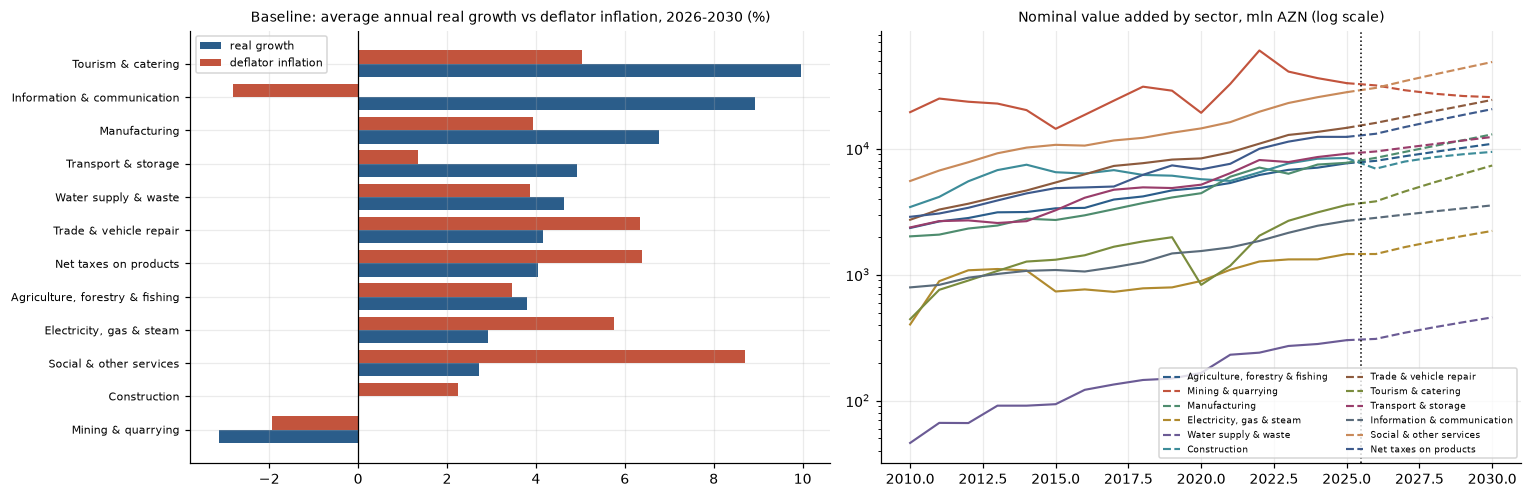

READING THE TABLES
  * Real growth is the volume story: ICT, transport and tourism lead; mining and construction contract.
  * Deflator inflation is the price story, and it differs sharply across sectors. Mining's deflator is
    set on world markets and tracks the manat oil price; the rest converge on CPI inflation.
  * Nominal growth, which is what budget revenue and wage bills are actually paid out of, is the sum of
    the two plus a small cross term. A sector can have weak real growth and strong nominal growth, or
    the reverse - which is exactly why all three are reported side by side rather than only real growth.


In [64]:
# Visual: real growth, deflator inflation and nominal growth decomposition by sector
nm = 'Baseline'
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
lbl = [ACCT_LABEL[k] for k in SEC_KEYS]
rg = [((ACC_FC[nm][k].real.iloc[-1]/ACC_HIST[k].real[LAST_ACT])**(1/len(FY))-1)*100 for k in SEC_KEYS]
dg = [((ACC_FC[nm][k].deflator.iloc[-1]/ACC_HIST[k].deflator[LAST_ACT])**(1/len(FY))-1)*100 for k in SEC_KEYS]
order = np.argsort(rg)
y = np.arange(len(order))
ax[0].barh(y-0.2, [rg[i] for i in order], height=0.4, color=PAL[0], label='real growth')
ax[0].barh(y+0.2, [dg[i] for i in order], height=0.4, color=PAL[1], label='deflator inflation')
ax[0].set_yticks(y); ax[0].set_yticklabels([lbl[i] for i in order], fontsize=7)
ax[0].axvline(0, color='k', lw=.8); ax[0].legend(fontsize=7)
ax[0].set_title(f'{nm}: average annual real growth vs deflator inflation, {FY[0]}-{FY[-1]} (%)', fontsize=9)
for i, k in enumerate(SEC_KEYS):
    hist = ACC_HIST[k].nominal.reindex(range(2010, LAST_ACT+1))
    fut = pd.concat([pd.Series({LAST_ACT: ACC_HIST[k].nominal[LAST_ACT]}), ACC_FC[nm][k].nominal])
    ax[1].plot(hist.index, hist.values, color=PAL[i % len(PAL)], lw=1.4)
    ax[1].plot(fut.index, fut.values, color=PAL[i % len(PAL)], lw=1.4, ls='--',
               label=ACCT_LABEL[k] if i < 12 else None)
ax[1].axvline(LAST_ACT+.5, color='k', ls=':', lw=1)
ax[1].set_yscale('log'); ax[1].set_title('Nominal value added by sector, mln AZN (log scale)', fontsize=9)
ax[1].legend(fontsize=5.8, ncol=2)
plt.tight_layout(); plt.show()

print(f'''READING THE TABLES
  * Real growth is the volume story: ICT, transport and tourism lead; mining and construction contract.
  * Deflator inflation is the price story, and it differs sharply across sectors. Mining's deflator is
    set on world markets and tracks the manat oil price; the rest converge on CPI inflation.
  * Nominal growth, which is what budget revenue and wage bills are actually paid out of, is the sum of
    the two plus a small cross term. A sector can have weak real growth and strong nominal growth, or
    the reverse - which is exactly why all three are reported side by side rather than only real growth.''')

## Part 17 — Specifications that failed, and limitations

### 17.1 Specifications that failed — the disclosed-failure list

A model is only as trustworthy as the failures it discloses. Each of these was tried, rejected on evidence, and replaced; the
rejected output is shown in the notebook at the point of rejection.

| What failed | Evidence | What the model does instead |
|---|---|---|
| **Output gap** in the inflation equation | Four measures tried (Part 9.6). Freely estimated production function gives a *negative* labour elasticity; with panel factor shares imposed it implies −1.31% p.a. TFP and a drifting "gap"; a linear trend gap is insignificant; a segmented trend gap is significant but flips the exchange-rate coefficient negative, because its breaks coincide with the devaluation. Credit growth as a proxy enters *negatively*. | No demand-pressure term. Inflation is a pure cost markup. Activity still reaches inflation through endogenous wages, but a separate output-gap effect is **not** identified. |
| **User cost of capital** in investment | Wrongly signed in all four measures (Part 9.3). State investment is 53% of total investment (2025). | Excluded. A credit-quantity term is also omitted: its free estimate is wrongly signed and the regional-panel value 0.134 (an output elasticity) is rejected by the aggregate data (HAC-F p = 0.028). Credit easing on investment is available only as a labelled judgemental overlay (Part 14). |
| **Policy-rate pass-through** to market rates | Wrongly signed. In 2016–17 the policy rate was raised to 15% defensively while lending rates *fell*: over this sample it is a crisis instrument, not a steering rate. | Lending rate on the **deposit rate** (long-run 1.40) plus an NPL premium. The policy rate acts on credit **quantities**, where it is correctly signed. |
| **Labour demand in levels** | VIF above 20; extrapolated it moved unemployment over 1 pp in the first forecast year. | Okun-type **employment-rate** relation, long-run elasticity 0.034. |
| **Free labour-force equation** | Population elasticity collapses to 0.05 with a 1.1% p.a. trend (VIF > 100). | Unit population elasticity imposed; participation drift +0.045% p.a. (the participation rate is flat: 51.35% in 2010, 52.56% in 2025). |
| **Imports without a relative price** | Investment coefficient *negative* — impossible where capital goods are nearly all imported. | Real-exchange-rate term added. It restores the sign in static OLS, but the long-run DOLS estimate is again slightly negative (−0.07, insignificant; first-difference estimate +0.55). The investment term is therefore dropped (wrong-signed and insignificant). |
| **Household income on budget social spending** (E3) | Social spending exists only from 2019: n = 7 for four parameters, a wrongly signed (−0.10) coefficient, and n = 2 in the hold-out (exact fit). A wage-bill + pension-bill replacement then failed homogeneity (sum 0.62, rejected) and under-predicted consumption by up to 23% in the static solution. | Non-oil GDP + pension bill (average pension × total population — the workbook has no count of pensioners), chosen on pre-cut evidence; homogeneity not rejected and imposed (a share relation). |
| **Ex-post real rate in consumption** | Long-run −0.019 vs −0.001 in differences; it turned every inflation surprise into a consumption boom. | Dropped. |
| **Wrong-signed, insignificant long-run terms** | Agricultural capital, investment in imports, non-oil GDP in transport. | Dropped by a rule that is re-applied on pre-cut data in the hold-out. |
| **Jan–Apr → full-year bridge (slope 0.52)** | Driven by the 2021 base effect (tourism). A robust bridge on 2022–25 does not beat 1:1 (HLN-DM one-sided p = 0.13). | 1:1 mapping. |
| **Credit on non-oil GDP** (G1) | Non-oil GDP entered with a wrong sign (−0.67) alongside deposits. | Dropped; scale enters through deposits. |
| **Unit trade elasticity, CRS in mining, α_K = factor share in manufacturing** | Previously "imposed". Under long-run DOLS and small-sample HAC-F all three are **rejected**. | Left free. Unit buoyancy of non-oil revenue and unit elasticity of state investment to oil revenue remain imposed, but only as *not rejected (low power)*. |
| **Regional trade "cross-validation"** | Regional trade VA is an exact 0.320 multiple of retail turnover in 58 of 63 region-years — an imputation. | Withdrawn as evidence. |
| **Mechanical resource rule for public investment** | Cuts real public investment ~30% by 2030 and yields a ~3%-of-GDP surplus: a projection of pro-cyclical austerity, not a neutral baseline. | Policy **level** stated per scenario; oil-revenue *deviations* move it with the estimated elasticity, preserving the transmission channel. |

Three solver-side errors are also on the record, because each produced plausible-looking but wrong forecasts: **decaying the base
add-factors** injected a +18%/−18% growth swing (base add-factors are held constant; only the partial-year 2026 anchor increment
decays); solving for adjustments that reproduced the whole system **diverged**, while
reading them off one forward pass **double-counted** (employment absorbed the labour force's error); and **re-anchoring shock
runs** cancelled the shock, making the fiscal multiplier look far too small.

### 17.2 Limitations

Each is specific and traceable to the data, not a generic caveat.

1. **No input–output table** in the workbook, so inter-sector linkages are *estimated* from time-series and panel covariation
   rather than *measured* from a supply-use matrix. This is the highest-value data addition, and it is in any case required by
   the policy module's FR2.
2. **No sector-level employment** at annual frequency — only industrial sub-branches (2016–2025) and regions (2021–2025). Full
   sector production functions are estimable only for industry, which directly limits what FR3 and FR4 (wages and employment
   *by sector*) can deliver from this file alone.
3. **No external demand variable** anywhere in the workbook, so it is a user-set scenario input and the non-oil export equation
   is supply-side only.
4. **No identified interest-rate or output-gap channel** (17.1). The model cannot simulate a policy-rate change through market
   rates, nor a pure demand-pressure effect on inflation.
5. **Short fiscal and balance-of-payments samples** (16 annual observations from 2010) carry materially wider parameter
   uncertainty than the real block.
6. **The regional panel is only five years long**; several coefficients change sign between one-way and two-way specifications,
   reported in Part 8 rather than hidden.
7. **The exchange rate is a de facto peg** since 2017, so pass-through is identified almost entirely by the 2015–16 devaluation.
   Any scenario that moves the rate extrapolates from a single episode.
8. **Sector investment deflators are not published**, so the aggregate investment deflator is applied to every sector.
9. **Chain-linked volumes are not additive** (Part 3.5); the non-oil wedge uses a calibrated correction whose size is reported.
10. **Manufacturing, construction and transport are the weakest forecasts** (hold-out RMSE 16–22%), because they went through a
    post-2020 supply-side transformation that pre-2021 coefficients cannot anticipate. Overall, the model does **not** beat
    constant growth estimated on 2010–2019 for the median variable (median U 1.09). Treat those sector paths as conditional
    on no repeat of that kind of capacity shock.
11. **Calibrated shares are held fixed** (sector investment shares, social-spending share, debt-service rate); structural change
    in them is not captured.
12. **Public investment's level is an assumption, not a forecast**, and should be set deliberately for each exercise.
13. **Cointegration is established for only a few level relations** (see the audit table); most level t-statistics are
    descriptive and the forecast level depends on the constant-add-factor assumption (sensitivity in Part 13.1).
14. **Trend-carried growth** — in several sectors most of 2027–2030 growth is the estimated deterministic trend (Part 13.3).
15. **Strong demand loop**: household income now moves with non-oil GDP (homogeneity imposed), consumption with income, and
    trade, taxes and services with consumption, so shocks and policy impulses are amplified; manufacturing is additionally
    amplified by the export ↔ manufacturing link (Part 13.2).
16. **No aggregate credit channel** in investment; credit easing on investment is a judgemental overlay.
17. **Wide fans** for CPI and consumption, and about 30% of simulated replications are screened out by the jump ceiling
    (Part 13.4) — the fans are therefore somewhat truncated.

### 17.3 What would most improve the model

In order of expected value per unit of effort:

1. A **supply-use / input–output table**, which would replace estimated linkages with measured ones and unlock FR2 of the policy module.
2. **Employment and compensation by sector** at annual frequency, which would complete the production-function block and serve FR3/FR4 directly.
3. **Partner-weighted external demand** and an import price index with history, which would properly identify the trade block.
4. **Quarterly national accounts by sector**, which would roughly quadruple the effective sample and make the dynamics estimable rather than imposed.
5. **Sector investment deflators**, removing the common-deflator assumption.